In [1]:
%pip install pykrige -q
%pip install xarray==2024.05.0 -q
# %pip install earthaccess==0.15.1
%pip install cmocean -q

Note: you may need to restart the kernel to use updated packages.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xmip 0.7.2 requires cf_xarray>=0.6.0, which is not installed.
xmip 0.7.2 requires xarrayutils, which is not installed.
xmip 0.7.2 requires xgcm<0.7.0, which is not installed.
intake-esm 2025.7.9 requires xarray>=2024.10, but you have xarray 2024.5.0 which is incompatible.
rioxarray 0.20.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
rioxarray 0.20.0 requires xarray>=2024.7.0, but you have xarray 2024.5.0 which is incompatible.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
%matplotlib widget

%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d import Axes3D
from skimage import exposure
from skimage.io import imsave, imread
from osgeo import ogr
import pystac_client
from pyproj import Transformer
from datetime import date, timedelta, datetime
from dateutil.relativedelta import relativedelta
import geopandas as gpd
import pandas as pd
import geoviews as gv
import hvplot.pandas
import intake
import xarray as xr
import numpy as np
from numpy.random import default_rng
import intake
from pyproj import Proj, transform
from osgeo import gdal
from sklearn.neighbors import BallTree
import earthaccess
import gzip

# for progress bar
from ipywidgets import IntProgress
from IPython.display import display
from ipywidgets import interact, Dropdown
import time
from tqdm.notebook import trange, tqdm

import boto3
import rasterio as rio
from rasterio.features import rasterize
from rasterio.session import AWSSession
import dask
import os
import rioxarray
from rasterio.enums import Resampling
from rasterio.warp import reproject
from rasterio.warp import Resampling as resample
import cartopy.crs as ccrs
import cartopy
from pykrige.ok import OrdinaryKriging
from sklearn.linear_model import LinearRegression, RANSACRegressor
from scipy.odr import Model, RealData, ODR
import scipy.odr as odr
import scipy
import statsmodels.formula.api as smf
from shapely.geometry.polygon import Polygon, Point
from shapely.geometry import box, shape
import pygmt
import gc
import pytz
import pyproj
import math
import json
from pathlib import Path
from matplotlib.patches import Polygon as Pgon
from matplotlib.patches import Patch
from tqdm import tqdm
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler
import cmocean

import SSTutils as sut

import warnings
warnings.filterwarnings('ignore')

/tmp/ipykernel_270/3892916869.py:54: DeprecationWarning: `scipy.odr` is deprecated as of version 1.17.0 and will be removed in SciPy 1.19.0. Please use `https://pypi.org/project/odrpack/` instead.
  from scipy.odr import Model, RealData, ODR


In [3]:
# Coefficients for calibration
calib_m = 0.77 
calib_b = 0.53

In [4]:
# Authenticate for accessing NASA data (MODIS)
auth = earthaccess.login(strategy="netrc")

# If we are not authenticated
if not auth.authenticated:
    # ask for credentials and persist them in a .netrc file
    auth.login(strategy="interactive", persist=True)

In [5]:
# Landsat STAC catalog location
url = 'https://landsatlook.usgs.gov/stac-server'

# Paths
basepath = Path('/home/jovyan/Landsat_SST_algorithm')
lsatpath = basepath / 'Data'
atmpath = lsatpath / 'AtmCorrection'
modout_path = lsatpath / 'MOD07_L2'

WV = 'Water_Vapor'

# For geopandas and tile plots
satellite = 'Landsat8'
collection = 'landsat-c2l1' # Landsat Collection 2, Level 1
colnm = ['landsat:wrs_path','landsat:wrs_row']

# Dataset paths
iqvalid_path = lsatpath / 'SST/Validation/iQuamIntercomp/'
iQpath = lsatpath / 'iQuam'
sealpath = lsatpath / 'seal_tags'
iq_geojson = lsatpath / f'{satellite}_iQuam.geojson'

svalid_path = lsatpath / 'SST/Validation/sealIntercomp/'
seal_geojson = lsatpath / f'{satellite}_sealtag.geojson'

# Seal tag data
seal_BASSTR = sealpath / 'BASSTR_v3_raw_and_interp.csv'
seal_IMOS = sealpath / 'IMOS_STR_v3_raw_and_interp.csv'

# Buffer around iquam point used to create a bounding box for Landsat sample
dist = 1.0 # km

# Temporal search range (days) before/after iquam measurement for finding Landsat image
time_add = 0.5

lthresh = -1.9

interp = 1

In [6]:
# Authenticate for boto S3 access, etc.
os.environ["AWS_REQUEST_PAYER"] = "requester"
aws_session = AWSSession(boto3.Session(), requester_pays=True)

In [7]:
# Create scalar for normalizing T, TOA, and WV data
months = ['01','02','03','04','05','06','07','08','09','10','11','12']

modtran_lut,n = sut.concat_modtran_months(months,atmpath)

simTOA = modtran_lut[['TOA T[K]']]
simWV = modtran_lut[['TCWV [cm]']]
simT = modtran_lut[['Surface T[K]']] 
# simT = simTOA.rename(columns={'TOA T[K]': 'Surface T[K]'})

print(f'ERA5 count: {n}')
print(f'Simulated TOA min: {np.around(simTOA.min().values[0],2)}, max: {np.around(simTOA.max().values[0],2)}, and mean: {np.around(simTOA.mean().values[0],2)}+/- {np.around(simTOA.std().values[0],2)}')
print(f'WV min: {np.around(simWV.min().values[0],4)}, max: {np.around(simWV.max().values[0],5)}, and mean: {np.around(simWV.mean().values[0],2)}+/- {np.around(simWV.std().values[0],2)}')
print(f'SST min: {np.around(simT.min().values[0],2)}, max: {np.around(simT.max().values[0],2)}, and mean: {np.around(simT.mean().values[0],2)}+/- {np.around(simT.std().values[0],2)}')

simTOA_transformer = StandardScaler().fit(simTOA)
simWV_transformer = StandardScaler().fit(simWV)
simT_transformer = RobustScaler().fit(simT)

01: 1174
02: 1415
03: 1140
04: 846
05: 604
06: 513
07: 551
08: 324
09: 317
10: 313
11: 367
12: 768
ERA5 count: 8332
Simulated TOA min: 270.17, max: 275.18, and mean: 271.72+/- 0.97
WV min: 0.1727, max: 2.0716, and mean: 0.76+/- 0.32
SST min: 271.46, max: 276.26, and mean: 272.73+/- 1.03


In [8]:
# Derive coefficients for SST retrievals
atmcor,retrieval_results,modtran_lut_norm = sut.derive_coeffs(atmpath,simTOA_transformer,simWV_transformer,simT_transformer)

Processing rolling window for middle month 01
12: 768
01: 1174
02: 1415
Rolling for month 01: toa = 0.69, tcwv_toa = -0.01, Intercept = 0.11, R2 = 0.98
p-values for month 01: toa = 0.0, tcwv_toa = 0.0, Intercept = 0.0
Processing rolling window for middle month 02
01: 1174
02: 1415
03: 1140
Rolling for month 02: toa = 0.68, tcwv_toa = -0.0, Intercept = 0.13, R2 = 0.98
p-values for month 02: toa = 0.0, tcwv_toa = 0.119, Intercept = 0.0
Processing rolling window for middle month 03
02: 1415
03: 1140
04: 846
Rolling for month 03: toa = 0.68, tcwv_toa = 0.01, Intercept = 0.13, R2 = 0.98
p-values for month 03: toa = 0.0, tcwv_toa = 0.0, Intercept = 0.0
Processing rolling window for middle month 04
03: 1140
04: 846
05: 604
Rolling for month 04: toa = 0.67, tcwv_toa = 0.02, Intercept = 0.13, R2 = 0.98
p-values for month 04: toa = 0.0, tcwv_toa = 0.0, Intercept = 0.0
Processing rolling window for middle month 05
04: 846
05: 604
06: 513
Rolling for month 05: toa = 0.65, tcwv_toa = 0.01, Intercep

# Create validation matchups via GHRSST iQUAM data
https://www.star.nesdis.noaa.gov/socd/sst/iquam/?tab=0&dateinput_year=2023&dateinput_month=02&dayofmoninput_day=26&dateinput_hour=00&dayofmon=monthly&qcrefsst=_qcrey&qcrefsst=_qccmc&outlier=qced#qmap

In [9]:
# Year and months desired (multiple years)
start_yr = 2023
end_yr = 2024

# Note these will get months from the later part of the year to early next
start_mo = '09'
end_mo = '03'

# Headers for the saved outputs
headers = ['DateTime','L8_filename','L8_SST','L8_std','center','L8_SST_max','L8_SST_min','Argo_id','Argo_SST','depth','platform_type','A_lat','A_lon','time_dif']
# Desired projection transformation
source_crs = 'epsg:4326' 
target_crs = 'epsg:3031' # Coordinate system of the Landsat file

In [10]:
iquam_fails = [
    'LC08_L1GT_073106_20210127_20210305_02_T2',
    'LC08_L1GT_193109_20210120_20210307_02_T2',
    'LC08_L1GT_215103_20220117_20220123_02_T2',
    'LC08_L1GT_216103_20211223_20211230_02_T2',
    'LC08_L1GT_201104_20221201_20221206_02_T2',
    'LC08_L1GT_202104_20221208_20221213_02_T2',
    'LC08_L1GT_202103_20221208_20221213_02_T2',
]

In [11]:
# Multiple years
import s3fs
from collections import defaultdict

# Initialize S3 filesystem with the correct region
s3 = s3fs.S3FileSystem(anon=False, client_kwargs={'region_name': 'us-west-2'})

# S3 configuration
s3_bucket = 'nasa-cryo-persistent'
s3_prefix = 'tsnow03/Landsat_SST_algorithm/Data/iQuam'
s3_path = f'{s3_bucket}/{s3_prefix}'

# ✅ LIST FILES FROM S3
print(f'Listing files from s3://{s3_path}...')
all_s3_files = s3.ls(s3_path)

# Set up projections
transformer = Transformer.from_crs(source_crs, target_crs, always_xy=True)

# Get iQuam file paths in directory between desired dates and find and produce matching Landsat SSTs 
for year in range(start_yr, end_yr):  
    yrmo = []
    start_yrmo = f"{year}{start_mo}"
    end_yrmo = f"{year+1}{end_mo}"

    m0 = start_yrmo
    
    # Make a list of months between start and end
    while int(m0) <= int(end_yrmo):
        yms = datetime.strptime(f'{m0[:4]}-{m0[4:]}', '%Y-%m')
        yrmo.append(yms.strftime("%Y%m"))
        m0 = (yms + relativedelta(months=1)).strftime("%Y%m")
    
    # Get file names and select only those matching dates from yrmo    
    iQfiles = [f for f in all_s3_files if any(ym in f for ym in yrmo)]
    iQfiles.sort(reverse=True)
    print(f'{year}: {len(iQfiles)} files found')

    # ✅ STEP 1: COLLECT ALL ARGO-SCENE PAIRS FIRST
    scene_to_argo = defaultdict(list)  # sceneid -> list of (argo_idx, argo_data)
    
    for i, iquam_file in enumerate(iQfiles):
        filename = iquam_file.split('/')[-1]
        print(f"Loading {i+1}/{len(iQfiles)}: {filename}")
        
        with s3.open(iquam_file, 'rb') as f:
            with xr.open_dataset(f, engine='h5netcdf') as ds:
                ds = ds.where(
                    (ds.lat < -60) & 
                    (ds.quality_level == 5.0) & 
                    (ds.depth < 6.0) &
                    (ds.platform_type == 5.0),
                    drop=True
                )
                
                needed_cols = ['lat', 'lon', 'sst', 'year', 'month', 'day', 
                              'hour', 'minute', 'depth', 'platform_type', 'platform_id']
                
                ant = ds[needed_cols].to_dataframe()
                print(f"  Found {len(ant)} Antarctic measurements")
        
        if ant['year'].iloc[0] == 2020 and ant['month'].iloc[0] == 12:
            ant = ant[ant.day != 9.0]
    
        # Search for scenes for each Argo point
        for idx in tqdm(range(ant.shape[0]), desc="Searching STAC"):
            ilat = ant['lat'].iloc[idx]
            ilon = ant['lon'].iloc[idx]
    
            lat_add = sut.km_to_decimal_degrees(dist, ilat, direction='latitude')
            lon_add = sut.km_to_decimal_degrees(dist, ilat, direction='longitude')
            bboxV = (ilon-lon_add, ilat-lat_add, ilon+lon_add, ilat+lat_add)
    
            imin = int(ant.minute.iloc[idx])
            ihr = int(ant.hour.iloc[idx])
            iyr = int(ant.year.iloc[idx])
            imo = int(ant.month.iloc[idx])
            iday = int(ant.day.iloc[idx])
    
            calc_dt = datetime(iyr, imo, iday, ihr, imin, 0)
            start_dt = (calc_dt + timedelta(days=-time_add)).strftime('%Y-%m-%dT%H:%M:%SZ')
            end_dt = (calc_dt + timedelta(days=time_add)).strftime('%Y-%m-%dT%H:%M:%SZ')
            timeRangeV = f'{start_dt}/{end_dt}'
    
            # Search for scenes
            items = sut.search_stac(url, collection, gjson_outfile=iq_geojson, 
                                   bbox=bboxV, timeRange=timeRangeV)
            
            catalog_list = [x for x in items if x.id[3] == '8']
            
            # Store this Argo point with each scene it matches
            for sceneid in catalog_list:
                scene_to_argo[sceneid.id].append({
                    'idx': idx,
                    'ilat': ilat,
                    'ilon': ilon,
                    'calc_dt': calc_dt,
                    'bboxV': bboxV,
                    'argo_temp': np.around((ant.sst.iloc[idx] - 273.15), 2),
                    'depth': ant.iloc[idx].depth,
                    'platform_type': ant.iloc[idx].platform_type,
                    'platform_id': ant.iloc[idx].platform_id
                })
    
    print(f"\n✅ Found {len(scene_to_argo)} unique scenes matching Argo points")
    print(f"✅ Total Argo-scene pairs: {sum(len(v) for v in scene_to_argo.values())}")
    
    # ✅ STEP 2: PROCESS EACH SCENE ONCE
    valid = []
    items_all = sut.search_stac(url, collection, gjson_outfile=iq_geojson,
                                bbox=(-180, -80, 180, -60),
                                timeRange=f"{start_yrmo[:4]}-{start_yrmo[4:]}-01T00:00:00Z/{end_yrmo[:4]}-{end_yrmo[4:]}-31T23:59:59Z")
    catalog = intake.open_stac_item_collection(items_all)
    
    scene_items = list(scene_to_argo.items())
    for sceneid, argo_list in tqdm(scene_items[157:], desc="Processing scenes"):

        if sceneid in iquam_fails:
            continue
            
        # Get scene
        try:
            scene = catalog[sceneid]
        except:
            print(f"  Scene {sceneid} not in catalog, skipping")
            continue
            
        timestr = scene.metadata['datetime'].strftime('%H%M%S')
        outFile = f'{iqvalid_path}/{sceneid}_{timestr}_Cel.tif'
        
        # Load or create SST ONCE for this scene
        if os.path.isfile(outFile):
            print(f'  {sceneid} - atm corr exists')
            SST_full = xr.open_dataset(outFile, chunks=dict(x=512, y=512), engine='rasterio')['band_data'].sel(band=1)
            SST_full = SST_full.rio.write_crs("epsg:3031", inplace=True)
        else:
            print(f'  Creating SST for {sceneid}')
            
            # Get STAC item
            sceneid_item = [x for x in items_all if x.id == sceneid][0]
            
            ls_scene = sut.landsat_to_xarray(sceneid_item, catalog)
            ls_scene = ls_scene.rio.write_crs("epsg:3031", inplace=True)
            ls_scene = sut.create_masks(ls_scene, cloud_mask=True, ice_mask=True, ocean_mask=True)
            
            mask = np.ones(ls_scene.shape[1:])
            mask[ls_scene.mask != 3] = np.nan
            ls_thermal = ls_scene.sel(band='lwir11').compute()
            
            # Check if any ocean pixels exist
            if (ls_thermal * mask).isnull().all():
                print(f'  {sceneid} has no ocean pixels')
                try:
                    del ls_scene, mask, ls_thermal
                except:
                    pass
                gc.collect()
                continue
            
            # Atmospheric correction
            try:
                mod07, modfilenm = sut.open_MODIS(ls_scene, scene, modout_path)
                spacing = [300, -300]
                WV_xr = sut.get_wv(ls_scene, mod07, spacing, WV, scene, interp=interp)
            except Exception as e:
                print(f'  Skipping due to atm correction error: {e}')
                continue
            
            SST = sut.apply_retrieval(ls_thermal, scene, mask, WV_xr, atmcor,
                                     simT_transformer, simTOA_transformer, simWV_transformer)
            SST.attrs['MODIS_WV'] = modfilenm
            SST.rio.to_raster(raster_path=outFile, driver="COG")
            print(f'  Mean SST: {np.nanmean(SST)}')
            
            SST_full = SST.copy()
            
            try:
                del ls_scene, mask, ls_thermal, mod07, WV_xr, SST
            except:
                pass
            gc.collect()
        
        # Apply calibration ONCE
        SST_calibrated = SST_full * calib_m + calib_b
        SST_calibrated = SST_calibrated.where(SST_calibrated >= lthresh, np.nan)
        
        # Extract scene datetime
        scene_date = sceneid[17:25]
        scene_dt = datetime.strptime(scene_date + timestr, "%Y%m%d%H%M%S")
        
        # ✅ PROCESS ALL ARGO POINTS FOR THIS SCENE
        for argo_data in argo_list:
            ilat = argo_data['ilat']
            ilon = argo_data['ilon']
            bboxV = argo_data['bboxV']
            
            # Reproject bbox
            sbox, checkbox = sut.lsat_reproj(source_crs, target_crs,
                                            (bboxV[0], bboxV[1], bboxV[2], bboxV[3]))
            polygon = Polygon([(sbox[0][0], sbox[0][1]), (sbox[3][0], sbox[3][1]),
                              (sbox[2][0], sbox[2][1]), (sbox[1][0], sbox[1][1])])
            
            minx, miny, maxx, maxy = polygon.bounds
            
            # Subset and crop
            ls_sub = sut.subset_img(SST_calibrated, [minx, maxx], [miny, maxy])
            ls_sub = sut.crop_xarray_dataarray_with_polygon(ls_sub, polygon)
            
            # Skip if no valid data for this Argo point
            if ls_sub.isnull().all():
                print(f'    No valid SST for Argo at ({ilat:.2f}, {ilon:.2f})')
                continue
            
            lsat = np.around(np.nanmean(ls_sub), 2)
            lstd = np.around(np.nanstd(ls_sub), 2)
            
            # Get center pixel
            argo_px, argo_py = transformer.transform(ilon, ilat)
            center_val = ls_sub.sel(x=argo_px, y=argo_py, method="nearest")
            center = center_val.values.item()
            
            # Time difference
            times = pd.to_datetime(argo_data['calc_dt'], format='%Y%m%d%H%M%S')
            time_difference = abs(scene_dt - times)
            
            valid.append([
                times,
                sceneid,
                lsat,
                lstd,
                center,
                ls_sub.max().values.item(),
                ls_sub.min().values.item(),
                f"{argo_data['platform_id']}-{times}",
                argo_data['argo_temp'],
                argo_data['depth'],
                argo_data['platform_type'],
                ilat,
                ilon,
                time_difference
            ])
            
            print(f"    Argo temp: {argo_data['argo_temp']}, Landsat 8 mean: {lsat}+/-{lstd}")
        
        # Clean up after processing all Argo points for this scene
        try:
            del SST_full, SST_calibrated
        except:
            pass
        gc.collect()

    # Save results
    lsat_mod_df = pd.DataFrame(valid, columns=headers)
    out_df = lsatpath / f'Landsat_validation_20260202_{start_yrmo}_{end_yrmo}_{dist}.csv'
    lsat_mod_df.to_csv(out_df)
    print(f'\n✅ Saved {len(lsat_mod_df)} matchups to {out_df}')

os.remove(iq_geojson)

Listing files from s3://nasa-cryo-persistent/tsnow03/Landsat_SST_algorithm/Data/iQuam...
2023: 0 files found

✅ Found 0 unique scenes matching Argo points
✅ Total Argo-scene pairs: 0


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7f02ca80d610>>
Traceback (most recent call last):
  File "/srv/conda/envs/notebook/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 

KeyboardInterrupt



# Create validation matchups via TARSAN seal tag data - this is wrong right now, need to shift to use the iQuam stuff

In [10]:
# Landsat STAC catalog location
url = 'https://landsatlook.usgs.gov/stac-server'

# Paths
basepath = Path('/home/jovyan/Landsat_SST_algorithm')
lsatpath = basepath / 'Data'
atmpath = lsatpath / 'AtmCorrection'
modout_path = lsatpath / 'MOD07_L2'
svalid_path = lsatpath / 'SST/Validation/sealIntercomp/'
sealpath = lsatpath / 'seal_tags'

WV = 'Water_Vapor'

# For geopandas and tile plots
satellite = 'Landsat8'
collection = 'landsat-c2l1' # Landsat Collection 2, Level 1
colnm = ['landsat:wrs_path','landsat:wrs_row']
seal_geojson = lsatpath / f'{satellite}_sealtag.geojson'

# Seal tag data
seal_BASSTR = sealpath / 'BASSTR_v3_raw_and_interp.csv'
seal_IMOS = sealpath / 'IMOS_STR_v3_raw_and_interp.csv'

# Buffer around iquam point used to create a bounding box for Landsat sample
dist = 1.0 # km

# Temporal search range (days) before/after iquam measurement for finding Landsat image
time_add = 0.5

lthresh = -1.9

interp = 1

#***Choose which dataset to process here
dataset = 'IMOS'
# dataset = 'BASSTR'

In [11]:
# Authenticate for accessing NASA data (MODIS)
auth = earthaccess.login(strategy="netrc")

# If we are not authenticated
if not auth.authenticated:
    # ask for credentials and persist them in a .netrc file
    auth.login(strategy="interactive", persist=True)

In [12]:
# Authenticate for boto S3 access, etc.
os.environ["AWS_REQUEST_PAYER"] = "requester"
aws_session = AWSSession(boto3.Session(), requester_pays=True)

In [13]:
# Headers for the saved outputs
headers = ['DateTime','L8_filename','L8_SST','L8_std','center','L8_SST_max','L8_SST_min','L8_SST_ani','L8_std_ani','center_ani','seal_id','seal_SST',
           'rawT_header','depth','seal_interp_SST','interpT_header','interp_depth','platform_type','A_lat','A_lon','A_lat_ani','A_lon_ani','loc_err',
           'qc[x_y_xse_yse]','time_dif']
# Desired projection transformation
source_crs = 'epsg:4326' 
target_crs = 'epsg:3031' # Coordinate system of the Landsat file

In [14]:
output_path = sealpath / f"{seal_BASSTR.stem}_clean.csv"

if os.path.isfile(output_path):
    sealB = pd.read_csv(output_path,parse_dates=['Date'])
else:
    sealB = pd.read_csv(seal_BASSTR,parse_dates=True)
    
    cols_to_split = [
        'LATITUDE_AniMotum', 'LONGTITUDE_AniMotum',
           'Argos_Error_Radius', 'LONGITUDE_Argos', 'LATITUDE_Argos', 'POSITION_QC_Argos', 
           'qc_ssm_x', 'qc_ssm_y', 'qc_ssm_x_se', 'qc_ssm_y_se',
           'CT_raw_bin1', 'CT_raw_bin2', 'CT_raw_bin3', 'CT_raw_bin4',
           'SA_raw_bin1', 'SA_raw_bin2', 'SA_raw_bin3', 'SA_raw_bin4',
           'Pres_raw_bin1', 'Pres_raw_bin2', 'Pres_raw_bin3', 'Pres_raw_bin4',
           'Date', 'CT_interp_1m', 'CT_interp_2m', 'CT_interp_3m', 'CT_interp_4m',
           'CT_interp_5m', 'CT_interp_6m', 'CT_interp_7m', 'CT_interp_8m',
           'CT_interp_9m', 'CT_interp_10m'
    ]
    
    # Split comma-separated strings into lists
    for c in cols_to_split:
        sealB[c] = sealB[c].astype(str).str.split(',')
        print(len(sealB[c]))
    
    # Expand each list into its own row
    sealB = sealB.explode(cols_to_split, ignore_index=True)
    for c in cols_to_split:
        if c == 'Date':
            sealB[c] = sealB[c].str.replace(r"[\[\]'\" ]", "", regex=True).replace({'null': np.nan, 'None': np.nan, '': np.nan})
        else:
            sealB[c] = pd.to_numeric(sealB[c].str.replace(r"[\[\]'\" ]", "", regex=True).replace({'null': np.nan, 'None': np.nan, '': np.nan}))
            
    
    # Convert Date to datetime and set as index
    sealB['Date'] = pd.to_datetime(sealB['Date'], format='%y-%m-%dT%H:%M:%S')
    sealB = sealB.sort_values('Date').reset_index(drop=True)
    
    nat = sealB['CT_interp_1m'].isna().sum()
    print(f'{nat} T are null')

    print (f'Unique seal tags: {np.unique(sealB.smru_platform_code).shape[0]}')
    
    # Save or inspect
    sealB.to_csv(output_path, index=False)

sealB.tail()

,LATITUDE_AniMotum,LONGTITUDE_AniMotum,smru_platform_code,species,Argos_Error_Radius,LONGITUDE_Argos,POSITION_QC_Argos,LATITUDE_Argos,qc_ssm_x,qc_ssm_y,...,SA_interp_1m,SA_interp_2m,SA_interp_3m,SA_interp_4m,SA_interp_5m,SA_interp_6m,SA_interp_7m,SA_interp_8m,SA_interp_9m,SA_interp_10m
13597,-71.251726,-109.333384,ct153-Pendragon-19,Weddell seal,NaN,-109.319342,9,-71.265701,NaN,NaN,...,"[33.667872860372519,33.659880477474843,33.6859...","[33.667861420350889,33.659869028323307,33.6859...","[33.667849980329265,33.659857579171764,33.6859...","[33.667786194417822,33.65984345051691,33.68594...","[33.663438971864629,33.659580264493719,33.6852...","[33.659594608507007,33.659279069602526,33.6847...","[33.656436599071689,33.658944350201693,33.6843...","[33.654075333116332,33.658580597524832,33.6840...","[33.652537899794943,33.658192316760783,33.6839...","[33.651766118744078,33.657783933796026,33.6839..."
13598,-71.190332,-109.362434,ct153-Pendragon-19,Weddell seal,NaN,-109.437860,0,-71.172776,NaN,NaN,...,"[33.667872860372519,33.659880477474843,33.6859...","[33.667861420350889,33.659869028323307,33.6859...","[33.667849980329265,33.659857579171764,33.6859...","[33.667786194417822,33.65984345051691,33.68594...","[33.663438971864629,33.659580264493719,33.6852...","[33.659594608507007,33.659279069602526,33.6847...","[33.656436599071689,33.658944350201693,33.6843...","[33.654075333116332,33.658580597524832,33.6840...","[33.652537899794943,33.658192316760783,33.6839...","[33.651766118744078,33.657783933796026,33.6839..."
13599,-71.199024,-109.400410,ct153-Pendragon-19,Weddell seal,NaN,-109.399135,9,-71.200021,NaN,NaN,...,"[33.667872860372519,33.659880477474843,33.6859...","[33.667861420350889,33.659869028323307,33.6859...","[33.667849980329265,33.659857579171764,33.6859...","[33.667786194417822,33.65984345051691,33.68594...","[33.663438971864629,33.659580264493719,33.6852...","[33.659594608507007,33.659279069602526,33.6847...","[33.656436599071689,33.658944350201693,33.6843...","[33.654075333116332,33.658580597524832,33.6840...","[33.652537899794943,33.658192316760783,33.6839...","[33.651766118744078,33.657783933796026,33.6839..."
13600,-71.176959,-109.402721,ct153-Pendragon-19,Weddell seal,NaN,-109.342734,9,-71.169624,NaN,NaN,...,"[33.667872860372519,33.659880477474843,33.6859...","[33.667861420350889,33.659869028323307,33.6859...","[33.667849980329265,33.659857579171764,33.6859...","[33.667786194417822,33.65984345051691,33.68594...","[33.663438971864629,33.659580264493719,33.6852...","[33.659594608507007,33.659279069602526,33.6847...","[33.656436599071689,33.658944350201693,33.6843...","[33.654075333116332,33.658580597524832,33.6840...","[33.652537899794943,33.658192316760783,33.6839...","[33.651766118744078,33.657783933796026,33.6839..."
13601,-71.175979,-109.401530,ct153-Pendragon-19,Weddell seal,NaN,-109.333412,9,-71.167207,NaN,NaN,...,"[33.667872860372519,33.659880477474843,33.6859...","[33.667861420350889,33.659869028323307,33.6859...","[33.667849980329265,33.659857579171764,33.6859...","[33.667786194417822,33.65984345051691,33.68594...","[33.663438971864629,33.659580264493719,33.6852...","[33.659594608507007,33.659279069602526,33.6847...","[33.656436599071689,33.658944350201693,33.6843...","[33.654075333116332,33.658580597524832,33.6840...","[33.652537899794943,33.658192316760783,33.6839...","[33.651766118744078,33.657783933796026,33.6839..."


In [15]:
output_path = sealpath / f"{seal_IMOS.stem}_clean.csv"

if os.path.isfile(output_path):
    sealI = pd.read_csv(output_path,parse_dates=['Date'])
else:
    sealI = pd.read_csv(seal_IMOS,parse_dates=True)
    
    # sealI.columns
    cols_to_split = [
        'LATITUDE_Argos', 'LONGITUDE_Argos', 'Argos_Error_Radius', 'LATITUDE_AniMotum', 'LONGTITUDE_AniMotum',
           'qc_ssm_x', 'qc_ssm_y', 'qc_ssm_x_se', 'qc_ssm_y_se', 'CT_interp_1m',
           'CT_interp_2m', 'CT_interp_3m', 'CT_interp_4m', 'CT_interp_5m',
           'CT_interp_6m', 'CT_interp_7m', 'CT_interp_8m', 'CT_interp_9m',
           'CT_interp_10m', 'SA_interp_1m', 'SA_interp_2m', 'SA_interp_3m',
           'SA_interp_4m', 'SA_interp_5m', 'SA_interp_6m', 'SA_interp_7m',
           'SA_interp_8m', 'SA_interp_9m', 'SA_interp_10m', 'CT_raw_bin1',
           'CT_raw_bin2', 'CT_raw_bin3', 'CT_raw_bin4', 'SA_raw_bin1',
           'SA_raw_bin2', 'SA_raw_bin3', 'SA_raw_bin4', 'Pres_raw_bin1',
           'Pres_raw_bin2', 'Pres_raw_bin3', 'Pres_raw_bin4','Date'
    ]
    
    # Split comma-separated strings into lists
    for c in cols_to_split:
        sealI[c] = sealI[c].astype(str).str.split(',')
    
    # Expand each list into its own row
    sealI = sealI.explode(cols_to_split, ignore_index=True)
    for c in cols_to_split:
        if c == 'Date':
            sealI[c] = sealI[c].str.replace(r"[\[\]'\" ]", "", regex=True).replace({'null': np.nan, 'None': np.nan, '': np.nan})
        else:
            sealI[c] = pd.to_numeric(sealI[c].str.replace(r"[\[\]'\" ]", "", regex=True).replace({'null': np.nan, 'None': np.nan, '': np.nan}))
    
    # Convert Date to datetime and set as index
    sealI['Date'] = pd.to_datetime(sealI['Date'], format='%y-%m-%dT%H:%M:%S')
    sealI = sealI.sort_values('Date').reset_index(drop=True)
    
    print (f'{sealI.shape[0]} dives')
    nat = sealI['CT_interp_1m'].isna().sum()
    nas = sealI['SA_interp_1m'].isna().sum()
    print(f'{nas} S, {nat} T are null')

    print (f'Unique seal tags: {np.unique(sealI.smru_platform_code).shape[0]}')
    
    # Save or inspect
    sealI.to_csv(output_path, index=False)

sealI.tail()

,LATITUDE_Argos,LONGITUDE_Argos,smru_platform_code,species,Argos_Error_Radius,LATITUDE_AniMotum,LONGTITUDE_AniMotum,qc_ssm_x,qc_ssm_y,qc_ssm_x_se,...,CT_raw_bin4,SA_raw_bin1,SA_raw_bin2,SA_raw_bin3,SA_raw_bin4,Pres_raw_bin1,Pres_raw_bin2,Pres_raw_bin3,Pres_raw_bin4,Date
96401,-66.6335,140.0231,wd30-325-VERT-20,Weddell seal,3369.134349,-66.6904,139.9866,2411.7483,878.4453,1.2320,...,-1.394203,34.268575,34.273307,34.295212,34.300299,4,10.0,20.0,50.0,2024-02-18 15:19:59
96402,-66.6106,139.8300,wd30-639-Vert-22,Weddell seal,8990.178497,-66.6180,139.8312,2417.0530,887.8072,1.3956,...,-1.264711,34.288246,34.288148,34.301194,34.304693,4,10.0,18.0,20.0,2024-02-18 16:19:59
96403,-66.6545,139.9564,wd30-640-Vert-22,Weddell seal,1722.706858,-66.6674,139.9522,2413.6687,880.7857,0.6417,...,-1.338406,34.450468,34.455626,34.455652,34.455455,4,10.0,12.0,14.0,2024-02-18 17:09:59
96404,-66.6131,139.8498,wd30-641-Vert-I2C-22,Weddell seal,2303.729166,-66.6288,139.8462,2416.1390,886.7539,0.8540,...,-1.512130,34.423837,34.431679,34.432417,34.432688,4,10.0,18.0,20.0,2024-02-18 18:00:00
96405,-66.6133,139.8110,wd30-639-Vert-22,Weddell seal,5076.831022,-66.5984,139.8157,2418.8870,889.2230,2.1205,...,-1.280465,34.305758,34.312272,34.316148,34.327021,4,10.0,20.0,30.0,2024-02-18 20:49:59


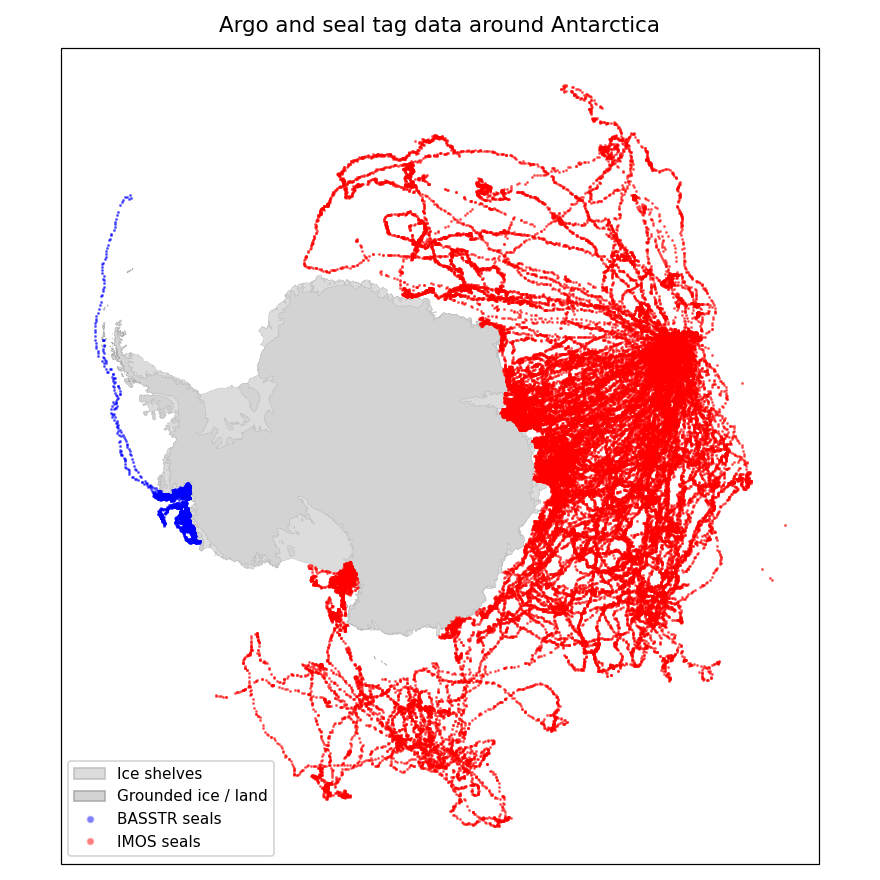

In [166]:
# --- Plot availability over Antarctica (EPSG:3031) ---
ps71 = ccrs.Stereographic(central_latitude=-90, central_longitude=0, true_scale_latitude=-71)
fig = plt.figure(figsize=(8, 8), dpi=110)
ax = plt.axes(projection=ps71)

# Antarctica basemap: grounded vs shelves
grounded_3031.plot(ax=ax, transform=ps71, color="lightgray", edgecolor="darkgray", linewidth=0.3, zorder=1)
shelves_3031.plot(ax=ax, transform=ps71, color="gainsboro", edgecolor="silver", linewidth=0.25, zorder=2)

# Add seal data points
# BASSTR seals (sealB) - in blue
if not sealB.empty:
    sealB_clean = sealB.dropna(subset=['LATITUDE_Argos', 'LONGITUDE_Argos'])
    ax.scatter(
        sealB_clean['LONGITUDE_Argos'], 
        sealB_clean['LATITUDE_Argos'],
        c='blue',
        s=1,  # Small point size
        alpha=0.5,
        transform=ccrs.PlateCarree(),
        label='BASSTR seals',
        zorder=3
    )

# IMOS seals (sealI) - in red
if not sealI.empty:
    sealI_clean = sealI.dropna(subset=['LATITUDE_Argos', 'LONGITUDE_Argos'])
    ax.scatter(
        sealI_clean['LONGITUDE_Argos'], 
        sealI_clean['LATITUDE_Argos'],
        c='red',
        s=1,  # Small point size
        alpha=0.5,
        transform=ccrs.PlateCarree(),
        label='IMOS seals',
        zorder=3
    )

# # Crop axes to Antarctica
# ax.set_xlim(-3000000, 3000000)  # 3000 km2
# ax.set_ylim(-3000000, 3000000)

# Updated legend with seal data
legend_handles = [
    Patch(facecolor="gainsboro", edgecolor="silver", label="Ice shelves"),
    Patch(facecolor="lightgray", edgecolor="darkgray", label="Grounded ice / land"),
]

# Add seal data to legend if present
if not sealB.empty:
    legend_handles.append(
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', 
                   markersize=5, alpha=0.5, label='BASSTR seals')
    )
if not sealI.empty:
    legend_handles.append(
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', 
                   markersize=5, alpha=0.5, label='IMOS seals')
    )

leg = ax.legend(handles=legend_handles, loc="lower left", frameon=True, framealpha=0.9)
for text in leg.get_texts():
    text.set_fontsize(10)

ax.set_title("Argo and seal tag data around Antarctica", fontsize=14, pad=10)
plt.tight_layout()
plt.show()

In [ ]:
%%time
if dataset == 'IMOS':
    sdata = sealI
elif dataset == 'BASSTR':
    sdata = sealB

# Find all seal tag matchups
vkind = 'seal'

lat_nm = 'LATITUDE_Argos'
lon_nm = 'LONGITUDE_Argos'
lat_ani = 'LATITUDE_Animotum'
lon_ani = 'LONGTITUDE_Animotum'
loc_err = 'Argos_Error_Radius'
qc_err1 = 'qc_ssm_x'
qc_err2 = 'qc_ssm_y' 
qc_err3 = 'qc_ssm_x_se'
qc_err4 = 'qc_ssm_y_se'
tdif = 'time_diff'
T_nm = 'CT_raw_bin1'
depth_nm = 'Pres_raw_bin1'
Tint_nm = 'CT_interp_1m'
depthint_nm = 1
convertC = 0 # already in C
platform_nm = 'smru_platform_code'
id_nm = 'Date'
date_nm = 'Date'
study_lat = -60

# Set up projections
transformer = Transformer.from_crs(source_crs, target_crs, always_xy=True)

# Subset seals to Antarctica
ant = sdata[(sdata[lat_nm] < study_lat)]
if dataset == 'IMOS':
    # ant = ant.iloc[:10000]
    # ant = ant.iloc[20000:30000]
    # ant = ant.iloc[30000:40000]
    ant = ant.iloc[40000:]
    
# ant = sdata[(sdata[lat_nm] < study_lat) & (sdata[lon_nm] > -142) & (sdata[lon_nm] < 150)]

# Overall spatial bounds (pad by a bit to be safe)
lon_min = ant[lon_nm].min()
lon_max = ant[lon_nm].max()
lat_min = ant[lat_nm].min() - 1
lat_max = ant[lat_nm].max() + 1
bbox_global = (lon_min, lat_min, lon_max, lat_max)

# Before the time bounds calculation, add:
print(f"Total rows in ant: {len(ant)}")
print(f"Valid dates: {ant[date_nm].notna().sum()}")
print(f"NaT dates: {ant[date_nm].isna().sum()}")
print(f"Date column dtype: {ant[date_nm].dtype}")
print(f"Sample dates:\n{ant[date_nm].head()}")

# Overall time bounds (add your ± time_add)
dt_min = ant[date_nm].min() - pd.Timedelta(days=time_add)
dt_max = ant[date_nm].max() + pd.Timedelta(days=time_add)
timeRange_global = f"{dt_min.strftime('%Y-%m-%dT%H:%M:%SZ')}/{dt_max.strftime('%Y-%m-%dT%H:%M:%SZ')}"

# ONE STAC search for all Landsat scenes
items = sut.search_stac(
    url,
    collection,
    gjson_outfile=seal_geojson,
    bbox=bbox_global,
    timeRange=timeRange_global,
)

# Open catalog once
catalog = intake.open_stac_item_collection(items)

# Build a GeoDataFrame of candidate scenes (Landsat 8 only)
scenes = []
for it in items:
    if it.id[3] != "8":
        continue
    scenes.append({
        "sceneid": it.id,
        "datetime": it.datetime,   # or it.properties["datetime"]
        "geometry": shape(it.geometry),
    })

scene_gdf = gpd.GeoDataFrame(scenes, geometry="geometry", crs="EPSG:4326")

# Sort by datetime
scene_gdf = scene_gdf.sort_values(by='datetime').reset_index(drop=True)
scene_gdf.tail()

os.remove(seal_geojson)

In [17]:
%%time

# --- Make sure seal data has naive datetimes ---
seal_gdf = gpd.GeoDataFrame(
    ant.copy(),
    geometry=gpd.points_from_xy(ant[lon_nm], ant[lat_nm]),
    crs="EPSG:4326",
)

# Seal timestamps: force tz-naive
seal_gdf[date_nm] = pd.to_datetime(seal_gdf[date_nm], errors="coerce")
seal_gdf[date_nm] = seal_gdf[date_nm].dt.tz_localize(None)

# --- Ensure scene datetimes are tz-naive ---
scene_gdf = scene_gdf.copy()
scene_gdf["datetime"] = pd.to_datetime(scene_gdf["datetime"], errors="coerce")
scene_gdf["datetime"] = scene_gdf["datetime"].dt.tz_localize(None)

# --- Spatial join to find which seals fall within which scene footprints ---
pairs = gpd.sjoin(
    seal_gdf,
    scene_gdf,
    how="inner",
    predicate="intersects",
)

# ----------------------------------------------
# Temporal filtering: keep only ±12 hours matches
# ----------------------------------------------

# Compute absolute time differences (now both tz-naive → no errors)
pairs[tdif] = (pairs[date_nm] - pairs["datetime"]).abs()

# Keep only seals within ±12 hours (adjust as needed)
pairs = pairs[pairs[tdif] <= pd.Timedelta(hours=12)]

print("Number of seal–scene matches:", len(pairs))
print(pairs.head())

NameError: name 'scene_gdf' is not defined

In [18]:
SSTfails = [
    'LO08_L1GT_052116_20201105_20201110_02_T2',
    'LO08_L1GT_052115_20201105_20201110_02_T2',
    'LC08_L1GT_115106_20220411_20220420_02_T2',
    'LC08_L1GT_115107_20220411_20220420_02_T2',
    'LC08_L1GT_116106_20220402_20220412_02_T2',
    'LC08_L1GT_136106_20220414_20220420_02_T2',
]

In [19]:
valid = []

# Before the loop, create a dictionary mapping scene IDs to STAC items
item_dict = {item.id: item for item in items if item.id[3] == '8'}

# pairs = pairs.sort_values(by='datetime')  # Sort by scene datetime

# for sceneid, group in tqdm(pairs.groupby("sceneid"), desc="Processing"):
grouped = list(pairs.groupby("sceneid"))
for sceneid, group in tqdm(grouped, desc="Processing"): #[5:6] with IMOS -/+1
    # Check for known repeatedly bad files that will kill the code  
    if sceneid in SSTfails:
        continue
            
    # Vectorized transform of ALL associated seal points to EPSG:3031
    lons = group[lon_nm].to_numpy()
    lats = group[lat_nm].to_numpy()
    xs, ys = transformer.transform(lons, lats)  # arrays, not scalar
    
    # Get the STAC item object
    item = item_dict[sceneid]
    
    scene = catalog[sceneid]
    scene = catalog[sceneid]
    # print(f"Scene bbox: {scene.metadata['bbox']}")
    # print(f"Scene center: {scene.metadata['geometry']['coordinates']}")
    
    # Check if crosses IDL
    west, south, east, north = scene.metadata['bbox']
    # if west > east:
    #     print("WARNING: Bounding box crosses IDL!")
    
    timestr = scene.metadata['datetime'].strftime('%H%M%S')
        
    outFile = f'{svalid_path}/{dataset}/{sceneid}_{timestr}_Cel.tif'

    # Either open existing SST COG, or create it once
    if os.path.isfile(outFile):
        print(f"{sceneid} - atm corr exists")
        SST = xr.open_dataset(outFile, chunks=dict(x=512, y=512), engine="rasterio")["band_data"]
        SST = SST.rio.write_crs("epsg:3031", inplace=True)
    else:
        print(f"{sceneid}")
        # Pass the STAC item object, not the string ID
        ls_scene = sut.landsat_to_xarray(item, catalog)
        ls_scene = ls_scene.rio.write_crs("epsg:3031", inplace=True)
        ls_scene = sut.create_masks(ls_scene, cloud_mask=True, ice_mask=True, ocean_mask=True)

        # Create and apply mask to keep only ocean pixels
        mask = np.ones(ls_scene.shape[1:])
        mask[ls_scene.mask != 3] = np.nan
        ls_thermal = mask * ls_scene.sel(band="lwir11").compute()

        # For speed, optionally subset thermal to a bbox around seal tag points and check for valid pixels
        minx, maxx = xs.min(), xs.max()
        miny, maxy = ys.min(), ys.max()
        thermal_check = sut.subset_img(ls_thermal, [minx, maxx], [miny, maxy])  # like you already do
        
        if np.all(np.isnan(thermal_check)):
            print(f'{sceneid} has no valid SST values in seal tag region')
            continue

        # Use band ratios for RF cloud pixel classification
        ####
        
        # Atmospheric correction using MODIS
        # Acquire and align MODIS water vapor (MOD/MYD07) to Landsat
        mod07, modfilenm = sut.open_MODIS(ls_scene, scene, modout_path)

        # Create water vapor files aligned and subsampled to Landsat
        spacing = [300, -300] # 300m sampling of MODIS data so that upsampling is easy and because 30m takes far too long
        try:
            WV_xr = sut.get_wv(ls_scene, mod07, spacing, WV, scene, interp=interp)
        except Exception as e:
            print(f"Skipping scene due to lack of atm correction: {e}")
            continue

        # Create SST by masking and using water vapor to apply atmospheric correction
        SST = sut.apply_retrieval(ls_thermal, scene, mask, WV_xr, atmcor, simT_transformer, simTOA_transformer, simWV_transformer)
        
        # Record MODIS water vapor image used in atmospheric correction
        SST.attrs["MODIS_WV"] = modfilenm

        # Save to a cloud-optimized Geotiff
        SST.rio.to_raster(raster_path=outFile, driver="COG")
        print (f'Mean SST: {np.nanmean(SST)}')

    if np.all(np.isnan(SST)):
        print(f'{sceneid} has no valid SST values')
        continue

    # For this scene, now have: SST in EPSG:3031
    
    # Apply calibration and thresholds to the full scene
    SST_calibrated = SST * calib_m + calib_b
    SST_calibrated = SST_calibrated.where(SST_calibrated >= lthresh, np.nan)

    # Extract nearest pixel for each seal
    for (idx, row), x_pt, y_pt in zip(group.iterrows(), xs, ys):

        # Create search area around THIS specific seal point (in lat/lon) and its animotum location
        lsat, lstd, SST_sub = sut.sub_to_point(row, lat_nm, lon_nm, dist, source_crs, target_crs, SST_calibrated)
        lsat_ani, lstd_ani, SST_sub_ani = sut.sub_to_point(row, lat_ani, lon_ani, dist, source_crs, target_crs, SST_calibrated)
        
        # Get center pixel value
        center_value = sut.center_pix(SST_sub, x_pt, y_pt)
        center_value_ani = sut.center_pix(SST_sub_ani, x_pt, y_pt)

        argo_temp = np.around(row[T_nm] - convertC, 2)
        argo_temp_interp = np.around(row[Tint_nm] - convertC, 2)

        valid.append([
            row[date_nm],
            sceneid,
            lsat,
            lstd,
            center_value,
            SST_sub.max().values.item(),
            SST_sub.min().values.item(),
            lsat_ani,
            lstd_ani,
            center_value_ani,
            f'{row[platform_nm]}-{row[date_nm]}',
            argo_temp,
            T_nm,
            row[depth_nm],
            argo_temp_interp,
            Tint_nm,
            depthint_nm,
            row[platform_nm],
            row[lat_nm],
            row[lon_nm],
            row[lat_ani],
            row[lon_ani],
            row[loc_err],
            [row[qc_err1],row[qc_err2],row[qc_err3],row[qc_err4]],
            row[tdif],
        ])
        print (f'Argos temp: {argo_temp}, Landsat 8 mean: {lsat}+/-{lstd}, Lsat AniMotum mean: {lsat_ani}+/-{lstd_ani}')

    try:
        del ls_scene, scene, ls_thermal, thermal_check, mod07, WV_xr, SST, SST_calibrated, SST_sub
    except:
        pass

    gc.collect()
    
# Put data into DataFrame and save    
lsat_mod_df = pd.DataFrame(valid,columns=headers)
out_df = lsatpath / f'Landsat_{vkind}{dataset}_validation_20260202_alltime_{dist}_3.csv'
lsat_mod_df.to_csv(out_df)

NameError: name 'items' is not defined

In [60]:
# Put data into DataFrame and save    
lsat_mod_df = pd.DataFrame(valid,columns=headers)
out_df = lsatpath / f'Landsat_{vkind}{dataset}_validation_20260202_alltime_{dist}_3.csv'
lsat_mod_df.to_csv(out_df)

## Check interpolation outcome [under construction]

In [ ]:
# # Use the function with your directory path
# stu.create_geotiff_dropdown(SSTpath)

In [ ]:
vmin = 0
vmax = 0.6

(-70.0297, -64.7881)

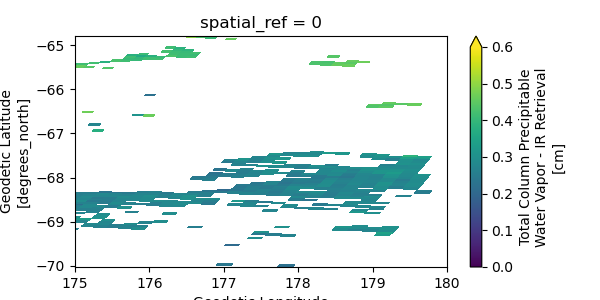

In [93]:
wv0 = mod07[WV].where(
    (mod07.Longitude >= 150) & (mod07.Longitude <= 179.7),
    drop=True  # Keeps shape, sets outside values to NaN
)

# lat, lon = mod07.Latitude, mod07.Longitude
# no interpolation
plt.figure(figsize=(6, 3))
(wv0).plot(x='Longitude',y='Latitude',vmin=vmin,vmax=vmax)
plt.xlim([175,180])
plt.ylim([-70.0297, -64.7881])

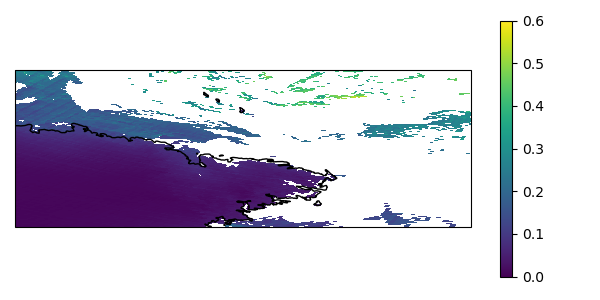

In [97]:
data0 = wv0
plt.figure(figsize=(6, 3))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_global()
cb = ax.pcolormesh(data0.Longitude,data0.Latitude,data0.values,vmin=vmin,vmax=vmax,transform=ccrs.PlateCarree())
ax.coastlines()
plt.xlim([150,180])
plt.ylim([-75.0297, -64.7881])
cbar = plt.colorbar(cb)
plt.tight_layout()

In [27]:
# Read in desired variables
ULX = ls_scene.x[0] 
ULY = ls_scene.y[0]  
LRX = ls_scene.x[-1] 
LRY = ls_scene.y[-1] 
box = [ULX,LRX,ULY,LRY]

#Extract desired datasets from MODIS file from lookup key (automatically scaled by xarray so no need to do it here)
data = mod07[WV].values
lat, lon = mod07.Latitude, mod07.Longitude

In [77]:
%%time
# Run using entire MODIS image for interpolation
target_spacing_m=1500

# Check if lat/lon are xarray DataArrays or numpy arrays
if hasattr(lat, 'values'):
    lat_vals = lat.values
    lon_vals = lon.values
else:
    lat_vals = lat
    lon_vals = lon

# Get Landsat scene extent from metadata
lon_min, lat_min, lon_max, lat_max = scene.metadata['bbox']

# Check if LANDSAT crosses IDL
landsat_crosses_idl = (lon_max < lon_min) or (lon_max - lon_min > 180)

# Check if MODIS data crosses IDL
modis_lon_span = lon_vals.max() - lon_vals.min()
modis_crosses_idl = modis_lon_span > 180

# If EITHER crosses, shift BOTH to 0-360
crosses_idl = landsat_crosses_idl or modis_crosses_idl

# Shift coordinates BEFORE masking
if crosses_idl:
    if landsat_crosses_idl and modis_crosses_idl:
        print("⚠️  Both Landsat and MODIS cross IDL! Shifting to 0-360 range")
    elif landsat_crosses_idl:
        print("⚠️  Landsat crosses IDL! Shifting to 0-360 range")
    else:
        print("⚠️  MODIS crosses IDL! Shifting to 0-360 range")
    
    # Shift MODIS longitude array
    lon_shifted = lon_vals.copy()
    lon_shifted[lon_shifted < 0] += 360
    
    # Shift Landsat bounds
    if lon_min < 0:
        lon_min += 360
    if lon_max < 0:
        lon_max += 360
    
    print(f"Shifted Landsat extent: lon [{lon_min:.4f}, {lon_max:.4f}]")
    print(f"Shifted MODIS extent: lon [{lon_shifted.min():.4f}, {lon_shifted.max():.4f}]")
else:
    lon_shifted = lon_vals

print(f"Landsat extent: lon [{lon_min:.4f}, {lon_max:.4f}], lat [{lat_min:.4f}, {lat_max:.4f}]")

# Create mask for valid data within Landsat extent
buffer_deg = 2.0  # Match open_MODIS buffer

valid_mask = np.isfinite(data) & (data > 0)
spatial_mask = (
    (lon_shifted >= lon_min - buffer_deg) &
    (lon_shifted <= lon_max + buffer_deg) &
    (lat_vals >= lat_min - buffer_deg) &
    (lat_vals <= lat_max + buffer_deg)
)

combined_mask = valid_mask #& spatial_mask
points_in_scene = np.sum(combined_mask)
print(f"MODIS points within Landsat extent: {points_in_scene}")

if points_in_scene < 10:
    raise ValueError(
        f"Too few MODIS points overlap Landsat scene: {points_in_scene}. "
        f"Cannot interpolate reliably."
    )

# Create DataFrame with explicit float64 dtype
df = pd.DataFrame({
    'longitude': lon_shifted[combined_mask].astype(np.float64),
    'latitude': lat_vals[combined_mask].astype(np.float64),
    'water_vapor': data[combined_mask].astype(np.float64)
})

print(f"Valid MODIS data points for interpolation: {len(df)}")
print(f"Mean water vapor: {df.water_vapor.mean():.4f}")

# Get data extent
lon_data_min = df.longitude.min()
lon_data_max = df.longitude.max()
lat_data_min = df.latitude.min()
lat_data_max = df.latitude.max()

print(f"Data extent: lon [{lon_data_min:.4f}, {lon_data_max:.4f}], lat [{lat_data_min:.4f}, {lat_data_max:.4f}]")

# Decide interpolation extent based on data density
# First, calculate a preliminary data density estimate
# avg_lat_prelim = (lat_min + lat_max) / 2
avg_lat_prelim = (lat_vals.min() + lat_vals.max()) / 2
spacing_lat_deg_prelim = target_spacing_m / 111000.0
spacing_lon_deg_prelim = target_spacing_m / (111000.0 * np.cos(np.radians(avg_lat_prelim)))
interp_buffer = 2.0  # degrees

# Preliminary grid size using Landsat extent
# lon_grid_min_prelim = lon_min - interp_buffer
# lon_grid_max_prelim = lon_max + interp_buffer
# lat_grid_min_prelim = lat_min - interp_buffer
# lat_grid_max_prelim = lat_max + interp_buffer
lon_grid_min_prelim = 150 
lon_grid_max_prelim = lon_data_max 
lat_grid_min_prelim = lat_data_min
lat_grid_max_prelim = lat_data_max 

nx_prelim = int(np.round((lon_grid_max_prelim - lon_grid_min_prelim) / spacing_lon_deg_prelim))
ny_prelim = int(np.round((lat_grid_max_prelim - lat_grid_min_prelim) / spacing_lat_deg_prelim))
total_cells_prelim = nx_prelim * ny_prelim
data_density_prelim = total_cells_prelim / len(df)

print(f"Preliminary data density: 1 MODIS point per {data_density_prelim:.1f} grid cells")

lon_grid_min = 150
lon_grid_max = lon_data_max
lat_grid_min = lat_data_min
lat_grid_max = lat_data_max

print(f"Interpolation extent: lon [{lon_grid_min:.4f}, {lon_grid_max:.4f}], lat [{lat_grid_min:.4f}, {lat_grid_max:.4f}]")    

avg_lat = (lat_grid_min + lat_grid_max) / 2

# Convert spacing from meters to degrees
spacing_lat_deg = target_spacing_m / 111000.0
spacing_lon_deg = target_spacing_m / (111000.0 * np.cos(np.radians(avg_lat)))

print(f"Target spacing: {target_spacing_m}m")
print(f"  → lon: {spacing_lon_deg:.8f}°")
print(f"  → lat: {spacing_lat_deg:.8f}°")

# Calculate grid dimensions based on LANDSAT extent (not data extent)
nx = int(np.round((lon_grid_max - lon_grid_min) / spacing_lon_deg))
ny = int(np.round((lat_grid_max - lat_grid_min) / spacing_lat_deg))
nx = max(nx, 2)
ny = max(ny, 2)

# Adjust max bounds to fit exactly
lon_grid_max_adj = lon_grid_min + nx * spacing_lon_deg
lat_grid_max_adj = lat_grid_min + ny * spacing_lat_deg

region = [lon_grid_min, lon_grid_max_adj, lat_grid_min, lat_grid_max_adj]

total_cells = nx * ny
data_density = total_cells / len(df)

print(f"Interpolation grid: {nx} x {ny} = {total_cells:,} cells")
print(f"Data density: 1 MODIS point per {data_density:.1f} grid cells")

# After calculating data_density:
print(f"Data density: 1 MODIS point per {data_density:.1f} grid cells")

spacing_str = f"{spacing_lon_deg:.15f}/{spacing_lat_deg:.15f}"

# Blockmedian preprocessing
print("Running blockmedian...")
df_blocked = pygmt.blockmedian(
    data=df[['longitude', 'latitude', 'water_vapor']],
    region=region,
    spacing=spacing_str,
)

points_reduced = len(df) - len(df_blocked)

if len(df_blocked) < 10:
    raise ValueError(f"Blockmedian left too few points: {len(df_blocked)}")

# Surface interpolation
print("Running surface interpolation...")
grid = pygmt.surface(
    data=df_blocked,
    region=region,
    spacing=spacing_str,
    tension=0.95,
)

print(f"✓ Interpolation complete. Output grid: {grid.shape}")

# Rename coordinates
grid = grid.rename({'x': 'lon', 'y': 'lat'})

if crosses_idl:
    lon_coords = grid.lon.values.copy()
    grid_span = lon_coords.max() - lon_coords.min()
    
    # For IDL-crossing scenes, keep in 0-360 to maintain continuity
    if grid_span < 20:  # Typical Landsat scene is 5-15° wide
        print(f"Grid spans {grid_span:.2f}° - keeping in 0-360 space for IDL continuity")
        print(f"Grid lon range: {lon_coords.min():.2f} to {lon_coords.max():.2f}")
        # Don't shift back - keep as-is
    else:
        print(f"Grid spans {grid_span:.2f}° - unexpected, keeping as-is")
    
    grid = grid.assign_coords({'lon': lon_coords})

⚠️  Both Landsat and MODIS cross IDL! Shifting to 0-360 range
Shifted Landsat extent: lon [176.9326, 182.6964]
Shifted MODIS extent: lon [128.7921, 199.2653]
Landsat extent: lon [176.9326, 182.6964], lat [-68.0699, -65.7992]
MODIS points within Landsat extent: 31240
Valid MODIS data points for interpolation: 31240
Mean water vapor: 0.0803
Data extent: lon [130.8745, 192.9410], lat [-77.6542, -61.0945]
Preliminary data density: 1 MODIS point per 49.4 grid cells
Interpolation extent: lon [150.0000, 192.9410], lat [-77.6542, -61.0945]
Target spacing: 1500m
  → lon: 0.03836220°
  → lat: 0.01351351°
Interpolation grid: 1119 x 1225 = 1,370,775 cells
Data density: 1 MODIS point per 43.9 grid cells
Data density: 1 MODIS point per 43.9 grid cells
Running blockmedian...
Running surface interpolation...
✓ Interpolation complete. Output grid: (1226, 1120)
Grid spans 42.93° - unexpected, keeping as-is
CPU times: user 24.2 s, sys: 409 ms, total: 24.6 s
Wall time: 23 s


Number of points: 31240
Mean difference: 0.000302
RMSE: 0.005950
Max abs difference: 0.028659


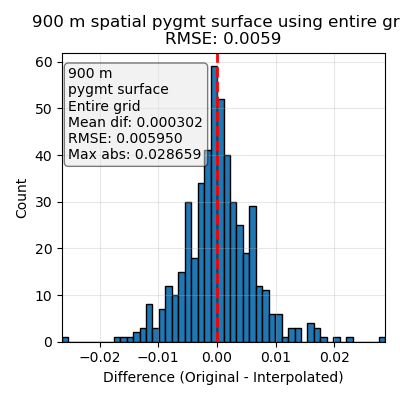

In [94]:
# Compare to original using xarray interpolation at 900m - 58.8s

lat, lon = mod07.Latitude, mod07.Longitude

# Crop to Landsat extent and flatten the 2D arrays to 1D
lon_flat = (spatial_mask*mod07.Longitude.values).flatten()
lat_flat = (spatial_mask*mod07.Latitude.values).flatten()
wv_flat = (spatial_mask*mod07[WV].values).flatten()

# Remove NaN values
valid_mask = np.isfinite(wv_flat)
lon_valid = lon_flat[valid_mask]
lat_valid = lat_flat[valid_mask]
wv_valid = wv_flat[valid_mask]

# Create dataset with original points
original_points = xr.Dataset({
    'lon': (['points'], lon_valid),
    'lat': (['points'], lat_valid),
    'wv_original': (['points'], wv_valid)
})

# Interpolate grid to original points
interpolated_wv = grid.interp(
    lon=original_points.lon,
    lat=original_points.lat,
    method='linear'
).values

# Calculate difference
difference = wv_valid - interpolated_wv

print(f"Number of points: {len(wv_valid)}")
print(f"Mean difference: {np.nanmean(difference):.6f}")
print(f"RMSE: {np.sqrt(np.nanmean(difference**2)):.6f}")
print(f"Max abs difference: {np.nanmax(np.abs(difference)):.6f}")

plt.figure(figsize=(4, 4))
plt.hist(difference[np.isfinite(difference)], bins=50, edgecolor='black')
plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Difference (Original - Interpolated)')
plt.xlim([np.nanmin(difference),np.nanmax(difference)])
plt.ylabel('Count')
plt.text(
    0.02, 0.95,  # x, y in axes coordinates (0-1)
    f'900 m\n'
    f'pygmt surface\n'
    f'Entire grid\n'
    f'Mean dif: {np.nanmean(difference):.6f}\n'
    f'RMSE: {np.sqrt(np.nanmean(difference**2)):.6f}\n'
    f'Max abs: {np.nanmax(np.abs(difference)):.6f}',
    transform=plt.gca().transAxes,  # Use axes coordinates instead of data coordinates
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='0.9', alpha=0.5)
)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Number of points: 31240
Mean difference: 0.000302
RMSE: 0.005950
Max abs difference: 0.028659


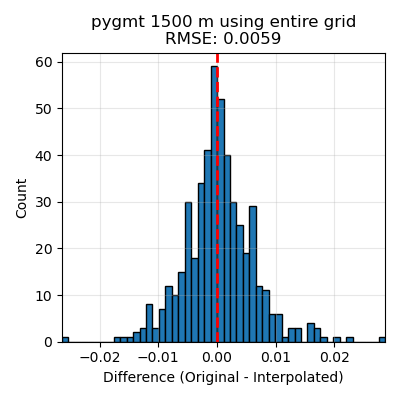

In [80]:
# Compare to original using xarray interpolation 1500 m # 22.8

lat, lon = mod07.Latitude, mod07.Longitude

# Crop to Landsat extent and flatten the 2D arrays to 1D
lon_flat = (spatial_mask*mod07.Longitude.values).flatten()
lat_flat = (spatial_mask*mod07.Latitude.values).flatten()
wv_flat = (spatial_mask*mod07[WV].values).flatten()

# Remove NaN values
valid_mask = np.isfinite(wv_flat)
lon_valid = lon_flat[valid_mask]
lat_valid = lat_flat[valid_mask]
wv_valid = wv_flat[valid_mask]

# Create dataset with original points
original_points = xr.Dataset({
    'lon': (['points'], lon_valid),
    'lat': (['points'], lat_valid),
    'wv_original': (['points'], wv_valid)
})

# Interpolate grid to original points
interpolated_wv = grid.interp(
    lon=original_points.lon,
    lat=original_points.lat,
    method='linear'
).values

# Calculate difference
difference = wv_valid - interpolated_wv

print(f"Number of points: {len(wv_valid)}")
print(f"Mean difference: {np.nanmean(difference):.6f}")
print(f"RMSE: {np.sqrt(np.nanmean(difference**2)):.6f}")
print(f"Max abs difference: {np.nanmax(np.abs(difference)):.6f}")

plt.figure(figsize=(4, 4))
plt.hist(difference[np.isfinite(difference)], bins=50, edgecolor='black')
plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Difference (Original - Interpolated)')
plt.xlim([np.nanmin(difference),np.nanmax(difference)])
plt.ylabel('Count')
plt.text(
    0.02, 0.95,  # x, y in axes coordinates (0-1)
    f'1500 m\n'
    f'pygmt surface\n'
    f'Entire grid\n'
    f'Mean dif: {np.nanmean(difference):.6f}\n'
    f'RMSE: {np.sqrt(np.nanmean(difference**2)):.6f}\n'
    f'Max abs: {np.nanmax(np.abs(difference)):.6f}',
    transform=plt.gca().transAxes,  # Use axes coordinates instead of data coordinates
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='0.9', alpha=0.5)
)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [50]:
%%time

# # Run using Landsat extent for interpolation
target_spacing_m=900

# Check if lat/lon are xarray DataArrays or numpy arrays
if hasattr(lat, 'values'):
    lat_vals = lat.values
    lon_vals = lon.values
else:
    lat_vals = lat
    lon_vals = lon

# Get Landsat scene extent from metadata
lon_min, lat_min, lon_max, lat_max = scene.metadata['bbox']

# Check if LANDSAT crosses IDL
landsat_crosses_idl = (lon_max < lon_min) or (lon_max - lon_min > 180)

# Check if MODIS data crosses IDL
modis_lon_span = lon_vals.max() - lon_vals.min()
modis_crosses_idl = modis_lon_span > 180

# If EITHER crosses, shift BOTH to 0-360
crosses_idl = landsat_crosses_idl or modis_crosses_idl

# Shift coordinates BEFORE masking
if crosses_idl:
    if landsat_crosses_idl and modis_crosses_idl:
        print("⚠️  Both Landsat and MODIS cross IDL! Shifting to 0-360 range")
    elif landsat_crosses_idl:
        print("⚠️  Landsat crosses IDL! Shifting to 0-360 range")
    else:
        print("⚠️  MODIS crosses IDL! Shifting to 0-360 range")
    
    # Shift MODIS longitude array
    lon_shifted = lon_vals.copy()
    lon_shifted[lon_shifted < 0] += 360
    
    # Shift Landsat bounds
    if lon_min < 0:
        lon_min += 360
    if lon_max < 0:
        lon_max += 360
    
    print(f"Shifted Landsat extent: lon [{lon_min:.4f}, {lon_max:.4f}]")
    print(f"Shifted MODIS extent: lon [{lon_shifted.min():.4f}, {lon_shifted.max():.4f}]")
else:
    lon_shifted = lon_vals

print(f"Landsat extent: lon [{lon_min:.4f}, {lon_max:.4f}], lat [{lat_min:.4f}, {lat_max:.4f}]")

# Create mask for valid data within Landsat extent
buffer_deg = 2.0  # Match open_MODIS buffer

valid_mask = np.isfinite(data) & (data > 0)
spatial_mask = (
    (lon_shifted >= lon_min - buffer_deg) &
    (lon_shifted <= lon_max + buffer_deg) &
    (lat_vals >= lat_min - buffer_deg) &
    (lat_vals <= lat_max + buffer_deg)
)

combined_mask = valid_mask #& spatial_mask
points_in_scene = np.sum(combined_mask)
print(f"MODIS points within Landsat extent: {points_in_scene}")

if points_in_scene < 10:
    raise ValueError(
        f"Too few MODIS points overlap Landsat scene: {points_in_scene}. "
        f"Cannot interpolate reliably."
    )

# Create DataFrame with explicit float64 dtype
df = pd.DataFrame({
    'longitude': lon_shifted[combined_mask].astype(np.float64),
    'latitude': lat_vals[combined_mask].astype(np.float64),
    'water_vapor': data[combined_mask].astype(np.float64)
})

print(f"Valid MODIS data points for interpolation: {len(df)}")
print(f"Mean water vapor: {df.water_vapor.mean():.4f}")

# Get data extent
lon_data_min = df.longitude.min()
lon_data_max = df.longitude.max()
lat_data_min = df.latitude.min()
lat_data_max = df.latitude.max()

print(f"Data extent: lon [{lon_data_min:.4f}, {lon_data_max:.4f}], lat [{lat_data_min:.4f}, {lat_data_max:.4f}]")

# Decide interpolation extent based on data density
# First, calculate a preliminary data density estimate
avg_lat_prelim = (lat_min + lat_max) / 2
spacing_lat_deg_prelim = target_spacing_m / 111000.0
spacing_lon_deg_prelim = target_spacing_m / (111000.0 * np.cos(np.radians(avg_lat_prelim)))
interp_buffer = 2.0  # degrees

# Preliminary grid size using Landsat extent
lon_grid_min_prelim = lon_min - interp_buffer
lon_grid_max_prelim = lon_max + interp_buffer
lat_grid_min_prelim = lat_min - interp_buffer
lat_grid_max_prelim = lat_max + interp_buffer

nx_prelim = int(np.round((lon_grid_max_prelim - lon_grid_min_prelim) / spacing_lon_deg_prelim))
ny_prelim = int(np.round((lat_grid_max_prelim - lat_grid_min_prelim) / spacing_lat_deg_prelim))
total_cells_prelim = nx_prelim * ny_prelim
data_density_prelim = total_cells_prelim / len(df)

print(f"Preliminary data density: 1 MODIS point per {data_density_prelim:.1f} grid cells")

# If data is too sparse, use actual data extent instead of Landsat extent
if data_density_prelim > 200:
    print(f"⚠️  Sparse data detected! Using actual data extent to avoid extrapolation.")
    # Use data extent with smaller buffer
    interp_buffer = 0.5  # Smaller buffer for sparse data
    lon_grid_min = lon_data_min - interp_buffer
    lon_grid_max = lon_data_max + interp_buffer
    lat_grid_min = lat_data_min - interp_buffer
    lat_grid_max = lat_data_max + interp_buffer
else:
    # Use Landsat extent for interpolation grid (with 2 degree buffer)
    lon_grid_min = lon_min - interp_buffer
    lon_grid_max = lon_max + interp_buffer
    lat_grid_min = lat_min - interp_buffer
    lat_grid_max = lat_max + interp_buffer

print(f"Interpolation extent: lon [{lon_grid_min:.4f}, {lon_grid_max:.4f}], lat [{lat_grid_min:.4f}, {lat_grid_max:.4f}]")    

avg_lat = (lat_grid_min + lat_grid_max) / 2

# Convert spacing from meters to degrees
spacing_lat_deg = target_spacing_m / 111000.0
spacing_lon_deg = target_spacing_m / (111000.0 * np.cos(np.radians(avg_lat)))

print(f"Target spacing: {target_spacing_m}m")
print(f"  → lon: {spacing_lon_deg:.8f}°")
print(f"  → lat: {spacing_lat_deg:.8f}°")

# Calculate grid dimensions based on LANDSAT extent (not data extent)
nx = int(np.round((lon_grid_max - lon_grid_min) / spacing_lon_deg))
ny = int(np.round((lat_grid_max - lat_grid_min) / spacing_lat_deg))
nx = max(nx, 2)
ny = max(ny, 2)

# Adjust max bounds to fit exactly
lon_grid_max_adj = lon_grid_min + nx * spacing_lon_deg
lat_grid_max_adj = lat_grid_min + ny * spacing_lat_deg

region = [lon_grid_min, lon_grid_max_adj, lat_grid_min, lat_grid_max_adj]

total_cells = nx * ny
data_density = total_cells / len(df)

print(f"Interpolation grid: {nx} x {ny} = {total_cells:,} cells")
print(f"Data density: 1 MODIS point per {data_density:.1f} grid cells")

# After calculating data_density:
print(f"Data density: 1 MODIS point per {data_density:.1f} grid cells")

spacing_str = f"{spacing_lon_deg:.15f}/{spacing_lat_deg:.15f}"

# Blockmedian preprocessing
print("Running blockmedian...")
df_blocked = pygmt.blockmedian(
    data=df[['longitude', 'latitude', 'water_vapor']],
    region=region,
    spacing=spacing_str,
)

points_reduced = len(df) - len(df_blocked)

if len(df_blocked) < 10:
    raise ValueError(f"Blockmedian left too few points: {len(df_blocked)}")

# Surface interpolation
print("Running surface interpolation...")
grid = pygmt.surface(
    data=df_blocked,
    region=region,
    spacing=spacing_str,
    tension=0.95,
)

print(f"✓ Interpolation complete. Output grid: {grid.shape}")

# Rename coordinates
grid = grid.rename({'x': 'lon', 'y': 'lat'})

if crosses_idl:
    lon_coords = grid.lon.values.copy()
    grid_span = lon_coords.max() - lon_coords.min()
    
    # For IDL-crossing scenes, keep in 0-360 to maintain continuity
    if grid_span < 20:  # Typical Landsat scene is 5-15° wide
        print(f"Grid spans {grid_span:.2f}° - keeping in 0-360 space for IDL continuity")
        print(f"Grid lon range: {lon_coords.min():.2f} to {lon_coords.max():.2f}")
        # Don't shift back - keep as-is
    else:
        print(f"Grid spans {grid_span:.2f}° - unexpected, keeping as-is")
    
    grid = grid.assign_coords({'lon': lon_coords})

⚠️  Both Landsat and MODIS cross IDL! Shifting to 0-360 range
Shifted Landsat extent: lon [176.9326, 182.6964]
Shifted MODIS extent: lon [128.7921, 199.2653]
Landsat extent: lon [176.9326, 182.6964], lat [-68.0699, -65.7992]
MODIS points within Landsat extent: 31240
Valid MODIS data points for interpolation: 31240
Mean water vapor: 0.0803
Data extent: lon [130.8745, 192.9410], lat [-77.6542, -61.0945]
Preliminary data density: 1 MODIS point per 11.7 grid cells
Interpolation extent: lon [174.9326, 184.6964], lat [-70.0699, -63.7992]
Target spacing: 900m
  → lon: 0.02069541°
  → lat: 0.00810811°
Interpolation grid: 472 x 773 = 364,856 cells
Data density: 1 MODIS point per 11.7 grid cells
Data density: 1 MODIS point per 11.7 grid cells
Running blockmedian...
Running surface interpolation...
✓ Interpolation complete. Output grid: (774, 473)
Grid spans 9.77° - keeping in 0-360 space for IDL continuity
Grid lon range: 174.93 to 184.70
CPU times: user 5.46 s, sys: 43.5 ms, total: 5.5 s
Wall t

Number of points: 31240
Mean difference: 0.000216
RMSE: 0.005949
Max abs difference: 0.043231


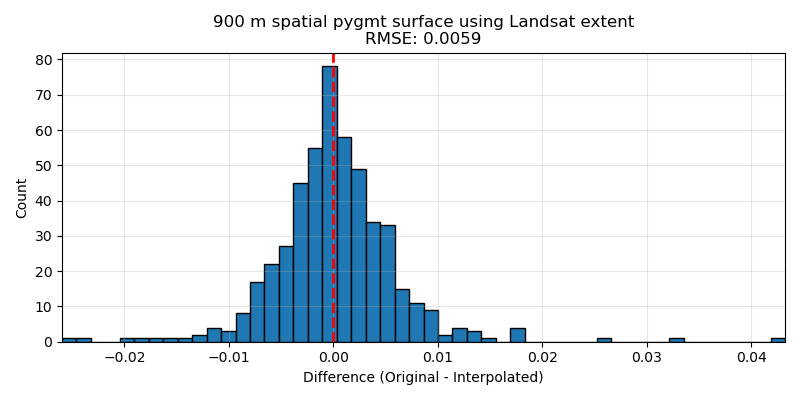

In [51]:
# Compare to original using xarray interpolation # 5.16 s

lat, lon = mod07.Latitude, mod07.Longitude

# Flatten the 2D arrays to 1D
lon_flat = lon*spatial_extent.values.flatten()
lat_flat = lat.values.flatten()
wv_flat = mod07[WV].values.flatten()

# Remove NaN values
valid_mask = np.isfinite(wv_flat)
lon_valid = lon_flat[valid_mask]
lat_valid = lat_flat[valid_mask]
wv_valid = wv_flat[valid_mask]

# Create dataset with original points
original_points = xr.Dataset({
    'lon': (['points'], lon_valid),
    'lat': (['points'], lat_valid),
    'wv_original': (['points'], wv_valid)
})

# Interpolate grid to original points
interpolated_wv = grid.interp(
    lon=original_points.lon,
    lat=original_points.lat,
    method='linear'
).values

# Calculate difference
difference = wv_valid - interpolated_wv

print(f"Number of points: {len(wv_valid)}")
print(f"Mean difference: {np.nanmean(difference):.6f}")
print(f"RMSE: {np.sqrt(np.nanmean(difference**2)):.6f}")
print(f"Max abs difference: {np.nanmax(np.abs(difference)):.6f}")

plt.figure(figsize=(4, 4))
plt.hist(difference[np.isfinite(difference)], bins=50, edgecolor='black')
plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Difference (Original - Interpolated)')
plt.xlim([np.nanmin(difference),np.nanmax(difference)])
plt.ylabel('Count')
plt.text(
    0.02, 0.95,  # x, y in axes coordinates (0-1)
    f'900 m\n'
    f'pygmt surface\n'
    f'Landsat extent\n'
    f'Mean dif: {np.nanmean(difference):.6f}\n'
    f'RMSE: {np.sqrt(np.nanmean(difference**2)):.6f}\n'
    f'Max abs: {np.nanmax(np.abs(difference)):.6f}',
    transform=plt.gca().transAxes,  # Use axes coordinates instead of data coordinates
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='0.9', alpha=0.5)
)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Number of points: 31240
Mean difference: 0.000040
RMSE: 0.006245
Max abs difference: 0.034146


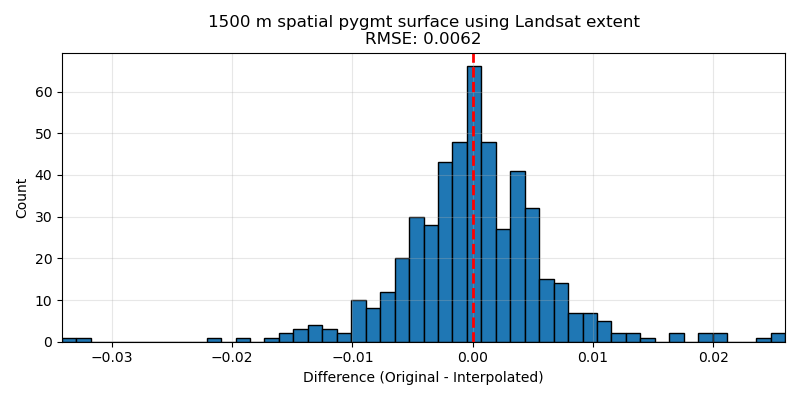

In [48]:
# Compare to original using xarray interpolation # 1.76 s

lat, lon = mod07.Latitude, mod07.Longitude

# Flatten the 2D arrays to 1D
lon_flat = lon.values.flatten()
lat_flat = lat.values.flatten()
wv_flat = mod07[WV].values.flatten()

# Remove NaN values
valid_mask = np.isfinite(wv_flat)
lon_valid = lon_flat[valid_mask]
lat_valid = lat_flat[valid_mask]
wv_valid = wv_flat[valid_mask]

# Create dataset with original points
original_points = xr.Dataset({
    'lon': (['points'], lon_valid),
    'lat': (['points'], lat_valid),
    'wv_original': (['points'], wv_valid)
})

# Interpolate grid to original points
interpolated_wv = grid.interp(
    lon=original_points.lon,
    lat=original_points.lat,
    method='linear'
).values

# Calculate difference
difference = wv_valid - interpolated_wv

print(f"Number of points: {len(wv_valid)}")
print(f"Mean difference: {np.nanmean(difference):.6f}")
print(f"RMSE: {np.sqrt(np.nanmean(difference**2)):.6f}")
print(f"Max abs difference: {np.nanmax(np.abs(difference)):.6f}")

plt.figure(figsize=(4, 4))
plt.hist(difference[np.isfinite(difference)], bins=50, edgecolor='black')
plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Difference (Original - Interpolated)')
plt.xlim([np.nanmin(difference),np.nanmax(difference)])
plt.ylabel('Count')
plt.text(
    0.02, 0.95,  # x, y in axes coordinates (0-1)
    f'1500 m\n'
    f'pygmt surface\n'
    f'Landsat extent\n'
    f'Mean dif: {np.nanmean(difference):.6f}\n'
    f'RMSE: {np.sqrt(np.nanmean(difference**2)):.6f}\n'
    f'Max abs: {np.nanmax(np.abs(difference)):.6f}',
    transform=plt.gca().transAxes,  # Use axes coordinates instead of data coordinates
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='0.9', alpha=0.5)
)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

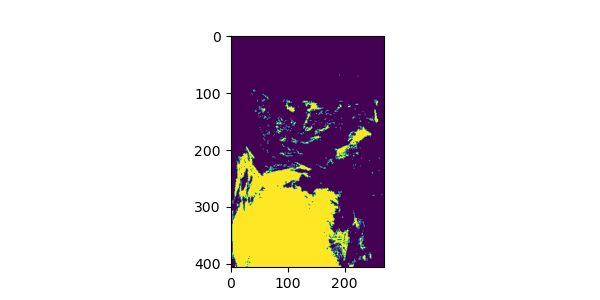

In [131]:
plt.figure(figsize=(6, 3))
plt.imshow(combined_mask)
# plt.xlim([175,180])
# plt.ylim([-70.0297, -64.7881])

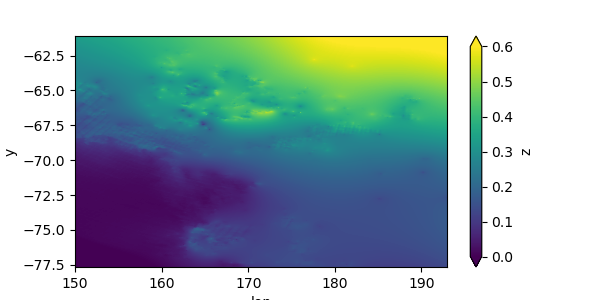

In [143]:
plt.figure(figsize=(6, 3))
(grid).plot(x='lon',y='lat',vmin=vmin,vmax=vmax)
# plt.xlim([175,180])
# plt.ylim([-70.0297, -64.7881])

In [ ]:
# Plot water vapor data
data0 = grid-wv0
plt.figure(figsize=(6, 3))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_global()
cb = ax.pcolormesh(data0.lon,data0.lat,data0.values,vmin=0,vmax=0.6,transform=ccrs.PlateCarree())
ax.coastlines()
# plt.xlim([150,180])
# plt.ylim([-75.0297, -64.7881])
plt.xlim([175,180])
plt.ylim([-70.0297, -64.7881])
cbar = plt.colorbar(cb)
plt.tight_layout()

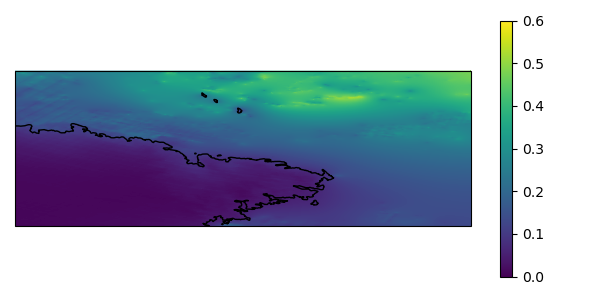

In [146]:
# Plot water vapor data ***need to comment out the delete code above for this to work
data0 = grid
plt.figure(figsize=(6, 3))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_global()
cb = ax.pcolormesh(data0.lon,data0.lat,data0.values,vmin=0,vmax=0.6,transform=ccrs.PlateCarree())
ax.coastlines()
plt.xlim([150,180])
plt.ylim([-75.0297, -64.7881])
cbar = plt.colorbar(cb)
plt.tight_layout()

In [ ]:
indiciesMOD,lines,samples,lat,lon = MODISlookup(mod07,ls_scene,box,spacing,scene,interpgrid=grid)
data = grid.values

In [66]:
wv2 = mask*WV_xr.values

# # Get rid of low outliers from over ice, cutoff for 98.5%
# outlier = np.quantile(wv2[np.isfinite(wv2)],0.01)
# mask2 = np.ones(wv2.shape)
# mask2[wv2<outlier] = np.nan

# wv3 = mask2*wv2
wv3 = np.around(wv2,decimals=5)

means = np.nanmean(wv3)
print (f'Mean water vapor value is: {means}, min: {np.nanmin(wv3)}, max: {np.nanmax(wv3)}')

# Select appropriate atmospheric correction coefficients
month = scene.metadata['datetime'].month
a_mo = f'{2}'.zfill(2)
a1 = atmcor[a_mo]['a1']
a2 = atmcor[a_mo]['a2']
a3 = atmcor[a_mo]['a3']


Mean water vapor value is: 0.3735446636957495, min: 0.23155, max: 0.48399


In [33]:
# Calculate radiances using MTL data
s3 = boto3.client("s3")

# Extract bucket and key for json MTL file
# Example: bucket = "usgs-landsat" ; key = "collection02/level-1/standard/oli-tirs/2019/002/113/LC08_L1GT_002113_20190206_20201016_02_T2/LC08_L1GT_002113_20190206_20201016_02_T2_MTL.json"
s3_url = scene['MTL.json'].metadata['alternate']['s3']['href']
bucket = s3_url.split('/')[2].strip()
key = s3_url.split(bucket)[1].strip()[1:]

# Get MLT data
res = s3.get_object(Bucket=bucket, Key=key, RequestPayer="requester")
MTL = res["Body"].read().decode("utf-8")

# Get important constants from MTL
ind = MTL.find('K1_CONSTANT_BAND_10')
K1_10 = float(MTL[ind+23:ind+31])
ind = MTL.find('K2_CONSTANT_BAND_10')
K2_10 = float(MTL[ind+23:ind+32])
ind = MTL.find('RADIANCE_MULT_BAND_10')
ML10 = float(MTL[ind+25:ind+35])
ind = MTL.find('RADIANCE_ADD_BAND_10')
AL10 = float(MTL[ind+24:ind+31])

# Mask no data 
DN_masked = ls_thermal.where(ls_thermal != 0)

# Top of Atmosphere radiance for Band 10
Llambda = ML10 * DN_masked + AL10

# Top of Atmosphere brightness temperature for Band 10
T10 = K2_10 / np.log((K1_10 / Llambda) + 1)

In [34]:
T10 = mask * T10
toa=T10
# SST = a3 + a1*toa + a2*wv3*toa - 273.15
# SST = SST.compute()

In [47]:
# Convert toa DataArray to numpy, preserving shape.
toa_arr = toa.values
original_toa_shape = toa_arr.shape
# Reshape to a column vector for the transformer
toa_norm = simTOA_transformer.transform(toa_arr.reshape(-1, 1))
toa_norm = toa_norm.reshape(original_toa_shape)

# Convert wv DataArray to numpy array and transform similarly.
original_wv_shape = wv3.shape
wv_norm = simWV_transformer.transform(wv3.reshape(-1, 1))
wv_norm = wv_norm.reshape(original_wv_shape)

# Calculate normalized SST using the retrieval coefficients and water vapor
SST_norm = a3 + a1 * toa_norm + a2 * wv_norm * toa_norm

# Inverse transform SST: again reshape as needed.
original_sst_shape = SST_norm.shape
SST_norm_flat = SST_norm.reshape(-1, 1)
SST_flat = simT_transformer.inverse_transform(SST_norm_flat)
SST = SST_flat.reshape(original_sst_shape) - 273.15

# Optionally, convert the result back into an xarray.DataArray,
# preserving the original toa coordinates and dimensions:
SST = xr.DataArray(SST, coords=toa.coords, dims=toa.dims)

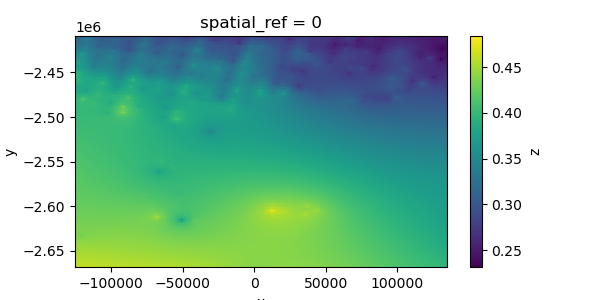

In [67]:
# January atm correction
plt.figure(figsize=(6, 3))
# (SST).plot.imshow(x='x',y='y',vmin=-4,vmax=0)
(WV_xr).plot.imshow(x='x',y='y')


(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 array([11223.        , 11977.09960938, 12731.20019531, 13485.29980469,
        14239.40039062, 14993.5       , 15747.59960938, 16501.69921875,
        17255.80078125, 18009.90039062, 18764.        ]),
 <a list of 7991 BarContainer objects>)

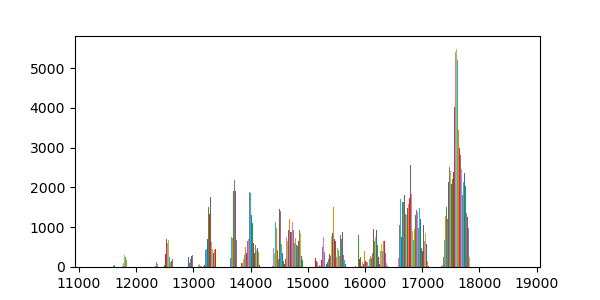

In [23]:
plt.figure(figsize=(6, 3))
plt.hist(DN_masked)

(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 array([261.53265381, 262.62966919, 263.72668457, 264.82369995,
        265.92071533, 267.01773071, 268.11474609, 269.21176147,
        270.30877686, 271.40579224, 272.50280762]),
 <a list of 7991 BarContainer objects>)

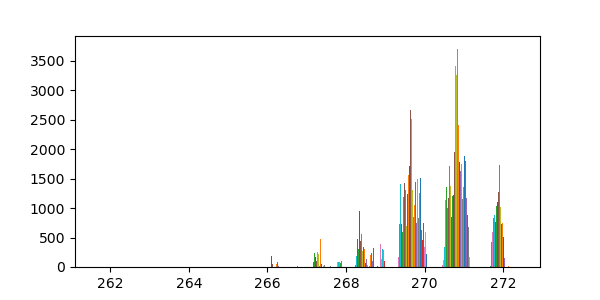

In [22]:
plt.figure(figsize=(6, 3))
plt.hist(toa)

In [32]:
for mo in ['05','11']:
    # Select appropriate atmospheric correction coefficients
    a_mo = mo
    a1 = atmcor[a_mo]['a1']
    a2 = atmcor[a_mo]['a2']
    a3 = atmcor[a_mo]['a3']
    print (f'{mo}: {a3 + a1*np.nanmean(toa) + a2*np.nanmean(wv3)*np.nanmean(toa) - 273.15}')
# Linear

05: -2.2590351534010438
11: -2.772665537320961


AttributeError: 'NoneType' object has no attribute 'plot'

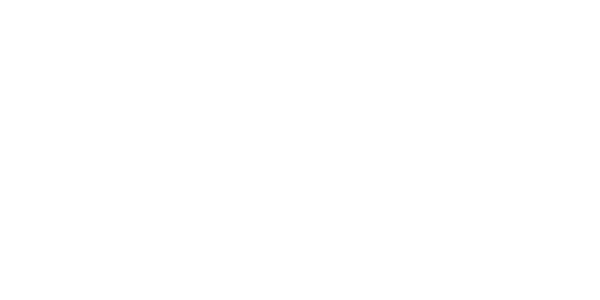

In [31]:
# Feb atm correction
plt.figure(figsize=(6, 3))
(SST).plot.imshow(x='x',y='y',vmin=-4,vmax=0)

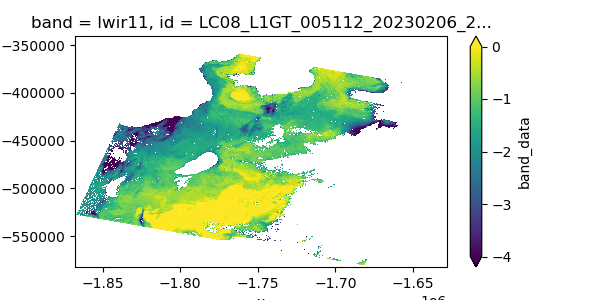

In [185]:
# January atm correction
plt.figure(figsize=(6, 3))
(SST).plot.imshow(x='x',y='y',vmin=-4,vmax=0)

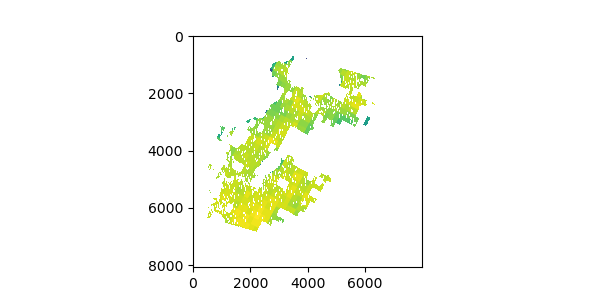

In [33]:
# no interpolation
plt.figure(figsize=(6, 3))
plt.imshow(wv0)

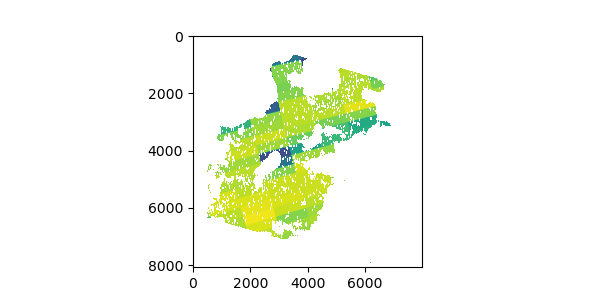

In [60]:
# no interpolation but remove 4% data
plt.figure(figsize=(6, 3))
plt.imshow(wv1)

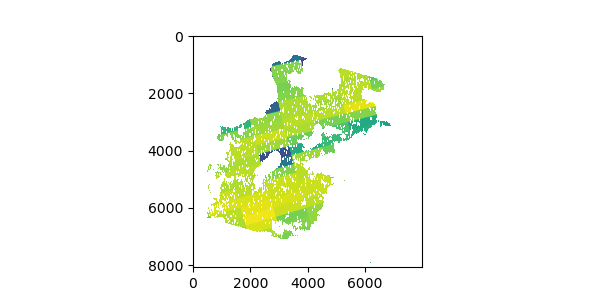

In [80]:
# Interpololation without masking
plt.figure(figsize=(6, 3))
# (ls_thermal*mask).plot.imshow(x='x',y='y')
# (SST).plot.imshow(x='x',y='y')
# (mod07.Water_Vapor).plot.pcolormesh(x='Longitude',y='Latitude')
# (ls_scene.sel(band='qa_pixel').compute()*mask).plot.imshow(x='x',y='y')
plt.imshow(wv3)

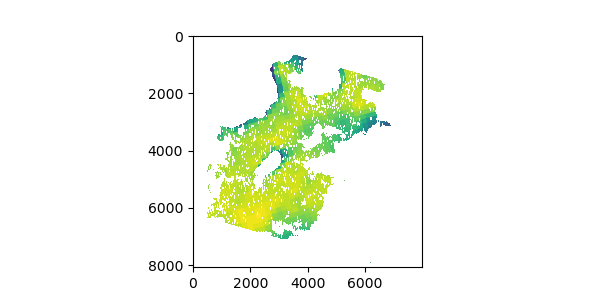

In [144]:
# Interpolation with masking
plt.figure(figsize=(6, 3))
plt.imshow(wv4)

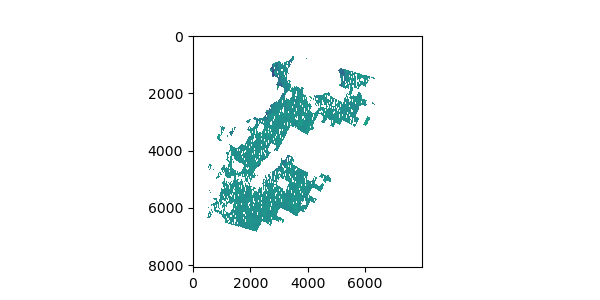

In [164]:
plt.figure(figsize=(6, 3))
plt.imshow(wv4-wv0)

In [163]:
np.unique(wv4-wv0,return_counts=True)

(array([-3.7e-04, -3.6e-04, -3.5e-04, -3.4e-04, -3.4e-04, -3.3e-04,
        -3.3e-04, -3.3e-04, -3.2e-04, -3.2e-04, -3.1e-04, -3.1e-04,
        -3.1e-04, -3.0e-04, -3.0e-04, -2.9e-04, -2.9e-04, -2.9e-04,
        -2.8e-04, -2.8e-04, -2.7e-04, -2.7e-04, -2.7e-04, -2.6e-04,
        -2.6e-04, -2.5e-04, -2.5e-04, -2.5e-04, -2.4e-04, -2.4e-04,
        -2.4e-04, -2.3e-04, -2.3e-04, -2.3e-04, -2.2e-04, -2.2e-04,
        -2.2e-04, -2.1e-04, -2.1e-04, -2.1e-04, -2.0e-04, -2.0e-04,
        -2.0e-04, -2.0e-04, -1.9e-04, -1.9e-04, -1.9e-04, -1.8e-04,
        -1.8e-04, -1.8e-04, -1.7e-04, -1.7e-04, -1.7e-04, -1.6e-04,
        -1.6e-04, -1.6e-04, -1.6e-04, -1.5e-04, -1.5e-04, -1.5e-04,
        -1.4e-04, -1.4e-04, -1.4e-04, -1.3e-04, -1.3e-04, -1.2e-04,
        -1.2e-04, -1.2e-04, -1.2e-04, -1.1e-04, -1.1e-04, -1.1e-04,
        -1.0e-04, -1.0e-04, -1.0e-04, -9.0e-05, -9.0e-05, -9.0e-05,
        -8.0e-05, -8.0e-05, -8.0e-05, -8.0e-05, -7.0e-05, -7.0e-05,
        -7.0e-05, -6.0e-05, -6.0e-05, -6.0e-05, 

In [ ]:
# Plot water vapor data ***need to comment out the delete code above for this to work
data0 = ls_thermal*mask
plt.figure(figsize=(6, 3))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_global()
cb = ax.pcolormesh(data0.x,data0.y,data0.values,vmin=14000,vmax=17800,transform=cartopy.crs.epsg(3031))
ax.coastlines()
ax.set_ylim([-78, -72])
ax.set_xlim([-111,-101])
cbar = plt.colorbar(cb)
plt.tight_layout()

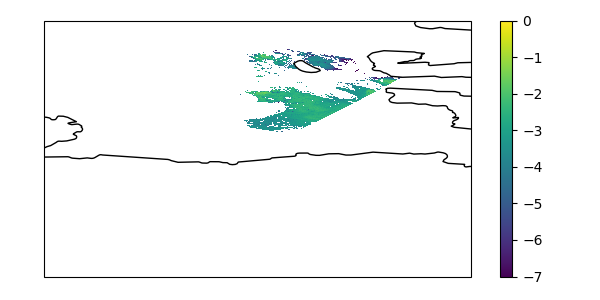

In [29]:
# Plot water vapor data ***need to comment out the delete code above for this to work
data0 = SST
plt.figure(figsize=(6, 3))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_global()
cb = ax.pcolormesh(data0.x,data0.y,data0.values,vmin=-7,vmax=0,transform=cartopy.crs.epsg(3031))
ax.coastlines()
ax.set_ylim([-78, -72])
ax.set_xlim([-111,-101])
cbar = plt.colorbar(cb)
plt.tight_layout()

In [31]:
# # Put data into DataFrame and save    
# lsat_mod_df = pd.DataFrame(valid,columns=headers)
# out_df = lsatpath / f'Landsat_{vkind}{dataset}_validation_20260116_alltime_{dist}.csv'
# lsat_mod_df.to_csv(out_df)

In [21]:
# %%time

# sdata = sealI
# # Find all seal tag matchups

# vkind = 'seal'

# lat_nm = 'LATITUDE_Argos'
# lon_nm = 'LONGITUDE_Argos'
# lat_ani = 'LATITUDE_Animotum'
# lon_ani = 'LONGITUDE_Animotum'
# loc_err = 'Argos_Error_Radius'
# tdif = 'time_diff'
# T_nm = 'CT_raw_bin1'
# depth_nm = 'Pres_raw_bin1'
# convertC = 0 # already in C
# platform_nm = 'smru_platform_code'
# id_nm = 'Date'
# date_nm = 'Date'

# # Set up projections
# transformer = Transformer.from_crs(source_crs, target_crs, always_xy=True)


# # Subset seals to Antarctica as before
# ant = sdata[(sdata[lat_nm] < -65)]# & (sdata[lon_nm] > -142) & (sdata[lon_nm] < -72)]
# # ant = ant[ant[date_nm].notna()]  # Remove rows with missing dates

# # Overall spatial bounds (pad by a bit to be safe)
# lon_min = ant[lon_nm].min() - 1
# lon_max = ant[lon_nm].max() + 1
# lat_min = ant[lat_nm].min() - 1
# lat_max = ant[lat_nm].max() + 1
# bbox_global = (lon_min, lat_min, lon_max, lat_max)

# # Overall time bounds (add your ± time_add)
# dt_min = ant[date_nm].min() - pd.Timedelta(days=time_add)
# dt_max = ant[date_nm].max() + pd.Timedelta(days=time_add)
# timeRange_global = f"{dt_min.strftime('%Y-%m-%dT%H:%M:%SZ')}/{dt_max.strftime('%Y-%m-%dT%H:%M:%SZ')}"

# # ONE STAC search for all Landsat scenes
# items = sut.search_stac(
#     url,
#     collection,
#     gjson_outfile=gjson_outfile,
#     bbox=bbox_global,
#     timeRange=timeRange_global,
# )

# # Open catalog once
# catalog = intake.open_stac_item_collection(items)

# # Build a GeoDataFrame of candidate scenes (Landsat 8 only)
# scenes = []
# for it in items:
#     if it.id[3] != "8":
#         continue
#     scenes.append({
#         "sceneid": it.id,
#         "datetime": it.datetime,   # or it.properties["datetime"]
#         "geometry": shape(it.geometry),
#     })

# scene_gdf = gpd.GeoDataFrame(scenes, geometry="geometry", crs="EPSG:4326")

# # Sort by datetime
# scene_gdf = scene_gdf.sort_values(by='datetime').reset_index(drop=True)
# scene_gdf.head()

CPU times: user 17.5 s, sys: 809 ms, total: 18.3 s
Wall time: 58.7 s


,sceneid,datetime,geometry
0,LC08_L1GT_044115_20190111_20201016_02_T2,2019-01-11 19:18:14.618934+00:00,"MULTIPOLYGON (((180 -76.97911, 179.50887 -77.1..."
1,LC08_L1GT_044116_20190111_20201016_02_T2,2019-01-11 19:18:38.759897+00:00,"MULTIPOLYGON (((180 -76.98252, 174.46085 -78.0..."
2,LC08_L1GT_044117_20190111_20201016_02_T2,2019-01-11 19:19:02.744128+00:00,"MULTIPOLYGON (((180 -78.8454, 175.47835 -77.91..."
3,LC08_L1GT_060107_20190111_20201016_02_T2,2019-01-11 20:53:55.817742+00:00,"MULTIPOLYGON (((180 -65.99676, 178.79756 -65.7..."
4,LC08_L1GT_051112_20190112_20201016_02_T2,2019-01-12 20:00:18.184217+00:00,"MULTIPOLYGON (((180 -73.68161, 179.88308 -73.7..."


In [18]:
# %%time

# # --- Make sure seal data has naive datetimes ---
# seal_gdf = gpd.GeoDataFrame(
#     ant.copy(),
#     geometry=gpd.points_from_xy(ant[lon_nm], ant[lat_nm]),
#     crs="EPSG:4326",
# )

# # Seal timestamps: force tz-naive
# seal_gdf[date_nm] = pd.to_datetime(seal_gdf[date_nm], errors="coerce")
# seal_gdf[date_nm] = seal_gdf[date_nm].dt.tz_localize(None)

# # --- Ensure scene datetimes are tz-naive ---
# scene_gdf = scene_gdf.copy()
# scene_gdf["datetime"] = pd.to_datetime(scene_gdf["datetime"], errors="coerce")
# scene_gdf["datetime"] = scene_gdf["datetime"].dt.tz_localize(None)

# # --- Spatial join to find which seals fall within which scene footprints ---
# pairs = gpd.sjoin(
#     seal_gdf,
#     scene_gdf,
#     how="inner",
#     predicate="intersects",
# )

# # ----------------------------------------------
# # Temporal filtering: keep only ±12 hours matches
# # ----------------------------------------------

# # Compute absolute time differences (now both tz-naive → no errors)
# pairs[tdif] = (pairs[date_nm] - pairs["datetime"]).abs()

# # Keep only seals within ±12 hours (adjust as needed)
# pairs = pairs[pairs[tdif] <= pd.Timedelta(hours=12)]

# print("Number of seal–scene matches:", len(pairs))
# print(pairs.head())

In [23]:
# def sub_to_point(row, lat_nm, lon_nm, dist, source_crs, target_crs, SST_calibrated):
#     # Create search area around THIS specific seal point (in lat/lon)
#     ilat = row[lat_nm]
#     ilon = row[lon_nm]
#     lat_add = sut.km_to_decimal_degrees(dist, ilat, direction='latitude')
#     lon_add = sut.km_to_decimal_degrees(dist, ilat, direction='longitude')
    
#     # Create bounding box in lat/lon
#     bboxV = (ilon-lon_add, ilat-lat_add, ilon+lon_add, ilat+lat_add)
    
#     # Reproject bounding box to EPSG:3031
#     sbox, checkbox = sut.lsat_reproj(source_crs, target_crs, 
#                                       (bboxV[0], bboxV[1], bboxV[2], bboxV[3]))
    
#     # Create polygon for cropping
#     polygon = Polygon([(sbox[0][0],sbox[0][1]), (sbox[3][0],sbox[3][1]), 
#                       (sbox[2][0],sbox[2][1]), (sbox[1][0],sbox[1][1])])
    
#     # Get min/max boundaries
#     minx, miny, maxx, maxy = polygon.bounds
#     polarx = [minx, maxx]
#     polary = [miny, maxy]
    
#     # Subset to the small area around this seal point
#     SST_sub = sut.subset_img(SST_calibrated, polarx, polary)
    
#     # Crop to exact polygon
#     SST_sub = sut.crop_xarray_dataarray_with_polygon(SST_sub, polygon)
    
#     # Now compute statistics for THIS specific area
#     lsat = np.around(np.nanmean(SST_sub), 2)
#     lstd = np.around(np.nanstd(SST_sub), 2)

#     return lsat, lstd, SST_sub

# def center_pix(SST_sub, x_pt, y_pt):
#     # Get center pixel value
#     center_val = SST_sub.sel(x=x_pt, y=y_pt, method="nearest")
    
#     # Extract the x/y coordinate values as plain floats
#     center_x = float(center_val.x.values)
#     center_y = float(center_val.y.values)
    
#     # Extract the actual value
#     if isinstance(center_val, xr.Dataset):
#         center_value = float(center_val['band_data'].values.item())
#     else:
#         center_value = float(center_val.values.item())


In [30]:
# # LC08_L1GT_232113_20200323_20200822_02_T2

# grouped = list(pairs.groupby("sceneid"))
# for sceneid, group in tqdm(grouped[284:290], desc="Processing"): 
#     print(sceneid)

In [ ]:
# valid = []

# # Before the loop, create a dictionary mapping scene IDs to STAC items
# item_dict = {item.id: item for item in items if item.id[3] == '8'}

# # pairs = pairs.sort_values(by='datetime')  # Sort by scene datetime

# # for sceneid, group in tqdm(pairs.groupby("sceneid"), desc="Processing"):
# grouped = list(pairs.groupby("sceneid"))
# for sceneid, group in tqdm(grouped, desc="Processing"): 
#     # Vectorized transform of ALL associated seal points to EPSG:3031
#     lons = group[lon_nm].to_numpy()
#     lats = group[lat_nm].to_numpy()
#     xs, ys = transformer.transform(lons, lats)  # arrays, not scalar
    
#     # Get the STAC item object
#     item = item_dict[sceneid]
    
#     scene = catalog[sceneid]
#     timestr = scene.metadata['datetime'].strftime('%H%M%S')
#     outFile = f'{SSTpath}/{sceneid}_{timestr}_Cel.tif'

#     # Either open existing SST COG, or create it once
#     if os.path.isfile(outFile):
#         print(f"{sceneid} - atm corr exists")
#         SST = xr.open_dataset(outFile, chunks=dict(x=512, y=512), engine="rasterio")["band_data"]
#         SST = SST.rio.write_crs("epsg:3031", inplace=True)
#     else:
#         print(f"{sceneid}")
#         # Pass the STAC item object, not the string ID
#         ls_scene = sut.landsat_to_xarray(item, catalog)
#         ls_scene = ls_scene.rio.write_crs("epsg:3031", inplace=True)
#         ls_scene = sut.create_masks(ls_scene, cloud_mask=True, ice_mask=True, ocean_mask=True)

#         mask = np.ones(ls_scene.shape[1:])
#         mask[ls_scene.mask != 3] = np.nan
#         ls_thermal = ls_scene.sel(band="lwir11").compute()

#         # For speed, optionally subset thermal to a bbox around seal tag points and check for valid pixels
#         minx, maxx = xs.min(), xs.max()
#         miny, maxy = ys.min(), ys.max()
#         thermal_check = sut.subset_img(ls_thermal, [minx, maxx], [miny, maxy])  # like you already do
        
#         if np.all(np.isnan(thermal_check)):
#             print(f'{sceneid} has no valid SST values in seal tag region')
#             continue

#         # Use band ratios for RF cloud pixel classification
#         ####
        
#         # Atmospheric correction using MODIS
#         # Acquire and align MODIS water vapor (MOD/MYD07) to Landsat
#         mod07, modfilenm = sut.open_MODIS(ls_scene, scene, modout_path)

#         # Create water vapor files aligned and subsampled to Landsat
#         spacing = [300, -300] # 300m sampling of MODIS data so that upsampling is easy and because 30m takes far too long
#         WV_xr = sut.get_wv(ls_scene, mod07, spacing, WV, scene, interp=interp)

#         # Create SST by masking and using water vapor to apply atmospheric correction
#         SST = sut.apply_retrieval(ls_thermal, scene, mask, WV_xr, atmcor, simT_transformer, simTOA_transformer, simWV_transformer)
        
#         # Record MODIS water vapor image used in atmospheric correction
#         SST.attrs["MODIS_WV"] = modfilenm

#         # Save to a cloud-optimized Geotiff
#         SST.rio.to_raster(raster_path=outFile, driver="COG")
#         print (f'Mean SST: {np.nanmean(SST)}')

#     if np.all(np.isnan(SST)):
#         print(f'{sceneid} has no valid SST values')
#         continue

#     # For this scene, now have: SST in EPSG:3031
    
#     # Apply calibration and thresholds to the full scene
#     SST_calibrated = SST * calib_m + calib_b
#     SST_calibrated = SST_calibrated.where(SST_calibrated >= lthresh, np.nan)

#     # Extract nearest pixel for each seal
#     for (idx, row), x_pt, y_pt in zip(group.iterrows(), xs, ys):

#         # Create search area around THIS specific seal point (in lat/lon) and its animotum location
#         lsat, lstd, SST_sub = sub_to_point(row, lat_nm, lon_nm, dist, source_crs, target_crs, SST_calibrated)
#         lsat_ani, lstd_ani, SST_sub_ani = sub_to_point(row, lat_ani, lon_ani, dist, source_crs, target_crs, SST_calibrated)
        
#         # Get center pixel value
#         center_value = center_pix(SST_sub, x_pt, y_pt)
#         center_value_ani = center_pix(SST_sub_ani, x_pt, y_pt)

#         argo_temp = np.around(row[T_nm] - convertC, 2)

#         valid.append([
#             row[date_nm],
#             sceneid,
#             lsat,
#             lstd,
#             center_value,
#             SST_sub.max().values.item(),
#             SST_sub.min().values.item(),
#             lsat_ani,
#             lstd_ani,
#             center_value_ani,
#             row[id_nm],
#             argo_temp,
#             T_nm,
#             row[platform_nm],
#             row[lat_nm],
#             row[lon_nm],
#             row[lat_ani],
#             row[lon_ani],
#             row[loc_err],
#             row[tdif],
#         ])
#         print (f'Argo temp: {argo_temp}, Landsat 8 mean: {lsat}+/-{lstd}, Lsat animotum mean: {lsat_ani}+/-{lstd_ani}')

#     try:
#         del ls_scene, scene, ls_thermal, thermal_check, mod07, WV_xr, SST, SST_calibrated, SST_sub
#     except:
#         pass

#     gc.collect()
        
# # Put data into DataFrame and save    
# lsat_mod_df = pd.DataFrame(valid,columns=headers)
# out_df = lsatpath / f'Landsat_{vkind}_validation_20251202_alltime_{dist}.csv'
# lsat_mod_df.to_csv(out_df)

## Check Landsat SST output

In [55]:
Lfile = '/home/jovyan/Landsat_SST_algorithm/Data/SST/Validation/LC08_L1GT_228108_20200123_20201016_02_T2_141253_Cel.tif'
ls_scene = xr.open_dataset(Lfile)
ls_scene

<xarray.Dataset>
Dimensions:      (band: 1, x: 9081, y: 9101)
Coordinates:
  * band         (band) int64 1
  * x            (x) float64 -2.495e+06 -2.495e+06 ... -2.223e+06 -2.223e+06
  * y            (y) float64 5.046e+05 5.046e+05 ... 2.316e+05 2.316e+05
    spatial_ref  int64 ...
Data variables:
    band_data    (band, y, x) float64 ...

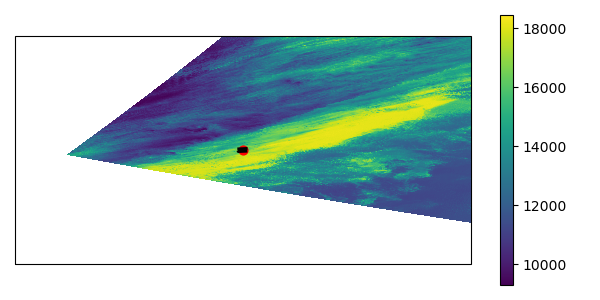

In [18]:
plt.figure(figsize=(6, 3))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_global()
ax.set_ylim([ilat-1,ilat+1])
ax.set_xlim([ilon-2,ilon+2])
cb = ax.pcolormesh(ls_scene.x,ls_scene.y,ls_scene.sel(band=1).to_array().isel(variable=0),transform=cartopy.crs.epsg(3031))
plt.scatter([ilon],[ilat],c='r',s=40,transform=ccrs.PlateCarree())
plt.plot([polarx[0],polarx[0],polarx[1],polarx[1],polarx[0]],[polary[0],polary[1],polary[1],polary[0],polary[0]],lw=2,ls='--',color='k',transform=cartopy.crs.epsg(3031))
ax.coastlines()
plt.colorbar(cb)
plt.tight_layout()

**Note the bands you would like to include are assigned by passing the bandNames parameter to landsat_to_xarray using the following codes:**

'coastal', 'blue', 'green', 'red', 'nir08', 'swir16', 'swir22', 'pan', 'cirrus', 'lwir11', 'lwir12', 'qa_pixel'

# Landsat-iQUAM validation assessment

In [9]:
# Read in processed matchups

out_df = lsatpath / 'Landsat_validation_202209_202303_1.0.csv'
df1 = pd.read_csv(out_df, index_col=0)
out_df = lsatpath / 'Landsat_validation_202109_202203_1.0.csv'
df2 = pd.read_csv(out_df, index_col=0)
out_df = lsatpath / 'Landsat_validation_202009_202103_1.0.csv'
df3 = pd.read_csv(out_df, index_col=0)
out_df = lsatpath / 'Landsat_validation_201909_202003_1.0.csv'
df4 = pd.read_csv(out_df, index_col=0)
out_df = lsatpath / 'Landsat_validation_201809_201903_1.0.csv'
df5 = pd.read_csv(out_df, index_col=0)
out_df = lsatpath / 'Landsat_validation_201709_201803_1.0.csv'
df6 = pd.read_csv(out_df, index_col=0)
out_df = lsatpath / 'Landsat_validation_201609_201703_1.0.csv'
df7 = pd.read_csv(out_df, index_col=0)
out_df = lsatpath / 'Landsat_validation_201509_201603_1.0.csv'
df8 = pd.read_csv(out_df, index_col=0)
out_df = lsatpath / 'Landsat_validation_201409_201503_1.0.csv'
df9 = pd.read_csv(out_df, index_col=0)
out_df = lsatpath / 'Landsat_validation_201309_201403_1.0.csv'
df10 = pd.read_csv(out_df, index_col=0)

valids = pd.concat([df1,df2,df3,df4,df5,df6,df7,df8,df9,df10]) 

# # A weird repeat is in the Argo data, NEED TO REMOVE for next visual runs
# valids = valids[valids['Argo_id'] != '6903773-2021-01-31 05:41:00']

valids = valids[valids['platform_type']==5.0]
valids['DateTime'] = pd.to_datetime(valids['DateTime'])
valids = valids.set_index('DateTime')
valids = valids.sort_index()

valids = valids.dropna(subset=['L8_SST'])

# Remove the non-numeric column for calculating daily means
numeric_valids = valids.select_dtypes(include=[np.number])
validmn = valids.groupby('Argo_id')[numeric_valids.columns].mean()
validmn['DateTime'] = valids.reset_index().groupby('Argo_id')['DateTime'].first().values
valids['temp_dif'] = valids.groupby(valids['Argo_id'])[f'L8_SST'].diff()
validmn['temp_dif'] = valids.groupby(valids['Argo_id'])['temp_dif'].first()
validmn['std'] = valids.groupby(valids['Argo_id'])[f'L8_SST'].std()
validmn['time_dif'] = valids.groupby(valids['Argo_id'])['time_dif'].first()

validmn = validmn.reset_index()

# For validmn, get the first DateTime for each seal_id
validmn['xaxis'] = pd.to_datetime(validmn['DateTime']).dt.dayofyear
validmn['xaxis'] = validmn['xaxis'].where(validmn['xaxis'] >= (365/2), validmn['xaxis'] + 365)

valids['xaxis'] = pd.to_datetime(valids.index).dayofyear
valids['xaxis'][valids['xaxis']<(365/2)] = valids['xaxis'] + 365

print(f"valids has {len(valids)} rows")
print(f"validmn has {len(validmn)} rows (grouped by argo_id)")

valids_argo = valids
validmn_argo = validmn

valids_argo.tail()

valids has 124 rows
validmn has 100 rows (grouped by argo_id)


,L8_filename,L8_SST,L8_std,center,L8_SST_max,L8_SST_min,Argo_id,Argo_SST,depth,platform_type,A_lat,A_lon,time_dif,temp_dif,xaxis
DateTime,,,,,,,,,,,,,,,
2023-02-27 16:14:00,LC08_L1GT_040112_20230227_20230315_02_T2,-1.73,0.09,NaN,-1.497766,-1.899885,7900669-2023-02-27 16:14:00,-1.82,1.12,5.0,-72.902300,-160.68593,0 days 02:38:31,NaN,423
2023-03-01 22:32:00,LC08_L1GT_054115_20230301_20230315_02_T2,-1.88,0.01,NaN,-1.866346,-1.899364,7900927-2023-03-01 22:32:00,-1.76,4.34,5.0,-76.630295,167.49226,0 days 02:11:46,NaN,425
2023-03-06 02:24:00,LC08_L1GT_178105_20230306_20230316_02_T2,-0.20,0.12,-0.160620,-0.012640,-1.299164,6903106-2023-03-06 02:24:00,0.31,2.40,5.0,-64.724170,1.06762,0 days 06:38:33,NaN,430
2023-03-11 10:06:00,LC08_L1GT_117106_20230311_20230320_02_T2,-1.47,0.06,-1.479309,-1.261079,-1.660044,7900904-2023-03-11 10:06:00,-1.16,3.02,5.0,-66.061386,93.31095,0 days 07:20:05,NaN,435
2023-03-28 08:42:00,LC08_L1GT_220107_20230328_20230405_02_T2,0.38,0.06,0.466897,0.599916,-0.055258,1901921-2023-03-28 08:42:00,1.17,4.23,5.0,-67.086300,-69.22680,0 days 04:40:43,NaN,452


In [10]:
out_df = lsatpath / 'Landsat_sealBASSTR_validation_20260202_alltime_1.0.csv'
df1 = pd.read_csv(out_df, index_col=0)
valids = df1 #pd.concat([df1, df2])

# Keep only rows where at least one of L8_SST or L8_SST_ani is NOT NaN, and seal_SST is real
valids = valids.dropna(subset=['L8_SST', 'L8_SST_ani'], how='all')
valids = valids.dropna(subset=['seal_SST'])
valids['loc_err[km]'] = valids['loc_err']/1000

# Only need to do temporarily until fix files
valids['seal_id'] = valids['platform_type'].astype(str) + '-' + valids['DateTime'].astype(str)

valids = valids.set_index('DateTime')
valids.index = pd.to_datetime(valids.index)  # Ensure index is datetime
valids = valids.sort_index()

# Remove the non-numeric column for calculating daily means
numeric_valids = valids.select_dtypes(include=[np.number])

valids = valids.dropna(subset=['seal_SST'], how='any') 

valids_sealargo = valids.dropna(subset=['L8_SST'], how='any') 
valids_sealani = valids.dropna(subset=['L8_SST_ani'], how='any')

# Group by seal_id only
validmn_sealargo = valids_sealargo.groupby('seal_id')[numeric_valids.columns].mean()
validmn_sealani = valids_sealani.groupby('seal_id')[numeric_valids.columns].mean()

# Group by seal_id and calculate the difference
valids_sealargo['temp_dif'] = valids_sealargo.groupby('seal_id')['L8_SST'].diff()
validmn_sealargo['temp_dif'] = valids_sealargo.groupby('seal_id')['temp_dif'].first()
validmn_sealargo['time_dif'] = valids_sealargo.groupby('seal_id')['time_dif'].first()

valids_sealani['temp_dif'] = valids_sealani.groupby('seal_id')['L8_SST_ani'].diff()
validmn_sealani['temp_dif'] = valids_sealani.groupby('seal_id')['temp_dif'].first()
validmn_sealani['time_dif'] = valids_sealani.groupby('seal_id')['time_dif'].first()

# Calculate std for validmn
validmn_sealargo['std'] = valids_sealargo.groupby('seal_id')['L8_SST'].std().values
validmn_sealani['std_ani'] = valids_sealani.groupby('seal_id')['L8_SST_ani'].std().values

# Add std to valids as well using transform
valids_sealargo['std'] = valids_sealargo.groupby('seal_id')['L8_SST'].transform('std')
valids_sealani['std_ani'] = valids_sealani.groupby('seal_id')['L8_SST_ani'].transform('std')

# For validmn, get the first DateTime for each seal_id
validmn_sealargo['DateTime'] = valids_sealargo.reset_index().groupby('seal_id')['DateTime'].first().values
validmn_sealargo['xaxis'] = pd.to_datetime(validmn_sealargo['DateTime']).dt.dayofyear
validmn_sealargo['xaxis'] = validmn_sealargo['xaxis'].where(validmn_sealargo['xaxis'] >= (365/2), validmn_sealargo['xaxis'] + 365)

validmn_sealani['DateTime'] = valids_sealani.reset_index().groupby('seal_id')['DateTime'].first().values
validmn_sealani['xaxis'] = pd.to_datetime(validmn_sealani['DateTime']).dt.dayofyear
validmn_sealani['xaxis'] = validmn_sealani['xaxis'].where(validmn_sealani['xaxis'] >= (365/2), validmn_sealani['xaxis'] + 365)

# For valids, use the index
valids_sealargo['xaxis'] = valids_sealargo.index.dayofyear
valids_sealargo['xaxis'] = valids_sealargo['xaxis'].where(valids_sealargo['xaxis'] >= (365/2), valids_sealargo['xaxis'] + 365)

valids_sealani['xaxis'] = valids_sealani.index.dayofyear
valids_sealani['xaxis'] = valids_sealani['xaxis'].where(valids_sealani['xaxis'] >= (365/2), valids_sealani['xaxis'] + 365)

validmn_sealargo = validmn_sealargo.reset_index()
validmn_sealani = validmn_sealani.reset_index()

print(f"Argos seal valids has {len(valids_sealargo)} rows")
print(f"Argos seal validmn has {len(validmn_sealargo)} rows (grouped by seal_id)")

print(f"AniMotum valids has {len(valids_sealani)} rows")
print(f"AniMotum validmn has {len(validmn_sealani)} rows (grouped by seal_id)")

valids_sealargo_basstr = valids_sealargo
valids_sealani_basstr = valids_sealani
validmn_sealargo_basstr = validmn_sealargo
validmn_sealani_basstr = validmn_sealani

valids_sealargo_basstr.tail()

Argos seal valids has 37 rows
Argos seal validmn has 34 rows (grouped by seal_id)
AniMotum valids has 47 rows
AniMotum validmn has 39 rows (grouped by seal_id)


,L8_filename,L8_SST,L8_std,center,L8_SST_max,L8_SST_min,L8_SST_ani,L8_std_ani,center_ani,seal_id,...,A_lon,A_lat_ani,A_lon_ani,loc_err,qc[x_y_xse_yse],time_dif,loc_err[km],temp_dif,std,xaxis
DateTime,,,,,,,,,,,,,,,,,,,,,
2022-03-12 23:40:00,LC08_L1GT_008113_20220312_20220321_02_T2,-1.75,0.06,NaN,-1.548223,-1.898502,-1.55,0.05,NaN,ct167-522-21-2022-03-12 23:40:00,...,-112.4398,-74.133584,-112.430962,4782.395939,"[-12515757.4446617, -12528559.3204937, 7788.71...",0 days 08:04:56.426209,4.782396,NaN,NaN,436
2022-03-13 01:19:59,LC08_L1GT_008113_20220312_20220321_02_T2,-1.65,0.09,NaN,-1.403598,-1.897665,-1.60,0.08,NaN,ct167-522-21-2022-03-13 01:19:59,...,-112.4898,-74.188859,-112.466083,4309.891431,"[-12519667.0536907, -12551092.712094, 6739.993...",0 days 09:44:55.426209,4.309891,NaN,NaN,437
2022-03-15 10:49:59,LC08_L1GT_013112_20220315_20220321_02_T2,-1.90,0.00,NaN,-1.888006,-1.898152,NaN,NaN,NaN,ct167-Manoela-21-2022-03-15 10:49:59,...,-115.9277,-73.245247,-116.010070,1658.045149,"[-12914181.8692896, -12176545.9826787, 2780.14...",0 days 05:15:32.978135,1.658045,NaN,NaN,439
2022-03-15 11:49:59,LC08_L1GT_013112_20220315_20220321_02_T2,-1.88,0.02,NaN,-1.833443,-1.899362,-1.88,0.02,NaN,ct167-Manoela-21-2022-03-15 11:49:59,...,-116.1329,-73.232152,-116.105525,1468.058164,"[-12924807.9585647, -12171493.800705, 2822.247...",0 days 04:15:32.978135,1.468058,NaN,NaN,439
2022-03-16 01:10:00,LC08_L1GT_013112_20220315_20220321_02_T2,-1.88,0.02,NaN,-1.823489,-1.899696,NaN,NaN,NaN,ct167-Manoela-21-2022-03-16 01:10:00,...,-116.4528,-73.256599,-116.627898,4125.783881,"[-12982958.2406441, -12180928.5519816, 2228.53...",0 days 09:04:28.021865,4.125784,NaN,NaN,440


In [11]:
out_df = lsatpath / 'Landsat_sealIMOS_validation_20260202_alltime_1.0.csv'
df2 = pd.read_csv(out_df, index_col=0)
valids = df2 

# Keep only rows where at least one of L8_SST or L8_SST_ani is NOT NaN, and seal_SST is real
valids = valids.dropna(subset=['L8_SST', 'L8_SST_ani'], how='all')
valids = valids.dropna(subset=['seal_SST'])
valids['loc_err[km]'] = valids['loc_err']/1000

# Only need to do temporarily until fix files
valids['seal_id'] = valids['platform_type'].astype(str) + '-' + valids['DateTime'].astype(str)

valids = valids.set_index('DateTime')
valids.index = pd.to_datetime(valids.index)  # Ensure index is datetime
valids = valids.sort_index()

# Remove the non-numeric column for calculating daily means
numeric_valids = valids.select_dtypes(include=[np.number])

valids = valids.dropna(subset=['seal_SST'], how='any') 

valids_sealargo = valids.dropna(subset=['L8_SST'], how='any') 
valids_sealani = valids.dropna(subset=['L8_SST_ani'], how='any')

# Group by seal_id only
validmn_sealargo = valids_sealargo.groupby('seal_id')[numeric_valids.columns].mean()
validmn_sealani = valids_sealani.groupby('seal_id')[numeric_valids.columns].mean()

# Group by seal_id and calculate the difference
valids_sealargo['temp_dif'] = valids_sealargo.groupby('seal_id')['L8_SST'].diff()
validmn_sealargo['temp_dif'] = valids_sealargo.groupby('seal_id')['temp_dif'].first()
validmn_sealargo['time_dif'] = valids_sealargo.groupby('seal_id')['time_dif'].first()

valids_sealani['temp_dif'] = valids_sealani.groupby('seal_id')['L8_SST_ani'].diff()
validmn_sealani['temp_dif'] = valids_sealani.groupby('seal_id')['temp_dif'].first()
validmn_sealani['time_dif'] = valids_sealani.groupby('seal_id')['time_dif'].first()

# Calculate std for validmn
validmn_sealargo['std'] = valids_sealargo.groupby('seal_id')['L8_SST'].std().values
validmn_sealani['std_ani'] = valids_sealani.groupby('seal_id')['L8_SST_ani'].std().values

# Add std to valids as well using transform
valids_sealargo['std'] = valids_sealargo.groupby('seal_id')['L8_SST'].transform('std')
valids_sealani['std_ani'] = valids_sealani.groupby('seal_id')['L8_SST_ani'].transform('std')

# For validmn, get the first DateTime for each seal_id
validmn_sealargo['DateTime'] = valids_sealargo.reset_index().groupby('seal_id')['DateTime'].first().values
validmn_sealargo['xaxis'] = pd.to_datetime(validmn_sealargo['DateTime']).dt.dayofyear
validmn_sealargo['xaxis'] = validmn_sealargo['xaxis'].where(validmn_sealargo['xaxis'] >= (365/2), validmn_sealargo['xaxis'] + 365)

validmn_sealani['DateTime'] = valids_sealani.reset_index().groupby('seal_id')['DateTime'].first().values
validmn_sealani['xaxis'] = pd.to_datetime(validmn_sealani['DateTime']).dt.dayofyear
validmn_sealani['xaxis'] = validmn_sealani['xaxis'].where(validmn_sealani['xaxis'] >= (365/2), validmn_sealani['xaxis'] + 365)

# For valids, use the index
valids_sealargo['xaxis'] = valids_sealargo.index.dayofyear
valids_sealargo['xaxis'] = valids_sealargo['xaxis'].where(valids_sealargo['xaxis'] >= (365/2), valids_sealargo['xaxis'] + 365)

valids_sealani['xaxis'] = valids_sealani.index.dayofyear
valids_sealani['xaxis'] = valids_sealani['xaxis'].where(valids_sealani['xaxis'] >= (365/2), valids_sealani['xaxis'] + 365)

validmn_sealargo = validmn_sealargo.reset_index()
validmn_sealani = validmn_sealani.reset_index()

print(f"Argo seal valids has {len(valids_sealargo)} rows")
print(f"Argo seal validmn has {len(validmn_sealargo)} rows (grouped by seal_id)")

print(f"AniMotum valids has {len(valids_sealani)} rows")
print(f"AniMotum validmn has {len(validmn_sealani)} rows (grouped by seal_id)")

valids_sealargo_imos = valids_sealargo
valids_sealani_imos = valids_sealani
validmn_sealargo_imos = validmn_sealargo
validmn_sealani_imos = validmn_sealani

valids_sealargo_imos.tail()

Argo seal valids has 293 rows
Argo seal validmn has 242 rows (grouped by seal_id)
AniMotum valids has 293 rows
AniMotum validmn has 243 rows (grouped by seal_id)


,L8_filename,L8_SST,L8_std,center,L8_SST_max,L8_SST_min,L8_SST_ani,L8_std_ani,center_ani,seal_id,...,A_lon,A_lat_ani,A_lon_ani,loc_err,qc[x_y_xse_yse],time_dif,loc_err[km],temp_dif,std,xaxis
DateTime,,,,,,,,,,,,,,,,,,,,,
2024-02-17 03:19:59,LC08_L1GT_086107_20240216_20240223_02_T2,-1.72,0.07,NaN,-1.523466,-1.899861,-1.72,0.07,NaN,wd30-642-Vert-22-2024-02-17 03:19:59,...,141.0483,-66.5608,141.0457,2127.135225,"[2441.4385, 838.4765, 2.442, 3.0695]",0 days 03:45:09.168465,2.127135,NaN,NaN,413
2024-02-17 09:10:00,LC08_L1GT_086107_20240216_20240223_02_T2,-1.66,0.07,NaN,-1.407838,-1.899861,-1.74,0.07,NaN,wd30-642-Vert-22-2024-02-17 09:10:00,...,141.1097,-66.5605,141.0994,2221.602145,"[2442.2563, 836.2016, 3.4682, 0.7987]",0 days 09:35:10.168465,2.221602,NaN,NaN,413
2024-02-17 10:10:00,LC08_L1GT_086107_20240216_20240223_02_T2,-1.66,0.10,NaN,-1.415541,-1.899861,-1.69,0.07,NaN,wd30-640-Vert-22-2024-02-17 10:10:00,...,139.8427,-66.6537,140.1016,3157.083656,"[2417.4178, 875.0172, 1.7075, 5.8887]",0 days 10:35:10.168465,3.157084,NaN,NaN,413
2024-02-17 10:49:59,LC08_L1GT_086107_20240216_20240223_02_T2,-1.62,0.08,NaN,-1.446361,-1.899861,-1.69,0.07,NaN,wd30-640-Vert-22-2024-02-17 10:49:59,...,139.8490,-66.6541,140.1084,3093.346725,"[2417.4797, 874.7152, 1.5437, 5.005]",0 days 11:15:09.168465,3.093347,NaN,NaN,413
2024-02-17 11:29:59,LC08_L1GT_086107_20240216_20240223_02_T2,-1.75,0.07,NaN,-1.567195,-1.899861,-1.81,0.06,NaN,wd30-641-Vert-I2C-22-2024-02-17 11:29:59,...,139.9484,-66.6633,140.0219,2201.808564,"[2415.1772, 878.0096, 0.9788, 1.8087]",0 days 11:55:09.168465,2.201809,NaN,NaN,413


(array([31., 59., 47., 29., 14., 17.,  7.,  7., 11.,  4.,  3.,  1.,  2.,
         7.,  2.,  0.,  1.,  1.,  3.,  0.,  0.,  2.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  1.]),
 array([  325.35468251,  1655.3271732 ,  2985.2996639 ,  4315.27215459,
         5645.24464528,  6975.21713598,  8305.18962667,  9635.16211736,
        10965.13460806, 12295.10709875, 13625.07958944, 14955.05208014,
        16285.02457083, 17614.99706152, 18944.96955222, 20274.94204291,
        21604.9145336 , 22934.8870243 , 24264.85951499, 25594.83200568,
        26924.80449637, 28254.77698707, 29584.74947776, 30914.72196845,
        32244.69445915, 33574.66694984, 34904.63944053, 36234.61193123,
        37564.58442192, 38894.55691261, 40224.52940331]),
 <BarContainer object of 30 artists>)

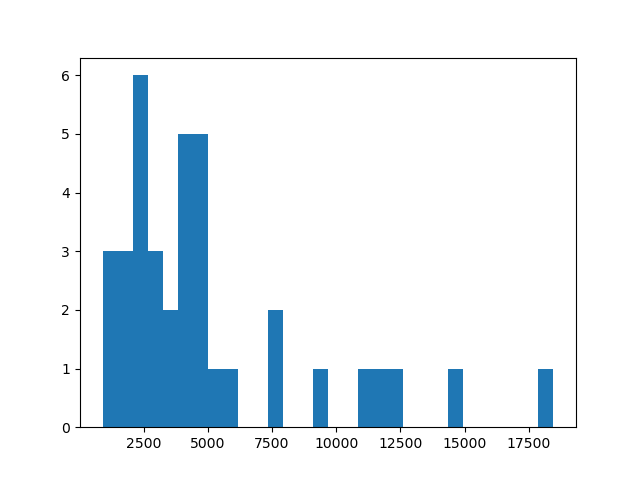

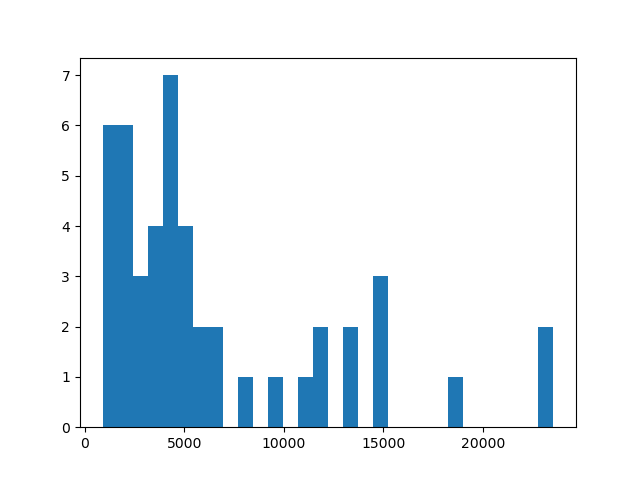

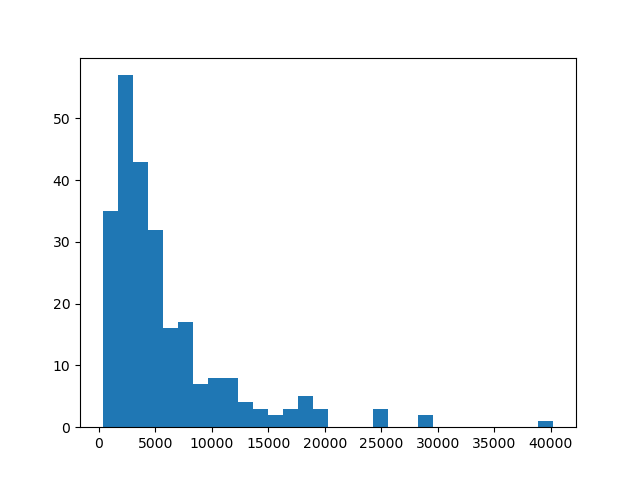

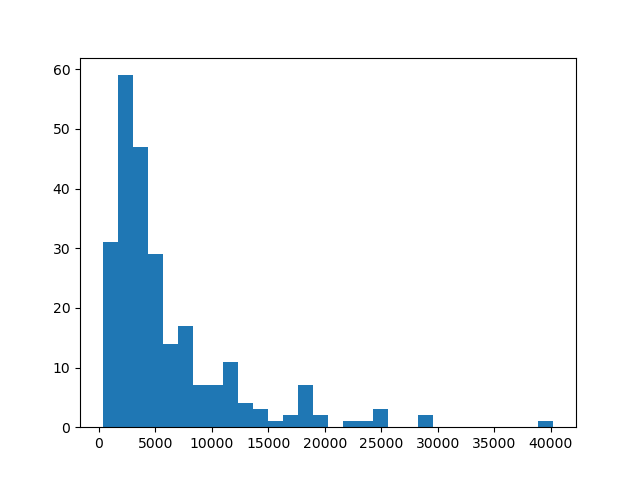

In [12]:
# print (valids_seal.loc_err.min(), valids_seal.loc_err.max())
plt.figure()
plt.hist(valids_sealargo_basstr.loc_err, bins=30)

plt.figure()
plt.hist(valids_sealani_basstr.loc_err, bins=30)

plt.figure()
plt.hist(valids_sealargo_imos.loc_err, bins=30)

plt.figure()
plt.hist(valids_sealani_imos.loc_err, bins=30)

## Visualize all validation matchups for manual QC

In [13]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.patches import Polygon as Pgon
import gc

In [14]:
def prepare_data(df, dataset_path, id):
    """Prepare list of unique Landsat files and clean dataframe"""
    os.chdir(dataset_path)
    
    lsatfiles = sorted([f for f in os.listdir(dataset_path) if f.startswith('L')])
    
    # Remove duplicates
    
    duplicate_mask = df[id].duplicated(keep='first')
    df_clean = df[~duplicate_mask].reset_index(drop=True)  # Reset index for easy indexing
    print(f'{duplicate_mask.sum()} duplicates removed, {df_clean.shape[0]} remain')
    
    del duplicate_mask
    gc.collect()
    
    return lsatfiles, df_clean

def handle_idl_crossing(ilon, ilat, xmin, xmax, ymin, ymax, ls_scene):
    """Handle International Date Line crossing for coordinates"""
    crosses_idl = (xmin > xmax) or (xmin > 170 and xmax < -170)
    
    if crosses_idl:
        print ('crosses IDL')
        # Shift to 0-360
        if ilon < 0:
            ilon += 360
        if xmin < 0:
            xmin += 360
        if xmax < 0:
            xmax += 360
    
    return ilon, xmin, xmax, crosses_idl

def plot_matchup(ax, row, lsatfile, dataset_path, dataset, calib_m, calib_b, 
                 lthresh, dist, lat_col='A_lat', lon_col='A_lon', 
                 sst_col='L8_SST', insitu_col='seal_SST', label_prefix='Seal (Argos)',
                 vmin=-1.85, vmax=1.3, plot_index=None, removal_indices=None):  # Added parameters
    """Plot a single matchup on the given axis - plotting in native EPSG:3031"""
    
    ilat = row[lat_col]
    ilon = row[lon_col]
    
    lat_add = sut.km_to_decimal_degrees(dist, ilat, direction='latitude')
    lon_add = sut.km_to_decimal_degrees(dist, ilat, direction='longitude')
    xmin, ymin, xmax, ymax = (ilon - lon_add, ilat - lat_add, 
                              ilon + lon_add, ilat + lat_add)
    
    try:
        # Open dataset without loading data
        with xr.open_dataset(dataset_path / lsatfile, 
                            chunks=dict(x=512, y=512),
                            engine='rasterio') as ds:
            
            ls_scene = ds['band_data'].sel(band=1)
            ls_scene = ls_scene.rio.write_crs("epsg:3031", inplace=True)
            
            # Transform Argo point to EPSG:3031
            from pyproj import Transformer
            transformer_to_3031 = Transformer.from_crs("EPSG:4326", "EPSG:3031", always_xy=True)
            
            # Transform corners to get bounding box in EPSG:3031
            x_coords, y_coords = transformer_to_3031.transform(
                [xmin, xmin, xmax, xmax],
                [ymin, ymax, ymin, ymax]
            )
            
            # Transform Argos point
            argo_x, argo_y = transformer_to_3031.transform(ilon, ilat)
            
            x_min_3031 = min(x_coords)
            x_max_3031 = max(x_coords)
            y_min_3031 = min(y_coords)
            y_max_3031 = max(y_coords)
            
            # Add buffer
            buffer = 50000  # 50km buffer in meters
            x_min_3031 -= buffer
            x_max_3031 += buffer
            y_min_3031 -= buffer
            y_max_3031 += buffer
            
            # Subset the data IN NATIVE EPSG:3031
            ls_scene_subset = ls_scene.rio.clip_box(
                minx=x_min_3031,
                miny=y_min_3031,
                maxx=x_max_3031,
                maxy=y_max_3031
            )
            
            ls_scene_subset = ls_scene_subset.compute()
        
        # Cross-calibrate
        ls_scene_subset = ls_scene_subset * calib_m + calib_b
        ls_scene_subset = ls_scene_subset.where(
            ls_scene_subset >= lthresh, np.nan
        )
        
        # Extract to numpy - data is in EPSG:3031 coordinates (meters)
        plot_data = ls_scene_subset.values
        plot_x = ls_scene_subset.x.values
        plot_y = ls_scene_subset.y.values
        
        del ls_scene_subset
        gc.collect()
        
        # ✅ CHECK IF THERE'S VALID DATA
        valid_data = plot_data[~np.isnan(plot_data)]
        
        if len(valid_data) == 0:
            # No valid data
            ax.text(0.5, 0.5, 'No Valid Data', 
                    transform=ax.transAxes, ha='center', va='center', 
                    fontsize=12, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))
            return None
        
        # ✅ USE FIXED VMIN/VMAX (passed as parameters)
        # Don't calculate from data - use the fixed range
        
        # Plot in EPSG:3031 (native projection)
        extent = [plot_x.min(), plot_x.max(), plot_y.min(), plot_y.max()]
        
        im_obj = ax.imshow(
            plot_data,
            extent=extent,
            vmin=vmin,  # ✅ Fixed colorbar minimum
            vmax=vmax,  # ✅ Fixed colorbar maximum
            origin='upper',
            cmap='viridis'
        )
        
        del plot_data, valid_data
        gc.collect()
        
    except Exception as e:
        print(f"Error plotting {lsatfile}: {e}")
        import traceback
        traceback.print_exc()
        return None
    
    # REMOVE ALL AXIS LABELS AND TICKS
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title('')
    
    # ✅ ADD BLACK OUTLINE IF NOT IN REMOVAL INDICES
    if plot_index is not None and removal_indices is not None:
        if plot_index not in removal_indices:
            # This plot will be KEPT - add black outline
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_color('black')
                spine.set_linewidth(2.0)
        else:
            # This plot will be REMOVED - no outline
            for spine in ax.spines.values():
                spine.set_visible(False)
    else:
        # Default behavior - turn off axis spines
        for spine in ax.spines.values():
            spine.set_visible(False)
    
    # 50% MORE ZOOMED IN: 20km → 13.3km view window
    view_buffer = 13333  # ~13.3km view window in meters (50% zoom)
    ax.set_xlim([argo_x - view_buffer, argo_x + view_buffer])
    ax.set_ylim([argo_y - view_buffer, argo_y + view_buffer])
    
    # PLOT AS A DOT (small circle marker)
    ax.scatter([argo_x], [argo_y], c='red', s=20, marker='o', 
               label=f'{label_prefix} location', zorder=10, 
               linewidths=0.5)
    
    # Draw bounding box in EPSG:3031 coordinates
    box_width = x_max_3031 - x_min_3031 - 2*buffer
    box_height = y_max_3031 - y_min_3031 - 2*buffer
    rect = Rectangle((x_min_3031 + buffer, y_min_3031 + buffer), 
                     box_width, box_height,
                     edgecolor='red', facecolor='none', linewidth=1.5, zorder=10)
    ax.add_patch(rect)
    
    # Text label
    if label_prefix.startswith('Seal'):
        text_str = (
            f"{row['seal_id'][:5]} {row['seal_id'][-19:]}\n"
            f"{label_prefix} Temp: {np.around(row[insitu_col], 2)}\n"
            f"Landsat SST: {np.around(row[sst_col], 2)}"
        )
    elif label_prefix.startswith('Argo'):
        text_str = (
            f"{row['Argo_id']}\n"
            f"{label_prefix} Temp: {np.around(row[insitu_col], 2)}\n"
            f"Landsat SST: {np.around(row[sst_col], 2)}"
        )
    ax.text(0.02, 0.98, text_str, transform=ax.transAxes,
            fontsize=9, va='top', ha='left', bbox=dict(boxstyle='round', 
            facecolor='white', alpha=0.7, pad=0.3), zorder=10)
    
    gc.collect()
    
    return im_obj


def create_matchup_plots(df, lsatfiles, dataset_path, dataset, output_filename,
                        calib_m, calib_b, lthresh, dist,
                        lat_col='A_lat', lon_col='A_lon',
                        sst_col='L8_SST', insitu_col='seal_SST',
                        label_prefix='Seal (Argos)',
                        plots_per_page=12, n_cols=4,
                        vmin=-1.85, vmax=1.3, removal_indices=None):  # Added fixed colorbar range parameters
    """
    Create multi-page PDF with matchup plots
    
    Returns ONLY a list mapping plot index to seal_id
    """
    
    # Calculate rows per page
    n_rows = plots_per_page // n_cols
    
    # Define spacing parameters
    plot_height = 2.5
    colorbar_height = 0.4
    
    # Collect all rows to plot
    all_rows = []
    plot_index_to_seal_id = []
    
    for lsatfile in lsatfiles:
        mrow = df[df['L8_filename'].str.contains(lsatfile[:-15])]
        
        for idx, row in mrow.iterrows():
            all_rows.append((idx, lsatfile, row))
            if label_prefix.startswith('Seal'):
                plot_index_to_seal_id.append(row['seal_id'])
            elif label_prefix.startswith('Argo'):
                plot_index_to_seal_id.append(row['Argo_id']) 
    
    total_plots = len(all_rows)
    total_pages = int(np.ceil(total_plots / plots_per_page))
    
    print(f"Creating {total_plots} plots across {total_pages} pages...")
    print(f"Colorbar range: {vmin}°C to {vmax}°C")  # Show colorbar range
    
    # Import psutil for memory monitoring
    import psutil
    
    # Try to import malloc_trim for memory release
    try:
        import ctypes
        libc = ctypes.CDLL("libc.so.6")
        has_malloc_trim = True
    except:
        has_malloc_trim = False
    
    with PdfPages(output_filename) as pdf:
        for page_num in range(total_pages):
            start_idx = page_num * plots_per_page
            end_idx = min(start_idx + plots_per_page, total_plots)
            plots_this_page = end_idx - start_idx
            
            rows_this_page = int(np.ceil(plots_this_page / n_cols))
            fig_height = rows_this_page * plot_height + colorbar_height
            
            fig = plt.figure(figsize=(9, fig_height))
            
            from matplotlib.gridspec import GridSpec
            
            plot_ratio = plot_height / fig_height
            cbar_ratio = colorbar_height / fig_height
            height_ratios = [plot_ratio] * rows_this_page + [cbar_ratio]
            
            gs = GridSpec(rows_this_page + 1, n_cols, 
                         figure=fig,
                         hspace=0.01,
                         wspace=0.01,
                         height_ratios=height_ratios,
                         left=0.02, right=0.98, top=0.99, bottom=0.01)
            
            axes = []
            for row in range(rows_this_page):
                for col in range(n_cols):
                    ax = fig.add_subplot(gs[row, col])
                    axes.append(ax)
            
            im_obj = None
            
            plt.close('all')
            gc.collect()
            gc.collect()
            gc.collect()
            if has_malloc_trim:
                libc.malloc_trim(0)
            
            # Plot each matchup on this page
            for i, (orig_idx, lsatfile, row) in enumerate(all_rows[start_idx:end_idx]):
                ax = axes[i]
                plot_num = start_idx + i
                print(f"Page {page_num + 1}/{total_pages}, Plot {i + 1}/{plots_this_page} (index {plot_num}): {lsatfile}")
                
                im_obj = plot_matchup(
                    ax, row, lsatfile, dataset_path, dataset,
                    calib_m, calib_b, lthresh, dist,
                    lat_col=lat_col, lon_col=lon_col,
                    sst_col=sst_col, insitu_col=insitu_col,
                    label_prefix=label_prefix,
                    vmin=vmin, vmax=vmax,
                    plot_index=plot_num, removal_indices=removal_indices  # ✅ Added parameters
                )

                # Add index for dataset 
                ax.text(
                    0.02, 0.02,
                    f"{plot_num}",
                    transform=ax.transAxes,
                    fontsize=8,
                    ha="left",
                    va="bottom",
                    fontweight='bold',
                    zorder=10
                )
                
                gc.collect()
                gc.collect()
                
                if (i + 1) % 3 == 0:
                    process = psutil.Process()
                    mem_gb = process.memory_info().rss / 1024 / 1024 / 1024
                    print(f"  Memory after {i+1} plots: {mem_gb:.2f} GB")
                    
                    gc.collect()
                    gc.collect()
                    gc.collect()
                    
                    if has_malloc_trim:
                        libc.malloc_trim(0)
                    
                    if mem_gb > 15:
                        print("High memory - extra aggressive cleanup")
                        plt.close('all')
                        gc.collect()
                        gc.collect()
                        gc.collect()
                        if has_malloc_trim:
                            libc.malloc_trim(0)
            
            # Hide unused subplots
            for i in range(plots_this_page, len(axes)):
                axes[i].axis('off')
            
            # Add colorbar at bottom using GridSpec
            cbar_ax = fig.add_subplot(gs[-1, :])
            cbar = fig.colorbar(
                im_obj,
                cax=cbar_ax,
                orientation='horizontal'
            )
            cbar.set_label("Temperature [°C]", fontsize=12)
            cbar.ax.tick_params(labelsize=10)
            
            pdf.savefig(fig, bbox_inches='tight', dpi=300, pad_inches=0.02)
            plt.close(fig)
            
            del fig, axes, gs, cbar_ax, cbar
            gc.collect()
            gc.collect()
            gc.collect()
            if has_malloc_trim:
                libc.malloc_trim(0)
    
    print(f"Saved to {output_filename}")
    
    del all_rows
    gc.collect()
    
    return plot_index_to_seal_id

In [15]:
# Choosing index from pictures above starting count at 0
rm_idx_argoI = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,30,31,32,33,34,35,36,37,38,40,41,43,46,47,48,50,52,53,54,55,56,57,58,59,62,64,65,66,67,68,69,70,71,74,75,76,77,78,80,81,82,83,84,85,87,89,92,93,94,99,100,101,102,103,104,105,106,110,111,112,113,114,115,116,117,118,119,120,122,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,147,148,149,150,151,152,153,154,162,163,164,165,166,167,168,169,170,175,176,177,178,180,181,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,203,205,206,207,208,209,210,211,212,214,215,216,217,218,219,223,224,225,226,227,228,229,230,232,233,234,236]
rm_idx_aniI = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,43,44,45,46,47,48,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,75,76,77,78,79,81,82,83,84,85,84,85,87,89,92,95,96,97,98,99,100,101,102,103,104,105,107,112,113,114,115,116,117,118,119,120,121,122,123,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,167,168,169,171,172,173,174,179,180,181,182,183,185,186,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,208,210,211,212,213,214,215,216,217,218,219,220,221,224,225,226,227,228,229,230,232,233,234,235,236,238,239]
rm_idx_argoB = [1,2,3,6,7,14,15,16,17,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33] 
rm_idx_aniB = [1,3,5,6,7,14,15,16,17,18,19,20,21,22,23,24,25,29,30,31,32,33,34,35,36,37,38] 
rm_idx_A = [1,2,3,4,7,8,9,10,11,12,13,14,15,16,17,18,19,23,24,25,26,27,30,31,32,36,39,41,42,43,45,46,47,49,50,52,53,54,56,57,61,62,63,64,65,66,67,68,69,72,73,74,76,77,78,80,81,82,83,85,86,87,88,89,90,91,92,93,94,95,96,97,99] #[1,2,3,4,7,8,9,10,11,12,13,15,16,17,18,20,24,27,28,29,30,32,33,34,35,36,37,38,39,40,41,43,44,48,49,50,51,52,53,55,57,58,59,60,61,62,63,64,66,67,68,69,70,71,72,73,74,75,77]

In [16]:
# Main execution with removal capability
datasets_to_process = [
    {
        'name': 'Argo',
        'df_argo': valids_argo,
        'platform': 'float',
        'path': iqvalid_path,
    },
    {
        'name': 'IMOS',
        'df_argo': valids_sealargo_imos, # 72 yields 57 images after removing duplicates 72:160 yields 65 plots
        'df_ani': valids_sealani_imos,
        'platform': 'seal',
        'path': svalid_path / 'IMOS',
    },
    {
        'name': 'BASSTR',
        'df_argo': valids_sealargo_basstr,
        'df_ani': valids_sealani_basstr,
        'platform': 'seal',
        'path': svalid_path / 'BASSTR',
    }
]

removal_indices = {
    'df_argo': rm_idx_A,
    'df_sealargo_imos': rm_idx_argoI,
    'df_sealani_imos': rm_idx_aniI,
    'df_sealargo_basstr': rm_idx_argoB,
    'df_sealani_basstr': rm_idx_aniB
}

# Main execution - don't store cleaned_dfs at all
plot_mappings = {}

for ds_info in datasets_to_process:
    dataset = ds_info['name']
    dataset_path = ds_info ['path']
    
    print(f"\n{'='*60}")
    print(f"Processing {dataset} dataset")
    print(f"{'='*60}")

    if ds_info['platform']=='float':
        # Prepare data
        lsatfiles, df_sealargo_clean = prepare_data(ds_info['df_argo'], dataset_path, id='Argo_id')
        
        # Create plots for Argo - ONLY store the mapping
        print(f"\nCreating Argo location matchups...")
        mapping_key = f"df_argo"

        plot_mappings[mapping_key] = create_matchup_plots(
            df=df_sealargo_clean,
            lsatfiles=lsatfiles,
            dataset_path=dataset_path,
            dataset=dataset,
            output_filename=basepath / f'Figures/validation_iquam_{dataset}.pdf',
            calib_m=calib_m,
            calib_b=calib_b,
            lthresh=lthresh,
            dist=dist,
            lat_col='A_lat',
            lon_col='A_lon',
            sst_col='L8_SST',
            insitu_col='Argo_SST',
            label_prefix='Argo float',
            removal_indices=removal_indices.get(mapping_key, None),
            plots_per_page=16,  # Reduced for memory
            n_cols=4
        )
    
        # Save plot order
        with open(basepath / f"Figures/{mapping_key}_plot_mapping.json", "w") as f:
            json.dump(plot_mappings[mapping_key], f)
        
        # Clean up immediately
        del df_sealargo_clean
        gc.collect()

    # Plot argo and animotum for seals
    elif ds_info['platform']=='seal':
        # Prepare data
        lsatfiles, df_sealargo_clean = prepare_data(ds_info['df_argo'], dataset_path,id='seal_id')
        _, df_sealani_clean = prepare_data(ds_info['df_ani'], dataset_path,id='seal_id')

        # Create plots for Argo - ONLY store the mapping
        print(f"\nCreating Argo location matchups...")
        mapping_key = f"df_sealargo_{dataset.lower()}"
        
        plot_mappings[mapping_key] = create_matchup_plots(
            df=df_sealargo_clean,
            lsatfiles=lsatfiles,
            dataset_path=dataset_path,
            dataset=dataset,
            output_filename=basepath / f'Figures/validation_seal_{dataset}_argos.pdf',
            calib_m=calib_m,
            calib_b=calib_b,
            lthresh=lthresh,
            dist=dist,
            lat_col='A_lat',
            lon_col='A_lon',
            sst_col='L8_SST',
            insitu_col='seal_SST',
            label_prefix='Seal (Argos)',
            removal_indices=removal_indices.get(mapping_key, None),
            plots_per_page=16,  # Reduced for memory
            n_cols=4
        )
    
        # Save plot order
        with open(basepath / f"Figures/{mapping_key}_plot_mapping.json", "w") as f:
            json.dump(plot_mappings[mapping_key], f)
        
        # Clean up immediately
        del df_sealargo_clean
        gc.collect()
        
        # Create plots for animotum - ONLY store the mapping
        print(f"\nCreating AniMotum location matchups...")
        mapping_key = f"df_sealani_{dataset.lower()}"
    
        plot_mappings[mapping_key] = create_matchup_plots(
            df=df_sealani_clean,
            lsatfiles=lsatfiles,
            dataset_path=dataset_path,
            dataset=dataset,
            output_filename=basepath / f'Figures/validation_seal_{dataset}_animotum.pdf',
            calib_m=calib_m,
            calib_b=calib_b,
            lthresh=lthresh,
            dist=dist,
            lat_col='A_lat_ani',
            lon_col='A_lon_ani',
            sst_col='L8_SST_ani',
            insitu_col='seal_SST',
            label_prefix='Seal (aniMotum)',
            removal_indices=removal_indices.get(mapping_key, None),
            plots_per_page=16,
            n_cols=4
        )
    
        # Save plot order
        with open(basepath / f"Figures/{mapping_key}_plot_mapping.json", "w") as f:
            json.dump(plot_mappings[mapping_key], f)
            
        # Clean up immediately
        del df_sealani_clean, lsatfiles
        gc.collect()

print("\nAll datasets processed!")


Processing Argo dataset
24 duplicates removed, 100 remain

Creating Argo location matchups...
Creating 100 plots across 7 pages...
Colorbar range: -1.85°C to 1.3°C
Page 1/7, Plot 1/16 (index 0): LC08_L1GT_002108_20210331_20210408_02_T2_145547_Cel.tif
Page 1/7, Plot 2/16 (index 1): LC08_L1GT_006109_20200221_20201016_02_T2_152108_Cel.tif
Page 1/7, Plot 3/16 (index 2): LC08_L1GT_008109_20220107_20220114_02_T2_153344_Cel.tif
  Memory after 3 plots: 1.07 GB
Page 1/7, Plot 4/16 (index 3): LC08_L1GT_009109_20200329_20200822_02_T2_153924_Cel.tif
Page 1/7, Plot 5/16 (index 4): LC08_L1GT_023110_20180121_20201016_02_T2_170636_Cel.tif
Page 1/7, Plot 6/16 (index 5): LC08_L1GT_026112_20220310_20220321_02_T2_172555_Cel.tif
  Memory after 6 plots: 1.52 GB
Page 1/7, Plot 7/16 (index 6): LC08_L1GT_029110_20200309_20201016_02_T2_174335_Cel.tif
Page 1/7, Plot 8/16 (index 7): LC08_L1GT_031113_20230212_20230218_02_T2_175732_Cel.tif
Page 1/7, Plot 9/16 (index 8): LC08_L1GT_032113_20230118_20230131_02_T2_180

In [16]:
# Choosing index from pictures above starting count at 0
rm_idx_argoI = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,30,31,32,33,34,35,36,37,38,40,41,43,46,47,48,50,52,53,54,55,56,57,58,59,62,64,65,66,67,68,69,70,71,74,75,76,77,78,80,81,82,83,84,85,87,89,92,93,94,99,100,101,102,103,104,105,106,110,111,112,113,114,115,116,117,118,119,120,122,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,147,148,149,150,151,152,153,154,162,163,164,165,166,167,168,169,170,175,176,177,178,180,181,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,203,205,206,207,208,209,210,211,212,214,215,216,217,218,219,223,224,225,226,227,228,229,230,232,233,234,236]
rm_idx_aniI = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,43,44,45,46,47,48,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,75,76,77,78,79,81,82,83,84,85,84,85,87,89,92,95,96,97,98,99,100,101,102,103,104,105,107,112,113,114,115,116,117,118,119,120,121,122,123,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,167,168,169,171,172,173,174,179,180,181,182,183,185,186,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,208,210,211,212,213,214,215,216,217,218,219,220,221,224,225,226,227,228,229,230,232,233,234,235,236,238,239]
rm_idx_argoB = [1,2,3,6,7,14,15,16,17,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33] 
rm_idx_aniB = [1,3,5,6,7,14,15,16,17,18,19,20,21,22,23,24,25,29,30,31,32,33,34,35,36,37,38] 
rm_idx_A = [1,2,3,4,7,8,9,10,11,12,13,14,15,16,17,18,19,23,24,25,26,27,30,31,32,36,39,41,42,43,45,46,47,49,50,52,53,54,56,57,61,62,63,64,65,66,67,68,69,72,73,74,76,77,78,80,81,82,83,85,86,87,88,89,90,91,92,93,94,95,96,97,99] #[1,2,3,4,7,8,9,10,11,12,13,15,16,17,18,20,24,27,28,29,30,32,33,34,35,36,37,38,39,40,41,43,44,48,49,50,51,52,53,55,57,58,59,60,61,62,63,64,66,67,68,69,70,71,72,73,74,75,77]

## Plot high and low quality validation data


Processing df_sealargo_basstr
seal_SST
Removing 24 seal_ids
Using 10 points for regression
Beta: [ 0.80322612 -0.26140618]
Beta Std Error: [0.08463426 0.08197774]
Beta Covariance: [[0.87391798 0.75681305]
 [0.75681305 0.8199174 ]]
Residual Variance: 0.008196373552818664
Inverse Condition #: 0.04405125251837205
Reason(s) for Halting:
  Sum of squares convergence

R^2: 0.91, RMSE: 0.1, n=10


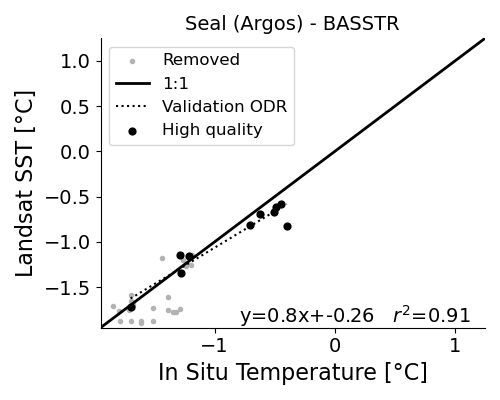


Processing df_sealani_basstr
seal_SST
Removing 27 seal_ids
Using 12 points for regression
Beta: [ 0.66294198 -0.36715114]
Beta Std Error: [0.06063069 0.06958557]
Beta Covariance: [[0.44998782 0.4612375 ]
 [0.4612375  0.59272609]]
Residual Variance: 0.008169289216064399
Inverse Condition #: 0.03764050606037611
Reason(s) for Halting:
  Sum of squares convergence

R^2: 0.92, RMSE: 0.1, n=12


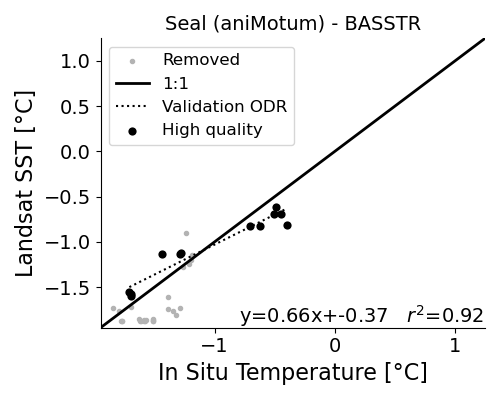


Processing df_sealargo_imos
seal_SST
Removing 179 seal_ids
Using 63 points for regression
Beta: [ 0.70105956 -0.32702883]
Beta Std Error: [0.04327611 0.04302443]
Beta Covariance: [[0.06275088 0.04905525]
 [0.04905525 0.06202311]]
Residual Variance: 0.029845351930747104
Inverse Condition #: 0.06070380666950297
Reason(s) for Halting:
  Sum of squares convergence

R^2: 0.79, RMSE: 0.21, n=63


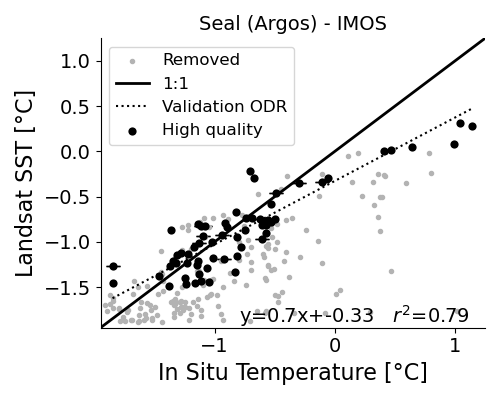


Processing df_sealani_imos
seal_SST
Removing 193 seal_ids
Using 52 points for regression
Beta: [ 0.7496821  -0.26320381]
Beta Std Error: [0.03951505 0.03786291]
Beta Covariance: [[0.07025112 0.04920263]
 [0.04920263 0.06449946]]
Residual Variance: 0.022226538547362798
Inverse Condition #: 0.07024501753228159
Reason(s) for Halting:
  Sum of squares convergence

R^2: 0.87, RMSE: 0.18, n=52


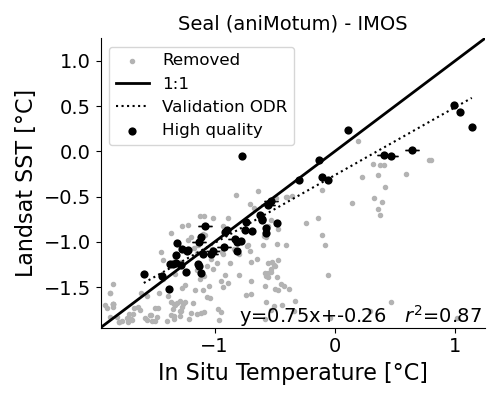


Processing df_argo
Argo_SST
Removing 73 seal_ids
Using 27 points for regression
Beta: [ 0.8594288  -0.26474616]
Beta Std Error: [0.08511807 0.06355827]
Beta Covariance: [[0.1391251  0.04281961]
 [0.04281961 0.07757219]]
Residual Variance: 0.05207604510004532
Inverse Condition #: 0.12730198560498626
Reason(s) for Halting:
  Sum of squares convergence

R^2: 0.77, RMSE: 0.29, n=27


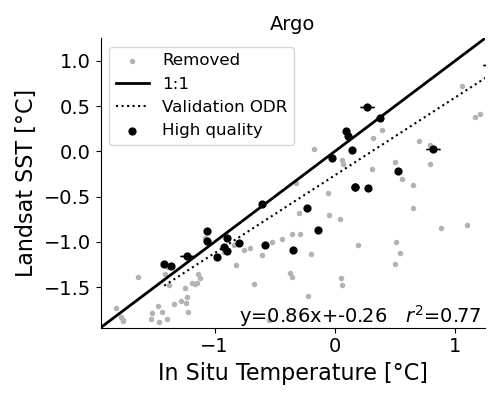


Individual cleaned datasets:
  validmn_sealargo_basstr_clean: 10 rows
  valids_sealargo_basstr_clean: 10 rows
  validmn_sealani_basstr_clean: 12 rows
  valids_sealani_basstr_clean: 12 rows
  validmn_sealargo_imos_clean: 63 rows
  valids_sealargo_imos_clean: 77 rows
  validmn_sealani_imos_clean: 52 rows
  valids_sealani_imos_clean: 63 rows
  validmn_argo_clean: 27 rows
  valids_argo_clean: 31 rows

All processing complete!


In [17]:
# Your removal indices
removal_indices = {
    'df_sealargo_basstr': rm_idx_argoB,
    'df_sealani_basstr': rm_idx_aniB,
    'df_sealargo_imos': rm_idx_argoI,
    'df_sealani_imos': rm_idx_aniI,
    'df_argo': rm_idx_A
}
# seal_sst = 'seal_interp_SST'
seal_sst = 'seal_SST'

# Mapping to original validmn/valids
dataset_mapping = {
    'df_sealargo_basstr': {
        'validmn': validmn_sealargo_basstr,
        'valids': valids_sealargo_basstr,
        'original_df': valids_sealargo_basstr,
        'vcol': seal_sst,
        'lcol': 'L8_SST',
        'id': 'seal_id',
        'label': 'Seal (Argos) - BASSTR'
    },
    'df_sealani_basstr': {
        'validmn': validmn_sealani_basstr,
        'valids': valids_sealani_basstr,
        'original_df': valids_sealani_basstr,
        'vcol': seal_sst,
        'lcol': 'L8_SST_ani',
        'id': 'seal_id',
        'label': 'Seal (aniMotum) - BASSTR'
    },
    'df_sealargo_imos': {
        'validmn': validmn_sealargo_imos,
        'valids': valids_sealargo_imos,
        'original_df': valids_sealargo_imos,
        'vcol': seal_sst,
        'lcol': 'L8_SST',
        'id': 'seal_id',
        'label': 'Seal (Argos) - IMOS'
    },
    'df_sealani_imos': {
        'validmn': validmn_sealani_imos,
        'valids': valids_sealani_imos,
        'original_df': valids_sealani_imos,
        'vcol': seal_sst,
        'lcol': 'L8_SST_ani',
        'id': 'seal_id',
        'label': 'Seal (aniMotum) - IMOS'
    },
    'df_argo': {
        'validmn': validmn_argo,
        'valids': valids_argo,
        'original_df': valids_argo,
        'vcol': 'Argo_SST',
        'lcol': 'L8_SST',
        'id': 'Argo_id',
        'label': 'Argo'
    }
}

def linear_model(p, x):
    return p[0] * x + p[1]

def load_plot_mapping(mapping_key, basepath):
    mapping_file = basepath / f"Figures/{mapping_key}_plot_mapping.json"
    with open(mapping_file, "r") as f:
        mapping = json.load(f)
    return mapping

# Store cleaned versions
validmn_sealargo_basstr_clean = None
valids_sealargo_basstr_clean = None
validmn_sealani_basstr_clean = None
valids_sealani_basstr_clean = None
validmn_sealargo_imos_clean = None
valids_sealargo_imos_clean = None
validmn_sealani_imos_clean = None
valids_sealani_imos_clean = None
validmn_argo_clean = None
valids_argo_clean = None

# Process each dataset
for key in dataset_mapping.keys():
    print(f"\n{'='*60}")
    print(f"Processing {key}")
    print(f"{'='*60}")

    dmap = dataset_mapping[key]
    validmn = dmap['validmn']
    valids = dmap['valids']
    vcol = dmap['vcol']
    lcol = dmap['lcol']
    id = dmap['id']
    label = dmap['label']

    print(vcol)

    rm_idx = removal_indices.get(key, [])

    # Remove bad data
    if rm_idx:
        # Reload dataframes saved above
        mapping = load_plot_mapping(key, basepath)
        rm_seal_ids = [mapping[i] for i in rm_idx if i < len(mapping)]
        print(f"Removing {len(rm_seal_ids)} seal_ids")
        
        rm = validmn[validmn[id].isin(rm_seal_ids)]

        validmn_clean = validmn[~validmn[id].isin(rm_seal_ids)].copy()
        valids_clean = valids[~valids[id].isin(rm_seal_ids)].copy()
    else:
        print("No removals")
        rm = validmn[validmn[id].isin([])]
        validmn_clean = validmn.copy()
        valids_clean = valids.copy()
    
    # Store in appropriately named variables
    if key == 'df_sealargo_basstr':
        validmn_sealargo_basstr_clean = validmn_clean
        valids_sealargo_basstr_clean = valids_clean
    elif key == 'df_sealani_basstr':
        validmn_sealani_basstr_clean = validmn_clean
        valids_sealani_basstr_clean = valids_clean
    elif key == 'df_sealargo_imos':
        validmn_sealargo_imos_clean = validmn_clean
        valids_sealargo_imos_clean = valids_clean
    elif key == 'df_sealani_imos':
        validmn_sealani_imos_clean = validmn_clean
        valids_sealani_imos_clean = valids_clean
    elif key == 'df_argo':
        validmn_argo_clean = validmn_clean
        valids_argo_clean = valids_clean
        
    # Prepare data for individual plot
    data = validmn_clean.dropna(subset=[lcol, vcol], how='any')
    # data = data[data[vcol] <= 0.0]

    if len(data) == 0:
        print(f"No valid data, skipping plot")
        continue
    
    # Calculate std
    std_data = valids_clean.groupby(id)[lcol].std().reset_index()
    std_data.columns = [id, 'std_calc']
    data = data.merge(std_data, on=id, how='left')
    
    print(f"Using {len(data)} points for regression")
    
    # ODR
    x_original = np.array(data[vcol])
    y_original = np.array(data[lcol])
    
    linear = Model(linear_model)
    mdata = RealData(x_original, y_original)
    odr = ODR(mdata, linear, beta0=[1., 0.])
    out = odr.run()
    
    beta = out.beta
    beta_err = out.sd_beta
    out.pprint()
    
    y_pred = linear_model(beta, x_original)
    y_mean = np.mean(y_original)
    SST = np.sum((y_original - y_mean)**2)
    SSR = np.sum((y_original - y_pred)**2)
    R2 = 1 - (SSR / SST)
    rmse = np.sqrt(((y_original - y_pred) ** 2).mean())
    
    print(f"\nR^2: {np.around(R2, 2)}, RMSE: {np.around(rmse, 2)}, n={len(data)}")


    # Sort x and y together
    sorted_indices = np.argsort(x_original)
    x_original = x_original[sorted_indices]
    y_original = y_original[sorted_indices]
    sorted_indices = np.argsort(y_pred)
    y_pred = y_pred[sorted_indices]

    
    # Plot
    beta_bdn = [beta[0] - beta_err[0]*1.96, beta[1] + beta_err[1]*1.96]
    beta_mup = [beta[0] + beta_err[0]*1.96, beta[1] - beta_err[1]*1.96]
    xfill = np.array([-4.3, 0.9])
    
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.tick_params(labelsize=14)
    xi = np.arange(-7.0, 5.0, 1.0)
    
    ax.errorbar(x_original, y_original, yerr=data['std_calc'], color='k', fmt='o', 
               ecolor='k', elinewidth=1, capthick=1, marker='o', ms=3, capsize=5, 
               label='_no legend_')
    
    if len(rm) > 0:
        ax.scatter(rm[vcol], rm[lcol], color='0.7', marker='.', s=35, label='Removed', zorder=2)
    
    ax.plot(xi, xi, color='k', linewidth=2, label='1:1')
    ax.plot(x_original, y_pred, color='k', ls=':', label='Validation ODR')
    # ax.fill_between(xfill, linear_model(beta_bdn, xfill), linear_model(beta_mup, xfill),
    #                  alpha=0.1, facecolor='0.3')
    ax.scatter(x_original, y_original, color='k', linewidth=0, s=35, label='High quality', zorder=10)
    
    ax.text(-0.8, -1.9, f'y={np.around(beta[0], 2)}x+{np.around(beta[1], 2)}   $r^2$={np.around(R2, 2)}',
            fontsize=14)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim([-1.95, 1.25])
    ax.set_xlim([-1.95, 1.25])
    ax.set_xlabel('In Situ Temperature [°C]', fontsize=16)
    ax.set_ylabel('Landsat SST [°C]', fontsize=16)
    ax.set_title(label, fontsize=14)
    ax.legend(markerscale=1, fontsize=12, loc='upper left')
    plt.tight_layout()
    plt.show()
    
    del data, std_data, x_original, y_original, y_pred
    gc.collect()

print(f"\n{'='*60}")
print("Individual cleaned datasets:")
print(f"  validmn_sealargo_basstr_clean: {len(validmn_sealargo_basstr_clean)} rows")
print(f"  valids_sealargo_basstr_clean: {len(valids_sealargo_basstr_clean)} rows")
print(f"  validmn_sealani_basstr_clean: {len(validmn_sealani_basstr_clean)} rows")
print(f"  valids_sealani_basstr_clean: {len(valids_sealani_basstr_clean)} rows")
print(f"  validmn_sealargo_imos_clean: {len(validmn_sealargo_imos_clean)} rows")
print(f"  valids_sealargo_imos_clean: {len(valids_sealargo_imos_clean)} rows")
print(f"  validmn_sealani_imos_clean: {len(validmn_sealani_imos_clean)} rows")
print(f"  valids_sealani_imos_clean: {len(valids_sealani_imos_clean)} rows")
print(f"  validmn_argo_clean: {len(validmn_argo_clean)} rows")
print(f"  valids_argo_clean: {len(valids_argo_clean)} rows")
print(f"{'='*60}")

print("\nAll processing complete!")

Processing df_sealargo_basstr
  df_sealargo_basstr: R²=0.914, RMSE=0.104, n=10
Processing df_sealargo_imos
  df_sealargo_imos: R²=0.790, RMSE=0.208, n=63
Processing df_sealani_basstr
  df_sealani_basstr: R²=0.920, RMSE=0.099, n=12
Processing df_sealani_imos
  df_sealani_imos: R²=0.869, RMSE=0.183, n=52
Processing df_argo
  df_argo: R²=0.773, RMSE=0.290, n=27


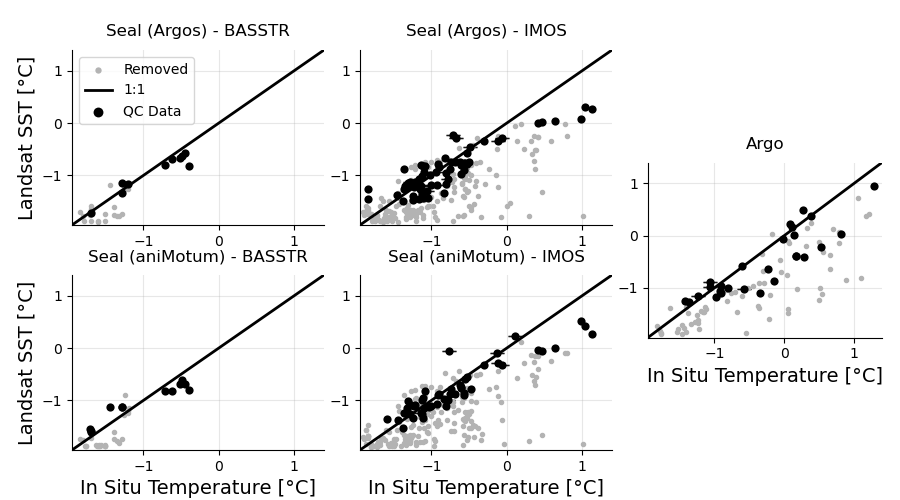

In [18]:
def create_combined_validation_plot(dataset_mapping, removal_indices, basepath, 
                                   seal_sst='seal_SST', figsize=(15, 10)):
    """
    Create a combined 5-panel validation plot.
    Layout: BASSTR Argos, IMOS Argos (top row)
            BASSTR aniMotum, IMOS aniMotum (bottom row)  
            Argo Floats (right side, centered vertically)
    """
    
    def linear_model(p, x):
        return p[0] * x + p[1]
    
    def load_plot_mapping(mapping_key, basepath):
        mapping_file = basepath / f"Figures/{mapping_key}_plot_mapping.json"
        with open(mapping_file, "r") as f:
            mapping = json.load(f)
        return mapping
    
    # Create figure with custom subplot layout
    fig = plt.figure(figsize=figsize)
    
    # Define subplot positions [left, bottom, width, height] for 8x8 figure
    # Top row: BASSTR Argos, IMOS Argos
    ax1 = fig.add_axes([0.08, 0.55, 0.28, 0.35])   # BASSTR Argos
    ax2 = fig.add_axes([0.40, 0.55, 0.28, 0.35])   # IMOS Argos
    
    # Bottom row: BASSTR aniMotum, IMOS aniMotum  
    ax3 = fig.add_axes([0.08, 0.10, 0.28, 0.35])   # BASSTR AniMotum
    ax4 = fig.add_axes([0.40, 0.10, 0.28, 0.35])   # IMOS AniMotum
    
    # Right side: Argo Floats (centered vertically)
    ax5 = fig.add_axes([0.72, 0.325, 0.26, 0.35])  # Argo Floats
    
    # Define plot order and axes
    plot_order = [
        ('df_sealargo_basstr', ax1),
        ('df_sealargo_imos', ax2), 
        ('df_sealani_basstr', ax3),
        ('df_sealani_imos', ax4),
        ('df_argo', ax5)
    ]
    
    # Process each dataset and create plots
    for key, ax in plot_order:
        print(f"Processing {key}")
        
        dmap = dataset_mapping[key]
        validmn = dmap['validmn']
        valids = dmap['valids']
        vcol = dmap['vcol'] if key != 'df_argo' else dmap['vcol']
        lcol = dmap['lcol']
        id_col = dmap['id']
        label = dmap['label']
        
        rm_idx = removal_indices.get(key, [])
        
        # Remove bad data
        if rm_idx:
            mapping = load_plot_mapping(key, basepath)
            rm_seal_ids = [mapping[i] for i in rm_idx if i < len(mapping)]
            validmn_clean = validmn[~validmn[id_col].isin(rm_seal_ids)]
            valids_clean = valids[~valids[id_col].isin(rm_seal_ids)]
            rm = validmn[validmn[id_col].isin(rm_seal_ids)]
        else:
            validmn_clean = validmn.copy()
            valids_clean = valids.copy()
            rm = validmn[validmn[id_col].isin([])]
        
        # Prepare data
        data = validmn_clean.dropna(subset=[lcol, vcol], how='any')
        
        if len(data) == 0:
            print(f"No valid data for {key}, skipping")
            continue
        
        # Calculate std
        std_data = valids_clean.groupby(id_col)[lcol].std().reset_index()
        std_data.columns = [id_col, 'std_calc']
        data = data.merge(std_data, on=id_col, how='left')
        
        # ODR
        x_original = np.array(data[vcol])
        y_original = np.array(data[lcol])
        
        linear = Model(linear_model)
        mdata = RealData(x_original, y_original)
        odr = ODR(mdata, linear, beta0=[1., 0.])
        out = odr.run()
        
        beta = out.beta
        beta_err = out.sd_beta
        
        y_pred = linear_model(beta, x_original)
        y_mean = np.mean(y_original)
        SST = np.sum((y_original - y_mean)**2)
        SSR = np.sum((y_original - y_pred)**2)
        R2 = 1 - (SSR / SST)
        rmse = np.sqrt(((y_original - y_pred) ** 2).mean())
        
        # Plot
        xi = np.arange(-7.0, 5.0, 1.0)
        
        # Error bars
        ax.errorbar(x_original, y_original, yerr=data['std_calc'], color='k', fmt='o', 
                   ecolor='k', elinewidth=1, capthick=1, marker='o', ms=3, capsize=5, 
                   label='_no legend_', alpha=0.7)
        
        # Removed points
        if len(rm) > 0:
            ax.scatter(rm[vcol], rm[lcol], color='0.7', marker='.', s=35, 
                      label='Removed', zorder=2)
        
        # Reference lines
        ax.plot(xi, xi, color='k', linewidth=2, label='1:1')
        # ax.plot(x_original, y_pred, color='k', ls=':', linewidth=2, label='ODR fit')
        
        # Data points
        ax.scatter(x_original, y_original, color='k', linewidth=0, s=35, 
                  label='QC Data', zorder=10)
        
        # # Statistics text
        # ax.text(-1.7, 0.5, f'y={beta[0]:.2f}x+{beta[1]:.2f}\n$r^2$={R2:.2f}', 
        #         fontsize=12, verticalalignment='bottom')
        
        # Formatting
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_ylim([-1.95, 1.4])
        ax.set_xlim([-1.95, 1.4])
        ax.grid(alpha=0.3)
        
        # Labels (only on edge plots)
        if ax in [ax1, ax3]:  # Left column
            ax.set_ylabel('Landsat SST [°C]', fontsize=14)
        if ax in [ax3, ax4, ax5]:  # Bottom row + Argo
            ax.set_xlabel('In Situ Temperature [°C]', fontsize=14)
            
        # Titles
        ax.set_title(label, fontsize=12, pad=10)
        
        # Legend (only on first plot)
        if ax == ax1:
            ax.legend(markerscale=1.2, fontsize=10, loc='upper left')
        
        print(f"  {key}: R²={R2:.3f}, RMSE={rmse:.3f}, n={len(data)}")
    
    plt.show()
    
    return fig

# Usage:
fig = create_combined_validation_plot(dataset_mapping, removal_indices, basepath, 
                                     seal_sst=seal_sst, figsize=(9,5))
save_path = basepath / 'Figures/SuppQC.png'
fig.savefig(save_path, dpi=300, bbox_inches='tight')

### All together - testing for time difference and location error thresholds

In [19]:
from scipy.stats import binned_statistic
from scipy.stats import levene, bartlett, f
from scipy.stats import shapiro

In [20]:
# Parse the qc string and extract x and y errors, converting to km as needed
def extract_location_error(qc_string, convert_to_km=True):
    """Extract x and y errors from qc string and calculate loc_err in km"""
    try:
        # Parse the string as a list
        values = json.loads(qc_string)
        x_error = values[2]  # 3rd element (0-indexed)
        y_error = values[3]  # 4th element (0-indexed)
        
        # Calculate RMS error
        loc_err = np.sqrt(x_error**2 + y_error**2)
        
        # Convert meters to km if needed
        if convert_to_km:
            loc_err = loc_err / 1000
            
        return loc_err
    except:
        return np.nan


def lon_distance(lon1, lon2):
    """
    Calculate the shortest angular distance between two longitudes,
    accounting for the International Date Line wrap-around.
    
    Returns the absolute difference in the range [0, 180].
    """
    diff = abs(lon1 - lon2)
    # If difference is greater than 180, the shorter path crosses the IDL
    if diff > 180:
        diff = 360 - diff
    return diff

In [21]:
# A weird repeat is in the Argo data, this can be removed earlier but leaving here for now 
# until can rerun the visuals for it
validmn_argo_clean = validmn_argo_clean[
    validmn_argo_clean['Argo_id'] != '6903773-2021-01-31 05:41:00'
]
valids_argo_clean = valids_argo_clean[
    valids_argo_clean['Argo_id'] != '6903773-2021-01-31 05:41:00'
]

In [22]:
# Apply to dataset (convert meters to km) and drop ALL existing loc_err[km] variants and merge
# BASSTR
valids_sealani_basstr_clean['loc_err[km]'] = valids_sealani_basstr_clean['qc[x_y_xse_yse]'].apply(
    lambda x: extract_location_error(x, convert_to_km=True)
)

validmn_sealani_basstr_clean = validmn_sealani_basstr_clean.drop(
    columns=[col for col in validmn_sealani_basstr_clean.columns if 'loc_err[km]' in col],
    errors='ignore'
)

validmn_sealani_basstr_clean = validmn_sealani_basstr_clean.merge(
    valids_sealani_basstr_clean.groupby('seal_id')['loc_err[km]'].mean().reset_index(),
    on='seal_id',
    how='left'
)


#IMOS
valids_sealani_imos_clean['loc_err[km]'] = valids_sealani_imos_clean['qc[x_y_xse_yse]'].apply(
    lambda x: extract_location_error(x, convert_to_km=False)
)

validmn_sealani_imos_clean = validmn_sealani_imos_clean.drop(
    columns=[col for col in validmn_sealani_imos_clean.columns if 'loc_err[km]' in col],
    errors='ignore'
)
validmn_sealani_imos_clean = validmn_sealani_imos_clean.merge(
    valids_sealani_imos_clean.groupby('seal_id')['loc_err[km]'].mean().reset_index(),
    on='seal_id',
    how='left'
)


print(f"BASSTR Argo loc_err[km] range: {valids_sealargo_basstr_clean['loc_err[km]'].min():.2f} - {valids_sealargo_basstr_clean['loc_err[km]'].max():.2f} km")
print(f"IMOS Argo loc_err[km] range: {valids_sealargo_imos_clean['loc_err[km]'].min():.2f} - {valids_sealargo_imos_clean['loc_err[km]'].max():.2f} km")
print('')
print(f"BASSTR AniMotum loc_err[km] range: {valids_sealani_basstr_clean['loc_err[km]'].min():.2f} - {valids_sealani_basstr_clean['loc_err[km]'].max():.2f} km")
print(f"IMOS AniMotum loc_err[km] range: {valids_sealani_imos_clean['loc_err[km]'].min():.2f} - {valids_sealani_imos_clean['loc_err[km]'].max():.2f} km")

BASSTR Argo loc_err[km] range: 0.99 - 18.46 km
IMOS Argo loc_err[km] range: 0.61 - 40.22 km

BASSTR AniMotum loc_err[km] range: 1.68 - 36.02 km
IMOS AniMotum loc_err[km] range: 1.41 - 8.67 km


In [23]:
# Create clean dataframes for merging
all_id = 'id'
L8 = 'L8_SST'
skin_bias = 0.0 #0.17

data0 = validmn_argo_clean
df_argo = pd.DataFrame({
    L8: data0[L8],
    'insitu_SST': data0['Argo_SST'],
    'std': data0['std'],
    all_id: data0['Argo_id'],  # Add seal_id for tracking
    'depth': data0['depth'],
    'DateTime': data0['DateTime'],
    'lat': data0['A_lat'],
    'lon': data0['A_lon'],
    'time_dif': data0['time_dif'],
    'residual': data0[L8] - data0['Argo_SST'] + skin_bias,
    'abs_residual': np.abs(data0[L8]-data0['Argo_SST'] + skin_bias),
    'lon_dist': data0['A_lon'].apply(lambda x: lon_distance(-100, x)),
    'month': pd.to_datetime(data0['DateTime']).dt.month,
    'year': pd.to_datetime(data0['DateTime']).dt.year,
    'time_dif_hours': pd.to_timedelta(data0['time_dif']).dt.total_seconds() / 3600, # Convert to timedelta then hours for plotting
    'source': 'Argo'
})

data0 = validmn_sealargo_basstr_clean
df_sealB = pd.DataFrame({
    L8: data0[L8],
    'insitu_SST': data0[seal_sst],
    'std': data0['std'],
    'loc_err[km]': data0['loc_err[km]'],
    all_id: data0['seal_id'],  
    'depth': data0['depth'],
    'DateTime': data0['DateTime'],
    'lat': data0['A_lat'],
    'lon': data0['A_lon'],
    'time_dif': data0['time_dif'],
    'residual': data0[L8] - data0[seal_sst] + skin_bias,
    'abs_residual': np.abs(data0[L8]-data0[seal_sst] + skin_bias),
    'lon_dist': data0['A_lon'].apply(lambda x: lon_distance(-100, x)),
    'month': pd.to_datetime(data0['DateTime']).dt.month,
    'year': pd.to_datetime(data0['DateTime']).dt.year,
    'time_dif_hours': pd.to_timedelta(data0['time_dif']).dt.total_seconds() / 3600,
    'source': 'Seal (Argos)'
})

data0 = validmn_sealargo_imos_clean
df_sealI = pd.DataFrame({
    L8: data0[L8],
    'insitu_SST': data0[seal_sst],
    'std': data0['std'],
    'loc_err[km]': data0['loc_err[km]'],
    all_id: data0['seal_id'],
    'depth': data0['depth'],
    'DateTime': data0['DateTime'],
    'lat': data0['A_lat'],
    'lon': data0['A_lon'],
    'time_dif': data0['time_dif'],
    'residual': data0[L8]-data0[seal_sst] + skin_bias,
    'abs_residual': np.abs(data0[L8]-data0[seal_sst] + skin_bias),
    'lon_dist': data0['A_lon'].apply(lambda x: lon_distance(-100, x)),
    'month': pd.to_datetime(data0['DateTime']).dt.month,
    'year': pd.to_datetime(data0['DateTime']).dt.year,
    'time_dif_hours': pd.to_timedelta(data0['time_dif']).dt.total_seconds() / 3600,
    'source': 'Seal (Argos)'
})

data0 = validmn_sealani_basstr_clean
df_seal_aniB = pd.DataFrame({
    L8: data0['L8_SST_ani'],
    'insitu_SST': data0[seal_sst],
    'std': data0['std_ani'],
    'loc_err[km]': data0['loc_err[km]'],
    all_id: data0['seal_id'],
    'depth': data0['depth'],
    'DateTime': data0['DateTime'],
    'lat': data0['A_lat_ani'],
    'lon': data0['A_lon_ani'],
    'time_dif': data0['time_dif'],
    'residual': data0['L8_SST_ani']-data0[seal_sst] + skin_bias,
    'abs_residual': np.abs(data0['L8_SST_ani']-data0[seal_sst] + skin_bias),
    'lon_dist': data0['A_lon'].apply(lambda x: lon_distance(-100, x)),
    'month': pd.to_datetime(data0['DateTime']).dt.month,
    'year': pd.to_datetime(data0['DateTime']).dt.year,
    'time_dif_hours': pd.to_timedelta(data0['time_dif']).dt.total_seconds() / 3600,
    'source': 'Seal (aniMotum)'
})

data0 = validmn_sealani_imos_clean
df_seal_aniI = pd.DataFrame({
    L8: data0['L8_SST_ani'],
    'insitu_SST': data0[seal_sst],
    'std': data0['std_ani'],
    'loc_err[km]': data0['loc_err[km]'],
    all_id: data0['seal_id'],
    'depth': data0['depth'],
    'DateTime': data0['DateTime'],
    'lat': data0['A_lat_ani'],
    'lon': data0['A_lon_ani'],
    'time_dif': data0['time_dif'],
    'residual': data0['L8_SST_ani']-data0[seal_sst] + skin_bias,
    'abs_residual': np.abs(data0['L8_SST_ani']-data0[seal_sst] + skin_bias),
    'lon_dist': data0['A_lon'].apply(lambda x: lon_distance(-100, x)),
    'month': pd.to_datetime(data0['DateTime']).dt.month,
    'year': pd.to_datetime(data0['DateTime']).dt.year,
    'time_dif_hours': pd.to_timedelta(data0['time_dif']).dt.total_seconds() / 3600,
    'source': 'Seal (aniMotum)'
})

In [24]:
all_id = 'id'
# all_id = 'seal_id'

# Combine Seal Argos data (BASSTR + IMOS)
df_seal_argo = pd.concat([df_sealB, df_sealI], ignore_index=True)
df_seal_argo = df_seal_argo.dropna(subset=['L8_SST', 'insitu_SST', 'loc_err[km]'])

# Combine Seal AniMotum data
df_seal_ani = pd.concat([df_seal_aniB, df_seal_aniI], ignore_index=True)
df_seal_ani = df_seal_ani.dropna(subset=['L8_SST', 'insitu_SST', 'loc_err[km]'])

# all_id = 'seal_id'
# df_seal_argo = pd.concat([validmn_sealargo_basstr, validmn_sealargo_imos], ignore_index=True)
# df_seal_ani = pd.concat([validmn_sealani_basstr, validmn_sealani_imos], ignore_index=True)

print(f"\nOriginal Argos rows: {len(df_seal_argo)}")
print(f"Original AniMotum rows: {len(df_seal_ani)}")

# Select seal_ids that exist in both datasets
argo_seal_ids = set(df_seal_argo[all_id])
ani_seal_ids = set(df_seal_ani[all_id])
shared_seal_ids = argo_seal_ids & ani_seal_ids  # Intersection

print(f"Argo seal_ids: {len(argo_seal_ids)}")
print(f"AniMotum seal_ids: {len(ani_seal_ids)}")
print(f"Shared seal_ids: {len(shared_seal_ids)}")

# Keep only rows with shared seal_ids
df_seal_argo = df_seal_argo[df_seal_argo[all_id].isin(shared_seal_ids)].copy()
df_seal_ani = df_seal_ani[df_seal_ani[all_id].isin(shared_seal_ids)].copy()

# df_seal_argo['residual'] = df_seal_argo['L8_SST'] - df_seal_argo['seal_SST'] + skin_bias
# df_seal_argo['abs_residual'] = np.abs(df_seal_argo['L8_SST'] - df_seal_argo['seal_SST'] + skin_bias)
# # df_seal_argo['lon_dist': data0['A_lon'].apply(lambda x: lon_distance(-100, x))
# # df_seal_argo['month': pd.to_datetime(data0['DateTime']).dt.month
# # df_seal_argo['year': pd.to_datetime(data0['DateTime']).dt.year
# df_seal_argo['time_dif_hours'] = pd.to_timedelta(df_seal_argo['time_dif']).dt.total_seconds() / 3600

# df_seal_ani['residual'] = df_seal_ani['L8_SST'] - df_seal_ani['seal_SST'] + skin_bias
# df_seal_ani['abs_residual'] = np.abs(df_seal_ani['L8_SST']-df_seal_argo['seal_SST'] + skin_bias)
# # df_seal_ani['lon_dist': data0['A_lon'].apply(lambda x: lon_distance(-100, x))
# # df_seal_ani['month': pd.to_datetime(data0['DateTime']).dt.month
# # df_seal_ani['year': pd.to_datetime(data0['DateTime']).dt.year
# df_seal_ani['time_dif_hours'] = pd.to_timedelta(df_seal_ani['time_dif']).dt.total_seconds() / 3600

# df_argo = validmn_argo
# df_argo['residual'] = df_argo['L8_SST'] - df_argo['Argo_SST'] + skin_bias
# df_argo['abs_residual'] = np.abs(df_argo['L8_SST']-df_argo['Argo_SST'] + skin_bias)
# # df_seal_ani['lon_dist': data0['A_lon'].apply(lambda x: lon_distance(-100, x))
# # df_seal_ani['month': pd.to_datetime(data0['DateTime']).dt.month
# # df_seal_ani['year': pd.to_datetime(data0['DateTime']).dt.year
# df_argo['time_dif_hours'] = pd.to_timedelta(df_argo['time_dif']).dt.total_seconds() / 3600

# df_seal_argo = df_seal_argo.dropna(subset=['residual', 'abs_residual', 'time_dif'])
# df_seal_ani = df_seal_ani.dropna(subset=['residual', 'abs_residual', 'time_dif'])
# df_argo = df_argo.dropna(subset=['residual', 'abs_residual', 'time_dif'])

print(f"Seal Argos: {len(df_seal_argo)} points")
print(f"Seal aniMotum: {len(df_seal_ani)} points")


Original Argos rows: 61
Original AniMotum rows: 64
Argo seal_ids: 61
AniMotum seal_ids: 64
Shared seal_ids: 40
Seal Argos: 40 points
Seal aniMotum: 40 points


In [25]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import binned_statistic, spearmanr, ttest_ind, mannwhitneyu
from scipy.stats import levene
import pandas as pd

def publication_threshold_analysis(df_seal_argo, df_seal_ani, df_argo, 
                                 ind_var, dep_var, threshold=8,
                                 ind_title=None, dep_title=None,
                                 bins=None, ylim = [0,1.0], figsize=(8, 3),
                                 save_path=None):
    """
    Create publication-ready threshold analysis with binned plots and statistical tests.
    """
    
    # Set default titles
    if ind_title is None:
        ind_title = ind_var.replace('_', ' ').title()
    if dep_title is None:
        dep_title = dep_var.replace('_', ' ').title()
    
    # ✅ Set custom bins: 0-2, 2-4, 4-8, 8-10, 10-12
    if bins is None:
        bins = np.array([0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0])
    
    # Colors for each dataset
    # colors = {'argo': '#1f77b4', 'ani': '#2ca02c', 'seal_argo': '#ff7f0e'}
    colors = {'argo': 'k', 'ani': 'k', 'seal_argo': 'k'}
    
    # ========================================================================
    # CREATE BINNED PLOTS
    # ========================================================================
    
    fig = plt.figure(figsize=figsize)
    
    datasets = [
        (df_seal_argo, 'Seal (Argos)', colors['seal_argo']), 
        (df_seal_ani, 'Seal (aniMotum)', colors['ani']),
        (df_argo, 'Argo Floats', colors['argo']),
    ]
    
    for i, (df, title, color) in enumerate(datasets):
        ax = fig.add_subplot(1, 3, i+1)
        
        # Calculate binned statistics
        mean_vals, bin_edges, _ = binned_statistic(df[ind_var], df[dep_var], 
                                                  statistic='mean', bins=bins)
        std_vals, _, _ = binned_statistic(df[ind_var], df[dep_var], 
                                         statistic='std', bins=bins)
        count_vals, _, _ = binned_statistic(df[ind_var], df[dep_var], 
                                          statistic='count', bins=bins)
        
        # Get bin centers
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        
        # Plot with error bars
        ax.errorbar(bin_centers, mean_vals, yerr=std_vals, fmt='o-',
                   capsize=5, capthick=2, markersize=6, linewidth=1, 
                   color=color, ecolor=color, alpha=0.8)
        
        # Add vertical line at threshold
        ax.axvline(x=threshold, color='0.5', linestyle='--', alpha=0.7, linewidth=1.5)
        
        # Formatting
        ax.set_ylim(ylim)
        ax.set_xlabel(ind_title, fontsize=12)
        ax.set_ylabel(f'Mean {dep_title}', fontsize=12)
        ax.set_title(f'{title}', fontsize=14, fontweight='bold')
        ax.grid(alpha=0.3)
        ax.legend(fontsize=10)
        
        # ✅ Add bin range labels instead of just sample sizes
        for j, (x, y, n) in enumerate(zip(bin_centers, mean_vals, count_vals)):
            if not np.isnan(y):
                bin_label = f'n={int(n)}'
                ax.text(x, y + np.nanmax(mean_vals) * 0.05, bin_label, 
                       ha='center', fontsize=8, alpha=0.8)
        
        # Set x-axis to show bin edges
        ax.set_xticks(bins)
        ax.tick_params(axis='x', rotation=45)
        # ax.set_xlim(-0.5, 12.5)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    # ========================================================================
    # STATISTICAL TESTS (same as before)
    # ========================================================================
    
    results = {}
    
    print("\n" + "="*80)
    print("THRESHOLD ANALYSIS STATISTICAL TESTS")
    print("="*80)
    print(f"Threshold: {threshold} {ind_var.split('_')[-1] if '_' in ind_var else 'units'}")
    print(f"Testing: {dep_title} above vs below threshold")
    print(f"Bins: {[f'{bins[i]:.1f}-{bins[i+1]:.1f}' for i in range(len(bins)-1)]}")
    
    # [Rest of statistical tests code remains the same...]
    for df, name in [(df_argo, 'Argo'), (df_seal_argo, 'Seal (Argos)'), (df_seal_ani, 'Seal (aniMotum)')]:
        print(f"\n{'-'*50}")
        print(f"{name.upper()} ANALYSIS")
        print(f"{'-'*50}")
        
        # Split data by threshold
        below_thresh = df[df[ind_var] < threshold][dep_var].dropna()
        above_thresh = df[df[ind_var] >= threshold][dep_var].dropna()
        
        if len(below_thresh) < 3 or len(above_thresh) < 3:
            print(f"Insufficient data for {name}")
            continue
            
        print(f"Below threshold (n={len(below_thresh)}): {below_thresh.mean():.4f} ± {below_thresh.std():.4f}")
        print(f"Above threshold (n={len(above_thresh)}): {above_thresh.mean():.4f} ± {above_thresh.std():.4f}")
        
        dataset_results = {}
        
        # [All the statistical tests remain exactly the same as before...]
        
        # 1. Spearman Correlation
        spearman_r, spearman_p = spearmanr(df[ind_var], df[dep_var])
        print(f"\n1. Spearman Correlation:")
        print(f"   ρ = {spearman_r:.4f}, p = {spearman_p:.4f}")
        dataset_results['spearman'] = {'r': spearman_r, 'p': spearman_p}
        
        # 2. Welch's t-test
        welch_stat, welch_p = ttest_ind(below_thresh, above_thresh, equal_var=False)
        print(f"\n2. Welch's t-test:")
        print(f"   t = {welch_stat:.4f}, p = {welch_p:.4f}")
        dataset_results['welch'] = {'t': welch_stat, 'p': welch_p}
        
        # 3. Mann-Whitney U test
        mw_stat, mw_p = mannwhitneyu(below_thresh, above_thresh, alternative='two-sided')
        print(f"\n3. Mann-Whitney U test:")
        print(f"   U = {mw_stat:.0f}, p = {mw_p:.4f}")
        dataset_results['mann_whitney'] = {'U': mw_stat, 'p': mw_p}
        
        # 4-6. [Bootstrap, Permutation, Levene tests remain the same...]
        
        results[name] = dataset_results
    
    return results


In [26]:
def check_rel(df_seal_argo, df_seal_ani, ind_var, dep_var, ind_title, dep_title, stat):
    
    # Create figure with multiple plots
    fig = plt.figure(figsize=(14, 10))
    gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)
    
    # ============================================================================
    # ROW 1: 2D Histograms (best for showing density and relationship)
    # ============================================================================
    ax1 = fig.add_subplot(gs[0, 0])
    h1 = ax1.hist2d(df_seal_argo[ind_var], df_seal_argo[dep_var], 
                   bins=[20, 20], cmap='YlOrRd', cmin=1)
    ax1.set_ylim([0,0.9])
    ax1.set_xlabel(ind_title, fontsize=12)
    ax1.set_ylabel(dep_title, fontsize=12)
    ax1.set_title('Seal (Argos) - 2D Histogram', fontsize=14, fontweight='bold')
    cbar1 = plt.colorbar(h1[3], ax=ax1)
    cbar1.set_label('Count', fontsize=10)
    ax1.grid(alpha=0.3)
    
    ax2 = fig.add_subplot(gs[0, 1])
    h2 = ax2.hist2d(df_seal_ani[ind_var], df_seal_ani[dep_var], 
                   bins=[20, 20], cmap='YlOrRd', cmin=1)
    ax2.set_ylim([0,0.9])
    ax2.set_xlabel(ind_title, fontsize=12)
    ax2.set_ylabel(dep_title, fontsize=12)
    ax2.set_title('Seal (aniMotum) - 2D Histogram', fontsize=14, fontweight='bold')
    cbar2 = plt.colorbar(h2[3], ax=ax2)
    cbar2.set_label('Count', fontsize=10)
    ax2.grid(alpha=0.3)
    
    # ============================================================================
    # ROW 2: Binned Statistics (best for showing trend)
    # ============================================================================
    # Define bins for location error
    bins_argo = np.linspace(0, df_seal_argo[ind_var].quantile(0.95), 10)
    bins_ani = np.linspace(0, df_seal_ani[ind_var].quantile(0.95), 10)

    bins_argo = np.array([0,1,2,3,4,5,6,7,8,9,10,11,12])
    bins_ani = np.array([0,1,2,3,4,5,6,7,8,9,10,11,12])
    
    # Calculate mean and std of absolute residuals in each bin
    mean_argo, bin_edges_argo, _ = binned_statistic(df_seal_argo[ind_var], 
                                                      df_seal_argo[dep_var], 
                                                      statistic=stat, bins=bins_argo)
    std_argo, _, _ = binned_statistic(df_seal_argo[ind_var], 
                                       df_seal_argo[dep_var], 
                                       statistic='std', bins=bins_argo)
    count_argo, _, _ = binned_statistic(df_seal_argo[ind_var], 
                                         df_seal_argo[dep_var], 
                                         statistic='count', bins=bins_argo)
    
    mean_ani, bin_edges_ani, _ = binned_statistic(df_seal_ani[ind_var], 
                                                    df_seal_ani[dep_var], 
                                                    statistic=stat, bins=bins_ani)
    std_ani, _, _ = binned_statistic(df_seal_ani[ind_var], 
                                      df_seal_ani[dep_var], 
                                      statistic='std', bins=bins_ani)
    count_ani, _, _ = binned_statistic(df_seal_ani[ind_var], 
                                        df_seal_ani[dep_var], 
                                        statistic='count', bins=bins_ani)
    
    # Get bin centers
    bin_centers_argo = (bin_edges_argo[:-1] + bin_edges_argo[1:]) / 2
    bin_centers_ani = (bin_edges_ani[:-1] + bin_edges_ani[1:]) / 2
    
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.errorbar(bin_centers_argo, mean_argo, yerr=std_argo, fmt='o-', 
                capsize=5, capthick=2, markersize=8, linewidth=2, color='darkblue')
    ax3.set_ylim([0,0.9])
    ax3.set_xlabel(ind_title, fontsize=12)
    ax3.set_ylabel(f'Mean {dep_title}', fontsize=12)
    ax3.set_title('Seal (Argo) - Binned Mean ± Std', fontsize=14, fontweight='bold')
    ax3.grid(alpha=0.3)
    # Add sample sizes
    for i, (x, y, n) in enumerate(zip(bin_centers_argo, mean_argo, count_argo)):
        if not np.isnan(y):
            ax3.text(x, y + 0.02, f'n={int(n)}', ha='center', fontsize=8)
    
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.errorbar(bin_centers_ani, mean_ani, yerr=std_ani, fmt='o-', 
                capsize=5, capthick=2, markersize=8, linewidth=2, color='darkgreen')
    ax4.set_ylim([0,0.9])
    ax4.set_xlabel(ind_title, fontsize=12)
    ax4.set_ylabel(f'Mean {dep_title}', fontsize=12)
    ax4.set_title('Seal (aniMotum) - Binned Mean ± Std', fontsize=14, fontweight='bold')
    ax4.grid(alpha=0.3)
    # Add sample sizes
    for i, (x, y, n) in enumerate(zip(bin_centers_ani, mean_ani, count_ani)):
        if not np.isnan(y):
            ax4.text(x, y + 0.02, f'n={int(n)}', ha='center', fontsize=8)
    
    # ============================================================================
    # ROW 3: Box plots by location error bins (shows distribution clearly)
    # ============================================================================
    # Create categorical bins
    df_seal_argo['loc_err_bin'] = pd.cut(df_seal_argo[ind_var], 
                                          bins=[0, 2, 4, 6, 8, 10, 100], 
                                          labels=['0-2', '2-4', '4-6', '6-8', '8-10','>8'])
    df_seal_ani['loc_err_bin'] = pd.cut(df_seal_ani[ind_var], 
                                         bins=[0, 2, 4, 6, 8, 10, 100], 
                                         labels=['0-2', '2-4', '4-6', '6-8', '8-10','>8'])
    
    ax5 = fig.add_subplot(gs[2, 0])
    bp1 = ax5.boxplot([df_seal_argo[df_seal_argo['loc_err_bin'] == cat][dep_var].dropna() 
                       for cat in ['0-2', '2-4', '4-6', '6-8', '8-10','>8']], 
                      labels=['0-2', '2-4', '4-6', '6-8', '8-10','>8'],
                      patch_artist=True, showmeans=True)
    for patch in bp1['boxes']:
        patch.set_facecolor('lightblue')
    ax5.set_xlabel(f'Bin {ind_title}', fontsize=12)
    ax5.set_ylabel(dep_title, fontsize=12)
    ax5.set_title('Seal (Argo) - Distribution by Bin', fontsize=14, fontweight='bold')
    ax5.grid(alpha=0.3, axis='y')
    
    ax6 = fig.add_subplot(gs[2, 1])
    bp2 = ax6.boxplot([df_seal_ani[df_seal_ani['loc_err_bin'] == cat][dep_var].dropna() 
                       for cat in ['0-2', '2-4', '4-6', '6-8', '8-10','>8']], 
                      labels=['0-2', '2-4', '4-6', '6-8', '8-10','>8'],
                      patch_artist=True, showmeans=True)
    for patch in bp2['boxes']:
        patch.set_facecolor('lightgreen')
    ax6.set_xlabel(f'Bin {ind_title}', fontsize=12)
    ax6.set_ylabel(dep_title, fontsize=12)
    ax6.set_title('Seal (aniMotum) - Distribution by Bin', fontsize=14, fontweight='bold')
    ax6.grid(alpha=0.3, axis='y')
    
    # plt.savefig('location_error_vs_residuals_analysis.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    
    # ============================================================================
    # Statistical test for correlation
    # ============================================================================
    from scipy.stats import spearmanr, pearsonr
    
    print("\n" + "="*60)
    print("CORRELATION ANALYSIS")
    print("="*60)
    
    # Pearson (linear relationship)
    pearson_argo, p_pearson_argo = pearsonr(df_seal_argo[ind_var], df_seal_argo[dep_var])
    pearson_ani, p_pearson_ani = pearsonr(df_seal_ani[ind_var], df_seal_ani[dep_var])
    
    # Spearman (monotonic relationship, more robust)
    spearman_argo, p_spearman_argo = spearmanr(df_seal_argo[ind_var], df_seal_argo[dep_var])
    spearman_ani, p_spearman_ani = spearmanr(df_seal_ani[ind_var], df_seal_ani[dep_var])
    
    print(f"\nSeal (Argo):")
    print(f"  Pearson r = {pearson_argo:.3f} (p = {p_pearson_argo:.4f})")
    print(f"  Spearman ρ = {spearman_argo:.3f} (p = {p_spearman_argo:.4f})")
    
    print(f"\nSeal (aniMotum):")
    print(f"  Pearson r = {pearson_ani:.3f} (p = {p_pearson_ani:.4f})")
    print(f"  Spearman ρ = {spearman_ani:.3f} (p = {p_spearman_ani:.4f})")
    
    print("\nInterpretation:")
    print("  - If correlation ≈ 0 and p > 0.05: NO relationship (random)")
    print("  - If correlation > 0 and p < 0.05: POSITIVE relationship (larger error → larger residual)")
    print("="*60)

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import binned_statistic

def dual_threshold_analysis_figure(df_seal_argo, df_seal_ani, df_argo, 
                                  dep_var='abs_residual',
                                  dep_title='Absolute Residual [°C]',
                                  figsize=(12, 8), save_path=None):
    """
    Create publication figure with time difference (top) and location error (bottom) analyses.
    """
    
    fig = plt.figure(figsize=figsize)
    
    # Colors - all black
    color = 'k'
    
    # ========================================================================
    # TOP ROW: TIME DIFFERENCE (3 plots - Argo, Seal Argos, Seal Animotum)
    # ========================================================================
    
    time_bins = np.array([0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0])
    time_threshold = 8
    
    datasets_time = [
        (df_argo, 'Argo', 'time_dif_hours'),
        (df_seal_argo, 'Seal (Argos)', 'time_dif_hours'), 
        (df_seal_ani, 'Seal (aniMotum)', 'time_dif_hours')
    ]
    
    # Calculate y-axis limits for shared scale (top row)
    all_means_time = []
    all_stds_time = []
    
    for df, title, time_var in datasets_time:
        if time_var in df.columns:
            mean_vals, _, _ = binned_statistic(df[time_var], df[dep_var], 
                                             statistic='mean', bins=time_bins)
            std_vals, _, _ = binned_statistic(df[time_var], df[dep_var], 
                                            statistic='std', bins=time_bins)
            all_means_time.extend(mean_vals[~np.isnan(mean_vals)])
            all_stds_time.extend(std_vals[~np.isnan(std_vals)])
    
    time_ylim = [0, max(all_means_time) + max(all_stds_time) * 1.2]
    
    for i, (df, title, time_var) in enumerate(datasets_time):
        ax = fig.add_subplot(2, 3, i+1)
        
        if time_var in df.columns:
            # Calculate binned statistics
            mean_vals, bin_edges, _ = binned_statistic(df[time_var], df[dep_var], 
                                                      statistic='mean', bins=time_bins)
            std_vals, _, _ = binned_statistic(df[time_var], df[dep_var], 
                                             statistic='std', bins=time_bins)
            count_vals, _, _ = binned_statistic(df[time_var], df[dep_var], 
                                              statistic='count', bins=time_bins)
            
            # Get bin centers
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
            
            # Plot with error bars
            ax.errorbar(bin_centers, mean_vals, yerr=std_vals, fmt='o-',
                       capsize=5, capthick=2, markersize=6, linewidth=1, 
                       color=color, ecolor=color, alpha=0.8)
            
            # Add sample sizes
            for j, (x, y, n) in enumerate(zip(bin_centers, mean_vals, count_vals)):
                if not np.isnan(y):
                    ax.text(x, y + time_ylim[1] * 0.05, f'n={int(n)}', 
                           ha='center', fontsize=8, alpha=0.8)
        
        # Add vertical line at threshold
        ax.axvline(x=time_threshold, color='0.5', linestyle='--', alpha=0.7, linewidth=1.5)
        
        # Add dataset name in top right
        ax.text(0.95, 0.95, title, transform=ax.transAxes, fontsize=12, fontweight='bold',
                ha='right', va='top', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
        
        # Formatting
        ax.set_ylim(time_ylim)
        ax.set_xlabel('Time Difference [hours]', fontsize=12)
        if i == 0:  # Only leftmost plot gets y-label
            ax.set_ylabel(f'Mean {dep_title}', fontsize=12)
        ax.grid(alpha=0.3)
        ax.set_xticks(time_bins)
        ax.set_xlim(-0.5, 12.5)
    
    # ========================================================================
    # BOTTOM ROW: LOCATION ERROR (2 plots - Seal Argos, Seal Animotum)
    # ========================================================================
    
    loc_bins = np.array([0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0])
    loc_threshold = 2.5
    
    datasets_loc = [
        (df_seal_argo, 'Seal (Argos)', 'loc_err[km]'), 
        (df_seal_ani, 'Seal (aniMotum)', 'loc_err[km]')
    ]
    
    # Calculate y-axis limits for shared scale (bottom row)
    all_means_loc = []
    all_stds_loc = []
    
    for df, title, loc_var in datasets_loc:
        if loc_var in df.columns:
            mean_vals, _, _ = binned_statistic(df[loc_var], df[dep_var], 
                                             statistic='mean', bins=loc_bins)
            std_vals, _, _ = binned_statistic(df[loc_var], df[dep_var], 
                                            statistic='std', bins=loc_bins)
            all_means_loc.extend(mean_vals[~np.isnan(mean_vals)])
            all_stds_loc.extend(std_vals[~np.isnan(std_vals)])
    
    loc_ylim = [0, max(all_means_loc) + max(all_stds_loc) * 1.2]
    
    for i, (df, title, loc_var) in enumerate(datasets_loc):
        ax = fig.add_subplot(2, 3, i+4)  # Positions 4 and 5 (bottom left and center)
        
        if loc_var in df.columns:
            # Calculate binned statistics
            mean_vals, bin_edges, _ = binned_statistic(df[loc_var], df[dep_var], 
                                                      statistic='mean', bins=loc_bins)
            std_vals, _, _ = binned_statistic(df[loc_var], df[dep_var], 
                                             statistic='std', bins=loc_bins)
            count_vals, _, _ = binned_statistic(df[loc_var], df[dep_var], 
                                              statistic='count', bins=loc_bins)
            
            # Get bin centers
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
            
            # Plot with error bars
            ax.errorbar(bin_centers, mean_vals, yerr=std_vals, fmt='o-',
                       capsize=5, capthick=2, markersize=6, linewidth=1, 
                       color=color, ecolor=color, alpha=0.8)
            
            # Add sample sizes
            for j, (x, y, n) in enumerate(zip(bin_centers, mean_vals, count_vals)):
                if not np.isnan(y):
                    ax.text(x, y + loc_ylim[1] * 0.05, f'n={int(n)}', 
                           ha='center', fontsize=8, alpha=0.8)
        
        # Add vertical line at threshold
        ax.axvline(x=loc_threshold, color='0.5', linestyle='--', alpha=0.7, linewidth=1.5)
        
        # Add dataset name in top right
        ax.text(0.95, 0.95, title, transform=ax.transAxes, fontsize=12, fontweight='bold',
                ha='right', va='top', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
        
        # Formatting
        ax.set_ylim(loc_ylim)
        ax.set_xlabel('Location Error [km]', fontsize=12)
        if i == 0:  # Only leftmost plot gets y-label
            ax.set_ylabel(f'Mean {dep_title}', fontsize=12)
        ax.grid(alpha=0.3)
        ax.set_xticks(loc_bins)
        ax.set_xlim(-0.5, 12.5)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# Usage:
# dual_threshold_analysis_figure(
#     df_seal_argo, df_seal_ani, df_argo,
#     dep_var='abs_residual',
#     dep_title='Absolute Residual [°C]',
#     save_path='dual_threshold_analysis.png'
# )

### Map residuals

In [28]:
# A shared folder on CryoCloud / local machine
DATADIR = Path("/home/jovyan/shared/SWOT/data")  # adjust if needed
DATADIR.mkdir(parents=True, exist_ok=True)

# CryoCloud file targets
GL_SHP = DATADIR / "Antarctica_masks" / "scripps_antarctica_polygons_v1.shp"

# Scripps polygons zip (contains multiple shapefile components)
GL_ZIP_URL = "https://doi.pangaea.de/10013/epic.42133.d001"

study_lat = -60

::::{admonition} Data read-in helper functions to keep the tutorial cells small and readable
:class: tip
- `download_bytes` wraps robust HTTP downloads with timeouts.
- `ensure_scripps_polygons` fetches and unzips the Scripps shapefiles if missing.
::::

In [29]:
def download_bytes(url: str) -> bytes:
    r = requests.get(url, timeout=180)
    r.raise_for_status()
    return r.content

def ensure_scripps_polygons(gl_shp_path: Path, source_zip_url: str) -> None:
    """Download & extract the Scripps Antarctica polygons if missing."""
    if gl_shp_path.exists():
        return
    gl_shp_path.parent.mkdir(parents=True, exist_ok=True)
    print("Downloading Scripps Antarctica polygons…")
    content = download_bytes(source_zip_url)
    with zipfile.ZipFile(io.BytesIO(content)) as zf:
        zf.extractall(gl_shp_path.parent)
    print(f"Extracted to: {gl_shp_path.parent}")

::::{admonition} Read in the Scripps Antarctic basemap for our map
:class: tip
- Auto download the file if not already present (we did this for you to save time, but code is here in case you need it later)
- Load the Scripps polygons and reproject to **EPSG:3031**.  
- If the `Id_text` field is present, split **grounded ice/land** vs **ice shelves** for clearer styling in the map.
::::

In [30]:
# --- Ensure basemap (Scripps polygons) is available ---
ensure_scripps_polygons(GL_SHP, GL_ZIP_URL)

# Load and prep Scripps polygons
gl_gdf = gpd.read_file(GL_SHP)
# Reproject to EPSG:3031 (Antarctic Polar Stereographic)
gl_gdf_3031 = gl_gdf.to_crs(epsg=3031)

# Split out grounded ice vs ice shelves for nicer styling
name_field = "Id_text" if "Id_text" in gl_gdf_3031.columns else None
if name_field is None:
    # Fall back to plotting all polygons uniformly if classification is missing
    grounded_3031 = gl_gdf_3031
    shelves_3031 = gpd.GeoDataFrame(geometry=[])
else:
    grounded_classes = {"Grounded ice or land", "Isolated island", "Ice rise or connected island"}
    grounded_3031 = gl_gdf_3031[gl_gdf_3031[name_field].isin(grounded_classes)]
    shelves_3031  = gl_gdf_3031[gl_gdf_3031[name_field] == "Ice shelf"]

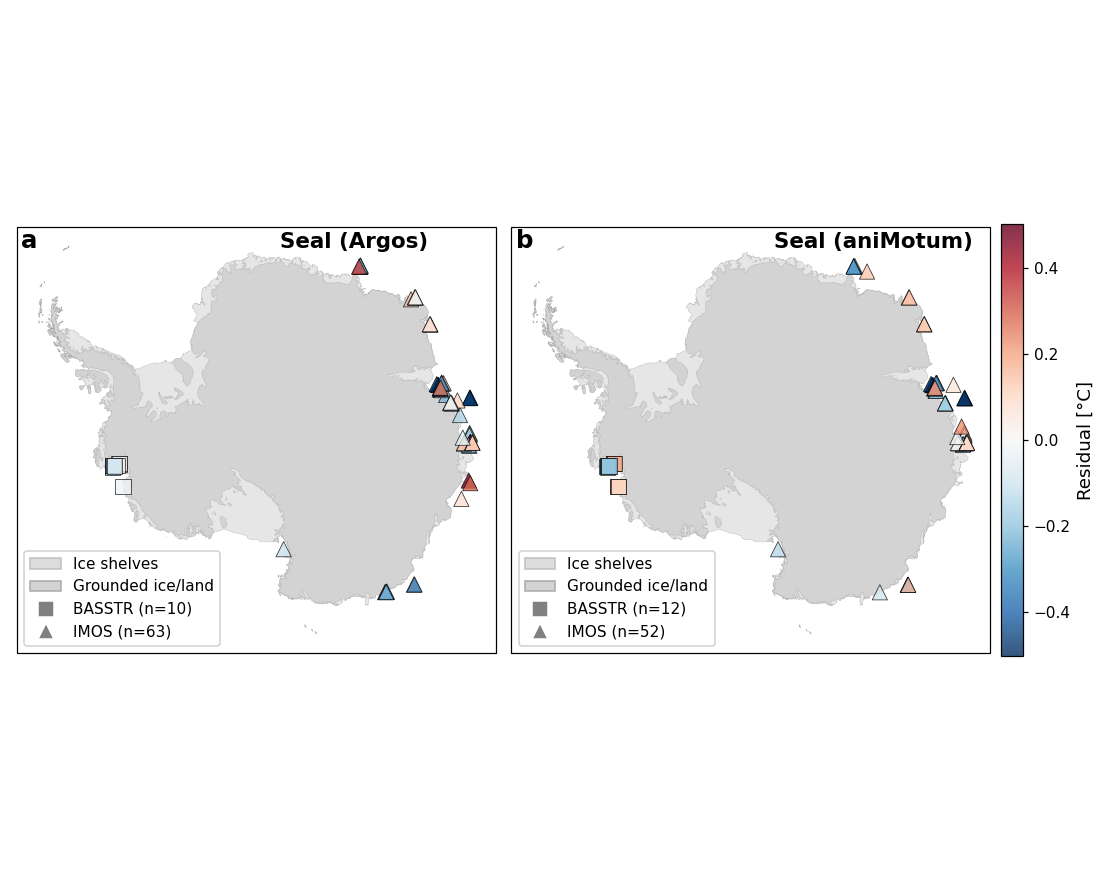

In [78]:
# ========================================================================
# PLOTTING FUNCTIONS
# ========================================================================

def create_dual_validation_maps(datasets_left, datasets_right, color_var, 
                               title_left, title_right, vmin=None, vmax=None, 
                               cmap='RdBu_r', markers={'BASSTR': 's', 'IMOS': '^'},
                               figsize=(8, 6), marker_size=100):
    """Create two side-by-side validation maps with internal titles and subplot labels"""
    
    ps71 = ccrs.Stereographic(central_latitude=-90, central_longitude=0, true_scale_latitude=-71)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize, subplot_kw={'projection': ps71}, dpi=110)
    
    # Determine color range if not provided
    if vmin is None or vmax is None:
        all_values = []
        for datasets in [datasets_left, datasets_right]:
            for name, df, lat_col, lon_col in datasets:
                if color_var in df.columns:
                    all_values.extend(df[color_var].dropna().values)
        if not all_values:
            vmin, vmax = -1, 1
        else:
            vmin = np.percentile(all_values, 5) if vmin is None else vmin
            vmax = np.percentile(all_values, 95) if vmax is None else vmax
    
    def plot_single_map(ax, datasets, title, subplot_label):
        """Plot a single map on given axis"""
        # Antarctica basemap
        grounded_3031.plot(ax=ax, transform=ps71, color="lightgray", edgecolor="darkgray", 
                           linewidth=0.3, zorder=1)
        shelves_3031.plot(ax=ax, transform=ps71, color="0.9", edgecolor="silver", 
                          linewidth=0.25, zorder=2)
        
        scatter_handles = []
        
        # Plot each dataset
        for name, df, lat_col, lon_col in datasets:
            scatter = ax.scatter(
                df[lon_col], 
                df[lat_col],
                c=df[color_var],
                s=marker_size,
                marker=markers.get(name, 'o'),
                alpha=0.8,
                transform=ccrs.PlateCarree(),
                label=f'{name} (n={len(df)})',
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                edgecolors='black',
                linewidths=0.5,
                zorder=4
            )
            scatter_handles.append(scatter)
        
        # ✅ Add subplot label (a, b) in top left
        ax.text(0.01, 0.95, subplot_label, transform=ax.transAxes, fontsize=16, fontweight='bold')
        
        # ✅ Add title in top right
        ax.text(0.55, 0.95, title, transform=ax.transAxes, fontsize=14, fontweight='bold')
        
        # Legend
        legend_handles = [
            Patch(facecolor="gainsboro", edgecolor="silver", label="Ice shelves"),
            Patch(facecolor="lightgray", edgecolor="darkgray", label="Grounded ice/land"),
        ]
        
        # Add data legend
        for name, df, lat_col, lon_col in datasets:
            legend_handles.append(
                plt.Line2D([0], [0], marker=markers.get(name, 'o'), color='w', 
                          markerfacecolor='gray', markersize=10,
                          label=f'{name} (n={len(df)})')
            )
        
        leg = ax.legend(handles=legend_handles, loc="lower left", frameon=True, framealpha=0.9)
        for text in leg.get_texts():
            text.set_fontsize(10)
        
        return scatter_handles
    
    # Plot both maps
    scatter_handles_left = plot_single_map(ax1, datasets_left, title_left, 'a')
    scatter_handles_right = plot_single_map(ax2, datasets_right, title_right, 'b')
    
    # Add shared colorbar
    scatter_handles = scatter_handles_left if scatter_handles_left else scatter_handles_right
    if scatter_handles:
        cbar_ax = fig.add_axes([0.91, 0.255, 0.02, 0.49])
        cbar = fig.colorbar(scatter_handles[0], cax=cbar_ax)
        cbar.set_label('Residual [°C]', fontsize=12)
        cbar.ax.tick_params(labelsize=10)
    
    plt.tight_layout()
    plt.subplots_adjust(right=0.9)

    save_path = '/home/jovyan/Landsat_SST_algorithm/Figures/residual_maps.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# Usage:
datasets_argos = [
    ('BASSTR', df_sealB, 'lat', 'lon'),
    ('IMOS', df_sealI, 'lat', 'lon')
]

datasets_animotum = [
    ('BASSTR', df_seal_aniB, 'lat', 'lon'),
    ('IMOS', df_seal_aniI, 'lat', 'lon')
]

create_dual_validation_maps(
    datasets_left=datasets_argos,
    datasets_right=datasets_animotum,
    color_var='residual',
    title_left='Seal (Argos)',
    title_right='Seal (aniMotum)', 
    vmin=-0.5, vmax=0.5,
    cmap='RdBu_r',
    markers={'BASSTR': 's', 'IMOS': '^'},
    figsize=(10, 8),
    marker_size=100
)

### Time difference between Landsat and in situ - argos and seal_animotum thresholds at 6 hours
Does not meet normality tests so suggest using Levene's test

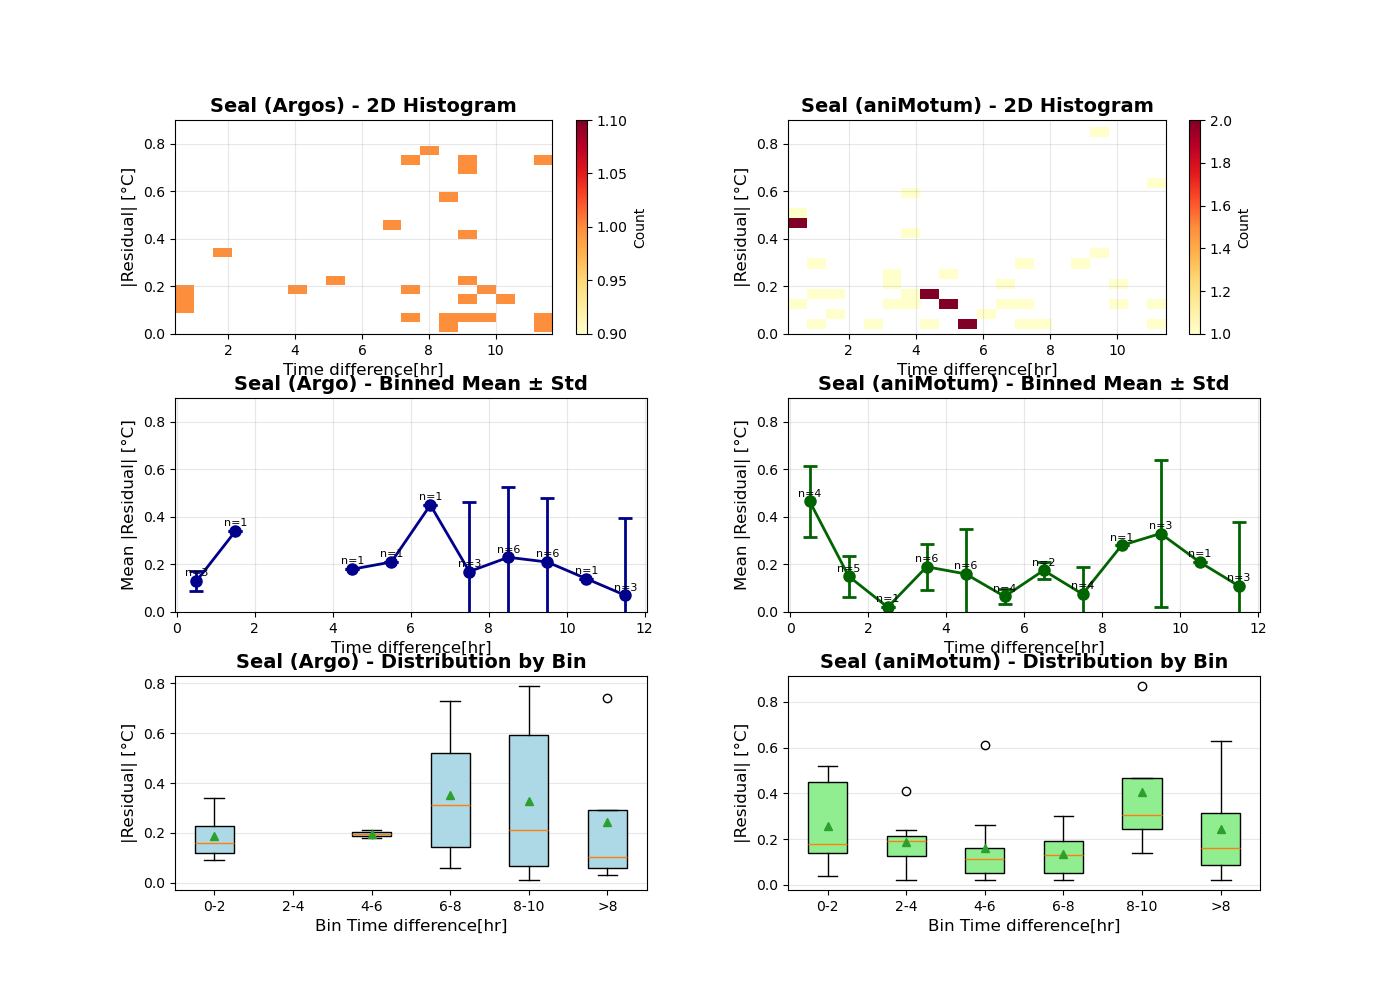


CORRELATION ANALYSIS

Seal (Argo):
  Pearson r = 0.128 (p = 0.5326)
  Spearman ρ = -0.100 (p = 0.6262)

Seal (aniMotum):
  Pearson r = 0.030 (p = 0.8531)
  Spearman ρ = -0.121 (p = 0.4588)

Interpretation:
  - If correlation ≈ 0 and p > 0.05: NO relationship (random)
  - If correlation > 0 and p < 0.05: POSITIVE relationship (larger error → larger residual)


In [101]:
# Test for time difference - seal_argo show thresholds, argo and seal_animotum do not
ind_var = 'time_dif_hours'
dep_var = 'abs_residual'
ind_title = 'Time difference[hr]'
dep_title = '|Residual| [°C]'
check_rel(df_argo, df_seal_ani, ind_var, dep_var, ind_title, dep_title, 'median')

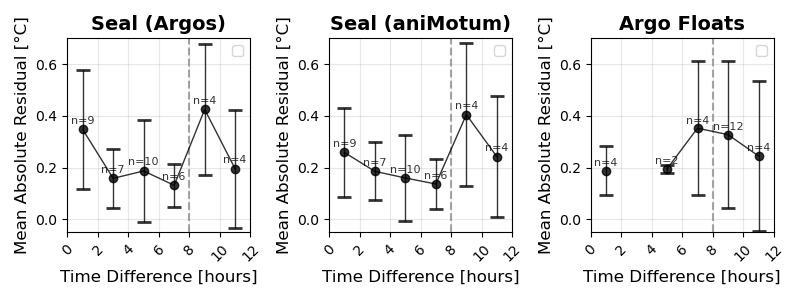


THRESHOLD ANALYSIS STATISTICAL TESTS
Threshold: 8 hours
Testing: Absolute Residual [°C] above vs below threshold
Bins: ['0.0-2.0', '2.0-4.0', '4.0-6.0', '6.0-8.0', '8.0-10.0', '10.0-12.0']

--------------------------------------------------
ARGO ANALYSIS
--------------------------------------------------
Below threshold (n=10): 0.2550 ± 0.2030
Above threshold (n=16): 0.3069 ± 0.2965

1. Spearman Correlation:
   ρ = -0.1002, p = 0.6262

2. Welch's t-test:
   t = -0.5290, p = 0.6017

3. Mann-Whitney U test:
   U = 84, p = 0.8743

--------------------------------------------------
SEAL (ARGOS) ANALYSIS
--------------------------------------------------
Below threshold (n=32): 0.2156 ± 0.1980
Above threshold (n=8): 0.3100 ± 0.2855

1. Spearman Correlation:
   ρ = -0.2204, p = 0.1717

2. Welch's t-test:
   t = -0.8834, p = 0.4007

3. Mann-Whitney U test:
   U = 107, p = 0.4881

--------------------------------------------------
SEAL (ANIMOTUM) ANALYSIS
-------------------------------------

In [102]:
ind_var='time_dif_hours'
dep_var='abs_residual'

results = publication_threshold_analysis(
    df_seal_argo, df_seal_ani, df_argo,
    ind_var='time_dif_hours', 
    dep_var='abs_residual',
    threshold=8,
    ind_title='Time Difference [hours]',
    dep_title='Absolute Residual [°C]',
    ylim = [-0.05,0.7],
    save_path='/home/jovyan/Landsat_SST_algorithm/Figures/time_threshold_analysis.png'
)

In [119]:
thresh = 6
units = 'hrs'


# ============================================================================
# 1. LEVENE'S TEST (Test for Equal Variances)
# ============================================================================

# Split data into two groups for all three datasets
df_seal_argo['time_group'] = df_seal_argo[ind_var] >= thresh
group_low_seal_argo = df_seal_argo[df_seal_argo['time_group'] == False][dep_var].dropna()
group_high_seal_argo = df_seal_argo[df_seal_argo['time_group'] == True][dep_var].dropna()

df_seal_ani['time_group'] = df_seal_ani[ind_var] >= thresh
group_low_seal_ani = df_seal_ani[df_seal_ani['time_group'] == False][dep_var].dropna()
group_high_seal_ani = df_seal_ani[df_seal_ani['time_group'] == True][dep_var].dropna()

df_argo['time_group'] = df_argo[ind_var] >= thresh
group_low_argo = df_argo[df_argo['time_group'] == False][dep_var].dropna()
group_high_argo = df_argo[df_argo['time_group'] == True][dep_var].dropna()

# Levene's test for all three
stat_seal_argo, p_levene_seal_argo = levene(group_low_seal_argo, group_high_seal_argo)
stat_seal_ani, p_levene_seal_ani = levene(group_low_seal_ani, group_high_seal_ani)
stat_argo, p_levene_argo = levene(group_low_argo, group_high_argo)

print("\n" + "="*80)
print(f"VARIANCE COMPARISON: <{thresh}hrs vs ≥{thresh}hrs (LEVENE'S TEST)")
print("="*80)

print(f"\nSeal (Argo):")
print(f"  Std <{thresh}{units}:  {group_low_seal_argo.std():.4f} (n={len(group_low_seal_argo)})")
print(f"  Std ≥{thresh}{units}:  {group_high_seal_argo.std():.4f} (n={len(group_high_seal_argo)})")
print(f"  Levene's test: W = {stat_seal_argo:.3f}, p = {p_levene_seal_argo:.4f}")
if p_levene_seal_argo < 0.05:
    print(f"  → Variances are SIGNIFICANTLY different (p < 0.05) ***")
else:
    print(f"  → No significant difference in variance (p ≥ 0.05)")

print(f"\nSeal (aniMotum):")
print(f"  Std <{thresh}{units}:  {group_low_seal_ani.std():.4f} (n={len(group_low_seal_ani)})")
print(f"  Std ≥{thresh}{units}:  {group_high_seal_ani.std():.4f} (n={len(group_high_seal_ani)})")
print(f"  Levene's test: W = {stat_seal_ani:.3f}, p = {p_levene_seal_ani:.4f}")
if p_levene_seal_ani < 0.05:
    print(f"  → Variances are SIGNIFICANTLY different (p < 0.05) ***")
else:
    print(f"  → No significant difference in variance (p ≥ 0.05)")

print(f"\nArgo:")
print(f"  Std <{thresh}{units}:  {group_low_argo.std():.4f} (n={len(group_low_argo)})")
print(f"  Std ≥{thresh}{units}:  {group_high_argo.std():.4f} (n={len(group_high_argo)})")
print(f"  Levene's test: W = {stat_argo:.3f}, p = {p_levene_argo:.4f}")
if p_levene_argo < 0.05:
    print(f"  → Variances are SIGNIFICANTLY different (p < 0.05) ***")
else:
    print(f"  → No significant difference in variance (p ≥ 0.05)")

# ============================================================================
# 4. BROWN-FORSYTHE TEST (most robust)
# ============================================================================

stat_seal_argo_bf, p_bf_seal_argo = levene(group_low_seal_argo, group_high_seal_argo, center='median')
stat_seal_ani_bf, p_bf_seal_ani = levene(group_low_seal_ani, group_high_seal_ani, center='median')
stat_argo_bf, p_bf_argo = levene(group_low_argo, group_high_argo, center='median')

print("\n" + "="*80)
print("BROWN-FORSYTHE TEST (robust to outliers)")
print("="*80)

print(f"\nSeal (Argo): W = {stat_seal_argo_bf:.3f}, p = {p_bf_seal_argo:.4f}")
if p_bf_seal_argo < 0.05:
    print(f"  → Variances are SIGNIFICANTLY different (p < 0.05) ***")
else:
    print(f"  → No significant difference in variance (p ≥ 0.05)")

print(f"\nSeal (aniMotum): W = {stat_seal_ani_bf:.3f}, p = {p_bf_seal_ani:.4f}")
if p_bf_seal_ani < 0.05:
    print(f"  → Variances are SIGNIFICANTLY different (p < 0.05) ***")
else:
    print(f"  → No significant difference in variance (p ≥ 0.05)")

print(f"\nArgo: W = {stat_argo_bf:.3f}, p = {p_bf_argo:.4f}")
if p_bf_argo < 0.05:
    print(f"  → Variances are SIGNIFICANTLY different (p < 0.05) ***")
else:
    print(f"  → No significant difference in variance (p ≥ 0.05)")

# ============================================================================
# 5. THRESHOLD ANALYSIS - Finding variance breakpoint
# ============================================================================

thresholds = [2, 4, 6, 7, 8, 10, 12]

print("\n" + "="*80)
print("THRESHOLD ANALYSIS - Finding variance breakpoint")
print("="*80)

for dataset_name, df in [('Seal (Argo)', df_seal_argo), 
                         ('Seal (aniMotum)', df_seal_ani),
                         ('Argo', df_argo)]:
    print(f"\n{dataset_name}:")
    print("-" * 40)
    
    for thresh in thresholds:
        low = df[df[ind_var] < thresh][dep_var].dropna()
        high = df[df[ind_var] >= thresh][dep_var].dropna()
        
        if len(low) > 5 and len(high) > 5:  # Need enough samples
            stat, p = levene(low, high)
            var_ratio = high.var() / low.var() if low.var() > 0 else np.nan
            
            print(f"  Threshold = {thresh}hrs:")
            print(f"    n<{thresh}: {len(low):3d}, std = {low.std():.4f}")
            print(f"    n≥{thresh}: {len(high):3d}, std = {high.std():.4f}")
            print(f"    Variance ratio: {var_ratio:.2f}x")
            print(f"    Levene p = {p:.4f} {'***' if p < 0.05 else ''}")

print("\n" + "="*80)

KeyError: 'loc_err[km]'

In [ ]:
# Test normality of each group
print("\n" + "="*60)
print("NORMALITY TESTS (Shapiro-Wilk)")
print("="*60)

# Seal Argo
stat_low_sa, p_low_sa = shapiro(group_low_seal_argo)
stat_high_sa, p_high_sa = shapiro(group_high_seal_argo)

print(f"\nSeal (Argo):")
print(f"  <8hrs: W = {stat_low_sa:.4f}, p = {p_low_sa:.4f} {'(NOT normal)' if p_low_sa < 0.05 else '(normal)'}")
print(f"  ≥8hrs: W = {stat_high_sa:.4f}, p = {p_high_sa:.4f} {'(NOT normal)' if p_high_sa < 0.05 else '(normal)'}")

# Seal animotum
stat_low_sani, p_low_sani = shapiro(group_low_seal_ani)
stat_high_sani, p_high_sani = shapiro(group_high_seal_ani)

print(f"\nSeal (aniMotum):")
print(f"  <8hrs: W = {stat_low_sani:.4f}, p = {p_low_sani:.4f} {'(NOT normal)' if p_low_sani < 0.05 else '(normal)'}")
print(f"  ≥8hrs: W = {stat_high_sani:.4f}, p = {p_high_sani:.4f} {'(NOT normal)' if p_high_sani < 0.05 else '(normal)'}")

# Argo
stat_low_a, p_low_a = shapiro(group_low_argo)
stat_high_a, p_high_a = shapiro(group_high_argo)

print(f"\nArgo:")
print(f"  <8hrs: W = {stat_low_a:.4f}, p = {p_low_a:.4f} {'(NOT normal)' if p_low_a < 0.05 else '(normal)'}")
print(f"  ≥8hrs: W = {stat_high_a:.4f}, p = {p_high_a:.4f} {'(NOT normal)' if p_high_a < 0.05 else '(normal)'}")

print("\nInterpretation:")
print("  - If p < 0.05: Data is NOT normally distributed → Use Levene or Brown-Forsythe")
print("  - If p ≥ 0.05: Data is approximately normal → Bartlett is valid")

### Testing performance of seal tag Argos vs aniMotum

### Testing location error for seal tag data - 3km to 4km seems
Correlation analysis shows that Argo has a larger residuals with larger location errors 

Does not meet normality tests so suggest using Levene's test

At 3 km, Argo and Seal_argo are close to 95% confidence as signficant

In [120]:
thresh = 6
units = 'hrs'


# ============================================================================
# 1. LEVENE'S TEST (Test for Equal Variances)
# ============================================================================

dataset = df_sealB
group_sealB = dataset[dep_var].dropna()
dataset = df_sealI
group_sealI = dataset[dep_var].dropna()

dataset = df_seal_aniB
group_seal_aniB = dataset[dep_var].dropna()
dataset = df_seal_aniI
group_seal_aniI = dataset[dep_var].dropna()

# Levene's test for all three
stat_seal_argo, p_levene_seal_argo = levene(group_sealB, group_sealI)
stat_seal_ani, p_levene_seal_ani = levene(group_seal_aniB, group_seal_aniI)

print("\n" + "="*80)
print(f"VARIANCE COMPARISON: <{thresh}hrs vs ≥{thresh}hrs (LEVENE'S TEST)")
print("="*80)

print(f"\nSeal (Argos):")
print(f"  Std <{thresh}{units}:  {group_sealB.std():.4f} (n={len(group_sealB)})")
print(f"  Std ≥{thresh}{units}:  {group_sealI.std():.4f} (n={len(group_sealI)})")
print(f"  Levene's test: W = {stat_seal_argo:.3f}, p = {p_levene_seal_argo:.4f}")
if p_levene_seal_argo < 0.05:
    print(f"  → Variances are SIGNIFICANTLY different (p < 0.05) ***")
else:
    print(f"  → No significant difference in variance (p ≥ 0.05)")

print(f"\nSeal (aniMotum):")
print(f"  Std <{thresh}{units}:  {group_seal_aniB.std():.4f} (n={len(group_seal_aniB)})")
print(f"  Std ≥{thresh}{units}:  {group_seal_aniI.std():.4f} (n={len(group_seal_aniI)})")
print(f"  Levene's test: W = {stat_seal_ani:.3f}, p = {p_levene_seal_ani:.4f}")
if p_levene_seal_ani < 0.05:
    print(f"  → Variances are SIGNIFICANTLY different (p < 0.05) ***")
else:
    print(f"  → No significant difference in variance (p ≥ 0.05)")

# # ============================================================================
# # 5. THRESHOLD ANALYSIS - Finding variance breakpoint
# # ============================================================================

# thresholds = [2, 4, 6, 7, 8, 10, 12]

# print("\n" + "="*80)
# print("THRESHOLD ANALYSIS - Finding variance breakpoint")
# print("="*80)

# for dataset_name, df in [('Seal (Argos)', df_seal_argo), 
#                          ('Seal (aniMotum)', df_seal_ani),
#                          ('Argo', df_argo)]:
#     print(f"\n{dataset_name}:")
#     print("-" * 40)
    
#     for thresh in thresholds:
#         low = df[df[ind_var] < thresh][dep_var].dropna()
#         high = df[df[ind_var] >= thresh][dep_var].dropna()
        
#         if len(low) > 5 and len(high) > 5:  # Need enough samples
#             stat, p = levene(low, high)
#             var_ratio = high.var() / low.var() if low.var() > 0 else np.nan
            
#             print(f"  Threshold = {thresh}hrs:")
#             print(f"    n<{thresh}: {len(low):3d}, std = {low.std():.4f}")
#             print(f"    n≥{thresh}: {len(high):3d}, std = {high.std():.4f}")
#             print(f"    Variance ratio: {var_ratio:.2f}x")
#             print(f"    Levene p = {p:.4f} {'***' if p < 0.05 else ''}")

# print("\n" + "="*80)


VARIANCE COMPARISON: <6hrs vs ≥6hrs (LEVENE'S TEST)

Seal (Argos):
  Std <6hrs:  0.1149 (n=10)
  Std ≥6hrs:  0.1964 (n=63)
  Levene's test: W = 2.547, p = 0.1149
  → No significant difference in variance (p ≥ 0.05)

Seal (aniMotum):
  Std <6hrs:  0.0918 (n=12)
  Std ≥6hrs:  0.1874 (n=52)
  Levene's test: W = 1.626, p = 0.2070
  → No significant difference in variance (p ≥ 0.05)


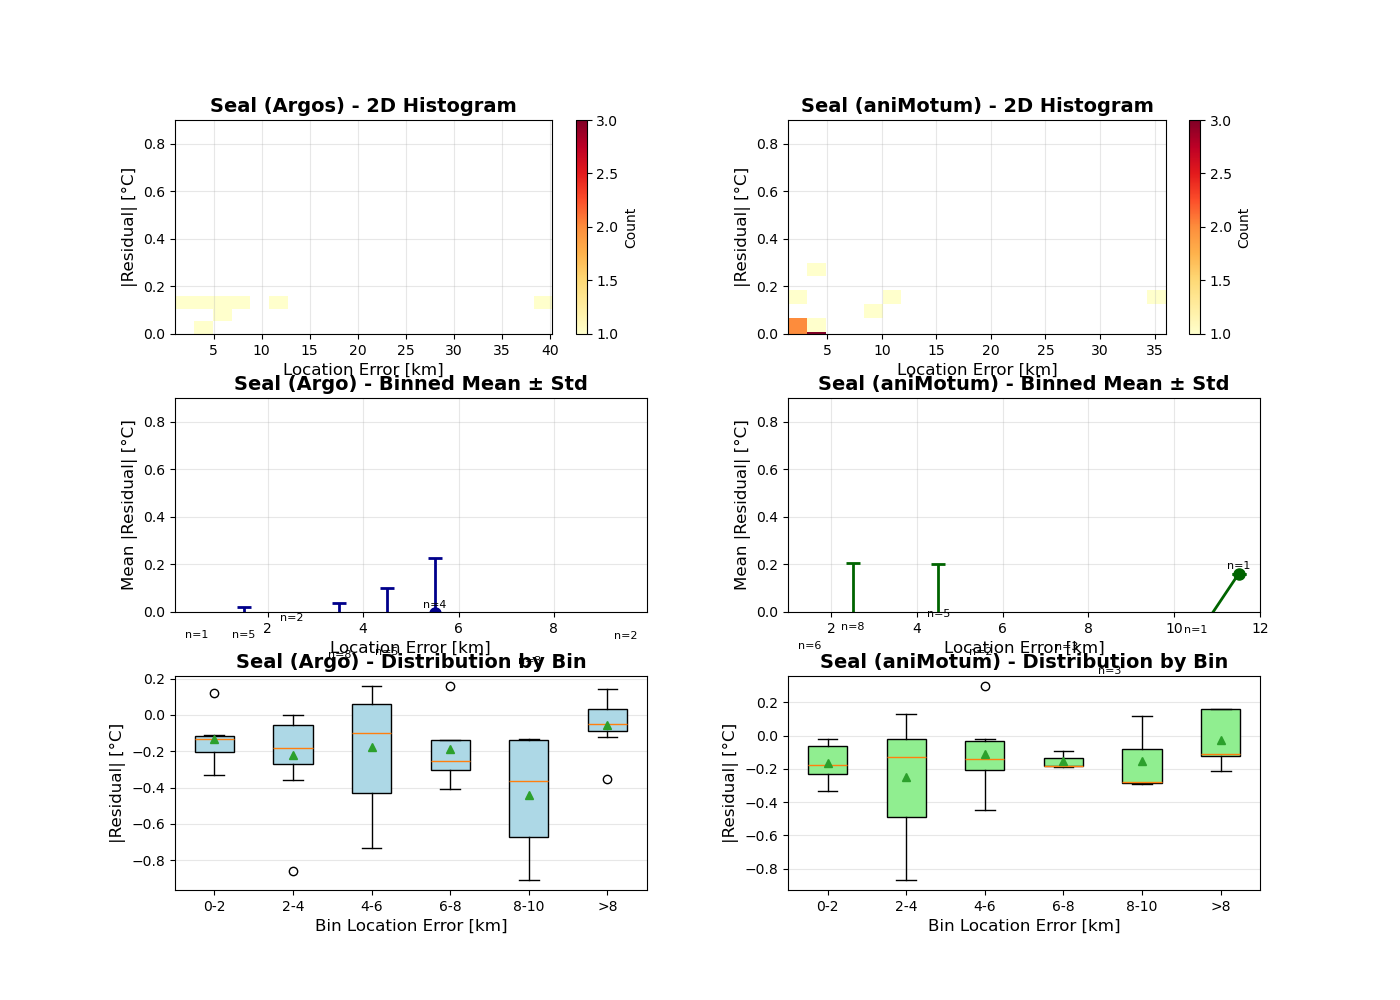


CORRELATION ANALYSIS

Seal (Argo):
  Pearson r = 0.186 (p = 0.2493)
  Spearman ρ = 0.099 (p = 0.5434)

Seal (aniMotum):
  Pearson r = 0.204 (p = 0.2073)
  Spearman ρ = 0.089 (p = 0.5868)

Interpretation:
  - If correlation ≈ 0 and p > 0.05: NO relationship (random)
  - If correlation > 0 and p < 0.05: POSITIVE relationship (larger error → larger residual)


In [121]:
ind_var = 'loc_err[km]'
dep_var = 'residual'
ind_title = 'Location Error [km]'
dep_title = '|Residual| [°C]'
check_rel(df_seal_argo, df_seal_ani, ind_var, dep_var, ind_title, dep_title,'median')

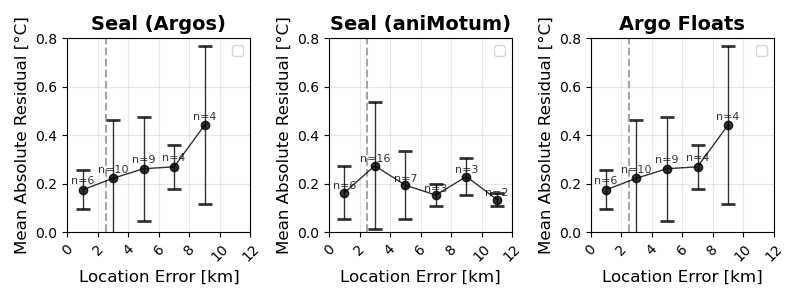


THRESHOLD ANALYSIS STATISTICAL TESTS
Threshold: 2.5 err[km]
Testing: Absolute Residual [°C] above vs below threshold
Bins: ['0.0-2.0', '2.0-4.0', '4.0-6.0', '6.0-8.0', '8.0-10.0', '10.0-12.0']

--------------------------------------------------
ARGO ANALYSIS
--------------------------------------------------
Below threshold (n=8): 0.1462 ± 0.0913
Above threshold (n=32): 0.2566 ± 0.2346

1. Spearman Correlation:
   ρ = -0.0069, p = 0.9661

2. Welch's t-test:
   t = -2.0987, p = 0.0442

3. Mann-Whitney U test:
   U = 88, p = 0.1816

--------------------------------------------------
SEAL (ARGOS) ANALYSIS
--------------------------------------------------
Below threshold (n=8): 0.1462 ± 0.0913
Above threshold (n=32): 0.2566 ± 0.2346

1. Spearman Correlation:
   ρ = -0.0069, p = 0.9661

2. Welch's t-test:
   t = -2.0987, p = 0.0442

3. Mann-Whitney U test:
   U = 88, p = 0.1816

--------------------------------------------------
SEAL (ANIMOTUM) ANALYSIS
-----------------------------------

In [122]:
results = publication_threshold_analysis(
    df_seal_argo, df_seal_ani, df_seal_argo,
    ind_var='loc_err[km]', 
    dep_var='abs_residual',
    threshold=2.5,
    ind_title='Location Error [km]',
    dep_title='Absolute Residual [°C]',
    ylim = [0,0.8],
    save_path='/home/jovyan/Landsat_SST_algorithm/Figures/loc_threshold_analysis.png'
)

In [123]:
thresh = 2.5
units = 'kms'
# ============================================================================
# 1. LEVENE'S TEST (Test for Equal Variances)
# ============================================================================

# Split data into two groups for all three datasets
df_seal_argo['loc_group'] = df_seal_argo[ind_var] >= thresh
group_low_seal_argo = df_seal_argo[df_seal_argo['loc_group'] == False][dep_var].dropna()
group_high_seal_argo = df_seal_argo[df_seal_argo['loc_group'] == True][dep_var].dropna()

df_seal_ani['loc_group'] = df_seal_ani[ind_var] >= thresh
group_low_seal_ani = df_seal_ani[df_seal_ani['loc_group'] == False][dep_var].dropna()
group_high_seal_ani = df_seal_ani[df_seal_ani['loc_group'] == True][dep_var].dropna()

# Levene's test for all three
stat_seal_argo, p_levene_seal_argo = levene(group_low_seal_argo, group_high_seal_argo)
stat_seal_ani, p_levene_seal_ani = levene(group_low_seal_ani, group_high_seal_ani)
stat_argo, p_levene_argo = levene(group_low_argo, group_high_argo)

print("\n" + "="*80)
print(f"VARIANCE COMPARISON: <{thresh}{units} vs ≥{thresh}{units} (LEVENE'S TEST)")
print("="*80)

print(f"\nSeal (Argos):")
print(f"  Std <{thresh}{units}:  {group_low_seal_argo.std():.4f} (n={len(group_low_seal_argo)})")
print(f"  Std ≥{thresh}{units}:  {group_high_seal_argo.std():.4f} (n={len(group_high_seal_argo)})")
print(f"  Levene's test: W = {stat_seal_argo:.3f}, p = {p_levene_seal_argo:.4f}")
if p_levene_seal_argo < 0.05:
    print(f"  → Variances are SIGNIFICANTLY different (p < 0.05) ***")
else:
    print(f"  → No significant difference in variance (p ≥ 0.05)")

print(f"\nSeal (aniMotum):")
print(f"  Std <{thresh}{units}:  {group_low_seal_ani.std():.4f} (n={len(group_low_seal_ani)})")
print(f"  Std ≥{thresh}{units}:  {group_high_seal_ani.std():.4f} (n={len(group_high_seal_ani)})")
print(f"  Levene's test: W = {stat_seal_ani:.3f}, p = {p_levene_seal_ani:.4f}")
if p_levene_seal_ani < 0.05:
    print(f"  → Variances are SIGNIFICANTLY different (p < 0.05) ***")
else:
    print(f"  → No significant difference in variance (p ≥ 0.05)")

print(f"\nArgo:")
print(f"  Std <{thresh}{units}:  {group_low_argo.std():.4f} (n={len(group_low_argo)})")
print(f"  Std ≥{thresh}{units}:  {group_high_argo.std():.4f} (n={len(group_high_argo)})")
print(f"  Levene's test: W = {stat_argo:.3f}, p = {p_levene_argo:.4f}")
if p_levene_argo < 0.05:
    print(f"  → Variances are SIGNIFICANTLY different (p < 0.05) ***")
else:
    print(f"  → No significant difference in variance (p ≥ 0.05)")

# ============================================================================
# 2. BARTLETT'S TEST (assumes normality)
# ============================================================================

stat_seal_argo_b, p_bartlett_seal_argo = bartlett(group_low_seal_argo, group_high_seal_argo)
stat_seal_ani_b, p_bartlett_seal_ani = bartlett(group_low_seal_ani, group_high_seal_ani)
stat_argo_b, p_bartlett_argo = bartlett(group_low_argo, group_high_argo)

print("\n" + "="*80)
print("BARTLETT'S TEST")
print("="*80)

print(f"\nSeal (Argos): χ² = {stat_seal_argo_b:.3f}, p = {p_bartlett_seal_argo:.4f}")
if p_bartlett_seal_argo < 0.05:
    print(f"  → Variances are SIGNIFICANTLY different (p < 0.05) ***")
else:
    print(f"  → No significant difference in variance (p ≥ 0.05)")

print(f"\nSeal (aniMotum): χ² = {stat_seal_ani_b:.3f}, p = {p_bartlett_seal_ani:.4f}")
if p_bartlett_seal_ani < 0.05:
    print(f"  → Variances are SIGNIFICANTLY different (p < 0.05) ***")
else:
    print(f"  → No significant difference in variance (p ≥ 0.05)")

print(f"\nArgo: χ² = {stat_argo_b:.3f}, p = {p_bartlett_argo:.4f}")
if p_bartlett_argo < 0.05:
    print(f"  → Variances are SIGNIFICANTLY different (p < 0.05) ***")
else:
    print(f"  → No significant difference in variance (p ≥ 0.05)")

# ============================================================================
# 3. F-TEST FOR VARIANCE RATIO
# ============================================================================

# Seal Argos
var_low_seal_argo = group_low_seal_argo.var()
var_high_seal_argo = group_high_seal_argo.var()
F_seal_argo = var_high_seal_argo / var_low_seal_argo
df1_seal_argo = len(group_high_seal_argo) - 1
df2_seal_argo = len(group_low_seal_argo) - 1
p_ftest_seal_argo = 2 * min(f.cdf(F_seal_argo, df1_seal_argo, df2_seal_argo), 
                            1 - f.cdf(F_seal_argo, df1_seal_argo, df2_seal_argo))

# Seal animotum
var_low_seal_ani = group_low_seal_ani.var()
var_high_seal_ani = group_high_seal_ani.var()
F_seal_ani = var_high_seal_ani / var_low_seal_ani
df1_seal_ani = len(group_high_seal_ani) - 1
df2_seal_ani = len(group_low_seal_ani) - 1
p_ftest_seal_ani = 2 * min(f.cdf(F_seal_ani, df1_seal_ani, df2_seal_ani), 
                           1 - f.cdf(F_seal_ani, df1_seal_ani, df2_seal_ani))

# Argo
var_low_argo = group_low_argo.var()
var_high_argo = group_high_argo.var()
F_argo = var_high_argo / var_low_argo
df1_argo = len(group_high_argo) - 1
df2_argo = len(group_low_argo) - 1
p_ftest_argo = 2 * min(f.cdf(F_argo, df1_argo, df2_argo), 
                       1 - f.cdf(F_argo, df1_argo, df2_argo))

print("\n" + "="*80)
print("F-TEST FOR VARIANCE RATIO")
print("="*80)

print(f"\nSeal (Argos):")
print(f"  F = {F_seal_argo:.3f}, p = {p_ftest_seal_argo:.4f}")
print(f"  Variance increased by {F_seal_argo:.2f}x at ≥{thresh}{units}")
if p_ftest_seal_argo < 0.05:
    print(f"  → SIGNIFICANT increase in variance (p < 0.05) ***")
else:
    print(f"  → No significant increase (p ≥ 0.05)")

print(f"\nSeal (aniMotum):")
print(f"  F = {F_seal_ani:.3f}, p = {p_ftest_seal_ani:.4f}")
print(f"  Variance increased by {F_seal_ani:.2f}x at ≥{thresh}{units}")
if p_ftest_seal_ani < 0.05:
    print(f"  → SIGNIFICANT increase in variance (p < 0.05) ***")
else:
    print(f"  → No significant increase (p ≥ 0.05)")

print(f"\nArgo:")
print(f"  F = {F_argo:.3f}, p = {p_ftest_argo:.4f}")
print(f"  Variance increased by {F_argo:.2f}x at ≥{thresh}hrs")
if p_ftest_argo < 0.05:
    print(f"  → SIGNIFICANT increase in variance (p < 0.05) ***")
else:
    print(f"  → No significant increase (p ≥ 0.05)")

# ============================================================================
# 4. BROWN-FORSYTHE TEST (most robust)
# ============================================================================

stat_seal_argo_bf, p_bf_seal_argo = levene(group_low_seal_argo, group_high_seal_argo, center='median')
stat_seal_ani_bf, p_bf_seal_ani = levene(group_low_seal_ani, group_high_seal_ani, center='median')
stat_argo_bf, p_bf_argo = levene(group_low_argo, group_high_argo, center='median')

print("\n" + "="*80)
print("BROWN-FORSYTHE TEST (robust to outliers)")
print("="*80)

print(f"\nSeal (Argos): W = {stat_seal_argo_bf:.3f}, p = {p_bf_seal_argo:.4f}")
if p_bf_seal_argo < 0.05:
    print(f"  → Variances are SIGNIFICANTLY different (p < 0.05) ***")
else:
    print(f"  → No significant difference in variance (p ≥ 0.05)")

print(f"\nSeal (aniMotum): W = {stat_seal_ani_bf:.3f}, p = {p_bf_seal_ani:.4f}")
if p_bf_seal_ani < 0.05:
    print(f"  → Variances are SIGNIFICANTLY different (p < 0.05) ***")
else:
    print(f"  → No significant difference in variance (p ≥ 0.05)")

print(f"\nArgo: W = {stat_argo_bf:.3f}, p = {p_bf_argo:.4f}")
if p_bf_argo < 0.05:
    print(f"  → Variances are SIGNIFICANTLY different (p < 0.05) ***")
else:
    print(f"  → No significant difference in variance (p ≥ 0.05)")

# ============================================================================
# 5. THRESHOLD ANALYSIS - Finding variance breakpoint
# ============================================================================

thresholds = [1,2,2.5,3, 3.5,4,5, 6,7, 8,9, 10, 12]

print("\n" + "="*80)
print("THRESHOLD ANALYSIS - Finding variance breakpoint")
print("="*80)

for dataset_name, df in [('Seal (Argos)', df_seal_argo), 
                         ('Seal (aniMotum)', df_seal_ani),
                         ]:
    print(f"\n{dataset_name}:")
    print("-" * 40)
    
    for thresh in thresholds:
        low = df[df[ind_var] < thresh][dep_var].dropna()
        high = df[df[ind_var] >= thresh][dep_var].dropna()
        
        if len(low) > 5 and len(high) > 5:  # Need enough samples
            stat, p = levene(low, high)
            var_ratio = high.var() / low.var() if low.var() > 0 else np.nan
            
            print(f"  Threshold = {thresh}kms:")
            print(f"    n<{thresh}: {len(low):3d}, std = {low.std():.4f}")
            print(f"    n≥{thresh}: {len(high):3d}, std = {high.std():.4f}")
            print(f"    Variance ratio: {var_ratio:.2f}x")
            print(f"    Levene p = {p:.4f} {'***' if p < 0.05 else ''}")

print("\n" + "="*80)


VARIANCE COMPARISON: <2.5kms vs ≥2.5kms (LEVENE'S TEST)

Seal (Argos):
  Std <2.5kms:  0.1317 (n=8)
  Std ≥2.5kms:  0.2810 (n=32)
  Levene's test: W = 3.013, p = 0.0907
  → No significant difference in variance (p ≥ 0.05)

Seal (aniMotum):
  Std <2.5kms:  0.1355 (n=10)
  Std ≥2.5kms:  0.2595 (n=30)
  Levene's test: W = 2.072, p = 0.1582
  → No significant difference in variance (p ≥ 0.05)

Argo:
  Std <2.5kms:  0.0856 (n=6)
  Std ≥2.5kms:  0.2899 (n=20)
  Levene's test: W = 4.320, p = 0.0485
  → Variances are SIGNIFICANTLY different (p < 0.05) ***

BARTLETT'S TEST

Seal (Argos): χ² = 4.490, p = 0.0341
  → Variances are SIGNIFICANTLY different (p < 0.05) ***

Seal (aniMotum): χ² = 4.337, p = 0.0373
  → Variances are SIGNIFICANTLY different (p < 0.05) ***

Argo: χ² = 6.671, p = 0.0098
  → Variances are SIGNIFICANTLY different (p < 0.05) ***

F-TEST FOR VARIANCE RATIO

Seal (Argos):
  F = 4.553, p = 0.0441
  Variance increased by 4.55x at ≥2.5kms
  → SIGNIFICANT increase in variance (p <

### Testing temperature

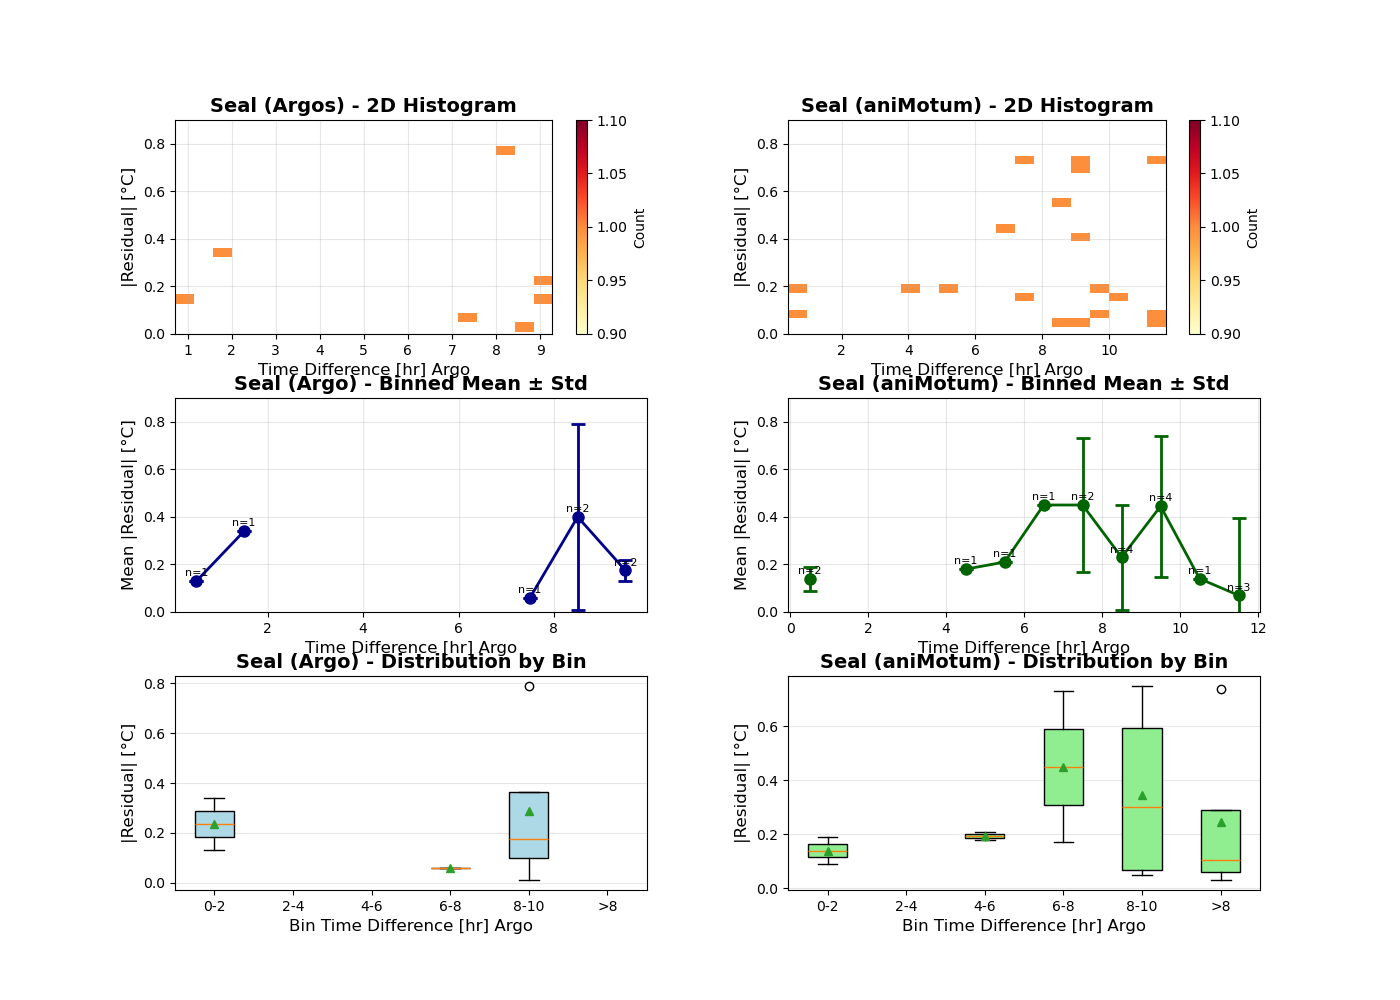


CORRELATION ANALYSIS

Seal (Argo):
  Pearson r = 0.014 (p = 0.9760)
  Spearman ρ = -0.108 (p = 0.8175)

Seal (aniMotum):
  Pearson r = 0.145 (p = 0.5530)
  Spearman ρ = -0.149 (p = 0.5421)

Interpretation:
  - If correlation ≈ 0 and p > 0.05: NO relationship (random)
  - If correlation > 0 and p < 0.05: POSITIVE relationship (larger error → larger residual)


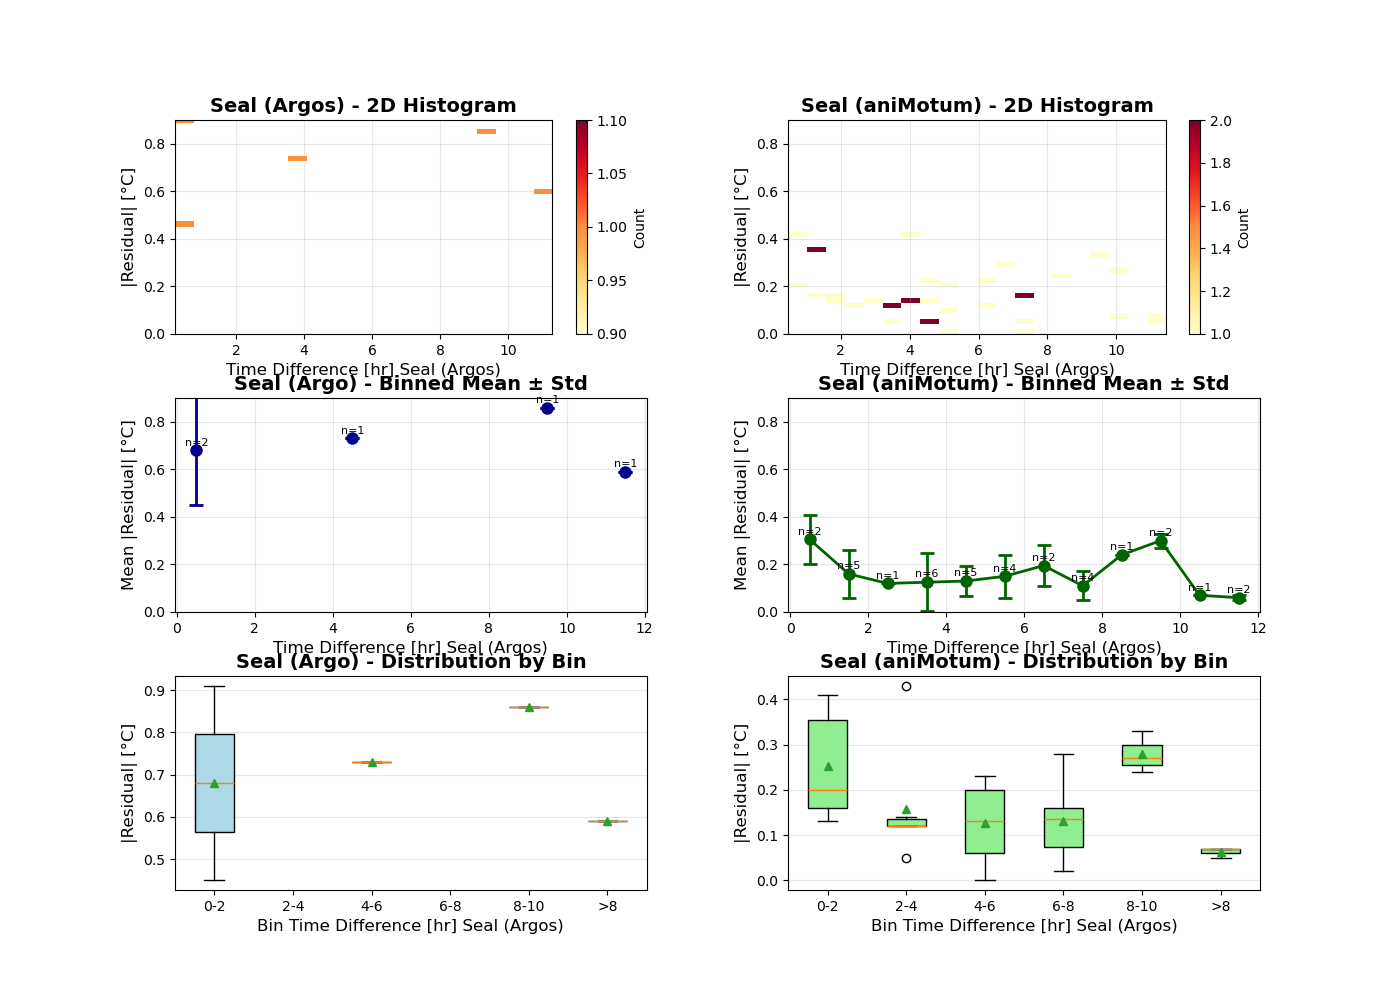


CORRELATION ANALYSIS

Seal (Argo):
  Pearson r = 0.067 (p = 0.9151)
  Spearman ρ = 0.100 (p = 0.8729)

Seal (aniMotum):
  Pearson r = -0.260 (p = 0.1318)
  Spearman ρ = -0.257 (p = 0.1369)

Interpretation:
  - If correlation ≈ 0 and p > 0.05: NO relationship (random)
  - If correlation > 0 and p < 0.05: POSITIVE relationship (larger error → larger residual)


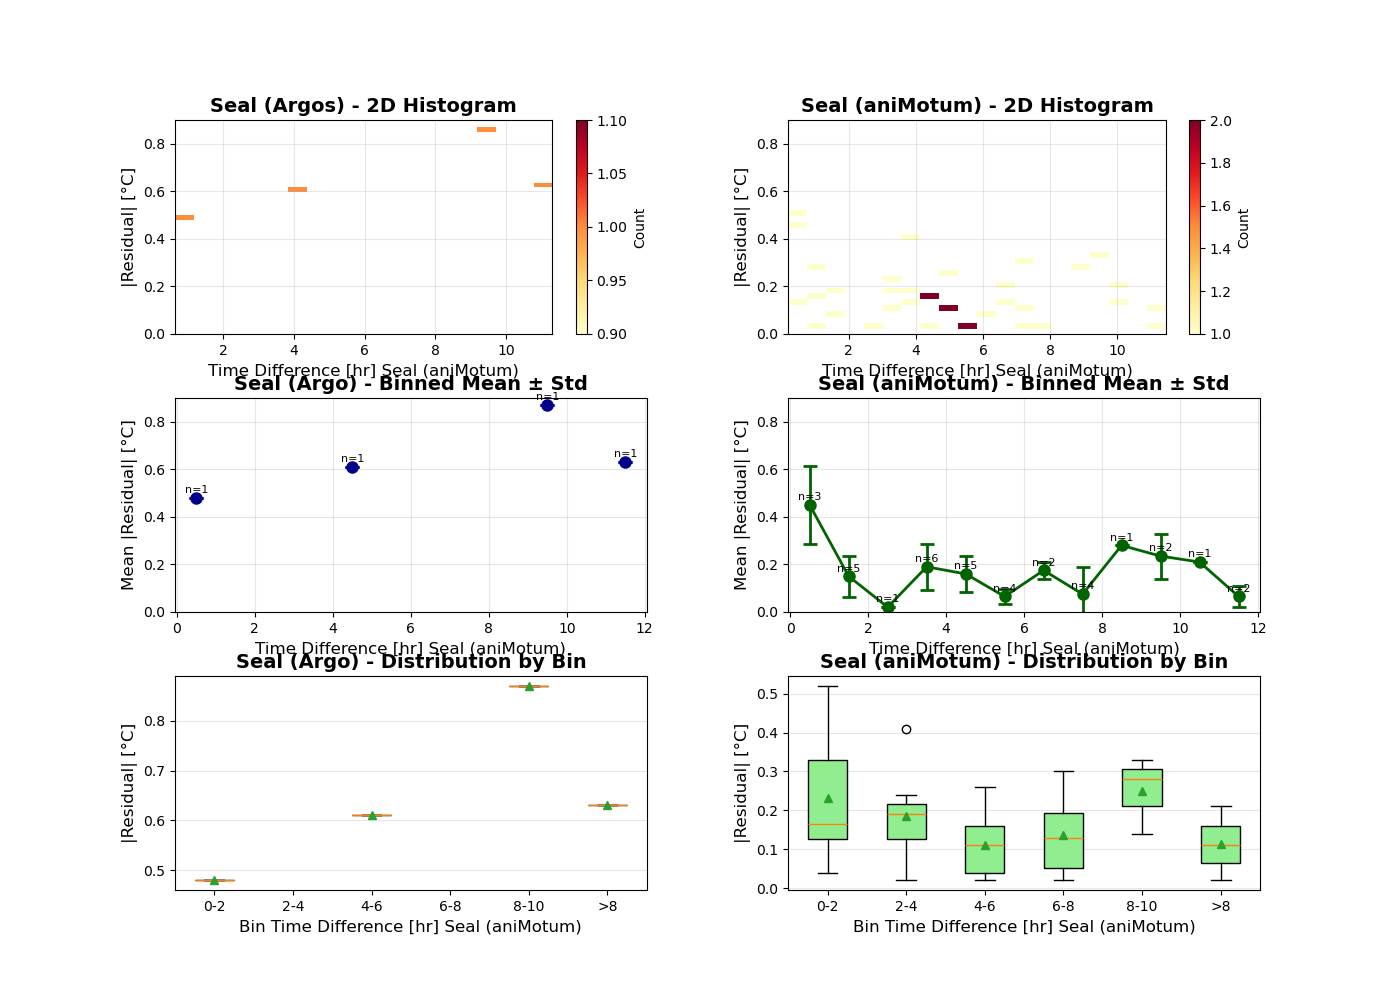


CORRELATION ANALYSIS

Seal (Argo):
  Pearson r = 0.683 (p = 0.3172)
  Spearman ρ = 0.800 (p = 0.2000)

Seal (aniMotum):
  Pearson r = -0.236 (p = 0.1660)
  Spearman ρ = -0.211 (p = 0.2162)

Interpretation:
  - If correlation ≈ 0 and p > 0.05: NO relationship (random)
  - If correlation > 0 and p < 0.05: POSITIVE relationship (larger error → larger residual)


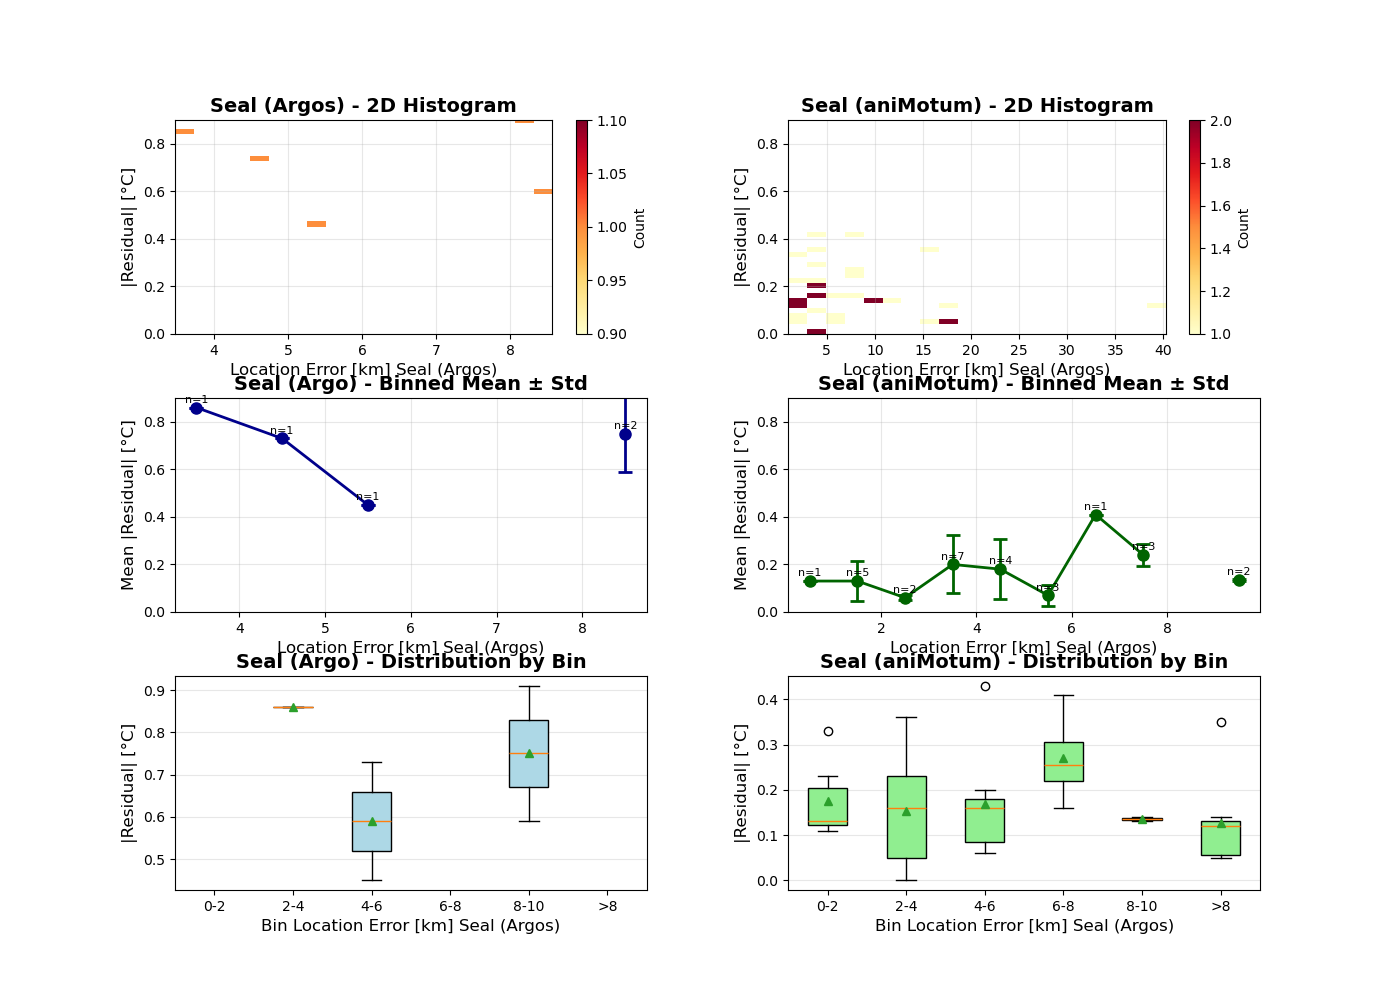


CORRELATION ANALYSIS

Seal (Argo):
  Pearson r = -0.054 (p = 0.9313)
  Spearman ρ = -0.200 (p = 0.7471)

Seal (aniMotum):
  Pearson r = -0.133 (p = 0.4460)
  Spearman ρ = -0.051 (p = 0.7717)

Interpretation:
  - If correlation ≈ 0 and p > 0.05: NO relationship (random)
  - If correlation > 0 and p < 0.05: POSITIVE relationship (larger error → larger residual)


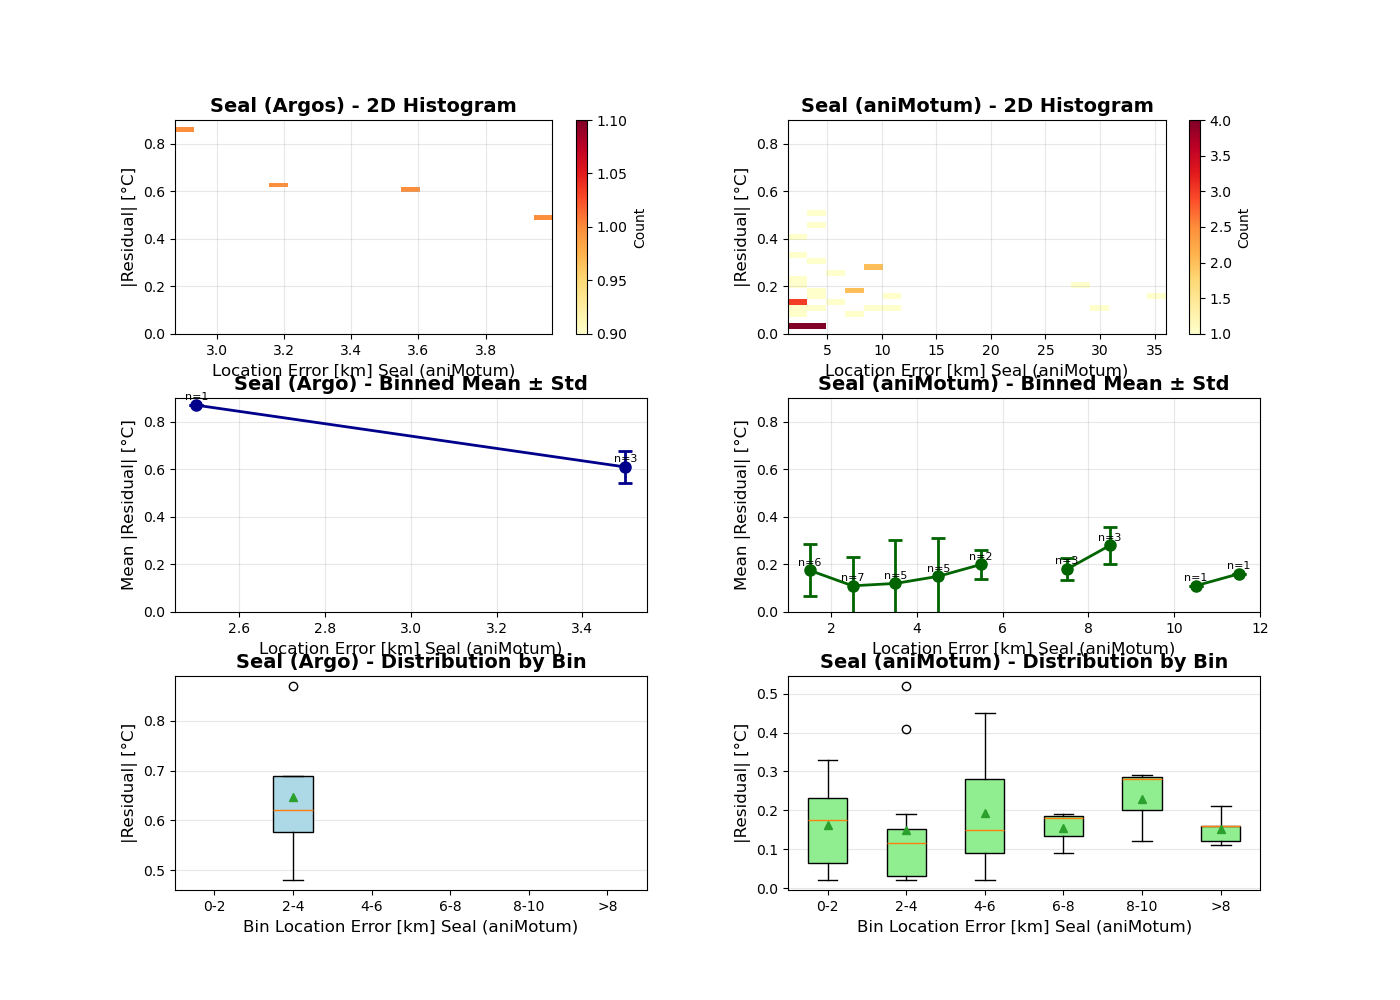


CORRELATION ANALYSIS

Seal (Argo):
  Pearson r = -0.922 (p = 0.0780)
  Spearman ρ = -1.000 (p = 0.0000)

Seal (aniMotum):
  Pearson r = 0.014 (p = 0.9376)
  Spearman ρ = 0.152 (p = 0.3770)

Interpretation:
  - If correlation ≈ 0 and p > 0.05: NO relationship (random)
  - If correlation > 0 and p < 0.05: POSITIVE relationship (larger error → larger residual)


In [124]:
hi_t_argo = df_argo[df_argo.L8_SST>0]
lo_t_argo = df_argo[df_argo.L8_SST<=0]

hi_t_sargo = df_seal_argo[df_seal_argo.L8_SST>0]
lo_t_sargo = df_seal_argo[df_seal_argo.L8_SST<=0]

hi_t_sani = df_seal_ani[df_seal_ani.L8_SST>0]
lo_t_sani = df_seal_ani[df_seal_ani.L8_SST<=0]

ind_var = 'time_dif_hours'
dep_var = 'abs_residual'
ind_title = 'Time Difference [hr] Argo'
dep_title = '|Residual| [°C]'
check_rel(hi_t_argo, lo_t_argo, ind_var, dep_var, ind_title, dep_title,'median')

ind_var = 'time_dif_hours'
dep_var = 'abs_residual'
ind_title = 'Time Difference [hr] Seal (Argos)'
dep_title = '|Residual| [°C]'
check_rel(hi_t_sargo, lo_t_sargo, ind_var, dep_var, ind_title, dep_title,'median')

ind_var = 'time_dif_hours'
dep_var = 'abs_residual'
ind_title = 'Time Difference [hr] Seal (aniMotum)'
dep_title = '|Residual| [°C]'
check_rel(hi_t_sani, lo_t_sani, ind_var, dep_var, ind_title, dep_title,'median')


ind_var = 'loc_err[km]'
dep_var = 'abs_residual'
ind_title = 'Location Error [km] Seal (Argos)'
dep_title = '|Residual| [°C]'
check_rel(hi_t_sargo, lo_t_sargo, ind_var, dep_var, ind_title, dep_title,'median')

ind_var = 'loc_err[km]'
dep_var = 'abs_residual'
ind_title = 'Location Error [km] Seal (aniMotum)'
dep_title = '|Residual| [°C]'
check_rel(hi_t_sani, lo_t_sani, ind_var, dep_var, ind_title, dep_title,'median')

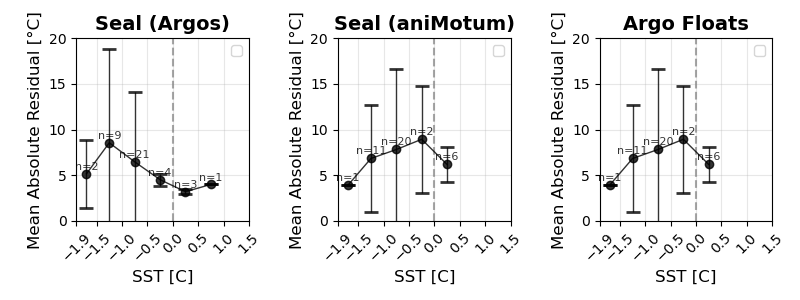


THRESHOLD ANALYSIS STATISTICAL TESTS
Threshold: 0.0 SST
Testing: Absolute Residual [°C] above vs below threshold
Bins: ['-1.9--1.5', '-1.5--1.0', '-1.0--0.5', '-0.5-0.0', '0.0-0.5', '0.5-1.0', '1.0-1.5']

--------------------------------------------------
ARGO ANALYSIS
--------------------------------------------------
Below threshold (n=34): 7.4594 ± 7.8250
Above threshold (n=6): 6.1833 ± 2.0670

1. Spearman Correlation:
   ρ = 0.0534, p = 0.7435

2. Welch's t-test:
   t = 0.8050, p = 0.4269

3. Mann-Whitney U test:
   U = 86, p = 0.5664

--------------------------------------------------
SEAL (ARGOS) ANALYSIS
--------------------------------------------------
Below threshold (n=36): 6.7077 ± 7.9960
Above threshold (n=4): 3.4016 ± 0.4869

1. Spearman Correlation:
   ρ = 0.0398, p = 0.8074

2. Welch's t-test:
   t = 2.4404, p = 0.0196

3. Mann-Whitney U test:
   U = 85, p = 0.5865

--------------------------------------------------
SEAL (ANIMOTUM) ANALYSIS
----------------------------

In [125]:
results = publication_threshold_analysis(
    df_seal_ani, df_seal_argo, df_seal_argo,
    ind_var='L8_SST', 
    dep_var='loc_err[km]',
    threshold=0.0,
    ind_title='SST [C]',
    dep_title='Absolute Residual [°C]',
    ylim = [0,20], # [-0.9,0.5]
    bins = [-1.9, -1.5, -1.0, -0.5, 0, 0.5, 1.0, 1.5],
    save_path='/home/jovyan/Landsat_SST_algorithm/Figures/temp_threshold_analysis.png'
)

### Checking the matchups that have high temperatures (SST > 0C)

In [79]:
df_seal_argo[df_seal_argo.L8_SST>=0.0]

,L8_SST,insitu_SST,std,loc_err[km],id,depth,DateTime,lat,lon,time_dif,residual,abs_residual,lon_dist,month,year,time_dif_hours,source
17,0.08,0.99,NaN,8.281859,ct149-924-18-2019-01-17 03:10:00,4.0,2019-01-17 03:10:00,-68.3106,75.4342,0 days 00:38:23.084031,-0.91,0.91,175.4342,1,2019,0.639746,Seal (Argos)
18,0.31,1.04,NaN,4.532121,ct149-924-18-2019-01-17 07:49:59,4.0,2019-01-17 07:49:59,-68.3835,75.4132,0 days 04:01:35.915969,-0.73,0.73,175.4132,1,2019,4.026643,Seal (Argos)
19,0.28,1.14,NaN,3.470795,ct149-924-18-2019-01-17 13:10:00,4.0,2019-01-17 13:10:00,-68.4977,75.1210,0 days 09:21:36.915969,-0.86,0.86,175.1210,1,2019,9.360254,Seal (Argos)
45,0.02,0.47,NaN,5.358400,ct164-F468-21-2022-01-18 03:30:00,4.0,2022-01-18 03:30:00,-65.2049,80.7734,0 days 00:11:46.956196,-0.45,0.45,179.2266,1,2022,0.196377,Seal (Argos)
46,0.00,0.41,NaN,6.885701,ct164-F468-21-2022-01-18 04:10:00,10.0,2022-01-18 04:10:00,-65.2295,80.7551,0 days 00:28:13.043804,-0.41,0.41,179.2449,1,2022,0.470290,Seal (Argos)
47,0.05,0.64,NaN,8.571047,ct164-F468-21-2022-01-18 15:00:00,4.0,2022-01-18 15:00:00,-65.2685,80.8630,0 days 11:18:13.043804,-0.59,0.59,179.1370,1,2022,11.303623,Seal (Argos)


In [80]:
checkingI = valids_sealargo_imos[['L8_filename','L8_SST','seal_id','seal_SST','A_lat','A_lon','loc_err[km]']]
checkingI['residual']=checkingI['L8_SST']-checkingI['seal_SST']
checkingI[checkingI.L8_SST>=0.0]

,L8_filename,L8_SST,seal_id,seal_SST,A_lat,A_lon,loc_err[km],residual
DateTime,,,,,,,,
2019-01-17 03:10:00,LC08_L1GT_127108_20190117_20201016_02_T2,0.08,ct149-924-18-2019-01-17 03:10:00,0.99,-68.3106,75.4342,8.281859,-0.91
2019-01-17 07:49:59,LC08_L1GT_127108_20190117_20201016_02_T2,0.31,ct149-924-18-2019-01-17 07:49:59,1.04,-68.3835,75.4132,4.532121,-0.73
2019-01-17 13:10:00,LC08_L1GT_127108_20190117_20201016_02_T2,0.28,ct149-924-18-2019-01-17 13:10:00,1.14,-68.4977,75.1210,3.470795,-0.86
2022-01-18 03:30:00,LC08_L1GT_126106_20220118_20220123_02_T2,0.02,ct164-F468-21-2022-01-18 03:30:00,0.47,-65.2049,80.7734,5.358400,-0.45
2022-01-18 04:10:00,LC08_L1GT_126106_20220118_20220123_02_T2,0.00,ct164-F468-21-2022-01-18 04:10:00,0.41,-65.2295,80.7551,6.885701,-0.41
2022-01-18 15:00:00,LC08_L1GT_126106_20220118_20220123_02_T2,0.05,ct164-F468-21-2022-01-18 15:00:00,0.64,-65.2685,80.8630,8.571047,-0.59


In [81]:
checkingI['2019-01-31':'2019-02-28']

,L8_filename,L8_SST,seal_id,seal_SST,A_lat,A_lon,loc_err[km],residual
DateTime,,,,,,,,
2019-02-08 19:40:00,LC08_L1GT_128108_20190209_20201016_02_T2,-0.52,ct149-930-18-2019-02-08 19:40:00,0.39,-67.8778,75.9226,8.932388,-0.91
2019-02-08 19:40:00,LC08_L1GT_128107_20190209_20201016_02_T2,-0.50,ct149-930-18-2019-02-08 19:40:00,0.39,-67.8778,75.9226,8.932388,-0.89
2019-02-08 22:19:59,LC08_L1GT_128107_20190209_20201016_02_T2,-0.73,ct148-936-18-2019-02-08 22:19:59,0.36,-67.8436,75.8100,1.435548,-1.09
2019-02-08 22:19:59,LC08_L1GT_128108_20190209_20201016_02_T2,-0.73,ct148-936-18-2019-02-08 22:19:59,0.36,-67.8436,75.8100,1.435548,-1.09
2019-02-08 22:30:00,LC08_L1GT_128108_20190209_20201016_02_T2,-1.32,ct149-926-18-2019-02-08 22:30:00,0.47,-67.8785,73.8025,5.365741,-1.79
...,...,...,...,...,...,...,...,...
2019-02-28 02:09:59,LC08_L1GT_117106_20190228_20201016_02_T2,-1.81,ft24-920-18-2019-02-28 02:09:59,-1.63,-65.5702,92.4458,16.350240,-0.18
2019-02-28 03:00:00,LC08_L1GT_085107_20190227_20201016_02_T2,-1.83,wd11-418BAT-16-2019-02-28 03:00:00,-1.76,-66.6753,141.0145,8.462090,-0.07
2019-02-28 08:09:59,LC08_L1GT_085107_20190227_20201016_02_T2,-1.75,wd11-418BAT-16-2019-02-28 08:09:59,-1.72,-66.5424,140.9647,12.924486,-0.03


In [82]:
checkingI[checkingI.seal_id.str.startswith('ct149-924-18')]

,L8_filename,L8_SST,seal_id,seal_SST,A_lat,A_lon,loc_err[km],residual
DateTime,,,,,,,,
2019-01-16 20:00:00,LC08_L1GT_127108_20190117_20201016_02_T2,-1.77,ct149-924-18-2019-01-16 20:00:00,1.02,-68.1559,75.7314,5.248351,-2.79
2019-01-17 03:10:00,LC08_L1GT_127108_20190117_20201016_02_T2,0.08,ct149-924-18-2019-01-17 03:10:00,0.99,-68.3106,75.4342,8.281859,-0.91
2019-01-17 07:49:59,LC08_L1GT_127108_20190117_20201016_02_T2,0.31,ct149-924-18-2019-01-17 07:49:59,1.04,-68.3835,75.4132,4.532121,-0.73
2019-01-17 13:10:00,LC08_L1GT_127108_20190117_20201016_02_T2,0.28,ct149-924-18-2019-01-17 13:10:00,1.14,-68.4977,75.1210,3.470795,-0.86
2019-02-19 22:19:59,LC08_L1GT_125108_20190220_20201016_02_T2,-1.34,ct149-924-18-2019-02-19 22:19:59,-0.87,-68.0434,77.4785,2.737622,-0.47
2019-02-20 01:10:00,LC08_L1GT_125108_20190220_20201016_02_T2,-0.85,ct149-924-18-2019-02-20 01:10:00,-0.53,-68.0913,77.4178,3.929368,-0.32
2019-02-20 08:49:59,LC08_L1GT_125108_20190220_20201016_02_T2,-1.88,ct149-924-18-2019-02-20 08:49:59,-0.71,-68.1563,77.5348,1.967026,-1.17
2019-02-20 13:10:00,LC08_L1GT_125108_20190220_20201016_02_T2,-1.77,ct149-924-18-2019-02-20 13:10:00,-0.65,-68.1980,77.5598,7.105225,-1.12


In [83]:
checkingI[checkingI.seal_id.str.startswith('ct164-F468-21')]

,L8_filename,L8_SST,seal_id,seal_SST,A_lat,A_lon,loc_err[km],residual
DateTime,,,,,,,,
2022-01-18 03:30:00,LC08_L1GT_126106_20220118_20220123_02_T2,0.02,ct164-F468-21-2022-01-18 03:30:00,0.47,-65.2049,80.7734,5.358400,-0.45
2022-01-18 04:10:00,LC08_L1GT_126106_20220118_20220123_02_T2,0.00,ct164-F468-21-2022-01-18 04:10:00,0.41,-65.2295,80.7551,6.885701,-0.41
2022-01-18 15:00:00,LC08_L1GT_126106_20220118_20220123_02_T2,0.05,ct164-F468-21-2022-01-18 15:00:00,0.64,-65.2685,80.8630,8.571047,-0.59
2022-01-28 19:49:59,LC08_L1GT_123107_20220129_20220204_02_T2,-1.06,ct164-F468-21-2022-01-28 19:49:59,-1.17,-66.6309,80.9453,4.071068,0.11
2022-01-29 03:10:00,LC08_L1GT_123107_20220129_20220204_02_T2,-1.32,ct164-F468-21-2022-01-29 03:10:00,-1.15,-66.6769,81.0204,4.345869,-0.17
2022-01-29 11:00:00,LC08_L1GT_123107_20220129_20220204_02_T2,-1.32,ct164-F468-21-2022-01-29 11:00:00,-1.13,-66.6645,81.2071,14.125393,-0.19


In [84]:
checkingB = valids_sealargo_basstr[['L8_filename','L8_SST','seal_id','seal_SST','A_lat','A_lon','loc_err[km]']]
checkingB['residual']=checkingB['L8_SST']-checkingB['seal_SST']
checkingB[checkingB.L8_SST>=0.0]

,L8_filename,L8_SST,seal_id,seal_SST,A_lat,A_lon,loc_err[km],residual
DateTime,,,,,,,,


### Figure. Residuals as a function of uncertainties

In [85]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import binned_statistic

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import binned_statistic

def dual_threshold_analysis_figure(df_seal_argo, df_seal_ani, df_argo, 
                                  dep_var='abs_residual',
                                  dep_title='Absolute Residual [°C]',
                                  figsize=(8, 6), save_path=None):
    """
    Create publication figure with time difference (top) and location error (bottom) analyses.
    """
    
    fig = plt.figure(figsize=figsize)
    
    # Colors - all black
    color = 'k'
    
    # ========================================================================
    # TOP ROW: TIME DIFFERENCE (3 plots - Argo, Seal Argos, Seal Animotum)
    # ========================================================================
    
    time_bins = np.array([0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0])
    time_threshold = 6
    
    datasets_time = [
        (df_seal_argo, 'Seal (Argos)', 'time_dif_hours'), 
        (df_seal_ani, 'Seal (aniMotum)', 'time_dif_hours'),
         (df_argo, 'Argo float', 'time_dif_hours')
    ]
    
    # Calculate y-axis limits for shared scale (top row)
    all_means_time = []
    all_stds_time = []
    
    for df, title, time_var in datasets_time:
        if time_var in df.columns:
            mean_vals, _, _ = binned_statistic(df[time_var], df[dep_var], 
                                             statistic='mean', bins=time_bins)
            std_vals, _, _ = binned_statistic(df[time_var], df[dep_var], 
                                            statistic='std', bins=time_bins)
            all_means_time.extend(mean_vals[~np.isnan(mean_vals)])
            all_stds_time.extend(std_vals[~np.isnan(std_vals)])
    
    ylim_val = max(all_means_time) + max(all_stds_time) * 1.2
    if dep_var=='abs_residual':
        time_ylim = [0, ylim_val]
    elif dep_var=='residual':
        time_ylim = [-ylim_val, ylim_val]
    
    for i, (df, title, time_var) in enumerate(datasets_time):
        ax = fig.add_subplot(2, 3, i+1)
        
        if time_var in df.columns:
            # Calculate binned statistics
            mean_vals, bin_edges, _ = binned_statistic(df[time_var], df[dep_var], 
                                                      statistic='mean', bins=time_bins)
            std_vals, _, _ = binned_statistic(df[time_var], df[dep_var], 
                                             statistic='std', bins=time_bins)
            count_vals, _, _ = binned_statistic(df[time_var], df[dep_var], 
                                              statistic='count', bins=time_bins)
            
            # Get bin centers
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
            
            # Plot with error bars
            ax.errorbar(bin_centers, mean_vals, yerr=std_vals, fmt='o-',
                       capsize=5, capthick=2, markersize=6, linewidth=1, 
                       color=color, ecolor=color, alpha=0.8)
            
            # Add sample sizes
            for j, (x, y, n) in enumerate(zip(bin_centers, mean_vals, count_vals)):
                if not np.isnan(y):
                    ax.text(x, y + time_ylim[1] * 0.05, f'n={int(n)}', 
                           ha='center', fontsize=8, alpha=0.8)
        
        if title=='Argo float':
            # Add vertical line at threshold
            ax.axvline(x=time_threshold, color='0.5', linestyle='--', alpha=0.7, linewidth=1.5)
        
        # Add dataset name in top right
        ax.text(0.95, 0.95, title, transform=ax.transAxes, fontsize=12, fontweight='bold',
                ha='right', va='top')
        
        # ✅ Add subplot letter (a, b, c) in top left
        ax.text(0.05, 0.95, chr(97+i), transform=ax.transAxes, fontsize=14, fontweight='bold',
                ha='left', va='top')
        
        # Formatting
        ax.set_ylim(time_ylim)
        ax.set_xlabel('Time Difference [hours]', fontsize=12)
        if i == 0:  # Only leftmost plot gets y-label
            ax.set_ylabel(f'Mean {dep_title}', fontsize=12)
        ax.grid(alpha=0.3)
        ax.set_xticks(time_bins)
        ax.set_xlim(-0.5, 12.5)
    
    # ========================================================================
    # BOTTOM ROW: LOCATION ERROR (2 plots - Seal Argos, Seal aniMotum)
    # ========================================================================
    
    loc_bins = np.array([0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16.0])
    loc_threshold = 2.5
    
    datasets_loc = [
        (df_seal_argo, 'Seal (Argos)', 'loc_err[km]'), 
        (df_seal_ani, 'Seal (aniMotum)', 'loc_err[km]')
    ]
    
    # Calculate y-axis limits for shared scale (bottom row)
    all_means_loc = []
    all_stds_loc = []
    
    for df, title, loc_var in datasets_loc:
        if loc_var in df.columns:
            mean_vals, _, _ = binned_statistic(df[loc_var], df[dep_var], 
                                             statistic='mean', bins=loc_bins)
            std_vals, _, _ = binned_statistic(df[loc_var], df[dep_var], 
                                            statistic='std', bins=loc_bins)
            all_means_loc.extend(mean_vals[~np.isnan(mean_vals)])
            all_stds_loc.extend(std_vals[~np.isnan(std_vals)])

    ylim_val = max(all_means_loc) + max(all_stds_loc) * 1.2
    if dep_var=='abs_residual':
        loc_ylim = [0, ylim_val]
    elif dep_var=='residual':
        loc_ylim = [-ylim_val, ylim_val]
    
    for i, (df, title, loc_var) in enumerate(datasets_loc):
        ax = fig.add_subplot(2, 3, i+4)  # Positions 4 and 5 (bottom left and center)
        
        if loc_var in df.columns:
            # Calculate binned statistics
            mean_vals, bin_edges, _ = binned_statistic(df[loc_var], df[dep_var], 
                                                      statistic='mean', bins=loc_bins)
            std_vals, _, _ = binned_statistic(df[loc_var], df[dep_var], 
                                             statistic='std', bins=loc_bins)
            count_vals, _, _ = binned_statistic(df[loc_var], df[dep_var], 
                                              statistic='count', bins=loc_bins)
            
            # Get bin centers
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
            
            # Plot with error bars
            ax.errorbar(bin_centers, mean_vals, yerr=std_vals, fmt='o-',
                       capsize=5, capthick=2, markersize=6, linewidth=1, 
                       color=color, ecolor=color, alpha=0.8)
            
            # Add sample sizes
            for j, (x, y, n) in enumerate(zip(bin_centers, mean_vals, count_vals)):
                if not np.isnan(y):
                    ax.text(x, y + loc_ylim[1] * 0.05, f'n={int(n)}', 
                           ha='center', fontsize=8, alpha=0.8)
        
        # ✅ Add subplot letter (d, e) in top left
        ax.text(0.05, 0.95, chr(97+i+3), transform=ax.transAxes, fontsize=14, fontweight='bold',
                ha='left', va='top')
        
        # Formatting
        ax.set_ylim(loc_ylim)
        ax.set_xlabel('Location Error [km]', fontsize=12)
        if i == 0:  # Only leftmost plot gets y-label
            ax.set_ylabel(f'Mean {dep_title}', fontsize=12)
        ax.grid(alpha=0.3)
        ax.set_xticks(loc_bins)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

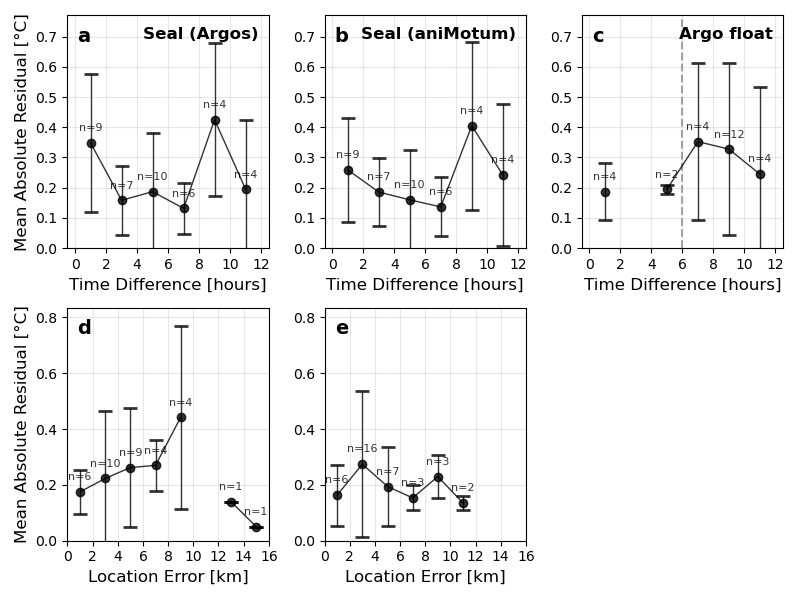

In [86]:
# Usage:
dual_threshold_analysis_figure(
    df_seal_argo, df_seal_ani, df_argo,
    dep_var='abs_residual',
    dep_title='Absolute Residual [°C]',
    save_path='/home/jovyan/Landsat_SST_algorithm/Figures/dual_threshold_analysis.png'
)

In [89]:
# Create warm/cold splits based on L8_SST > 0
# Argo floats
hi_t_argo = df_argo[df_argo['L8_SST'] > 0]
lo_t_argo = df_argo[df_argo['L8_SST'] <= 0]

# Seal Argos 
hi_t_sargo = df_seal_argo[df_seal_argo['L8_SST'] > 0]
lo_t_sargo = df_seal_argo[df_seal_argo['L8_SST'] <= 0]

# Seal Animotum
hi_t_sani = df_seal_ani[df_seal_ani['L8_SST'] > 0]
lo_t_sani = df_seal_ani[df_seal_ani['L8_SST'] <= 0]

# Print summary
print("Warm/Cold Temperature Splits:")
print(f"Argo - Warm (>0°C): {len(hi_t_argo)}, Cold (≤0°C): {len(lo_t_argo)}")
print(f"Seal Argos - Warm (>0°C): {len(hi_t_sargo)}, Cold (≤0°C): {len(lo_t_sargo)}")
print(f"Seal Animotum - Warm (>0°C): {len(hi_t_sani)}, Cold (≤0°C): {len(lo_t_sani)}")

Warm/Cold Temperature Splits:
Argo - Warm (>0°C): 7, Cold (≤0°C): 19
Seal Argos - Warm (>0°C): 5, Cold (≤0°C): 35
Seal Animotum - Warm (>0°C): 4, Cold (≤0°C): 36


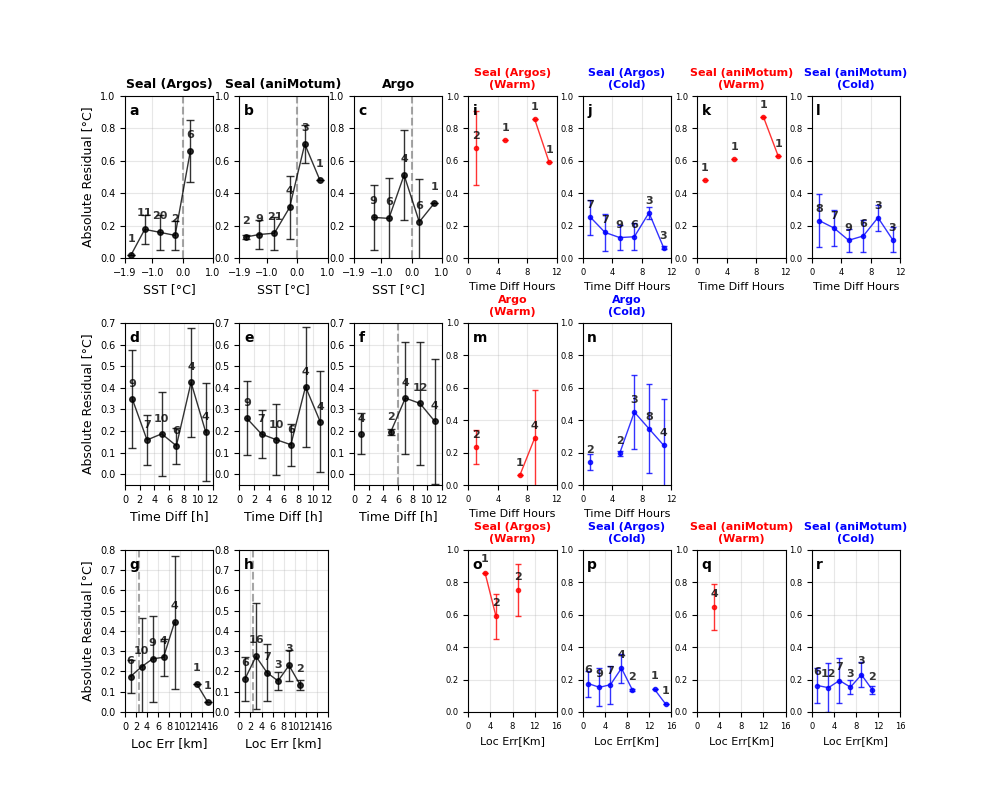

In [94]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import binned_statistic
import matplotlib.gridspec as gridspec

def create_comprehensive_threshold_figure(df_seal_argo, df_seal_ani, df_argo,
                                        hi_t_argo, lo_t_argo, hi_t_sargo, lo_t_sargo, 
                                        hi_t_sani, lo_t_sani, figsize=(7.5, 10), save_path=None):
    """
    Create comprehensive threshold analysis figure with two main columns.
    Left: Overall threshold analyses (3 rows)
    Right: Warm vs cold SST comparisons (3 rows × 4 columns)
    """
    
    fig = plt.figure(figsize=figsize)
    
    # Create custom grid: left side 3×3, right side 3×4 - NO center spacing
    gs = gridspec.GridSpec(3, 7, figure=fig, 
                          width_ratios=[1, 1, 1, 1, 1, 1, 1],  # No spacing column
                          height_ratios=[1, 1, 1],
                          hspace=0.4, wspace=0.3)  # Tight spacing
    
    color = 'k'
    
    # ========================================================================
    # LEFT COLUMN: OVERALL THRESHOLD ANALYSES (3 rows)
    # ========================================================================
    
    # Row 1: SST vs Absolute Residual (3 plots including Argo)
    sst_bins = np.array([-1.9, -1.5, -1.0, -0.5, 0, 0.5, 1.0, 1.5])
    datasets_sst = [
        (df_seal_argo, 'Seal (Argos)', 'L8_SST', 'abs_residual'),
        (df_seal_ani, 'Seal (aniMotum)', 'L8_SST', 'abs_residual'),
        (df_argo, 'Argo', 'L8_SST', 'abs_residual')
    ]
    
    sst_ylim = [0, 1.0]
    
    for i, (df, title, sst_var, dep_var) in enumerate(datasets_sst):
        ax = fig.add_subplot(gs[0, i])  # Row 1
        
        if sst_var in df.columns and dep_var in df.columns:
            mean_vals, bin_edges, _ = binned_statistic(df[sst_var], df[dep_var], 
                                                      statistic='mean', bins=sst_bins)
            std_vals, _, _ = binned_statistic(df[sst_var], df[dep_var], 
                                             statistic='std', bins=sst_bins)
            count_vals, _, _ = binned_statistic(df[sst_var], df[dep_var], 
                                              statistic='count', bins=sst_bins)
            
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
            
            ax.errorbar(bin_centers, mean_vals, yerr=std_vals, fmt='o-',
                       capsize=3, capthick=1, markersize=4, linewidth=1, 
                       color=color, ecolor=color, alpha=0.8)
            
            # Larger font for n= values
            for j, (x, y, n) in enumerate(zip(bin_centers, mean_vals, count_vals)):
                if not np.isnan(y) and n > 0:
                    ax.text(x, y + sst_ylim[1] * 0.08, f'{int(n)}', 
                               ha='center', fontsize=8, alpha=0.8, fontweight='bold')
        
        ax.set_ylim(sst_ylim)
        ax.set_xlabel('SST [°C]', fontsize=9)
        if i == 0:
            ax.set_ylabel('Absolute Residual [°C]', fontsize=9)
        ax.set_title(title, fontsize=9, fontweight='bold')
        ax.grid(alpha=0.3)
        ax.set_xticks(sst_bins[::2])
        ax.tick_params(axis='x', labelsize=7) #,rotation=45, 
        ax.tick_params(axis='y', labelsize=7)
        
        # Add subplot label
        ax.text(0.05, 0.95, chr(97+i), transform=ax.transAxes, fontsize=10, fontweight='bold',
                ha='left', va='top')

        ax.axvline(x=0, color='0.5', linestyle='--', alpha=0.7, linewidth=1.5)
    
    # Row 2: Time Difference vs Absolute Residual (3 plots)
    time_bins = np.array([0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0])
    datasets_time = [
        (df_seal_argo, 'Seal (Argos)', 'time_dif_hours', 'abs_residual'),
        (df_seal_ani, 'Seal (aniMotum)', 'time_dif_hours', 'abs_residual'),
        (df_argo, 'Argo', 'time_dif_hours', 'abs_residual')
    ]
    
    time_ylim = [-0.05, 0.7]
    
    for i, (df, title, time_var, dep_var) in enumerate(datasets_time):
        ax = fig.add_subplot(gs[1, i])  # Row 2
        
        if time_var in df.columns and dep_var in df.columns:
            mean_vals, bin_edges, _ = binned_statistic(df[time_var], df[dep_var], 
                                                      statistic='mean', bins=time_bins)
            std_vals, _, _ = binned_statistic(df[time_var], df[dep_var], 
                                             statistic='std', bins=time_bins)
            count_vals, _, _ = binned_statistic(df[time_var], df[dep_var], 
                                              statistic='count', bins=time_bins)
            
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
            
            ax.errorbar(bin_centers, mean_vals, yerr=std_vals, fmt='o-',
                       capsize=3, capthick=1, markersize=4, linewidth=1, 
                       color=color, ecolor=color, alpha=0.8)
            
            # Larger font for n= values
            for j, (x, y, n) in enumerate(zip(bin_centers, mean_vals, count_vals)):
                if not np.isnan(y) and n > 0:
                    ax.text(x, y + time_ylim[1] * 0.08, f'{int(n)}', 
                               ha='center', fontsize=8, alpha=0.8, fontweight='bold')
        
        if title == 'Argo':
            ax.axvline(x=6, color='0.5', linestyle='--', alpha=0.7, linewidth=1.5)
        
        ax.set_ylim(time_ylim)
        ax.set_xlabel('Time Diff [h]', fontsize=9)
        if i == 0:
            ax.set_ylabel('Absolute Residual [°C]', fontsize=9)
        # ax.set_title(title, fontsize=9, fontweight='bold')
        ax.grid(alpha=0.3)
        ax.set_xticks(time_bins)
        ax.tick_params(labelsize=7)
        
        # Add subplot label
        ax.text(0.05, 0.95, chr(97+i+3), transform=ax.transAxes, fontsize=10, fontweight='bold',
                ha='left', va='top')
    
    # Row 3: Location Error vs Absolute Residual (2 plots)
    loc_bins = np.array([0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16.0])
    datasets_loc = [
        (df_seal_argo, 'Seal (Argos)', 'loc_err[km]', 'abs_residual'),
        (df_seal_ani, 'Seal (aniMotum)', 'loc_err[km]', 'abs_residual')
    ]
    
    loc_ylim = [0, 0.8]
    
    for i, (df, title, loc_var, dep_var) in enumerate(datasets_loc):
        ax = fig.add_subplot(gs[2, i])  # Row 3
        
        if loc_var in df.columns and dep_var in df.columns:
            mean_vals, bin_edges, _ = binned_statistic(df[loc_var], df[dep_var], 
                                                      statistic='mean', bins=loc_bins)
            std_vals, _, _ = binned_statistic(df[loc_var], df[dep_var], 
                                             statistic='std', bins=loc_bins)
            count_vals, _, _ = binned_statistic(df[loc_var], df[dep_var], 
                                              statistic='count', bins=loc_bins)
            
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
            
            ax.errorbar(bin_centers, mean_vals, yerr=std_vals, fmt='o-',
                       capsize=3, capthick=1, markersize=4, linewidth=1, 
                       color=color, ecolor=color, alpha=0.8)
            
            # Larger font for n= values
            for j, (x, y, n) in enumerate(zip(bin_centers, mean_vals, count_vals)):
                if not np.isnan(y) and n > 0:
                    ax.text(x, y + loc_ylim[1] * 0.08, f'{int(n)}', 
                               ha='center', fontsize=8, alpha=0.8, fontweight='bold')
        
        ax.axvline(x=2.5, color='0.5', linestyle='--', alpha=0.7, linewidth=1.5)
        
        ax.set_ylim(loc_ylim)
        ax.set_xlabel('Loc Err [km]', fontsize=9)
        if i == 0:
            ax.set_ylabel('Absolute Residual [°C]', fontsize=9)
        # ax.set_title(title, fontsize=9, fontweight='bold')
        ax.grid(alpha=0.3)
        ax.set_xticks(loc_bins)
        ax.tick_params(labelsize=7)
        
        # Add subplot label
        ax.text(0.05, 0.95, chr(97+i+6), transform=ax.transAxes, fontsize=10, fontweight='bold',
                ha='left', va='top')
    
    # ========================================================================
    # RIGHT COLUMN: WARM VS COLD SST COMPARISONS (3 rows × 4 columns)
    # ========================================================================
    
    def plot_warm_cold_comparison(ax_warm, ax_cold, hi_data, lo_data, ind_var, dep_var, 
                                 title_base, bins, ylim, label_start_idx):
        """Plot warm vs cold comparison"""
        
        # Warm plot
        if ind_var in hi_data.columns and dep_var in hi_data.columns:
            mean_vals_warm, bin_edges, _ = binned_statistic(hi_data[ind_var], hi_data[dep_var], 
                                                           statistic='mean', bins=bins)
            std_vals_warm, _, _ = binned_statistic(hi_data[ind_var], hi_data[dep_var], 
                                                  statistic='std', bins=bins)
            count_vals_warm, _, _ = binned_statistic(hi_data[ind_var], hi_data[dep_var], 
                                                    statistic='count', bins=bins)
            
            bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
            
            ax_warm.errorbar(bin_centers, mean_vals_warm, yerr=std_vals_warm, fmt='o-',
                           capsize=2, capthick=1, markersize=3, linewidth=1, 
                           color='red', ecolor='red', alpha=0.8)
            
            # Larger font for n= values
            for j, (x, y, n) in enumerate(zip(bin_centers, mean_vals_warm, count_vals_warm)):
                if not np.isnan(y) and n > 0:
                    ax_warm.text(x, y + ylim[1] * 0.08, f'{int(n)}', 
                               ha='center', fontsize=8, alpha=0.8, fontweight='bold')
        
        # Cold plot
        if ind_var in lo_data.columns and dep_var in lo_data.columns:
            mean_vals_cold, bin_edges, _ = binned_statistic(lo_data[ind_var], lo_data[dep_var], 
                                                           statistic='mean', bins=bins)
            std_vals_cold, _, _ = binned_statistic(lo_data[ind_var], lo_data[dep_var], 
                                                  statistic='std', bins=bins)
            count_vals_cold, _, _ = binned_statistic(lo_data[ind_var], lo_data[dep_var], 
                                                    statistic='count', bins=bins)
            
            ax_cold.errorbar(bin_centers, mean_vals_cold, yerr=std_vals_cold, fmt='o-',
                           capsize=2, capthick=1, markersize=3, linewidth=1, 
                           color='blue', ecolor='blue', alpha=0.8)
            
            # Larger font for n= values
            for j, (x, y, n) in enumerate(zip(bin_centers, mean_vals_cold, count_vals_cold)):
                if not np.isnan(y) and n > 0:
                    ax_cold.text(x, y + ylim[1] * 0.08, f'{int(n)}', 
                               ha='center', fontsize=8, alpha=0.8, fontweight='bold')
        
        # Format both plots
        for ax, temp_type, color_name in [(ax_warm, 'Warm', 'red'), (ax_cold, 'Cold', 'blue')]:
            ax.set_ylim([0, 1.0])  # Fixed ylim = 1.0
            ax.set_xlabel(ind_var.replace('_', ' ').title().replace('Dif', 'Diff'), fontsize=8)
            ax.set_title(f'{title_base}\n({temp_type})', fontsize=8, fontweight='bold', color=color_name)
            ax.grid(alpha=0.3)
            ax.set_xticks(bins[::2] if len(bins) > 6 else bins)
            ax.tick_params(labelsize=6)
        
        # # Y-label only on warm (left) plot
        # ax_warm.set_ylabel('|Residual|', fontsize=8)
        
        # Add subplot labels
        ax_warm.text(0.05, 0.95, chr(97+label_start_idx), transform=ax_warm.transAxes, 
                    fontsize=10, fontweight='bold', ha='left', va='top')
        ax_cold.text(0.05, 0.95, chr(97+label_start_idx+1), transform=ax_cold.transAxes, 
                    fontsize=10, fontweight='bold', ha='left', va='top')
    
    # Right column layout: 3 rows × 4 columns (no center spacing)
    # Row 1: Seal Argos Time (warm/cold), Seal Animotum Time (warm/cold)  
    # Row 2: Argo Time (warm/cold), empty, empty
    # Row 3: Seal Argos Location (warm/cold), Seal Animotum Location (warm/cold)
    
    # Row 1: Seal time comparisons
    ax_sargo_warm = fig.add_subplot(gs[0, 3])
    ax_sargo_cold = fig.add_subplot(gs[0, 4])
    plot_warm_cold_comparison(ax_sargo_warm, ax_sargo_cold, hi_t_sargo, lo_t_sargo, 
                             'time_dif_hours', 'abs_residual', 'Seal (Argos)', time_bins, time_ylim, 8)
    
    ax_sani_warm = fig.add_subplot(gs[0, 5])
    ax_sani_cold = fig.add_subplot(gs[0, 6])
    plot_warm_cold_comparison(ax_sani_warm, ax_sani_cold, hi_t_sani, lo_t_sani, 
                             'time_dif_hours', 'abs_residual', 'Seal (aniMotum)', time_bins, time_ylim, 10)
    
    # Row 2: Argo time comparison (first two positions)
    ax_argo_warm = fig.add_subplot(gs[1, 3])
    ax_argo_cold = fig.add_subplot(gs[1, 4])
    plot_warm_cold_comparison(ax_argo_warm, ax_argo_cold, hi_t_argo, lo_t_argo, 
                             'time_dif_hours', 'abs_residual', 'Argo', time_bins, time_ylim, 12)
    
    # Row 3: Seal location comparisons
    ax_sargo_loc_warm = fig.add_subplot(gs[2, 3])
    ax_sargo_loc_cold = fig.add_subplot(gs[2, 4])
    plot_warm_cold_comparison(ax_sargo_loc_warm, ax_sargo_loc_cold, hi_t_sargo, lo_t_sargo, 
                             'loc_err[km]', 'abs_residual', 'Seal (Argos)', loc_bins, loc_ylim, 14)
    
    ax_sani_loc_warm = fig.add_subplot(gs[2, 5])
    ax_sani_loc_cold = fig.add_subplot(gs[2, 6])
    plot_warm_cold_comparison(ax_sani_loc_warm, ax_sani_loc_cold, hi_t_sani, lo_t_sani, 
                             'loc_err[km]', 'abs_residual', 'Seal (aniMotum)', loc_bins, loc_ylim, 16)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# Usage:
create_comprehensive_threshold_figure(
    df_seal_argo, df_seal_ani, df_argo,
    hi_t_argo, lo_t_argo, hi_t_sargo, lo_t_sargo, hi_t_sani, lo_t_sani,
    figsize=(10, 8),
    save_path='/home/jovyan/Landsat_SST_algorithm/Figures/comprehensive_threshold_analysis.png'
)

In [95]:
print('Removing data from two tags that appears to be problematic for both Argos and aniMotum datasets')
print('ct149-924-18 from 2019-01-17 and ct164-F468-21 from 2022-01-18, both from East of Amery Ice Shelf')
bad_matchups = [
    'ct149-924-18-2019-01-17 03:10:00',
    'ct149-924-18-2019-01-17 07:49:59',
    'ct149-924-18-2019-01-17 13:10:00',
    'ct164-F468-21-2022-01-18 03:30:00',
    'ct164-F468-21-2022-01-18 04:10:00',
    'ct164-F468-21-2022-01-18 15:00:00',
]
df_seal_argo = df_seal_argo[~df_seal_argo.id.isin(bad_matchups)]
df_seal_ani = df_seal_ani[~df_seal_ani.id.isin(bad_matchups)]
df_sealI = df_sealI[~df_sealI.id.isin(bad_matchups)]
df_seal_aniI = df_seal_aniI[~df_seal_aniI.id.isin(bad_matchups)]

Removing data from two tags that appears to be problematic for both Argos and aniMotum datasets
ct149-924-18 from 2019-01-17 and ct164-F468-21 from 2022-01-18, both from East of Amery Ice Shelf


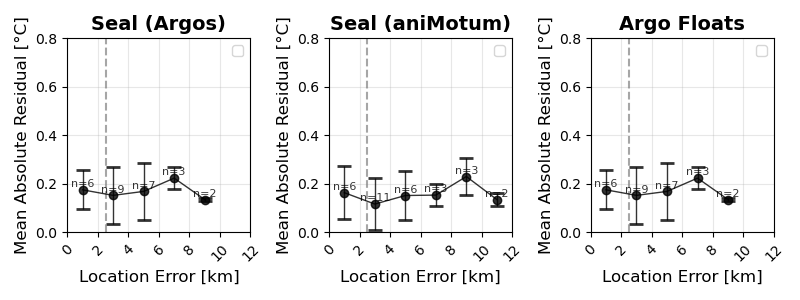


THRESHOLD ANALYSIS STATISTICAL TESTS
Threshold: 2.5 err[km]
Testing: Absolute Residual [°C] above vs below threshold
Bins: ['0.0-2.0', '2.0-4.0', '4.0-6.0', '6.0-8.0', '8.0-10.0', '10.0-12.0']

--------------------------------------------------
ARGO ANALYSIS
--------------------------------------------------
Below threshold (n=8): 0.1462 ± 0.0913
Above threshold (n=26): 0.1638 ± 0.1087

1. Spearman Correlation:
   ρ = -0.0796, p = 0.6544

2. Welch's t-test:
   t = -0.4547, p = 0.6564

3. Mann-Whitney U test:
   U = 88, p = 0.5290

--------------------------------------------------
SEAL (ARGOS) ANALYSIS
--------------------------------------------------
Below threshold (n=8): 0.1462 ± 0.0913
Above threshold (n=26): 0.1638 ± 0.1087

1. Spearman Correlation:
   ρ = -0.0796, p = 0.6544

2. Welch's t-test:
   t = -0.4547, p = 0.6564

3. Mann-Whitney U test:
   U = 88, p = 0.5290

--------------------------------------------------
SEAL (ANIMOTUM) ANALYSIS
-----------------------------------

In [136]:
results = publication_threshold_analysis(
    df_seal_argo, df_seal_ani, df_seal_argo,
    ind_var='loc_err[km]', 
    dep_var='abs_residual',
    threshold=2.5,
    ind_title='Location Error [km]',
    dep_title='Absolute Residual [°C]',
    ylim = [0,0.8],
    save_path='/home/jovyan/Landsat_SST_algorithm/Figures/loc_threshold_analysis.png'
)

### Testing performance of Argo vs aniMotum positioning

SEAL TAG POSITIONING METHOD COMPARISON
Metric: Landsat SST Residuals (Landsat - Seal)
Methods: Argos vs aniMotum positioning

Data Preparation - Matching id pairs...
  Argos dataset: 34 total records, 34 unique id pairs
  aniMotum dataset: 34 total records, 34 unique id pairs
  Common pairs: 34
  Argos only: 0
  aniMotum only: 0
  ✓ Successfully matched 34 id pairs
  Final paired sample size: 34 measurements
  Removed 0 pairs with NaN residuals

Verification of pairing (first 5 rows):
Argos ids: ['ct147-863-18-2019-03-03 10:40:00', 'ct147-863-18-2019-03-03 19:10:00', 'ct147-867-18-2019-02-13 12:00:00', 'ct147-867-18-2019-02-13 20:09:59', 'ct147-870-18-2019-02-13 11:09:59']
ani   ids: ['ct147-863-18-2019-03-03 10:40:00', 'ct147-863-18-2019-03-03 19:10:00', 'ct147-867-18-2019-02-13 12:00:00', 'ct147-867-18-2019-02-13 20:09:59', 'ct147-870-18-2019-02-13 11:09:59']

ACCURACY ANALYSIS (Central Tendency)
--------------------------------------------------
Descriptive Statistics:
             

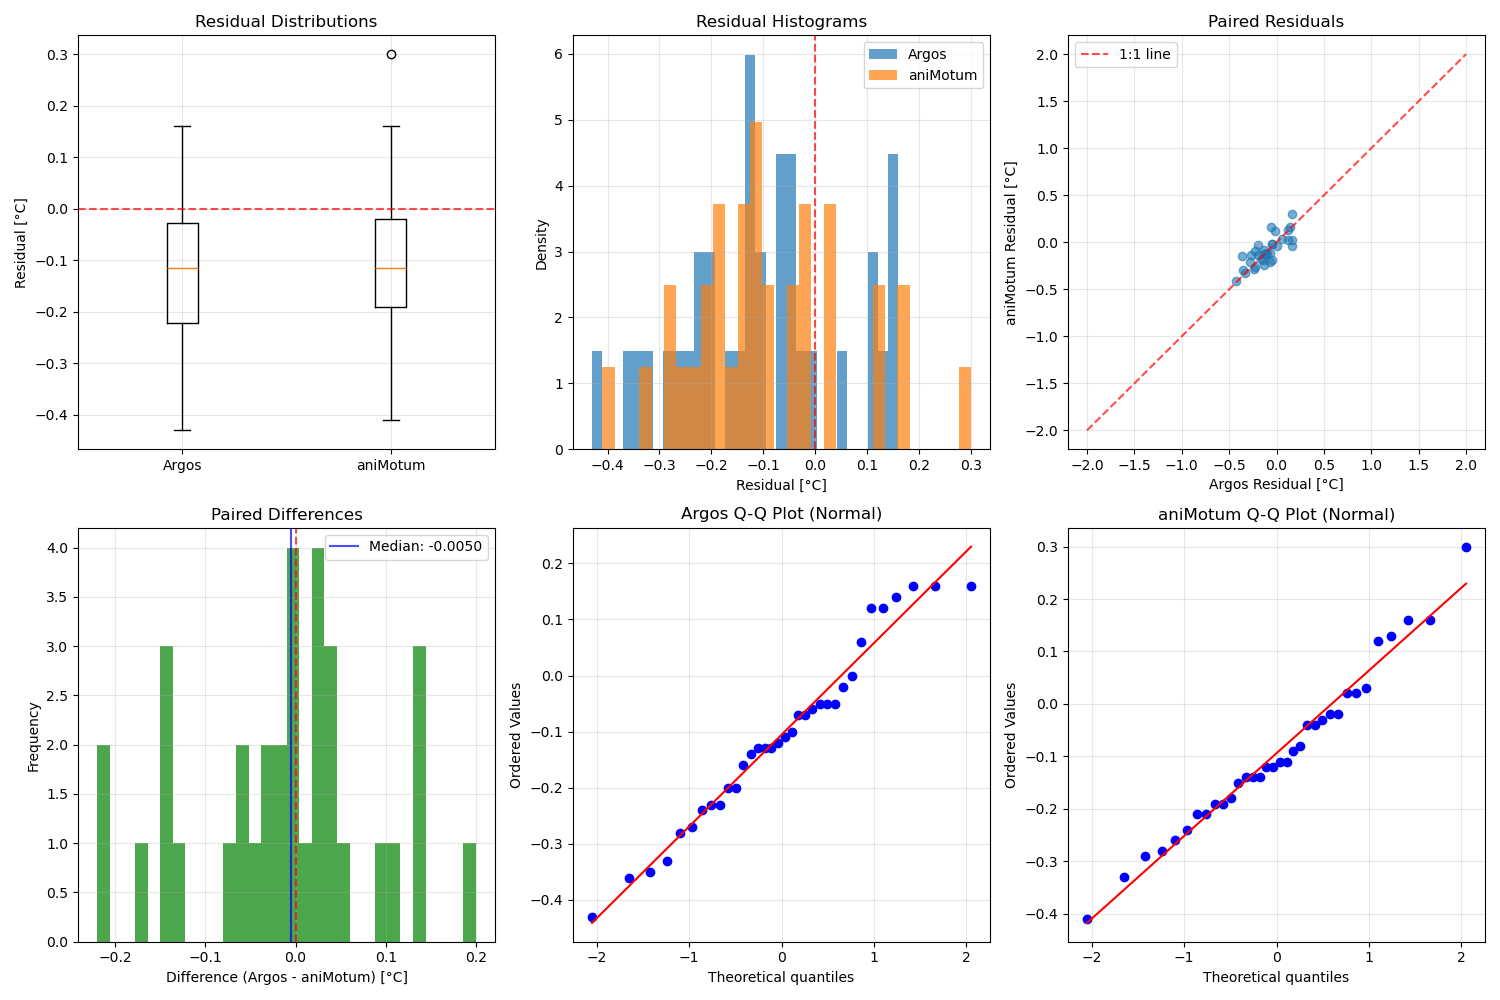

SUMMARY AND RECOMMENDATIONS
ACCURACY (Central Tendency):
  → No significant difference in accuracy between methods (p = 0.6602)
STABILITY (Variability):
  → No significant difference in stability between methods (p = 0.7404)
OVERALL ERROR:
  → No significant difference in overall error between methods (p = 0.6334)


In [96]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

def seal_positioning_comparison_analysis(df_seal_argo, df_seal_ani, save_path=None):
    """
    Compare positioning accuracy and stability between Argos and Animotum methods
    using residuals as the metric. Non-parametric statistical tests.
    
    Ensures paired comparison by matching id and L8_filename combinations.
    """
    
    print("="*80)
    print("SEAL TAG POSITIONING METHOD COMPARISON")
    print("="*80)
    print("Metric: Landsat SST Residuals (Landsat - Seal)")
    print("Methods: Argos vs aniMotum positioning")
    print()
    
    # ========================================================================
    # Data Preparation - ENSURE MATCHING PAIRS
    # ========================================================================
    
    print("Data Preparation - Matching id pairs...")
    
    # Create composite key for matching
    df_seal_argo['match_key'] = df_seal_argo['id'].astype(str)
    df_seal_ani['match_key'] = df_seal_ani['id'].astype(str)
    
    # Find common pairs between datasets
    argo_keys = set(df_seal_argo['match_key'])
    ani_keys = set(df_seal_ani['match_key'])
    common_keys = argo_keys.intersection(ani_keys)
    
    print(f"  Argos dataset: {len(df_seal_argo)} total records, {len(argo_keys)} unique id pairs")
    print(f"  aniMotum dataset: {len(df_seal_ani)} total records, {len(ani_keys)} unique id pairs")
    print(f"  Common pairs: {len(common_keys)}")
    print(f"  Argos only: {len(argo_keys - ani_keys)}")
    print(f"  aniMotum only: {len(ani_keys - argo_keys)}")
    
    # Filter to only common pairs
    df_argo_matched = df_seal_argo[df_seal_argo['match_key'].isin(common_keys)].copy()
    df_ani_matched = df_seal_ani[df_seal_ani['match_key'].isin(common_keys)].copy()
    
    # Sort both dataframes by match_key to ensure same order
    df_argo_matched = df_argo_matched.sort_values('match_key').reset_index(drop=True)
    df_ani_matched = df_ani_matched.sort_values('match_key').reset_index(drop=True)
    
    # Verify the matching worked
    assert len(df_argo_matched) == len(df_ani_matched), "Matched datasets have different lengths!"
    assert (df_argo_matched['match_key'] == df_ani_matched['match_key']).all(), "Match keys don't align!"
    
    print(f"  ✓ Successfully matched {len(df_argo_matched)} id pairs")
    
    # Remove NaN residuals while maintaining pairing
    valid_mask = df_argo_matched['residual'].notna() & df_ani_matched['residual'].notna()
    df_argo_final = df_argo_matched[valid_mask].reset_index(drop=True)
    df_ani_final = df_ani_matched[valid_mask].reset_index(drop=True)
    
    argos_residuals = df_argo_final['residual']
    animotum_residuals = df_ani_final['residual']
    
    print(f"  Final paired sample size: {len(argos_residuals)} measurements")
    print(f"  Removed {len(df_argo_matched) - len(argos_residuals)} pairs with NaN residuals")
    print()
    
    # Verify pairing one more time
    print("Verification of pairing (first 5 rows):")
    print("Argos ids:", df_argo_final['id'].head().tolist())
    print("ani   ids:", df_ani_final['id'].head().tolist())
    print()
    
    # ========================================================================
    # ACCURACY ANALYSIS (Central Tendency)
    # ========================================================================
    
    print("ACCURACY ANALYSIS (Central Tendency)")
    print("-" * 50)
    
    # Descriptive statistics
    argos_stats = {
        'mean': argos_residuals.mean(),
        'median': argos_residuals.median(),
        'std': argos_residuals.std(),
        'iqr': argos_residuals.quantile(0.75) - argos_residuals.quantile(0.25),
        'mad': np.median(np.abs(argos_residuals - argos_residuals.median()))
    }
    
    animotum_stats = {
        'mean': animotum_residuals.mean(),
        'median': animotum_residuals.median(),
        'std': animotum_residuals.std(),
        'iqr': animotum_residuals.quantile(0.75) - animotum_residuals.quantile(0.25),
        'mad': np.median(np.abs(animotum_residuals - animotum_residuals.median()))
    }
    
    print("Descriptive Statistics:")
    print(f"                 {'Argos':>10} {'aniMotum':>10} {'Difference':>12}")
    print(f"Mean           {argos_stats['mean']:>10.4f} {animotum_stats['mean']:>10.4f} {argos_stats['mean']-animotum_stats['mean']:>12.4f}")
    print(f"Median         {argos_stats['median']:>10.4f} {animotum_stats['median']:>10.4f} {argos_stats['median']-animotum_stats['median']:>12.4f}")
    print(f"Std Dev        {argos_stats['std']:>10.4f} {animotum_stats['std']:>10.4f} {argos_stats['std']-animotum_stats['std']:>12.4f}")
    print(f"IQR            {argos_stats['iqr']:>10.4f} {animotum_stats['iqr']:>10.4f} {argos_stats['iqr']-animotum_stats['iqr']:>12.4f}")
    print(f"MAD            {argos_stats['mad']:>10.4f} {animotum_stats['mad']:>10.4f} {argos_stats['mad']-animotum_stats['mad']:>12.4f}")
    print()
    
    # PAIRED TESTS - Since we now have matched pairs
    print("Statistical Tests for Accuracy (PAIRED TESTS):")
    
    # Wilcoxon signed-rank test (paired version of Mann-Whitney)
    wilcoxon_stat, wilcoxon_p = stats.wilcoxon(argos_residuals, animotum_residuals, alternative='two-sided')
    
    print(f"Wilcoxon Signed-Rank Test (paired medians):")
    print(f"  Statistic: {wilcoxon_stat:.0f}")
    print(f"  P-value: {wilcoxon_p:.6f}")
    print(f"  Significant: {'Yes' if wilcoxon_p < 0.05 else 'No'} (α = 0.05)")
    
    # Effect size for paired test
    differences = argos_residuals - animotum_residuals
    n_pairs = len(differences)
    r_paired = wilcoxon_stat / (n_pairs * (n_pairs + 1) / 4)  # Adjusted for paired test
    print(f"  Effect size (r): {r_paired:.4f}")
    
    # Also show the unpaired test for comparison
    mw_stat, mw_p = stats.mannwhitneyu(argos_residuals, animotum_residuals, alternative='two-sided')
    print(f"\nMann-Whitney U Test (unpaired, for comparison):")
    print(f"  Statistic: {mw_stat:.0f}")
    print(f"  P-value: {mw_p:.6f}")
    print()
    
    # ========================================================================
    # STABILITY ANALYSIS (Variability)
    # ========================================================================
    
    print("STABILITY ANALYSIS (Variability)")
    print("-" * 50)
    
    # Test for difference in variability (Levene's test - robust to non-normality)
    levene_stat, levene_p = stats.levene(argos_residuals, animotum_residuals, center='median')
    
    print("Statistical Tests for Stability:")
    print(f"Levene's Test (equal variances, center=median):")
    print(f"  Statistic: {levene_stat:.4f}")
    print(f"  P-value: {levene_p:.6f}")
    print(f"  Significant: {'Yes' if levene_p < 0.05 else 'No'} (α = 0.05)")
    
    # Fligner-Killeen test (non-parametric alternative)
    fk_stat, fk_p = stats.fligner(argos_residuals, animotum_residuals)
    print(f"Fligner-Killeen Test (equal variances, non-parametric):")
    print(f"  Statistic: {fk_stat:.4f}")
    print(f"  P-value: {fk_p:.6f}")
    print(f"  Significant: {'Yes' if fk_p < 0.05 else 'No'} (α = 0.05)")
    print()
    
    # ========================================================================
    # ABSOLUTE RESIDUALS ANALYSIS (Overall Error)
    # ========================================================================
    
    print("ABSOLUTE RESIDUALS ANALYSIS (Overall Error)")
    print("-" * 50)
    
    argos_abs = np.abs(argos_residuals)
    animotum_abs = np.abs(animotum_residuals)
    
    print("Absolute Residual Statistics:")
    print(f"                 {'Argos':>10} {'aniMotum':>10} {'Difference':>12}")
    print(f"Mean Abs       {argos_abs.mean():>10.4f} {animotum_abs.mean():>10.4f} {argos_abs.mean()-animotum_abs.mean():>12.4f}")
    print(f"Median Abs     {argos_abs.median():>10.4f} {animotum_abs.median():>10.4f} {argos_abs.median()-animotum_abs.median():>12.4f}")
    print()
    
    # Paired test on absolute residuals
    wilcoxon_abs_stat, wilcoxon_abs_p = stats.wilcoxon(argos_abs, animotum_abs, alternative='two-sided')
    
    print(f"Wilcoxon Signed-Rank Test (paired absolute residuals):")
    print(f"  Statistic: {wilcoxon_abs_stat:.0f}")
    print(f"  P-value: {wilcoxon_abs_p:.6f}")
    print(f"  Significant: {'Yes' if wilcoxon_abs_p < 0.05 else 'No'} (α = 0.05)")
    print()
    
    # ========================================================================
    # BOOTSTRAP CONFIDENCE INTERVALS
    # ========================================================================
    
    print("BOOTSTRAP CONFIDENCE INTERVALS (95%)")
    print("-" * 50)
    
    def bootstrap_paired_stat(data1, data2, stat_func, n_bootstrap=10000):
        """Bootstrap for paired data"""
        bootstrap_stats = []
        n = len(data1)
        for _ in range(n_bootstrap):
            indices = np.random.choice(n, n, replace=True)
            sample1 = data1.iloc[indices] if hasattr(data1, 'iloc') else data1[indices]
            sample2 = data2.iloc[indices] if hasattr(data2, 'iloc') else data2[indices]
            bootstrap_stats.append(stat_func(sample1, sample2))
        ci_low = np.percentile(bootstrap_stats, 2.5)
        ci_high = np.percentile(bootstrap_stats, 97.5)
        return ci_low, ci_high
    
    # Confidence intervals for median difference
    def median_difference(data1, data2):
        return np.median(data1) - np.median(data2)
    
    diff_ci = bootstrap_paired_stat(argos_residuals, animotum_residuals, median_difference)
    
    print(f"Median difference (Argos - aniMotum) 95% CI:")
    print(f"  Difference: [{diff_ci[0]:6.4f}, {diff_ci[1]:6.4f}]")
    print()
    
    # ========================================================================
    # VISUALIZATION
    # ========================================================================
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Box plots
    axes[0,0].boxplot([argos_residuals, animotum_residuals], 
                      labels=['Argos', 'aniMotum'])
    axes[0,0].set_ylabel('Residual [°C]')
    axes[0,0].set_title('Residual Distributions')
    axes[0,0].grid(alpha=0.3)
    axes[0,0].axhline(0, color='red', linestyle='--', alpha=0.7)
    
    # Histograms
    axes[0,1].hist(argos_residuals, bins=30, alpha=0.7, label='Argos', density=True)
    axes[0,1].hist(animotum_residuals, bins=30, alpha=0.7, label='aniMotum', density=True)
    axes[0,1].set_xlabel('Residual [°C]')
    axes[0,1].set_ylabel('Density')
    axes[0,1].set_title('Residual Histograms')
    axes[0,1].legend()
    axes[0,1].grid(alpha=0.3)
    axes[0,1].axvline(0, color='red', linestyle='--', alpha=0.7)
    
    # Paired scatter plot
    axes[0,2].scatter(argos_residuals, animotum_residuals, alpha=0.6)
    axes[0,2].plot([-2, 2], [-2, 2], 'r--', alpha=0.7, label='1:1 line')
    axes[0,2].set_xlabel('Argos Residual [°C]')
    axes[0,2].set_ylabel('aniMotum Residual [°C]')
    axes[0,2].set_title('Paired Residuals')
    axes[0,2].legend()
    axes[0,2].grid(alpha=0.3)
    
    # Difference histogram
    differences = argos_residuals - animotum_residuals
    axes[1,0].hist(differences, bins=30, alpha=0.7, color='green')
    axes[1,0].axvline(0, color='red', linestyle='--', alpha=0.7)
    axes[1,0].axvline(differences.median(), color='blue', linestyle='-', alpha=0.7, label=f'Median: {differences.median():.4f}')
    axes[1,0].set_xlabel('Difference (Argos - aniMotum) [°C]')
    axes[1,0].set_ylabel('Frequency')
    axes[1,0].set_title('Paired Differences')
    axes[1,0].legend()
    axes[1,0].grid(alpha=0.3)
    
    # Q-Q plots
    from scipy.stats import probplot
    stats.probplot(argos_residuals, dist="norm", plot=axes[1,1])
    axes[1,1].set_title('Argos Q-Q Plot (Normal)')
    axes[1,1].grid(alpha=0.3)
    
    stats.probplot(animotum_residuals, dist="norm", plot=axes[1,2])
    axes[1,2].set_title('aniMotum Q-Q Plot (Normal)')
    axes[1,2].grid(alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    # ========================================================================
    # SUMMARY AND RECOMMENDATIONS
    # ========================================================================
    
    print("SUMMARY AND RECOMMENDATIONS")
    print("=" * 80)
    
    print("ACCURACY (Central Tendency):")
    if wilcoxon_p < 0.05:
        better_method = "aniMotum" if animotum_stats['median'] < argos_stats['median'] else "Argos"
        print(f"  → {better_method} shows significantly better accuracy (p = {wilcoxon_p:.4f})")
        print(f"  → Median difference: {abs(argos_stats['median'] - animotum_stats['median']):.4f}°C")
    else:
        print(f"  → No significant difference in accuracy between methods (p = {wilcoxon_p:.4f})")
    
    print(f"STABILITY (Variability):")
    if levene_p < 0.05:
        more_stable = "aniMotum" if animotum_stats['std'] < argos_stats['std'] else "Argos"
        print(f"  → {more_stable} shows significantly better stability (p = {levene_p:.4f})")
        print(f"  → Standard deviation difference: {abs(argos_stats['std'] - animotum_stats['std']):.4f}°C")
    else:
        print(f"  → No significant difference in stability between methods (p = {levene_p:.4f})")
    
    print(f"OVERALL ERROR:")
    if wilcoxon_abs_p < 0.05:
        lower_error = "aniMotum" if animotum_abs.median() < argos_abs.median() else "Argos"
        print(f"  → {lower_error} shows significantly lower absolute error (p = {wilcoxon_abs_p:.4f})")
        print(f"  → Median absolute difference: {abs(argos_abs.median() - animotum_abs.median()):.4f}°C")
    else:
        print(f"  → No significant difference in overall error between methods (p = {wilcoxon_abs_p:.4f})")
    
    return {
        'n_pairs': len(argos_residuals),
        'argos_stats': argos_stats,
        'animotum_stats': animotum_stats,
        'wilcoxon_paired': {'statistic': wilcoxon_stat, 'p_value': wilcoxon_p, 'effect_size': r_paired},
        'mann_whitney_unpaired': {'statistic': mw_stat, 'p_value': mw_p},
        'levene_test': {'statistic': levene_stat, 'p_value': levene_p},
        'fligner_test': {'statistic': fk_stat, 'p_value': fk_p},
        'wilcoxon_absolute': {'statistic': wilcoxon_abs_stat, 'p_value': wilcoxon_abs_p},
        'confidence_intervals': {
            'median_difference': diff_ci
        },
        'matched_dataframes': {
            'argos': df_argo_final,
            'animotum': df_ani_final
        }
    }

# Usage:
results = seal_positioning_comparison_analysis(
    df_seal_argo, df_seal_ani,
    save_path='/home/jovyan/Landsat_SST_algorithm/Figures/positioning_comparison.png'
)

### Add thresholds and plot

In [97]:
# DON'T RUN THIS MULTIPLE TIMES. MUST GO BACK TO 'ALL Together' section
# Concatenate all datasets and add location error (seal) and time (argo) thresholds
df_argo0 = df_argo.copy()
df_sealB0 = df_sealB.copy()
df_sealI0 = df_sealI.copy()
df_seal_aniB0 = df_seal_aniB.copy()
df_seal_aniI0 = df_seal_aniI.copy()

time_thresh = 6
df_argo = df_argo[df_argo['time_dif_hours']<=time_thresh]
# df_sealB = df_sealB[df_sealB['loc_err[km]']<=time_thresh]
# df_sealI = df_sealI[df_sealI['loc_err[km]']<=time_thresh]
# df_seal_aniB = df_seal_aniB[df_seal_aniB['loc_err[km]']<=time_thresh]
# df_seal_aniI = df_seal_aniI[df_seal_aniI['loc_err[km]']<=time_thresh]

# loc_thresh = 2.5
# df_sealB = df_sealB[df_sealB['loc_err[km]']<=loc_thresh]
# df_sealI = df_sealI[df_sealI['loc_err[km]']<=loc_thresh]
# df_seal_aniB = df_seal_aniB[df_seal_aniB['loc_err[km]']<=loc_thresh]
# df_seal_aniI = df_seal_aniI[df_seal_aniI['loc_err[km]']<=loc_thresh]

# temp_thresh = -1.9
# df_argo = df_argo[df_argo['insitu_SST']>=temp_thresh]
# df_sealB = df_sealB[df_sealB['insitu_SST']>=temp_thresh]
# df_sealI = df_sealI[df_sealI['insitu_SST']>=temp_thresh]
# df_seal_aniB = df_seal_aniB[df_seal_aniB['insitu_SST']>=temp_thresh]
# df_seal_aniI = df_seal_aniI[df_seal_aniI['insitu_SST']>=temp_thresh]

# BASSTR - Find rows unique to animotum based on seal_id (animotum has data but Argo doesn't)
argo_seal_ids_basstr = set(df_sealB[df_sealB[L8].notna()][all_id])
animotum_seal_ids_basstr = set(df_seal_aniB[df_seal_aniB[L8].notna()][all_id])
unique_seal_ids_basstr = animotum_seal_ids_basstr - argo_seal_ids_basstr
df_seal_aniB_unique = df_seal_aniB[df_seal_aniB[all_id].isin(unique_seal_ids_basstr)].copy()

print(f"BASSTR AniMotum: {len(df_seal_aniB)} total, {len(df_seal_aniB_unique)} unique to AniMotum")

# BASSTR - Find rows unique to Argos based on seal_id (Argos has data but animotum doesn't)
unique_seal_ids_basstr = argo_seal_ids_basstr - animotum_seal_ids_basstr
df_sealB_unique = df_sealB[df_sealB[all_id].isin(unique_seal_ids_basstr)].copy()

print(f"BASSTR Argo: {len(df_sealB)} total, {len(df_sealB_unique)} unique to Argo")


# IMOS - Find rows unique to animotum
argo_seal_ids_imos = set(df_sealI[df_sealI[L8].notna()][all_id])
animotum_seal_ids_imos = set(df_seal_aniI[df_seal_aniI[L8].notna()][all_id])
unique_seal_ids_imos = animotum_seal_ids_imos - argo_seal_ids_imos
df_seal_aniI_unique = df_seal_aniI[df_seal_aniI[all_id].isin(unique_seal_ids_imos)].copy()

print(f"IMOS AniMotum: {len(df_seal_aniI)} total, {len(df_seal_aniI_unique)} unique to AniMotum")

unique_seal_ids_imos = argo_seal_ids_imos - animotum_seal_ids_imos
df_sealI_unique = df_sealI[df_sealI[all_id].isin(unique_seal_ids_imos)].copy()

print(f"IMOS Argo: {len(df_sealI)} total, {len(df_sealI_unique)} unique to Argos")

BASSTR AniMotum: 12 total, 3 unique to AniMotum
BASSTR Argo: 10 total, 1 unique to Argo
IMOS AniMotum: 46 total, 11 unique to AniMotum
IMOS Argo: 57 total, 22 unique to Argos


In [98]:
def add_continuous_weights(df, weight_var, min_threshold, max_threshold, min_weight=0.1):
    """
    Add continuous inverse weight column based on a variable.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Input dataframe
    weight_var : str
        Column name to base weights on (e.g., 'time_dif_hours', 'loc_err[km]')
    min_threshold : float
        Value that gets weight = 1.0
    max_threshold : float
        Value that gets weight = min_weight
    min_weight : float
        Minimum weight (default: 0.0)
        
    Returns:
    --------
    pandas.DataFrame with 'weight' column added
    """
    df = df.copy()

    # Ensure weight_var exists
    if weight_var not in df.columns:
        print(f"Warning: {weight_var} not found in dataframe")
        df['weight'] = 1.0
        return df
    
    # Create continuous inverse weighting
    # weight = 1 at min_threshold, linearly decreases to min_weight at max_threshold
    weights = np.where(
        df[weight_var] <= min_threshold,
        1.0,  # Full weight for values <= threshold
        np.where(
            df[weight_var] >= max_threshold,
            min_weight,  # Minimum weight for values >= max
            1.0 - ((df[weight_var] - min_threshold) / (max_threshold - min_threshold)) * (1.0 - min_weight)
        )
    )
    
    df['weight'] = weights
    return df

# ============================================================================
# Apply continuous weighting to all datasets
# ============================================================================

min_weight = 0.1
max_time_thresh = 12.0
max_loc_thresh = 100.0
loc_thresh = 45.0

# Argo Floats - time-based weighting (6-12 hours)
df_argo0 = add_continuous_weights(df_argo0, 'time_dif_hours', 
                                 min_threshold=time_thresh, max_threshold=max_time_thresh, min_weight=min_weight)

print(f"Argo Floats (n={len(df_argo0)}):")
print(f"  Weight=1.0 (≤{time_thresh}hrs): {(df_argo0['weight'] == 1.0).sum()}")
print(f"  Weight=0.0 (≥{max_time_thresh}hrs): {(df_argo0['weight'] == 0.0).sum()}")
print(f"  Weight 0-1 ({time_thresh}-{max_time_thresh}hrs): {((df_argo0['weight'] > 0.0) & (df_argo0['weight'] < 1.0)).sum()}")
print(f"  Mean weight: {df_argo0['weight'].mean():.3f}")

# BASSTR Argos - location error weighting (2.5-10 km)
df_sealB0 = add_continuous_weights(df_sealB0, 'loc_err[km]', 
                                  min_threshold=loc_thresh, max_threshold=max_loc_thresh, min_weight=min_weight)

print(f"\nBASSTR Argos (n={len(df_sealB0)}):")
print(f"  Weight=1.0 (≤{loc_thresh}km): {(df_sealB0['weight'] == 1.0).sum()}")
print(f"  Weight=0.0 (≥{max_loc_thresh}km): {(df_sealB0['weight'] == 0.0).sum()}")
print(f"  Weight 0-1 ({loc_thresh}-{max_loc_thresh}km): {((df_sealB0['weight'] > 0.0) & (df_sealB0['weight'] < 1.0)).sum()}")
print(f"  Mean weight: {df_sealB0['weight'].mean():.3f}")

# BASSTR Animotum - location error weighting (2.5-10 km)
df_seal_aniB0 = add_continuous_weights(df_seal_aniB0, 'loc_err[km]', 
                                      min_threshold=loc_thresh, max_threshold=max_loc_thresh, min_weight=min_weight)

print(f"\nBASSTR aniMotum (n={len(df_seal_aniB0)}):")
print(f"  Weight=1.0 (≤{loc_thresh}km): {(df_seal_aniB0['weight'] == 1.0).sum()}")
print(f"  Weight=0.0 (≥{max_loc_thresh}km): {(df_seal_aniB0['weight'] == 0.0).sum()}")
print(f"  Weight 0-1 ({loc_thresh}-{max_loc_thresh}km): {((df_seal_aniB0['weight'] > 0.0) & (df_seal_aniB0['weight'] < 1.0)).sum()}")
print(f"  Mean weight: {df_seal_aniB0['weight'].mean():.3f}")

# IMOS Argo - location error weighting (2.5-10 km)
df_sealI0 = add_continuous_weights(df_sealI0, 'loc_err[km]', 
                                  min_threshold=loc_thresh, max_threshold=max_loc_thresh, min_weight=min_weight)
# Give missing location errors a conservative weight (e.g., 0.1 - lowest weight)
df_sealI0['weight'] = df_sealI0['weight'].fillna(0.1)  # Treat as low quality
print('Note that seal(Argos) IMOS has 12 data points with no location error, so we fill those NaN weights with the lowest weight, 0.1')

print(f"\nIMOS Argos (n={len(df_sealI0)}):")
print(f"  Weight=1.0 (≤{loc_thresh}km): {(df_sealI0['weight'] == 1.0).sum()}")
print(f"  Weight=0.0 (≥{max_loc_thresh}km): {(df_sealI0['weight'] == 0.0).sum()}")
print(f"  Weight 0-1 ({loc_thresh}-{max_loc_thresh}km): {((df_sealI0['weight'] > 0.0) & (df_sealI0['weight'] < 1.0)).sum()}")
print(f"  Mean weight: {df_sealI0['weight'].mean():.3f}")

# IMOS Animotum - location error weighting (2.5-10 km)
df_seal_aniI0 = add_continuous_weights(df_seal_aniI0, 'loc_err[km]', 
                                      min_threshold=loc_thresh, max_threshold=max_loc_thresh, min_weight=min_weight)

print(f"\nIMOS aniMotum (n={len(df_seal_aniI0)}):")
print(f"  Weight=1.0 (≤{loc_thresh}km): {(df_seal_aniI0['weight'] == 1.0).sum()}")
print(f"  Weight=0.0 (≥{max_loc_thresh}km): {(df_seal_aniI0['weight'] == 0.0).sum()}")
print(f"  Weight 0-1 ({loc_thresh}-{max_loc_thresh}km): {((df_seal_aniI0['weight'] > 0.0) & (df_seal_aniI0['weight'] < 1.0)).sum()}")
print(f"  Mean weight: {df_seal_aniI0['weight'].mean():.3f}")

# ============================================================================
# Create unique datasets (same as before)
# ============================================================================

print("\n" + "="*60)
print("UNIQUE DATA")
print("="*60)

# BASSTR - Find rows unique to animotum
argo_seal_ids_basstr = set(df_sealB0[df_sealB0[L8].notna()][all_id])
animotum_seal_ids_basstr = set(df_seal_aniB0[df_seal_aniB0[L8].notna()][all_id])
unique_seal_ids_basstr = animotum_seal_ids_basstr - argo_seal_ids_basstr
df_seal_aniB0_unique = df_seal_aniB0[df_seal_aniB0[all_id].isin(unique_seal_ids_basstr)].copy()

print(f"BASSTR AniMotum: {len(df_seal_aniB0)} total, {len(df_seal_aniB0_unique)} unique to AniMotum")

# IMOS - Find rows unique to animotum
argo_seal_ids_imos = set(df_sealI0[df_sealI0[L8].notna()][all_id])
animotum_seal_ids_imos = set(df_seal_aniI0[df_seal_aniI0[L8].notna()][all_id])
unique_seal_ids_imos = animotum_seal_ids_imos - argo_seal_ids_imos
df_seal_aniI0_unique = df_seal_aniI0[df_seal_aniI0[all_id].isin(unique_seal_ids_imos)].copy()

print(f"IMOS AniMotum: {len(df_seal_aniI0)} total, {len(df_seal_aniI0_unique)} unique to AniMotum")

# ============================================================================
# WEIGHT DISTRIBUTION SUMMARY
# ============================================================================

print("\n" + "="*60)
print("WEIGHT DISTRIBUTION SUMMARY")
print("="*60)

def weight_stats(df, name):
    """Print weight distribution statistics"""
    weights = df['weight']
    print(f"\n{name} (n={len(df)}):")
    print(f"  Weight=1.0: {(weights == 1.0).sum():4d} ({100*(weights == 1.0).sum()/len(df):.1f}%)")
    print(f"  Weight=0.0: {(weights == 0.0).sum():4d} ({100*(weights == 0.0).sum()/len(df):.1f}%)")
    print(f"  Weight 0-1: {((weights > 0.0) & (weights < 1.0)).sum():4d} ({100*((weights > 0.0) & (weights < 1.0)).sum()/len(df):.1f}%)")
    print(f"  Mean: {weights.mean():.3f}, Median: {weights.median():.3f}")

for name, df in [('Argo Floats', df_argo0),
                 ('BASSTR Argos', df_sealB0),
                 ('BASSTR aniMotum', df_seal_aniB0),
                 ('IMOS Argos', df_sealI0),
                 ('IMOS aniMotum', df_seal_aniI0)]:
    weight_stats(df, name)

print("\n" + "="*60)

Argo Floats (n=26):
  Weight=1.0 (≤6hrs): 6
  Weight=0.0 (≥12.0hrs): 0
  Weight 0-1 (6-12.0hrs): 20
  Mean weight: 0.641

BASSTR Argos (n=10):
  Weight=1.0 (≤45.0km): 10
  Weight=0.0 (≥100.0km): 0
  Weight 0-1 (45.0-100.0km): 0
  Mean weight: 1.000

BASSTR aniMotum (n=12):
  Weight=1.0 (≤45.0km): 12
  Weight=0.0 (≥100.0km): 0
  Weight 0-1 (45.0-100.0km): 0
  Mean weight: 1.000
Note that seal(Argos) IMOS has 12 data points with no location error, so we fill those NaN weights with the lowest weight, 0.1

IMOS Argos (n=57):
  Weight=1.0 (≤45.0km): 45
  Weight=0.0 (≥100.0km): 0
  Weight 0-1 (45.0-100.0km): 12
  Mean weight: 0.811

IMOS aniMotum (n=46):
  Weight=1.0 (≤45.0km): 46
  Weight=0.0 (≥100.0km): 0
  Weight 0-1 (45.0-100.0km): 0
  Mean weight: 1.000

UNIQUE DATA
BASSTR AniMotum: 12 total, 3 unique to AniMotum
IMOS AniMotum: 46 total, 11 unique to AniMotum

WEIGHT DISTRIBUTION SUMMARY

Argo Floats (n=26):
  Weight=1.0:    6 (23.1%)
  Weight=0.0:    0 (0.0%)
  Weight 0-1:   20 (76.9%)


Processing df_sealargo_basstr
Using 10 points for regression
  Initial only (gray): 0 points
  Thresholded (black): 10 points
Beta: [ 0.80322612 -0.26140618]
Beta Std Error: [0.08463426 0.08197774]
Beta Covariance: [[0.87391798 0.75681305]
 [0.75681305 0.8199174 ]]
Residual Variance: 0.008196373552818664
Inverse Condition #: 0.04405125251837205
Reason(s) for Halting:
  Sum of squares convergence

R^2: 0.91, RMSE: 0.1, n=10


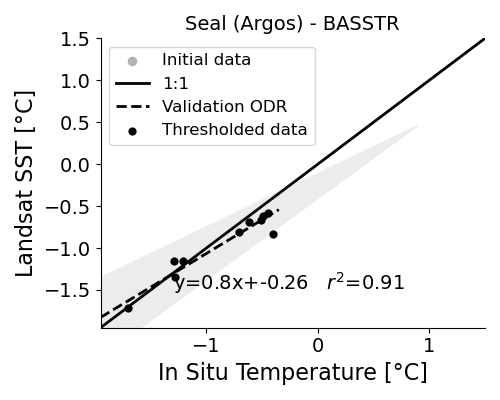


Processing df_sealani_basstr
Using 12 points for regression
  Initial only (gray): 0 points
  Thresholded (black): 12 points
Beta: [ 0.66294198 -0.36715114]
Beta Std Error: [0.06063069 0.06958557]
Beta Covariance: [[0.44998782 0.4612375 ]
 [0.4612375  0.59272609]]
Residual Variance: 0.008169289216064399
Inverse Condition #: 0.03764050606037611
Reason(s) for Halting:
  Sum of squares convergence

R^2: 0.92, RMSE: 0.1, n=12


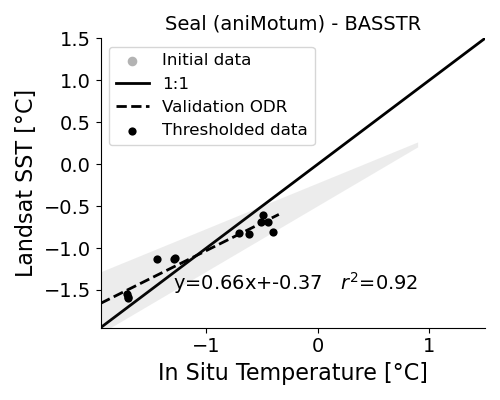


Processing df_sealargo_imos
Using 57 points for regression
  Initial only (gray): 12 points
  Thresholded (black): 45 points
Beta: [ 0.87062378 -0.1562904 ]
Beta Std Error: [0.08590321 0.08666492]
Beta Covariance: [[0.2521835  0.2386452 ]
 [0.2386452  0.25667555]]
Residual Variance: 0.029261876003152137
Inverse Condition #: 0.032392698691064405
Reason(s) for Halting:
  Sum of squares convergence

R^2: 0.54, RMSE: 0.22, n=57


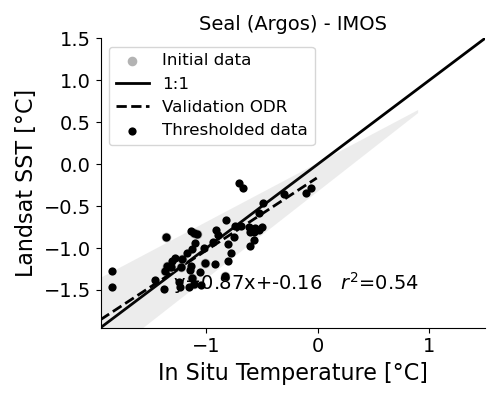


Processing df_sealani_imos
Using 46 points for regression
  Initial only (gray): 0 points
  Thresholded (black): 46 points
Beta: [ 0.93426985 -0.08069924]
Beta Std Error: [0.07255504 0.07062719]
Beta Covariance: [[0.27348397 0.24441138]
 [0.24441138 0.25914365]]
Residual Variance: 0.01924878556469287
Inverse Condition #: 0.03854093746369572
Reason(s) for Halting:
  Sum of squares convergence

R^2: 0.75, RMSE: 0.19, n=46


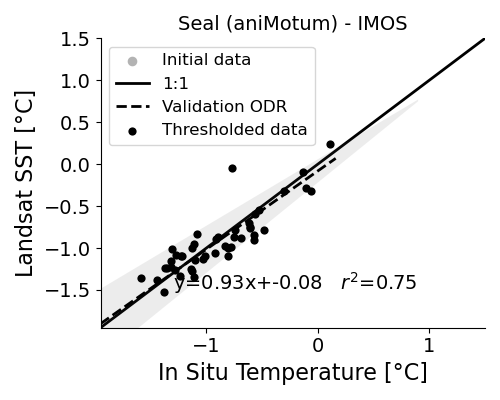


Processing df_argo
Using 6 points for regression
  Initial only (gray): 20 points
  Thresholded (black): 6 points
Beta: [ 0.9067858  -0.10047736]
Beta Std Error: [0.09469987 0.09628465]
Beta Covariance: [[0.37363703 0.17560958]
 [0.17560958 0.38624712]]
Residual Variance: 0.024002078282737354
Inverse Condition #: 0.08975643623031485
Reason(s) for Halting:
  Sum of squares convergence

R^2: 0.96, RMSE: 0.17, n=6


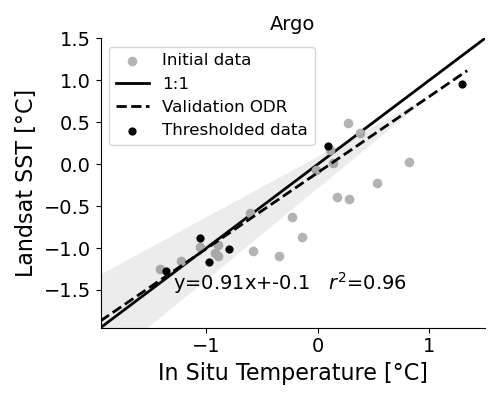

In [99]:
# Dataset mapping using only the correct datasets
dataset_mapping = {
    'df_sealargo_basstr': {
        'validmn': df_sealB,
        'valids': df_sealB,
        'initial_df': df_sealB0,
        'vcol': 'insitu_SST',
        'lcol': 'L8_SST',
        'id': 'id',
        'label': 'Seal (Argos) - BASSTR'
    },
    'df_sealani_basstr': {
        'validmn': df_seal_aniB,
        'valids': df_seal_aniB,
        'initial_df': df_seal_aniB0,
        'vcol': 'insitu_SST',
        'lcol': 'L8_SST',
        'id': 'id',
        'label': 'Seal (aniMotum) - BASSTR'
    },
    'df_sealargo_imos': {
        'validmn': df_sealI,
        'valids': df_sealI,
        'initial_df': df_sealI0,
        'vcol': 'insitu_SST',
        'lcol': 'L8_SST',
        'id': 'id',
        'label': 'Seal (Argos) - IMOS'
    },
    'df_sealani_imos': {
        'validmn': df_seal_aniI,
        'valids': df_seal_aniI,
        'initial_df': df_seal_aniI0,
        'vcol': 'insitu_SST',
        'lcol': 'L8_SST',
        'id': 'id',
        'label': 'Seal (aniMotum) - IMOS'
    },
    'df_argo': {
        'validmn': df_argo,
        'valids': df_argo,
        'initial_df': df_argo0,
        'vcol': 'insitu_SST',
        'lcol': 'L8_SST',
        'id': 'id',
        'label': 'Argo'
    }
}

# Process each dataset
for key in dataset_mapping.keys():
    print(f"\n{'='*60}")
    print(f"Processing {key}")
    print(f"{'='*60}")

    dmap = dataset_mapping[key]
    validmn = dmap['validmn']
    valids = dmap['valids']
    initial_df = dmap['initial_df']
    vcol = dmap['vcol']
    lcol = dmap['lcol']
    id = dmap['id']
    label = dmap['label']

    # Split initial_df into initial-only (gray) and thresholded (black)
    initial_only = initial_df[initial_df['weight'] < 1.0].dropna(subset=[lcol, vcol])
    thresholded  = initial_df[initial_df['weight'] == 1.0].dropna(subset=[lcol, vcol])

    # Prepare data for regression (thresholded only)
    data = validmn.dropna(subset=[lcol, vcol], how='any')

    if len(data) == 0:
        print(f"No valid data, skipping plot")
        continue
    
    # Calculate std
    std_data = valids.groupby(id)[lcol].std().reset_index()
    std_data.columns = [id, 'std_calc']
    data = data.merge(std_data, on=id, how='left')
    
    print(f"Using {len(data)} points for regression")
    print(f"  Initial only (gray): {len(initial_only)} points")
    print(f"  Thresholded (black): {len(thresholded)} points")
    
    # ODR
    x_original = np.array(data[vcol])
    y_original = np.array(data[lcol])
    
    linear = Model(linear_model)
    mdata = RealData(x_original, y_original)
    odr = ODR(mdata, linear, beta0=[1., 0.])
    out = odr.run()
    
    beta = out.beta
    beta_err = out.sd_beta
    out.pprint()
    
    y_pred = linear_model(beta, x_original)
    y_mean = np.mean(y_original)
    SST = np.sum((y_original - y_mean)**2)
    SSR = np.sum((y_original - y_pred)**2)
    R2 = 1 - (SSR / SST)
    rmse = np.sqrt(((y_original - y_pred) ** 2).mean())
    
    print(f"\nR^2: {np.around(R2, 2)}, RMSE: {np.around(rmse, 2)}, n={len(data)}")
    
    # Plot
    beta_bdn = [beta[0] - beta_err[0]*1.96, beta[1] + beta_err[1]*1.96]
    beta_mup = [beta[0] + beta_err[0]*1.96, beta[1] - beta_err[1]*1.96]
    xfill = np.array([-4.3, 0.9])
    
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.tick_params(labelsize=14)
    xi = np.arange(-7.0, 5.0, 1.0)

    # ✅ Plot initial-only data in gray (behind everything)
    ax.scatter(initial_only[vcol], initial_only[lcol],
               color='0.7', s=35, zorder=1, label='Initial data')

    # ✅ Plot thresholded error bars
    ax.errorbar(x_original, y_original, 
                yerr=data['std_calc'], color='k', fmt='o',
                ecolor='k', elinewidth=1, capthick=1, ms=3, capsize=5,
                label='_no legend_', zorder=2)

    # Reference lines
    ax.plot(xi, xi, color='k', linewidth=2, label='1:1', zorder=0)

    # ODR line
    x_line = np.linspace(-1.95, x_original.max() + 0.05, 100)
    y_line = linear_model(beta, x_line)
    ax.plot(x_line, y_line, color='k', ls='--', linewidth=2, label='Validation ODR')
    ax.fill_between(xfill, linear_model(beta_bdn, xfill), linear_model(beta_mup, xfill),
                    alpha=0.1, facecolor='0.3')

    # ✅ Plot thresholded data in black (on top)
    ax.scatter(x_original, y_original, 
               color='k', linewidth=0, s=35, label='Thresholded data', zorder=10)
    
    ax.text(-1.3, -1.5, f'y={np.around(beta[0], 2)}x+{np.around(beta[1], 2)}   $r^2$={np.around(R2, 2)}',
            fontsize=14)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim([-1.95, 1.5])
    ax.set_xlim([-1.95, 1.5])
    ax.set_xlabel('In Situ Temperature [°C]', fontsize=16)
    ax.set_ylabel('Landsat SST [°C]', fontsize=16)
    ax.set_title(label, fontsize=14)
    ax.legend(markerscale=1, fontsize=12, loc='upper left')
    plt.tight_layout()
    plt.show()
    
    del data, std_data, x_original, y_original, y_pred, initial_only, thresholded
    gc.collect()

In [100]:
# Create full super clean dataset
data = pd.concat([df_argo, df_sealB, df_sealI, df_seal_aniB_unique, df_seal_aniI_unique], ignore_index=True)
# data = pd.concat([df_argo0, df_sealB0, df_sealI0, df_seal_aniB0_unique, df_seal_aniI0_unique], ignore_index=True)
# data = pd.concat([df_argo, df_sealB, df_seal_aniI, df_seal_aniB_unique, df_sealI_unique], ignore_index=True)
# data = pd.concat([df_argo, df_seal_aniB, df_seal_aniI, df_sealB_unique, df_sealI_unique], ignore_index=True)
# data = pd.concat([df_argo, df_sealB, df_sealI], ignore_index=True)
# data = pd.concat([df_argo, df_seal_aniB, df_seal_aniI], ignore_index=True)

# Original data
x_original_best = np.array(data['insitu_SST'])
y_original_best = np.array(data['L8_SST'])

# Define a linear function for the model
def linear_model(p, x):
    return p[0] * x + p[1]

# Create a Model
linear = Model(linear_model)

# Create a RealData object using your DataFrame
mdata = RealData(x_original_best, y_original_best)

# Set up ODR with the model and data
odr = ODR(mdata, linear, beta0=[1., 0.])

# Run the regression
out = odr.run()

# Use the output
beta_best = out.beta
beta_err_best = out.sd_beta

# Print the summary
out.pprint()

# Predicting values using the ODR model
y_pred_best = linear_model(beta_best, x_original_best)

# Get R2
# Calculate Total Sum of Squares (SST)
y_mean = np.mean(y_original_best)
SST = np.sum((y_original_best - y_mean)**2)

# Calculate Residual Sum of Squares (SSR)
SSR = np.sum((y_original_best - y_pred_best)**2)

# Compute RMSE
rmse_best = np.sqrt(((y_original_best - y_pred_best) ** 2).mean())

# Calculate R^2
R2_best = 1 - (SSR / SST)
print("R^2:", np.around(R2_best,2))
print(f"RMSE: {np.around(rmse_best,2)}")
print (f'n={data.shape[0]}')
print(f'Mean abs residual: {np.around(data.abs_residual.mean(),3)}')
print(f'Median abs residual: {np.around(data.abs_residual.median(),3)}')

Beta: [ 0.89977341 -0.10952866]
Beta Std Error: [0.04988348 0.05138803]
Beta Covariance: [[0.09118605 0.08323085]
 [0.08323085 0.09676959]]
Residual Variance: 0.027288840148334072
Inverse Condition #: 0.0430835729733496
Reason(s) for Halting:
  Sum of squares convergence
R^2: 0.76
RMSE: 0.22
n=87
Mean abs residual: 0.193
Median abs residual: 0.16


In [101]:
# Sort x and y together
sorted_indices = np.argsort(x_original_best)
x_original_best = x_original_best[sorted_indices]
y_original_best = y_original_best[sorted_indices]
sorted_indices = np.argsort(y_pred_best)
y_pred_best = y_pred_best[sorted_indices]

At 95% confidence interval: 0.9+/-0.1, -0.11+/-0.1, n=87


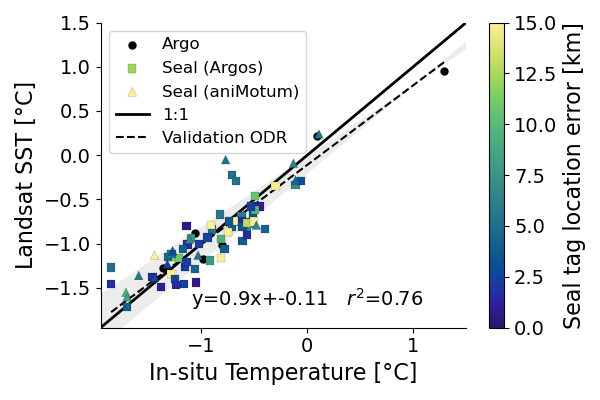

In [102]:
# Two datasets
beta_mdn = [beta_best[0]-beta_err_best[0]*1.96,beta_best[1]-beta_err_best[1]*1.96]
beta_mup = [beta_best[0]+beta_err_best[0]*1.96,beta_best[1]-beta_err_best[1]*1.96]
beta_bdn = [beta_best[0]-beta_err_best[0]*1.96,beta_best[1]+beta_err_best[1]*1.96]
beta_bup = [beta_best[0]+beta_err_best[0]*1.96,beta_best[1]+beta_err_best[1]*1.96]
print(f'At 95% confidence interval: {np.around(beta_best[0],2)}+/-{np.around(beta_err_best[0]*1.96,2)}, {np.around(beta_best[1],2)}+/-{np.around(beta_err_best[1]*1.96,2)}, n={y_pred_best.shape[0]}')
xfill = np.array([-4.3,1.5])

x_var = 'insitu_SST'
y_var = 'L8_SST'
c_var = 'loc_err[km]'
c_min = 0 #data[c_var].min()
c_max = 15 #data[c_var].max()
cmap = 'cmo.haline'
argo_c = 'k'

# Plot data points and 1:1 line
fig, ax = plt.subplots(figsize=(6, 4))
ax.tick_params(labelsize=14)
xi = np.arange(-7.0, 5.0, 1.0)

# Define markers for each dataset
plot_styles = {
    'Argo': {'marker': 'o', 'size': 35},
    'Seal (Argos)': {'marker': 's', 'size': 35},
    'Seal (aniMotum)': {'marker': '^', 'size': 40}
}

# Plot each dataset separately
for source, style in plot_styles.items():
    mask = data['source'] == source
    if mask.any():
        if (source=='Argo'):
            ax.errorbar(data.loc[mask, x_var], data.loc[mask, y_var], 
                    yerr=data.loc[mask, 'std'], color=argo_c, fmt=style['marker'], ecolor='w', 
                    elinewidth=1, capthick=1, ms=3, capsize=5, zorder=1, 
                    label='_no legend_')
            ax.scatter(data.loc[mask, x_var], data.loc[mask, y_var], 
                       c=argo_c, linewidth=0.1, s=style['size'], label=source, marker=style['marker'], edgecolors='k',
                       cmap=cmap, vmin=c_min, vmax=c_max, zorder=2)
        elif (source=='Seal (Argos)') | (source=='Seal (aniMotum)'):
            # ax.errorbar(data.loc[mask, 'insitu_SST'], data.loc[mask, 'L8_SST'], 
            #         yerr=data.loc[mask, 'std'], color='k', fmt=marker, ecolor='k', 
            #         elinewidth=1, capthick=1, ms=3, capsize=5, 
            #         label='_no legend_')
            ax.scatter(data.loc[mask, x_var], data.loc[mask, y_var], 
                       c=data.loc[mask, c_var], linewidth=0.1, s=style['size'], label=source, marker=style['marker'], edgecolors='k',
                       cmap=cmap, vmin=c_min, vmax=c_max, zorder=3)

# If you have removed data, you can add it here
# ax.scatter(rm['insitu_SST'], rm['L8_SST'], color='0.7', s=35, label='Removed', zorder=2)

ax.plot(xi, xi, color='k', linewidth=2, label='1:1',zorder=0)
ax.plot(x_original_best, y_pred_best, color='k', ls='--', label='Validation ODR')
ax.fill_between(xfill, linear_model(beta_bdn, xfill), linear_model(beta_mup, xfill), 
                alpha=0.1, facecolor='0.3')

ax.text(-1.1, -1.7, f'y={np.around(beta_best[0], 2)}x+{np.around(beta_best[1], 2)}   $r^2$={np.around(R2_best, 2)}', fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim([-1.95, 1.5])
ax.set_xlim([-1.95, 1.5])
ax.set_xlabel('In-situ Temperature [°C]', fontsize=16)
ax.set_ylabel('Landsat SST [°C]', fontsize=16)
ax.legend(markerscale=1, fontsize=12, loc='upper left')

# Create color bar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=c_min, vmax=c_max))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.ax.tick_params(labelsize=14)
cbar.set_label('Seal tag location error [km]', fontsize=16)

plt.tight_layout()
plt.savefig('/home/jovyan/Landsat_SST_algorithm/Figures/combined_validation.pdf', format='pdf', dpi=400)
plt.show()

In [103]:
print("RESIDUAL STATISTICS:")
print(f"Residual - Mean: {data['residual'].mean():.3f}, Median: {data['residual'].median():.3f}, Min: {data['residual'].min():.3f}, Max: {data['residual'].max():.3f}")
print(f"Abs Residual - Mean: {data['abs_residual'].mean():.3f}, Median: {data['abs_residual'].median():.3f}, Min: {data['abs_residual'].min():.3f}, Max: {data['abs_residual'].max():.3f}")


RESIDUAL STATISTICS:
Residual - Mean: -0.018, Median: -0.050, Min: -0.500, Max: 0.720
Abs Residual - Mean: 0.193, Median: 0.160, Min: 0.000, Max: 0.720


## Test for location dependence

In [146]:
from scipy.stats import pearsonr, spearmanr
from matplotlib.colors import ListedColormap, BoundaryNorm

In [147]:
def plot_rel(x_var,y_var,c_var,c_min,c_max,cmap,norm=None):
    
    # Plot data points and 1:1 line
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.tick_params(labelsize=14)
    xi = np.arange(-7.0, 5.0, 1.0)
    
    # Define markers for each dataset
    plot_styles = {
        'Argo': {'marker': 'o', 'size': 35},
        'Seal (Argos)': {'marker': 's', 'size': 35},
        'Seal (aniMotum)': {'marker': '^', 'size': 40}
    }
    
    # Plot each dataset separately
    for source, style in plot_styles.items():
        mask = data['source'] == source
        ax.scatter(data.loc[mask, x_var], data.loc[mask, y_var], 
                   c=data.loc[mask, c_var], linewidth=0.1, s=style['size'], label=source, marker=style['marker'], edgecolors='k',
                   cmap=cmap, vmin=c_min, vmax=c_max, norm=norm, zorder=3)
    
    ax.plot(xi, xi, color='k', linewidth=2, label='1:1',zorder=0)
    
    ax.text(-1.1, -1.7, f'y={np.around(beta[0], 2)}x+{np.around(beta[1], 2)}   $r^2$={np.around(R2, 2)}', fontsize=14)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim([-1.95, 1.5])
    ax.set_xlim([-1.95, 1.5])
    ax.set_xlabel('In-situ Temperature [°C]', fontsize=16)
    ax.set_ylabel('Landsat SST [°C]', fontsize=16)
    ax.legend(markerscale=1, fontsize=12, loc='upper left')
    
    # Create color bar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=c_min, vmax=c_max))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.ax.tick_params(labelsize=14)
    cbar.set_label(c_var, fontsize=16)
    
    plt.tight_layout()
    # plt.savefig('/home/jovyan/Landsat_SST_algorithm/Figures/combined_validation.pdf', format='pdf', dpi=500)
    plt.show()
    

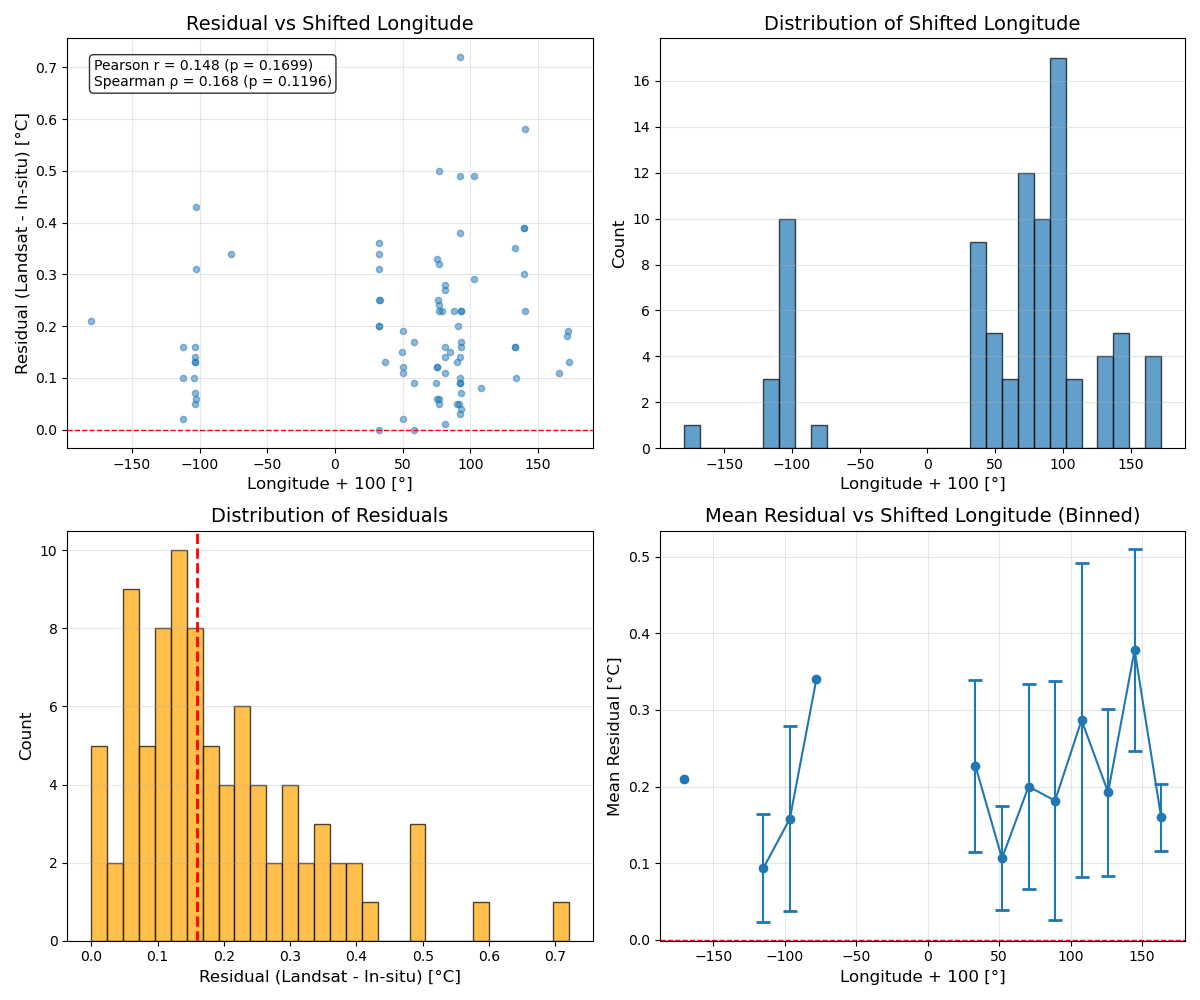

In [148]:
# Create figure with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# ind_var = 'lon_dist'
ind_var = 'lon'
# dep_var = 'residual'
dep_var = 'abs_residual'

# 1. Scatter plot: lon_dist vs residual
ax1 = axes[0, 0]
ax1.scatter(data[ind_var], data[dep_var], alpha=0.5, s=20)
ax1.axhline(y=0, color='red', linestyle='--', linewidth=1)
ax1.set_xlabel('Longitude + 100 [°]', fontsize=12)
ax1.set_ylabel('Residual (Landsat - In-situ) [°C]', fontsize=12)
ax1.set_title('Residual vs Shifted Longitude', fontsize=14)
ax1.grid(True, alpha=0.3)

# Calculate correlation
corr_pearson, p_pearson = pearsonr(data[ind_var], data[dep_var])
corr_spearman, p_spearman = spearmanr(data[ind_var], data[dep_var])
ax1.text(0.05, 0.95, f'Pearson r = {corr_pearson:.3f} (p = {p_pearson:.4f})\nSpearman ρ = {corr_spearman:.3f} (p = {p_spearman:.4f})',
         transform=ax1.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# 2. Histogram of lon_dist
ax2 = axes[0, 1]
ax2.hist(data[ind_var], bins=30, edgecolor='black', alpha=0.7)
ax2.set_xlabel('Longitude + 100 [°]', fontsize=12)
ax2.set_ylabel('Count', fontsize=12)
ax2.set_title('Distribution of Shifted Longitude', fontsize=14)
ax2.grid(True, alpha=0.3, axis='y')

# 3. Histogram of residual
ax3 = axes[1, 0]
ax3.hist(data['abs_residual'], bins=30, edgecolor='black', alpha=0.7, color='orange')
ax3.axvline(x=data.abs_residual.median(), color='red', linestyle='--', linewidth=2)
# ax3.text(0.4, 9, f'Median abs residual: {np.around(data.abs_residual.median(),3)}', fontsize=14)
ax3.set_xlabel('Residual (Landsat - In-situ) [°C]', fontsize=12)
ax3.set_ylabel('Count', fontsize=12)
ax3.set_title('Distribution of Residuals', fontsize=14)
ax3.grid(True, alpha=0.3, axis='y')

# 4. Binned statistics: mean residual per lon_dist bin
ax4 = axes[1, 1]
# Create bins for lon_dist
lon_bins = np.linspace(data[ind_var].min(), data[ind_var].max(), 20)
bin_centers = (lon_bins[:-1] + lon_bins[1:]) / 2

# Calculate mean residual per bin
binned_means = []
binned_stds = []
binned_counts = []

for i in range(len(lon_bins) - 1):
    mask = (data[ind_var] >= lon_bins[i]) & (data[ind_var] < lon_bins[i+1])
    bin_data = data.loc[mask, dep_var]
    if len(bin_data) > 0:
        binned_means.append(bin_data.mean())
        binned_stds.append(bin_data.std())
        binned_counts.append(len(bin_data))
    else:
        binned_means.append(np.nan)
        binned_stds.append(np.nan)
        binned_counts.append(0)

binned_means = np.array(binned_means)
binned_stds = np.array(binned_stds)

ax4.errorbar(bin_centers, binned_means, yerr=binned_stds, fmt='o-', 
             capsize=5, capthick=2, markersize=6)
ax4.axhline(y=0, color='red', linestyle='--', linewidth=1)
ax4.set_xlabel('Longitude + 100 [°]', fontsize=12)
ax4.set_ylabel('Mean Residual [°C]', fontsize=12)
ax4.set_title('Mean Residual vs Shifted Longitude (Binned)', fontsize=14)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary

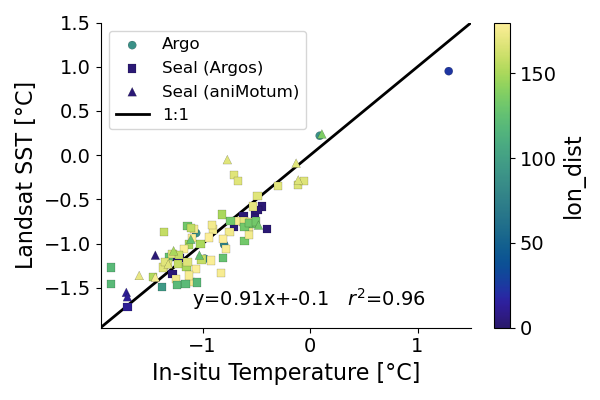

In [149]:
# Data by difference in longitude
plot_rel(
    x_var = 'insitu_SST',
    y_var = 'L8_SST',
    c_var = 'lon_dist',
    c_min = 0,
    c_max = 180,
    cmap = 'cmo.haline',
)

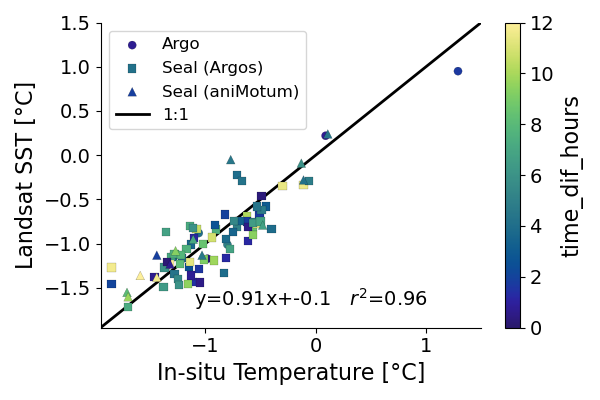

In [150]:
# Data by time difference
plot_rel(
    x_var = 'insitu_SST',
    y_var = 'L8_SST',
    c_var = 'time_dif_hours',
    c_min = 0,
    c_max = 12,
    cmap = 'cmo.haline',
)

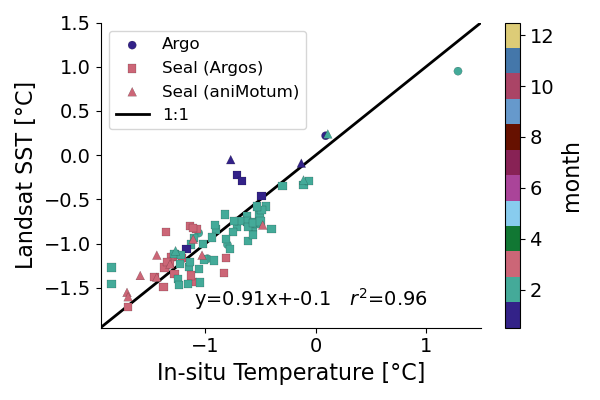

In [151]:
# Data by month
# Colorblind-friendly 12-color palette
# Based on Paul Tol's colorblind-safe colors
month_colors = [
    '#332288',  # Jan - Dark purple
    '#44AA99',  # Mar - Teal
    '#CC6677',  # Jun - Rose
    '#117733',  # Feb - Dark green
    '#88CCEE',  # Apr - Light blue
    '#AA4499',  # Jul - Purple
    '#882255',  # Aug - Wine
    '#661100',  # Sep - Brown
    '#6699CC',  # Oct - Steel blue
    '#AA4466',  # Nov - Mauve
    '#4477AA',   # Dec - Blue
    '#DDCC77',  # May - Sand
]

month_cmap = ListedColormap(month_colors)
month_norm = BoundaryNorm(boundaries=np.arange(0.5, 13.5, 1), ncolors=12)

plot_rel(
    x_var = 'insitu_SST',
    y_var = 'L8_SST',
    c_var = 'month',
    c_min = 0.5,
    c_max = 12.5,
    cmap = month_cmap,
)

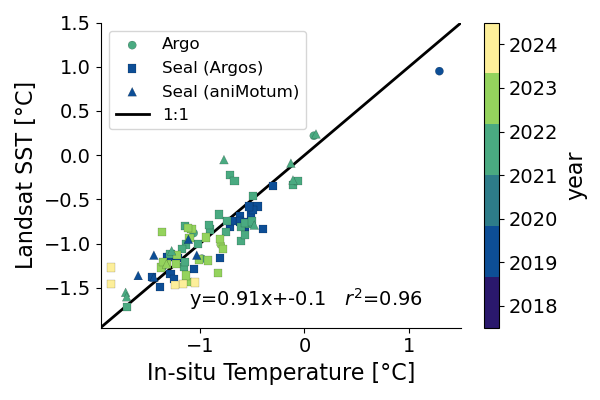

In [152]:
month_colors = [
    '#332288',  # Jan - Dark purple
    '#44AA99',  # Mar - Teal
    '#CC6677',  # Jun - Rose
    '#88CCEE',  # Apr - Light blue
    '#661100',  # Sep - Brown
    '#6699CC',  # Oct - Steel blue
    '0.5',  # Nov - Mauve
    '#DDCC77',  # May - Sand
]
month_cmap = ListedColormap(month_colors)

# Get unique months and count
n_months = len(range(data.year.max() - data.year.min()))

# Sample cmo.haline at n_months points
haline = cmocean.cm.haline
month_colors = [haline(i / (n_months)) for i in range(n_months+1)]
month_cmap = ListedColormap(month_colors)

plot_rel(
    x_var = 'insitu_SST',
    y_var = 'L8_SST',
    c_var = 'year',
    c_min = 2017.5,
    c_max = 2024.5,
    cmap = month_cmap,
)

(array([ 5.,  2.,  9.,  5.,  8., 10.,  8.,  5.,  4.,  6.,  4.,  2.,  4.,
         2.,  3.,  2.,  2.,  1.,  0.,  0.,  3.,  0.,  0.,  0.,  1.,  0.,
         0.,  0.,  0.,  1.]),
 array([0.   , 0.024, 0.048, 0.072, 0.096, 0.12 , 0.144, 0.168, 0.192,
        0.216, 0.24 , 0.264, 0.288, 0.312, 0.336, 0.36 , 0.384, 0.408,
        0.432, 0.456, 0.48 , 0.504, 0.528, 0.552, 0.576, 0.6  , 0.624,
        0.648, 0.672, 0.696, 0.72 ]),
 <BarContainer object of 30 artists>)

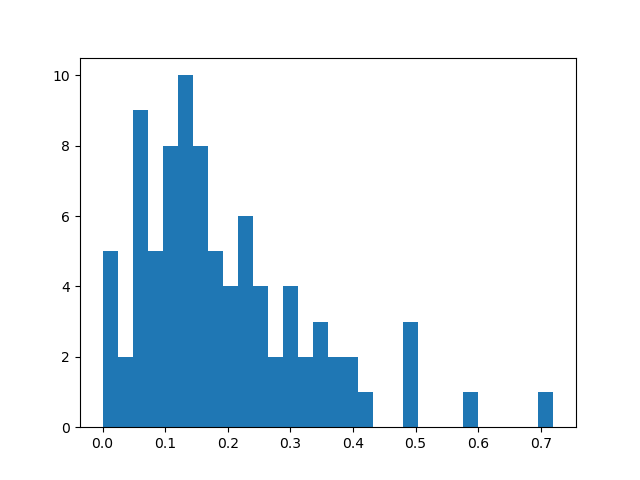

In [153]:
plt.figure()
plt.hist(data.abs_residual, bins=30)

NameError: name 'x_original' is not defined

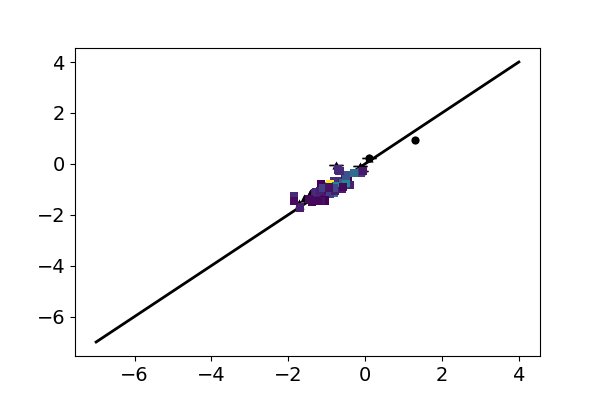

In [154]:
# Plot data points and 1:1 line
fig, ax = plt.subplots(figsize=(6, 4))
ax.tick_params(labelsize=14)
xi = np.arange(-7.0, 5.0, 1.0)

# Define markers for each dataset
markers = {'Argo': 'o', 'Seal (Argos)': 's', 'Seal (aniMotum)': '^'}

# Plot each dataset separately with different markers
for source, marker in markers.items():
    mask = data['source'] == source
    if mask.any():
        if (source=='Argo') | (source=='Seal (aniMotum)'):
            ax.errorbar(data.loc[mask, 'insitu_SST'], data.loc[mask, 'L8_SST'], 
                    yerr=data.loc[mask, 'std'], color='k', fmt=marker, ecolor='k', 
                    elinewidth=1, capthick=1, ms=3, capsize=5,zorder=1, 
                    label='_no legend_')
            ax.scatter(data.loc[mask, 'insitu_SST'], data.loc[mask, 'L8_SST'], 
                       c='k', linewidth=0, s=35, label=source, marker=marker, 
                       cmap='viridis', vmin=data['loc_err[km]'].min(), vmax=data['loc_err[km]'].max(),zorder=2)
        elif source=='Seal (Argos)':
            # ax.errorbar(data.loc[mask, 'insitu_SST'], data.loc[mask, 'L8_SST'], 
            #         yerr=data.loc[mask, 'std'], color='k', fmt=marker, ecolor='k', 
            #         elinewidth=1, capthick=1, ms=3, capsize=5, 
            #         label='_no legend_')
            ax.scatter(data.loc[mask, 'insitu_SST'], data.loc[mask, 'L8_SST'], 
                       c=data.loc[mask, 'loc_err[km]'], linewidth=0, s=35, label=source, marker=marker, 
                       cmap='viridis', vmin=data['loc_err[km]'].min(), vmax=data['loc_err[km]'].max(),zorder=3)

# If you have removed data, you can add it here
# ax.scatter(rm['insitu_SST'], rm['L8_SST'], color='0.7', s=35, label='Removed', zorder=2)

ax.plot(xi, xi, color='k', linewidth=2, label='1:1',zorder=0)
ax.plot(x_original, y_pred+0.17, color='k', ls=':', label='Validation ODR')
ax.fill_between(xfill, linear_model(beta_bdn, xfill), linear_model(beta_mup, xfill), 
                alpha=0.1, facecolor='0.3')

ax.text(-1.1, -1.7, f'y={np.around(beta[0], 2)}x+{np.around(beta[1], 2)}   $r^2$={np.around(R2, 2)}', fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim([-1.95, 1.5])
ax.set_xlim([-1.95, 1.5])
ax.set_xlabel('In-situ Temperature [°C]', fontsize=16)
ax.set_ylabel('Landsat SST [°C]', fontsize=16)
ax.legend(markerscale=1, fontsize=12, loc='upper left')

# Create color bar
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=data['loc_err[km]'].min(), vmax=data['loc_err[km]'].max()))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.ax.tick_params(labelsize=14)
cbar.set_label('Location Error [km]', fontsize=16)

plt.tight_layout()
# plt.savefig('/home/jovyan/Landsat_SST_algorithm/Figures/combined_validation.pdf', format='pdf', dpi=500)
plt.show()

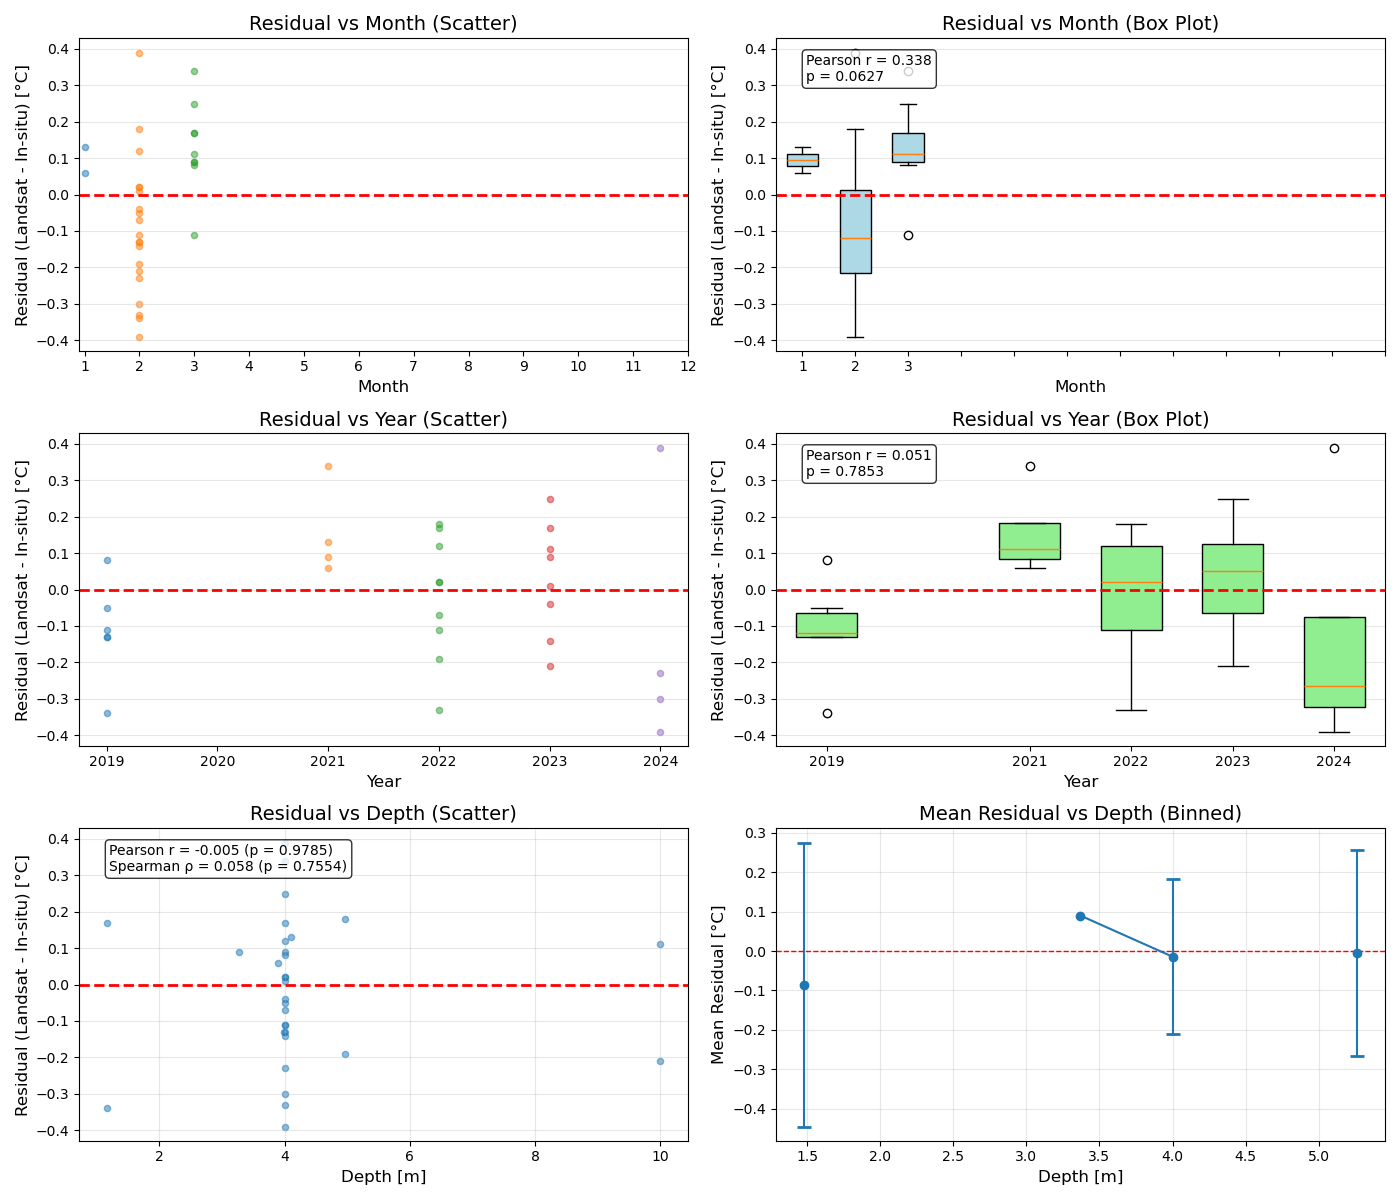

RESIDUAL DISTRIBUTION ANALYSIS

1. RESIDUAL VS MONTH:
   Pearson correlation: r = 0.3383, p = 0.0627

   Mean residual by month:
   Month  1:  0.0950 ± 0.0495 °C (n=2)
   Month  2: -0.0960 ± 0.1905 °C (n=20)
   Month  3:  0.1322 ± 0.1252 °C (n=9)

2. RESIDUAL VS YEAR:
   Pearson correlation: r = 0.0510, p = 0.7853

   Mean residual by year:
   Year 2019: -0.1133 ± 0.1366 °C (n=6)
   Year 2021:  0.1550 ± 0.1266 °C (n=4)
   Year 2022: -0.0211 ± 0.1712 °C (n=9)
   Year 2023:  0.0300 ± 0.1557 °C (n=8)
   Year 2024: -0.1325 ± 0.3544 °C (n=4)

3. RESIDUAL VS DEPTH:
   Pearson correlation: r = -0.0051, p = 0.9785
   Spearman correlation: ρ = 0.0583, p = 0.7554

   Depth range: [1.16, 10.00] m
   Mean depth: 4.24 ± 1.72 m

INTERPRETATION:
Year: NO significant temporal trend
Depth: NO significant relationship


In [220]:
# Extract month and year from DateTime
data['month'] = pd.to_datetime(data['DateTime']).dt.month
data['year'] = pd.to_datetime(data['DateTime']).dt.year

# Create figure with 3x2 subplots
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# ==========================================
# 1. RESIDUAL VS MONTH
# ==========================================
ax1 = axes[0, 0]
# Scatter plot
for month in sorted(data['month'].unique()):
    mask = data['month'] == month
    ax1.scatter([month]*mask.sum(), data.loc[mask, 'residual'], 
                alpha=0.5, s=20, label=f'Month {month}')
ax1.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Residual (Landsat - In-situ) [°C]', fontsize=12)
ax1.set_title('Residual vs Month (Scatter)', fontsize=14)
ax1.set_xticks(range(1, 13))
ax1.grid(True, alpha=0.3, axis='y')

# Box plot
ax2 = axes[0, 1]
months_present = sorted(data['month'].unique())
residual_by_month = [data[data['month'] == m]['residual'].values for m in months_present]
bp = ax2.boxplot(residual_by_month, positions=months_present, widths=0.6, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
ax2.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Month', fontsize=12)
ax2.set_ylabel('Residual (Landsat - In-situ) [°C]', fontsize=12)
ax2.set_title('Residual vs Month (Box Plot)', fontsize=14)
ax2.set_xticks(range(1, 13))
ax2.grid(True, alpha=0.3, axis='y')

# Calculate correlation with month
corr_month, p_month = pearsonr(data['month'], data['residual'])
ax2.text(0.05, 0.95, f'Pearson r = {corr_month:.3f}\np = {p_month:.4f}',
         transform=ax2.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ==========================================
# 2. RESIDUAL VS YEAR
# ==========================================
ax3 = axes[1, 0]
# Scatter plot
for year in sorted(data['year'].unique()):
    mask = data['year'] == year
    ax3.scatter([year]*mask.sum(), data.loc[mask, 'residual'], 
                alpha=0.5, s=20, label=str(year))
ax3.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax3.set_xlabel('Year', fontsize=12)
ax3.set_ylabel('Residual (Landsat - In-situ) [°C]', fontsize=12)
ax3.set_title('Residual vs Year (Scatter)', fontsize=14)
ax3.grid(True, alpha=0.3, axis='y')

# Box plot
ax4 = axes[1, 1]
years_present = sorted(data['year'].unique())
residual_by_year = [data[data['year'] == y]['residual'].values for y in years_present]
bp = ax4.boxplot(residual_by_year, positions=years_present, widths=0.6, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightgreen')
ax4.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax4.set_xlabel('Year', fontsize=12)
ax4.set_ylabel('Residual (Landsat - In-situ) [°C]', fontsize=12)
ax4.set_title('Residual vs Year (Box Plot)', fontsize=14)
ax4.grid(True, alpha=0.3, axis='y')

# Calculate correlation with year
corr_year, p_year = pearsonr(data['year'], data['residual'])
ax4.text(0.05, 0.95, f'Pearson r = {corr_year:.3f}\np = {p_year:.4f}',
         transform=ax4.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ==========================================
# 3. RESIDUAL VS DEPTH
# ==========================================
ax5 = axes[2, 0]
# Scatter plot
ax5.scatter(data['depth'], data['residual'], alpha=0.5, s=20)
ax5.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax5.set_xlabel('Depth [m]', fontsize=12)
ax5.set_ylabel('Residual (Landsat - In-situ) [°C]', fontsize=12)
ax5.set_title('Residual vs Depth (Scatter)', fontsize=14)
ax5.grid(True, alpha=0.3)

# Calculate correlation with depth
corr_depth, p_depth = pearsonr(data['depth'], data['residual'])
corr_spearman_depth, p_spearman_depth = spearmanr(data['depth'], data['residual'])
ax5.text(0.05, 0.95, f'Pearson r = {corr_depth:.3f} (p = {p_depth:.4f})\nSpearman ρ = {corr_spearman_depth:.3f} (p = {p_spearman_depth:.4f})',
         transform=ax5.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Binned statistics for depth
ax6 = axes[2, 1]
# Create bins for depth
depth_bins = np.linspace(data['depth'].min(), data['depth'].max(), 15)
bin_centers = (depth_bins[:-1] + depth_bins[1:]) / 2

binned_means = []
binned_stds = []
binned_counts = []

for i in range(len(depth_bins) - 1):
    mask = (data['depth'] >= depth_bins[i]) & (data['depth'] < depth_bins[i+1])
    bin_data = data.loc[mask, 'residual']
    if len(bin_data) > 0:
        binned_means.append(bin_data.mean())
        binned_stds.append(bin_data.std())
        binned_counts.append(len(bin_data))
    else:
        binned_means.append(np.nan)
        binned_stds.append(np.nan)
        binned_counts.append(0)

binned_means = np.array(binned_means)
binned_stds = np.array(binned_stds)

ax6.errorbar(bin_centers, binned_means, yerr=binned_stds, fmt='o-', 
             capsize=5, capthick=2, markersize=6)
ax6.axhline(y=0, color='red', linestyle='--', linewidth=1)
ax6.set_xlabel('Depth [m]', fontsize=12)
ax6.set_ylabel('Mean Residual [°C]', fontsize=12)
ax6.set_title('Mean Residual vs Depth (Binned)', fontsize=14)
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================
# SUMMARY STATISTICS
# ==========================================
print("="*80)
print("RESIDUAL DISTRIBUTION ANALYSIS")
print("="*80)

print("\n1. RESIDUAL VS MONTH:")
print(f"   Pearson correlation: r = {corr_month:.4f}, p = {p_month:.4f}")
print("\n   Mean residual by month:")
for month in sorted(data['month'].unique()):
    month_data = data[data['month'] == month]['residual']
    print(f"   Month {month:2d}: {month_data.mean():7.4f} ± {month_data.std():.4f} °C (n={len(month_data)})")

print("\n2. RESIDUAL VS YEAR:")
print(f"   Pearson correlation: r = {corr_year:.4f}, p = {p_year:.4f}")
print("\n   Mean residual by year:")
for year in sorted(data['year'].unique()):
    year_data = data[data['year'] == year]['residual']
    print(f"   Year {year}: {year_data.mean():7.4f} ± {year_data.std():.4f} °C (n={len(year_data)})")

print("\n3. RESIDUAL VS DEPTH:")
print(f"   Pearson correlation: r = {corr_depth:.4f}, p = {p_depth:.4f}")
print(f"   Spearman correlation: ρ = {corr_spearman_depth:.4f}, p = {p_spearman_depth:.4f}")
print(f"\n   Depth range: [{data['depth'].min():.2f}, {data['depth'].max():.2f}] m")
print(f"   Mean depth: {data['depth'].mean():.2f} ± {data['depth'].std():.2f} m")

print("\n" + "="*80)
print("INTERPRETATION:")
print("="*80)

# Month interpretation
if abs(corr_month) < 0.1 and p_month > 0.05:
    print("Month: NO significant seasonal bias")
elif abs(corr_month) >= 0.1 and p_month < 0.05:
    print("Month: SIGNIFICANT seasonal pattern detected")
    
# Year interpretation
if abs(corr_year) < 0.1 and p_year > 0.05:
    print("Year: NO significant temporal trend")
elif abs(corr_year) >= 0.1 and p_year < 0.05:
    print("Year: SIGNIFICANT temporal trend detected")
    
# Depth interpretation
if abs(corr_depth) < 0.1 and p_depth > 0.05:
    print("Depth: NO significant relationship")
elif abs(corr_depth) >= 0.1 and p_depth < 0.05:
    print("Depth: SIGNIFICANT relationship (deeper/shallower measurements differ)")